In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
import uncertainties.unumpy as upy
import lmfit
from lmfit import minimize, Parameters

import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
linmixPath = '/home/benjamin/Documents/linmix/'
os.sys.path.append(magePath)
os.sys.path.append(linmixPath)
import linmix

from magE.plotutils import * 
from magE.constutils import *

# Preparaing all necessary data

In [2]:
# Metallicities and more
metals = pd.read_csv(magePath+'results/metals/abundance_measured_final.csv')
em_lines = pd.read_csv(magePath+'results/em_lines_final.csv')
sed_results = fits.open('/home/benjamin/Documents/sed_fitting/old_pop_late_burst/results.fits') # SED fitting results

# log(M*)
unc_m_star = upy.uarray(sed_results[1].data['bayes.stellar.m_star'],
                        sed_results[1].data['bayes.stellar.m_star_err'])
m_star = upy.nominal_values(upy.log10(unc_m_star))
m_star_err = upy.std_devs(upy.log10(unc_m_star))

# log(SFR)
unc_sfr = upy.uarray(sed_results[1].data['bayes.sfh.sfr100Myrs'],
                     sed_results[1].data['bayes.sfh.sfr100Myrs_err'])
sfr = upy.nominal_values(upy.log10(unc_sfr))
sfr_err = upy.std_devs(upy.log10(unc_sfr))

metals.keys()

Index(['galname', 'He/H', 'He/H_16', 'He/H_84', 'log_OH', 'log_OH_16',
       'log_OH_84', 'log_SH', 'log_SH_16', 'log_SH_84', 'log_NH', 'log_NH_16',
       'log_NH_84', 'log_NO', 'log_NO_16', 'log_NO_84', 'log_NeH',
       'log_NeH_16', 'log_NeH_84', 'log_ArH', 'log_ArH_16', 'log_ArH_84',
       'log_FeH', 'log_FeH_16', 'log_FeH_84', 'log_q', 'log_q_16', 'log_q_84',
       'log_U', 'log_U_16', 'log_U_84'],
      dtype='object')

In [3]:
log_OH_err = np.mean(np.array(list(zip(metals['log_OH'] - metals['log_OH_16'],
                                       metals['log_OH_84'] - metals['log_OH']))).T, axis=0)

In [4]:
# Line ratios

N2 = upy.log10(upy.uarray(em_lines['[NII]6584'], em_lines['[NII]6584_err']) / upy.uarray(em_lines['Ha'], em_lines['Ha_err']))

R2 = upy.log10((upy.uarray(em_lines['[OII]3726'], em_lines['[OII]3726_err']) \
              + upy.uarray(em_lines['[OII]3729'], em_lines['[OII]3729_err'])) / upy.uarray(em_lines['Hb'], em_lines['Hb_err']))

R3 = upy.log10(upy.uarray(em_lines['[OIII]5007'], em_lines['[OIII]5007_err']) / upy.uarray(em_lines['Hb'], em_lines['Hb_err']))

R23 = upy.log10((upy.uarray(em_lines['[OII]3726'], em_lines['[OII]3726_err']) \
               + upy.uarray(em_lines['[OII]3729'], em_lines['[OII]3729_err']) \
               + upy.uarray(em_lines['[OIII]4959'], em_lines['[OIII]4959_err']) \
               + upy.uarray(em_lines['[OIII]5007'], em_lines['[OIII]5007_err']))  / upy.uarray(em_lines['Hb'], em_lines['Hb_err']))

O3N2 = upy.log10((upy.uarray(em_lines['[OIII]5007'], em_lines['[OIII]5007_err']) / upy.uarray(em_lines['Hb'], em_lines['Hb_err'])) \
               / (upy.uarray(em_lines['[NII]6584'], em_lines['[NII]6584_err']) / upy.uarray(em_lines['Ha'], em_lines['Ha_err'])))

R3N2 = upy.log10(upy.uarray(em_lines['[OIII]5007'], em_lines['[OIII]5007_err']) / upy.uarray(em_lines['[NII]6584'], em_lines['[NII]6584_err']))

N2O2 = upy.log10(upy.uarray(em_lines['[NII]6584'], em_lines['[NII]6584_err']) / upy.uarray(em_lines['[OII]3726'], em_lines['[OII]3726_err']))

O3O2 = upy.log10(upy.uarray(em_lines['[OIII]5007'], em_lines['[OIII]5007_err']) / (upy.uarray(em_lines['[OII]3726'], em_lines['[OII]3726_err']) \
               + upy.uarray(em_lines['[OII]3729'], em_lines['[OII]3729_err'])))

Ne3O2 = upy.log10(upy.uarray(em_lines['[NeIII]3868'], em_lines['[NeIII]3868_err'])/ (upy.uarray(em_lines['[OII]3726'], em_lines['[OII]3726_err']) \
                + upy.uarray(em_lines['[OII]3729'], em_lines['[OII]3729_err'])))

S2 = upy.log10((upy.uarray(em_lines['[SII]6716'], em_lines['[SII]6716_err']) + upy.uarray(em_lines['[SII]6730'], em_lines['[SII]6730_err'])) \
              / upy.uarray(em_lines['Ha'], em_lines['Ha_err']))

O3S2 = upy.log10((upy.uarray(em_lines['[OIII]5007'], em_lines['[OIII]5007_err']) / upy.uarray(em_lines['Hb'], em_lines['Hb_err'])) \
              / ((upy.uarray(em_lines['[SII]6716'], em_lines['[SII]6716_err']) + upy.uarray(em_lines['[SII]6730'], em_lines['[SII]6730_err']))  / upy.uarray(em_lines['Ha'], em_lines['Ha_err'])))
 
N2S2 = upy.log10((upy.uarray(em_lines['[NII]6584'], em_lines['[NII]6584_err']) / (upy.uarray(em_lines['[SII]6716'], em_lines['[SII]6716_err']) \
                + upy.uarray(em_lines['[SII]6730'], em_lines['[SII]6730_err']))) + (0.264 * (upy.uarray(em_lines['[NII]6584'], em_lines['[NII]6584_err']) \
                / upy.uarray(em_lines['Ha'], em_lines['Ha_err']))))

In [5]:
# Utils to plot
log_OH_tp = np.linspace(7.4, 9.0, 1000)
N2_tp = np.linspace(-3.5, 0.1, 1000)
R3_tp = np.linspace(0.2, 1.3, 1000)
R23_tp = np.linspace(0.4, 1.3, 1000)
O3N2_tp = np.linspace(1, 4, 1000)
O3O2_tp = np.linspace(0, 1.5, 1000)
Ne3O2_tp = np.linspace(-2.0, 0.5, 1000)
S2_tp = np.linspace(-2.0, -0.5, 1000)
O3S2_tp = np.linspace(1.0, 2.6, 1000)

## Data binning

In [2]:
mask1 = (metals['log_OH'] <= 8.0)
mask2 = (metals['log_OH'] > 8.0) & (metals['log_OH'] <= 8.2)
mask3 = (metals['log_OH'] > 8.2) & (metals['log_OH'] <= 8.4)
mask4 = (metals['log_OH'] > 8.4)

def binning(values, errors, binstat=False, OH=False):
    if binstat:
        total_bin = upy.uarray([bin1.nominal_value, bin2.nominal_value, bin3.nominal_value, bin4.nominal_value],
                               [sigma_bin1, sigma_bin2, sigma_bin3, sigma_bin4])
        
    if OH:
        bin1 = np.mean(values[mask1])
        bin2 = np.mean(values[mask2])
        bin3 = np.mean(values[mask3])
        bin4 = np.mean(values[mask4])
        
        bin1_16 = bin1 - np.mean(errors[0][mask1])
        bin2_16 = bin2 - np.mean(errors[0][mask2])
        bin3_16 = bin3 - np.mean(errors[0][mask3])
        bin4_16 = bin4 - np.mean(errors[0][mask4])
        
        bin1_84 = np.mean(errors[1][mask1]) - bin1
        bin2_84 = np.mean(errors[1][mask2]) - bin2
        bin3_84 = np.mean(errors[1][mask3]) - bin3
        bin4_84 = np.mean(errors[1][mask4]) - bin4
        
        total_bin = upy.uarray([bin1, bin2, bin3, bin4],
                              [np.mean([bin1_84, bin1_16]),
                               np.mean([bin2_84, bin2_16]),
                               np.mean([bin3_84, bin3_16]),
                               np.mean([bin4_84, bin4_16])])
    
    else:
        bin1 = np.mean(upy.uarray(values[mask1], errors[mask1]))
        bin2 = np.mean(upy.uarray(values[mask2], errors[mask2]))
        bin3 = np.mean(upy.uarray(values[mask3], errors[mask3]))
        bin4 = np.mean(upy.uarray(values[mask4], errors[mask4]))

        sigma_bin1 = np.std(values[mask1])
        sigma_bin2 = np.std(values[mask2])
        sigma_bin3 = np.std(values[mask3])
        sigma_bin4 = np.std(values[mask4])

        total_bin = upy.uarray([bin1.nominal_value, bin2.nominal_value, bin3.nominal_value, bin4.nominal_value],
                               [bin1.std_dev, bin2.std_dev, bin3.std_dev, bin4.std_dev])
        
    return total_bin

binstat=False
bin_OH = binning(metals['log_OH'], [metals['log_OH_16'].to_numpy(), metals['log_OH_84'].to_numpy()],
                 binstat=binstat, OH=True)
bin_N2 = binning(upy.nominal_values(N2), upy.std_devs(N2), binstat=binstat)
bin_R2 = binning(upy.nominal_values(R2), upy.std_devs(R2), binstat=binstat)
bin_R3 = binning(upy.nominal_values(R3), upy.std_devs(R3), binstat=binstat)
bin_R23 = binning(upy.nominal_values(R23), upy.std_devs(R23), binstat=binstat)
bin_O3N2 = binning(upy.nominal_values(O3N2), upy.std_devs(O3N2), binstat=binstat)
bin_R3N2 = binning(upy.nominal_values(R3N2), upy.std_devs(R3N2), binstat=binstat)
bin_N2O2 = binning(upy.nominal_values(N2O2), upy.std_devs(N2O2), binstat=binstat)
bin_O3O2 = binning(upy.nominal_values(O3O2), upy.std_devs(O3O2), binstat=binstat)
bin_Ne3O2 = binning(upy.nominal_values(Ne3O2), upy.std_devs(Ne3O2), binstat=binstat)
bin_S2 = binning(upy.nominal_values(S2), upy.std_devs(S2), binstat=binstat)
bin_O3S2 = binning(upy.nominal_values(O3S2), upy.std_devs(O3S2), binstat=binstat)
bin_N2S2 = binning(upy.nominal_values(N2S2), upy.std_devs(N2S2), binstat=binstat)

NameError: name 'metals' is not defined

In [7]:
print(round(np.mean(metals['log_OH'][mask4]), 3),
      round(np.mean(metals['log_OH_16'][mask4]), 3),
      round(np.mean(metals['log_OH_84'][mask4]), 3))

8.518 8.485 8.555


## Models to fit

In [8]:
# For LMFIT

# Linear
def residuals_linear(params, x, y, err):
    m = params['a1']
    n = params['a0']
    
    model = (m * x) + n
    return (model - y) / err

# Polynomial of degree 3

def residuals_poly3(params, x, y, err):
    a0 = params['a0']
    a1 = params['a1']
    a2 = params['a2']
    a3 = params['a3']
    
    model = a0 + (a1 * x) + (a2 * (x**2)) + (a3 + (x**3))
    return (model - y) / np.max(err)


# For curve_fit

import scipy

def linear(x, a0, a1):
    return a0 + (a1 * x)

def poly2(x, a0, a1, a2):
    t0 = a0
    t1 = a1 * x
    t2 = a2 * (x**2)
    return t0 + t1 + t2

#def poly2(x, a0, a2):
#    t0 = a0
#    t2 = a2 * (x**2)
#    return t0 + t2

def poly3(x, a0, a1, a2, a3):
    t0 = a0
    t1 = a1 * x
    t2 = a2 * (x**2)
    t3 = a3 * (x**3)
    return t0 + t1 + t2 + t3

# Replicating LinMix N2 fit with Bayesian regression w/ outliers

In [9]:
seed = np.random.seed(999)


lm_n2 = linmix.LinMix(metals['log_OH'].to_numpy(), upy.nominal_values(N2), 
                         log_OH_err, upy.std_devs(N2), parallelize=True, seed=seed)
lm_n2.run_mcmc(silent=True)



lm_o3n2 = linmix.LinMix(metals['log_OH'].to_numpy(), upy.nominal_values(O3N2), 
                            log_OH_err, upy.std_devs(O3N2), parallelize=True, seed=seed)
lm_o3n2.run_mcmc(silent=True)



lm_o3o2 = linmix.LinMix(metals['log_OH'].to_numpy(), upy.nominal_values(O3O2), 
                            log_OH_err, upy.std_devs(O3O2), parallelize=True, seed=seed)
lm_o3o2.run_mcmc(silent=True)



lm_ne3o2 = linmix.LinMix(metals['log_OH'].to_numpy(), upy.nominal_values(Ne3O2), 
                             log_OH_err, upy.std_devs(Ne3O2), parallelize=True, seed=seed)
lm_ne3o2.run_mcmc(silent=True)



lm_s2 = linmix.LinMix(metals['log_OH'].to_numpy(), upy.nominal_values(S2), 
                            log_OH_err, upy.std_devs(S2), parallelize=True, seed=seed)
lm_s2.run_mcmc(silent=True)



lm_o3s2 = linmix.LinMix(metals['log_OH'].to_numpy(), upy.nominal_values(O3S2), 
                            log_OH_err, upy.std_devs(O3S2), parallelize=True, seed=seed)
lm_o3s2.run_mcmc(silent=True)

(-2.4, -1.0)

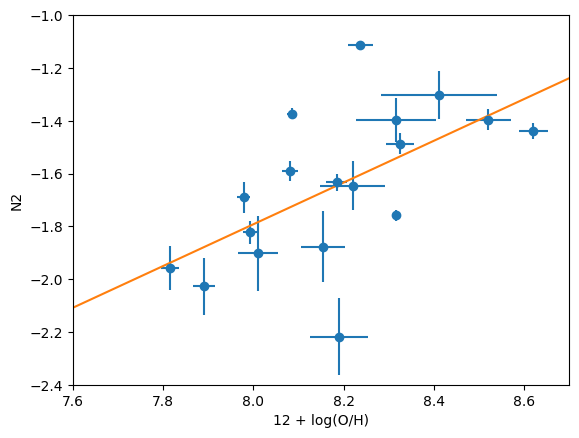

In [10]:
plt.errorbar(metals['log_OH'], upy.nominal_values(N2), 
             xerr=2*log_OH_err, yerr=10*upy.std_devs(N2),
            ls='', fmt='o')
plt.plot(log_OH_tp, lm_n2.chain['beta'].mean() * log_OH_tp + lm_n2.chain['alpha'].mean())
plt.ylabel('N2')
plt.xlabel('12 + log(O/H)')
plt.xlim(7.6, 8.7)
plt.ylim(-2.4, -1.0)

In [11]:
print('m:', lm_n2.chain['beta'].mean())
print('b:', lm_n2.chain['alpha'].mean())

m: 0.7899392200513721
b: -8.111672447474687


In [12]:
import emcee
print(emcee.__version__)

3.1.4


In [13]:
def ln_prior_N2(theta):
    m, b, s, Pb, Yb, logVb = theta
    if 0 < m < 1 and -15 < b < -5 and 0 < s < 1 and 0 < Pb < 1 and 0 < Yb < 2000 and -2 < logVb < 10:
        return 0
    return -np.inf

def ln_likelihood_N2(theta, x, y, yerr):
    m, b, s, Pb, Yb, logVb = theta
    Vb = 10**(logVb)
    model = m * x + b
    p_fg = (1 - Pb) / np.sqrt(2 * np.pi * (yerr**2 + s**2)) * np.exp(-(y - model)**2/(2 * (yerr**2 + s**2)))
    p_bg = Pb / np.sqrt(2 * np.pi * (Vb + yerr**2 + s**2)) * np.exp(-(y - Yb)**2/(2 * (Vb + yerr**2 + s**2)))
    output = np.sum(np.log(p_fg + p_bg))
    return output

def ln_posterior_N2(theta, x, y, err):
    ln_p = ln_prior_N2(theta)
    if not np.isfinite(ln_p):
        return -np.inf
    return ln_p + ln_likelihood_N2(theta, x, y, err)

In [14]:
np.random.seed(6563)

theta_N2 = np.array([0.7, -8.0, 0.1, 0.3, 400, 1.0])

ndim, nwalkers = 6, 100
steps = 1000
burn = int(0.9 * steps * nwalkers)
pos_N2 = [theta_N2 + 0.2*np.random.randn(ndim) for i in range(nwalkers)]

sampler_N2 = emcee.EnsembleSampler(nwalkers, ndim, ln_posterior_N2,
                                   args=(metals['log_OH'].values,
                                         upy.nominal_values(N2),
                                         upy.std_devs(N2)), threads=8)

In [15]:
%timeit -n1 -r1 sampler_N2.run_mcmc(pos_N2, steps, store=True)

/tmp/ipykernel_180522/3522431452.py:13: RuntimeWarning: divide by zero encountered in log
  output = np.sum(np.log(p_fg + p_bg))
/home/benjamin/anaconda3/envs/analogs/lib/python3.9/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


2.37 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


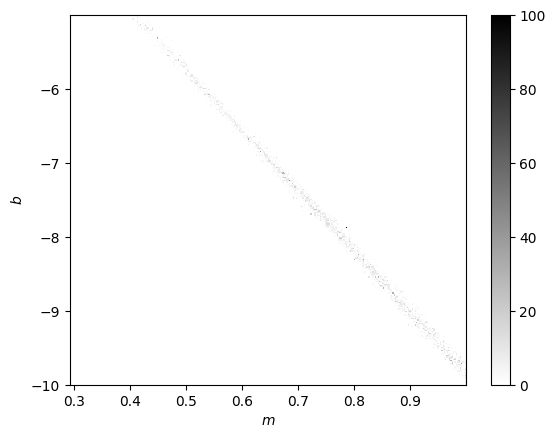

In [16]:
with plt.style.context('default'):
    plt.hist2d(sampler_N2.flatchain[burn:,0], sampler_N2.flatchain[burn:,1], bins=300, cmap='gray_r')
    plt.xlabel('$m$')
    plt.ylabel('$b$')
    plt.colorbar()
    #plt.xlim(0, 1)
    #plt.ylim(-10, 0)

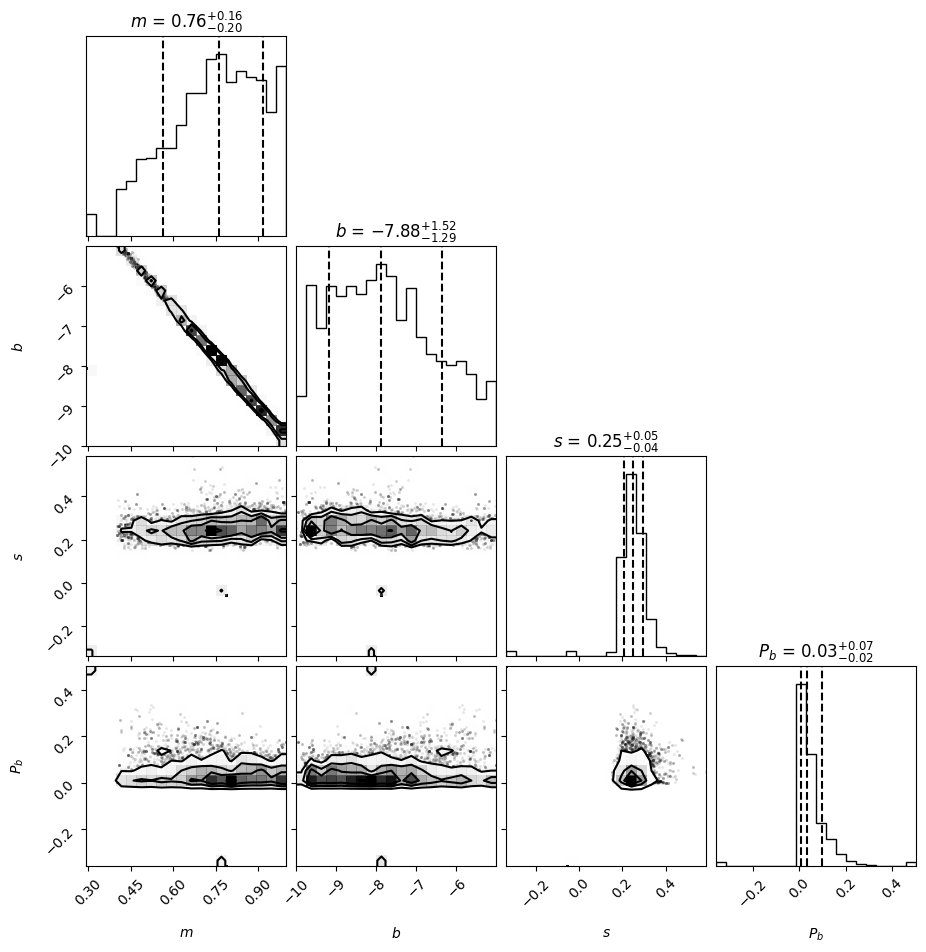

In [17]:
import corner
fig = corner.corner(sampler_N2.flatchain[90000:, [0, 1, 2, 3]],
                   labels=['$m$','$b$', '$s$', '$P_{b}$'],
                    #range=(0.9, 0.9, 0.9, 0.9),
                    quantiles=[0.16, 0.5, 0.84],
                    show_titles=True)

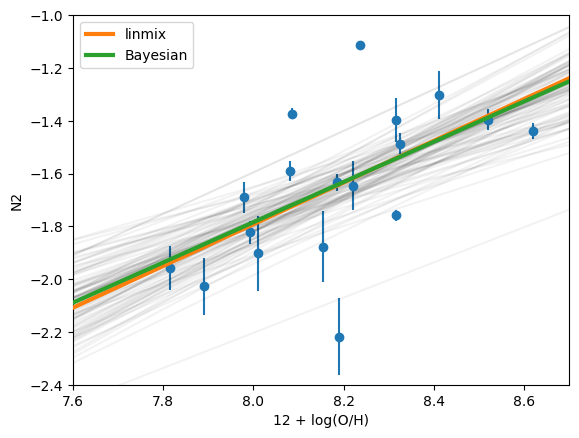

In [18]:
plt.errorbar(metals['log_OH'], upy.nominal_values(N2), 10*upy.std_devs(N2),
            ls='', fmt='o')

plt.plot(log_OH_tp, lm_n2.chain['beta'].mean() * log_OH_tp + lm_n2.chain['alpha'].mean(), label='linmix', lw=3, zorder=10)
plt.plot(log_OH_tp, np.nanpercentile(sampler_N2.flatchain[burn:, 0], 50) * log_OH_tp \
         + np.nanpercentile(sampler_N2.flatchain[burn:, 1], 50), label='Bayesian', lw=3, zorder=10)
plt.ylabel('N2')
plt.xlabel('12 + log(O/H)')
plt.xlim(7.6, 8.7)
plt.ylim(-2.4, -1.0)
plt.legend()

for i in np.random.randint(0, high=len(sampler_N2.flatchain), size=100):
    m, b = sampler_N2.flatchain[i, [0, 1]]
    plt.plot(log_OH_tp, m * log_OH_tp + b, color='k', alpha=0.05)

## Fitting R23

(7.7, 8.7)

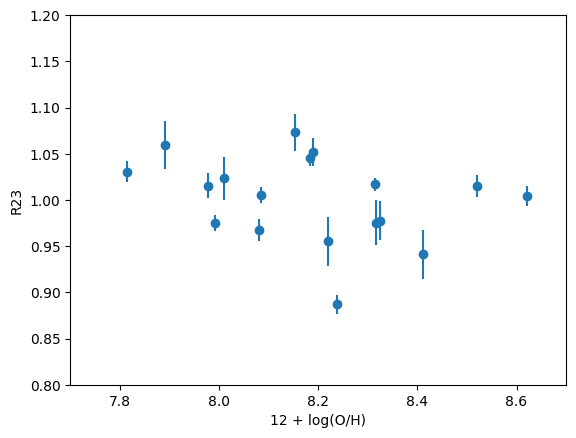

In [19]:
plt.errorbar(metals['log_OH'], upy.nominal_values(R23), 10*upy.std_devs(R23),
            ls='', fmt='o')
plt.ylabel('R23')
plt.xlabel('12 + log(O/H)')

plt.ylim(0.8, 1.2)
plt.xlim(7.7, 8.7)

In [20]:
def ln_prior_R23(theta):
    a0, a1, a2, s, Pb, Yb, logVb = theta
    if -10 < a0 < 4 and -5 < a1 < 5 and -1.5 < a2 < 3.0 and 0 < s < 1 and 0 < Pb < 1 and 0 < Yb < 2000 and -2 < logVb < 10:
        return 0
    return -np.inf

def ln_likelihood_R23(theta, x, y, yerr):
    a0, a1, a2, s, Pb, Yb, logVb = theta
    Vb = 10**(logVb)
    model = a0 + a1 * x + a2 * x**2
    p_fg = (1 - Pb) / np.sqrt(2 * np.pi * (yerr**2 + s**2)) * np.exp(-(y - model)**2/(2 * (yerr**2 + s**2)))
    p_bg = Pb / np.sqrt(2 * np.pi * (Vb + yerr**2 + s**2)) * np.exp(-(y - Yb)**2/(2 * (Vb + yerr**2 + s**2)))
    output = np.sum(np.log(p_fg + p_bg))
    return output

def ln_posterior_R23(theta, x, y, err):
    ln_p = ln_prior_R23(theta)
    if not np.isfinite(ln_p):
        return -np.inf
    return ln_p + ln_likelihood_R23(theta, x, y, err)

In [21]:
np.random.seed(6563)

theta_R23 = np.array([0.0, 1.0, -0.2, 0.1, 0.3, 400, 1.0])

ndim, nwalkers = 7, 100
steps = 1000
burn = int(0.99 * steps * nwalkers)
pos_R23 = [theta_R23 + 0.4*np.random.randn(ndim) for i in range(nwalkers)]

sampler_R23 = emcee.EnsembleSampler(nwalkers, ndim, ln_posterior_R23,
                               args=(metals['log_OH'].values,
                                     upy.nominal_values(R23),
                                     upy.std_devs(R23)), threads=8)

In [22]:
%timeit -n1 -r1 sampler_R23.run_mcmc(pos_R23, steps, store=True)

/tmp/ipykernel_180522/2783233947.py:13: RuntimeWarning: divide by zero encountered in log
  output = np.sum(np.log(p_fg + p_bg))
/home/benjamin/anaconda3/envs/analogs/lib/python3.9/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


2.31 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


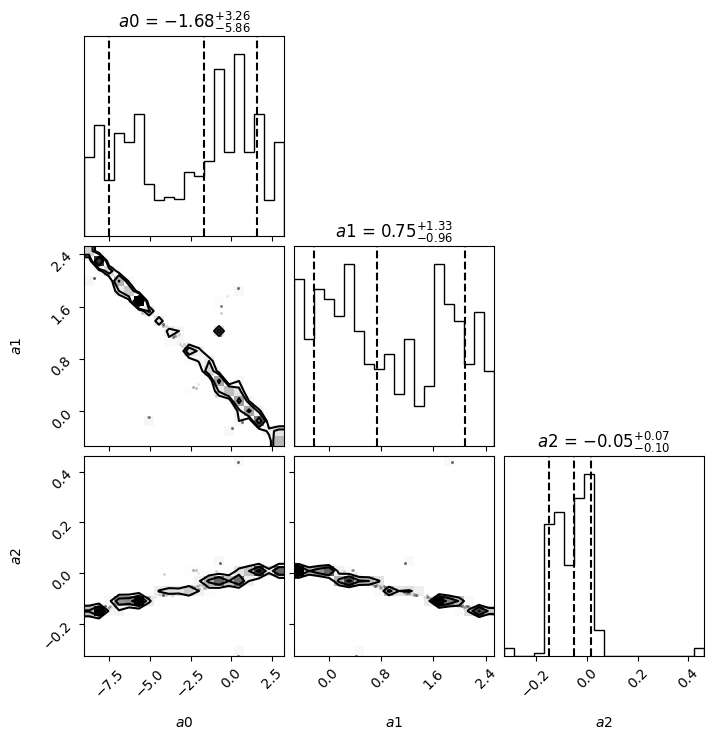

In [23]:
import corner
fig = corner.corner(sampler_R23.flatchain[burn:, [0, 1, 2]],
                   labels=['$a0$','$a1$', '$a2$'],
                    range=(0.9, 0.9, 0.9),
                    quantiles=[0.16, 0.5, 0.84],
                    show_titles=True)

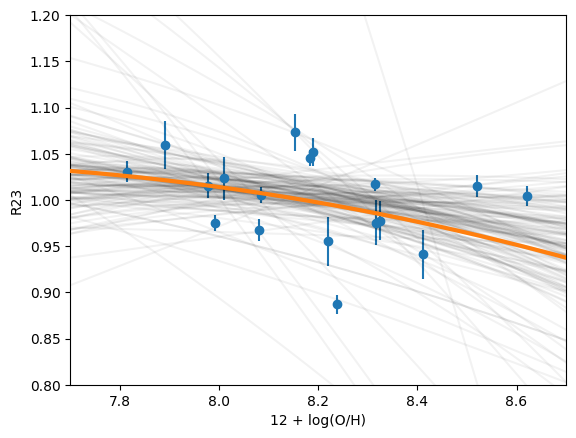

In [24]:
plt.errorbar(metals['log_OH'], upy.nominal_values(R23), 10*upy.std_devs(R23),
            ls='', fmt='o')
plt.ylabel('R23')
plt.xlabel('12 + log(O/H)')
plt.ylim(0.8, 1.2)
plt.xlim(7.7, 8.7)

best_a0_R23 = np.nanpercentile(sampler_R23.flatchain[burn:, 0], 50)
best_a1_R23 = np.nanpercentile(sampler_R23.flatchain[burn:, 1], 50)
best_a2_R23 = np.nanpercentile(sampler_R23.flatchain[burn:, 2], 50)

plt.plot(log_OH_tp, best_a0_R23 + best_a1_R23 * log_OH_tp + best_a2_R23 * log_OH_tp**2, lw=3, zorder=10)

for i in np.random.randint(0, high=len(sampler_R23.flatchain), size=200):
    a0, a1, a2 = sampler_R23.flatchain[i, [0, 1, 2]]
    plt.plot(log_OH_tp, a0 + a1 * log_OH_tp + a2 * log_OH_tp**2, color='k', alpha=0.05)

## Fitting R2

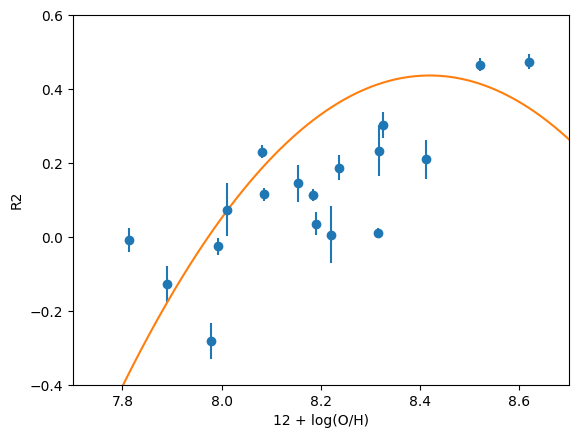

In [25]:
plt.errorbar(metals['log_OH'], upy.nominal_values(R2), 10*upy.std_devs(R2),
            ls='', fmt='o')
plt.ylabel('R2')
plt.xlabel('12 + log(O/H)')

plt.ylim(-0.4, 0.6)
plt.xlim(7.7, 8.7)

plt.plot(log_OH_tp,  -154.9571 + 36.9128 * log_OH_tp -2.1921 * log_OH_tp**2)

In [26]:
def ln_prior_R2(theta):
    a0, a1, a2, s, Pb, Yb, logVb = theta
    if -200 < a0 < -100 and 0 < a1 < 60 and -2.5 < a2 < -2.0 and 0 < s < 1 and 0 < Pb < 1 and 0 < Yb < 2000 and -2 < logVb < 10:
        return 0
    return -np.inf

def ln_likelihood_R2(theta, x, y, yerr):
    a0, a1, a2, s, Pb, Yb, logVb = theta
    Vb = 10**(logVb)
    model = a0 + a1 * x + a2 * x**2
    p_fg = (1 - Pb) / np.sqrt(2 * np.pi * (yerr**2 + s**2)) * np.exp(-(y - model)**2/(2 * (yerr**2 + s**2)))
    p_bg = Pb / np.sqrt(2 * np.pi * (Vb + yerr**2 + s**2)) * np.exp(-(y - Yb)**2/(2 * (Vb + yerr**2 + s**2)))
    output = np.sum(np.log(p_fg + p_bg))
    return output

def ln_posterior_R2(theta, x, y, err):
    ln_p = ln_prior_R2(theta)
    if not np.isfinite(ln_p):
        return -np.inf
    return ln_p + ln_likelihood_R2(theta, x, y, err)

In [27]:
np.random.seed(6563)

theta_R2 = np.array([-150, 35, -2.2, 0.1, 0.3, 400, 1.0])

ndim, nwalkers = 7, 100
steps = 10000
burn = int(0.99 * steps * nwalkers)
pos_R2 = [theta_R2 + 0.2*np.random.randn(ndim) for i in range(nwalkers)]

sampler_R2 = emcee.EnsembleSampler(nwalkers, ndim, ln_posterior_R2,
                                   args=(metals['log_OH'].values,
                                         upy.nominal_values(R2),
                                         upy.std_devs(R2)), threads=8)

In [28]:
%timeit -n1 -r1 sampler_R2.run_mcmc(pos_R2, steps, store=True)

/tmp/ipykernel_180522/1872987787.py:13: RuntimeWarning: divide by zero encountered in log
  output = np.sum(np.log(p_fg + p_bg))


23.4 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


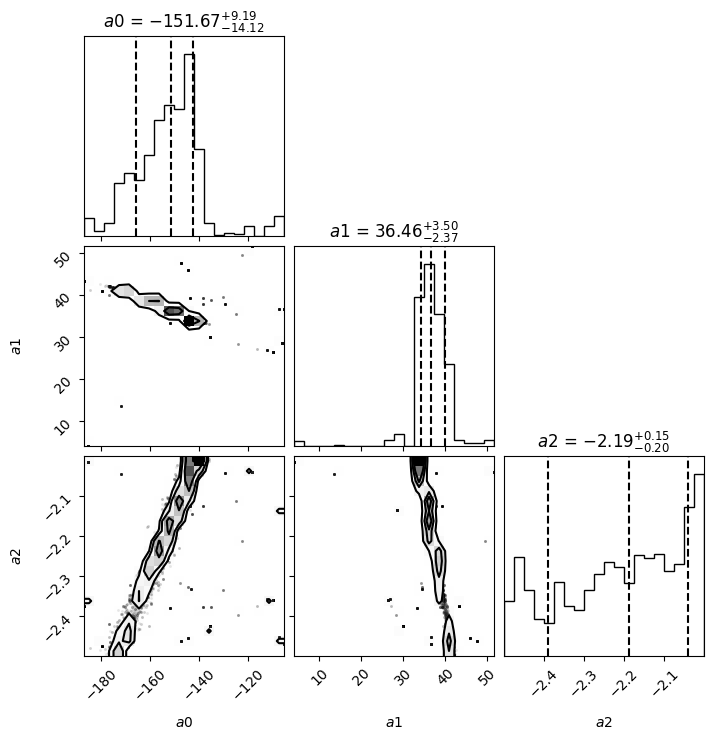

In [29]:
import corner
fig = corner.corner(sampler_R2.flatchain[burn:, [0, 1, 2]],
                   labels=['$a0$','$a1$', '$a2$'],
                    #range=(0.9, 0.9, 0.9),
                    quantiles=[0.16, 0.5, 0.84],
                    show_titles=True)

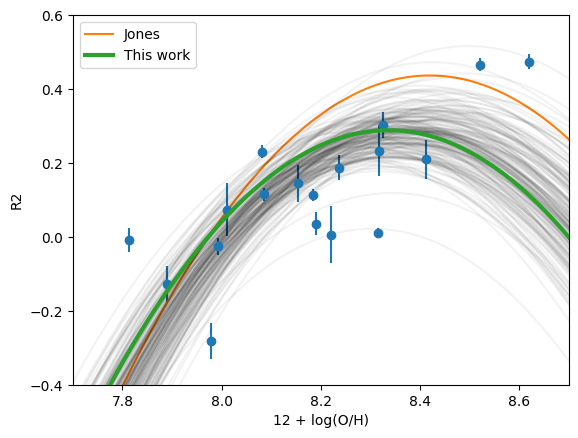

In [30]:
plt.errorbar(metals['log_OH'], upy.nominal_values(R2), 10*upy.std_devs(R2),
            ls='', fmt='o')
plt.plot(log_OH_tp,  -154.9571 + 36.9128 * log_OH_tp -2.1921 * log_OH_tp**2, label='Jones')
plt.ylabel('R2')
plt.xlabel('12 + log(O/H)')
plt.ylim(-0.4, 0.6)
plt.xlim(7.7, 8.7)

best_a0_R2 = np.nanpercentile(sampler_R2.flatchain[burn:,0], 50)
best_a1_R2 = np.nanpercentile(sampler_R2.flatchain[burn:,1], 50)
best_a2_R2 = np.nanpercentile(sampler_R2.flatchain[burn:,2], 50)

plt.plot(log_OH_tp, best_a0_R2 + best_a1_R2 * log_OH_tp + best_a2_R2 * log_OH_tp**2, lw=3, zorder=10, label='This work')
plt.legend()

for i in np.random.randint(0, high=len(sampler_R2.flatchain), size=200):
    a0, a1, a2 = sampler_R2.flatchain[i, [0, 1, 2]]
    plt.plot(log_OH_tp, a0 + a1 * log_OH_tp + a2 * log_OH_tp**2, color='k', alpha=0.05)

## Fitting R3

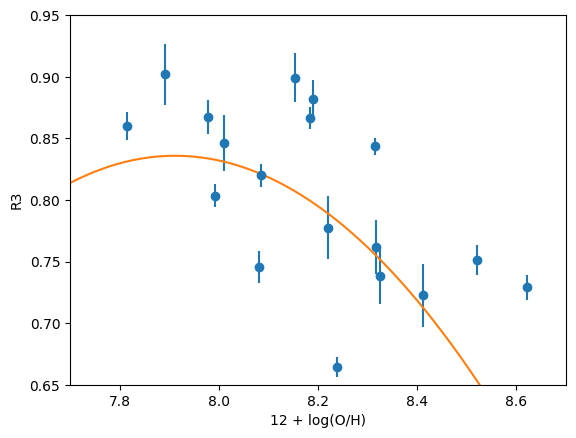

In [31]:
plt.errorbar(metals['log_OH'], upy.nominal_values(R3), 10*upy.std_devs(R3),
            ls='', fmt='o')
plt.ylabel('R3')
plt.xlabel('12 + log(O/H)')

plt.ylim(0.65, 0.95)
plt.xlim(7.7, 8.7)

plt.plot(log_OH_tp,  -30.024 + 7.801 * log_OH_tp -0.493 * log_OH_tp**2)

In [32]:
def ln_prior_R3(theta):
    a0, a1, a2, s, Pb, Yb, logVb = theta
    if -40 < a0 < -25 and 6.5 < a1 < 8.8 and -0.6 < a2 < -0.2 and 0 < s < 1 and 0 < Pb < 1 and 0 < Yb < 2000 and -2 < logVb < 10:
        return 0
    return -np.inf

def ln_likelihood_R3(theta, x, y, yerr):
    a0, a1, a2, s, Pb, Yb, logVb = theta
    Vb = 10**(logVb)
    model = a0 + a1 * x + a2 * x**2
    p_fg = (1 - Pb) / np.sqrt(2 * np.pi * (yerr**2 + s**2)) * np.exp(-(y - model)**2/(2 * (yerr**2 + s**2)))
    p_bg = Pb / np.sqrt(2 * np.pi * (Vb + yerr**2 + s**2)) * np.exp(-(y - Yb)**2/(2 * (Vb + yerr**2 + s**2)))
    output = np.sum(np.log(p_fg + p_bg))
    return output

def ln_posterior_R3(theta, x, y, err):
    ln_p = ln_prior_R3(theta)
    if not np.isfinite(ln_p):
        return -np.inf
    return ln_p + ln_likelihood_R3(theta, x, y, err)

In [33]:
np.random.seed(6563)

theta_R3 = np.array([-30.024, 7.801, -0.493, 0.1, 0.3, 400, 1.0])

ndim, nwalkers = 7, 100
steps = 10000
burn = int(0.99 * steps * nwalkers)
pos_R3 = [theta_R3 + 0.032*np.random.randn(ndim) for i in range(nwalkers)]

sampler_R3 = emcee.EnsembleSampler(nwalkers, ndim, ln_posterior_R3,
                                   args=(metals['log_OH'].values,
                                         upy.nominal_values(R3),
                                         upy.std_devs(R3)), threads=8)

In [34]:
%timeit -n1 -r1 sampler_R3.run_mcmc(pos_R3, steps, store=True)

/tmp/ipykernel_180522/1257890675.py:13: RuntimeWarning: divide by zero encountered in log
  output = np.sum(np.log(p_fg + p_bg))


24.3 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


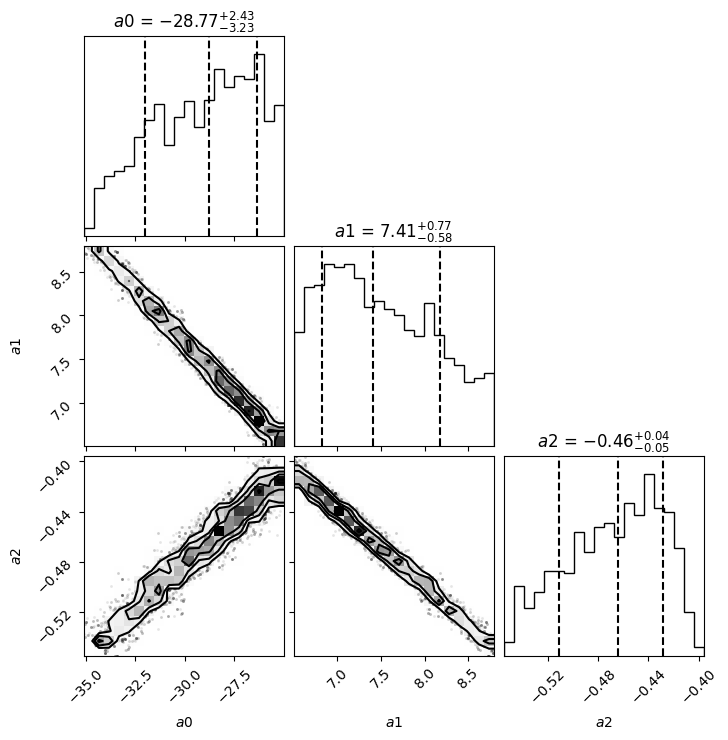

In [35]:
import corner
fig = corner.corner(sampler_R3.flatchain[burn:, [0, 1, 2]],
                   labels=['$a0$','$a1$', '$a2$'],
                    #range=(0.9, 0.9, 0.9),
                    quantiles=[0.16, 0.5, 0.84],
                    show_titles=True)

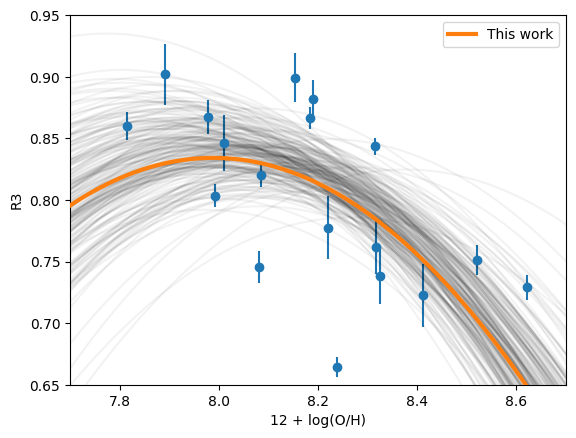

In [36]:
plt.errorbar(metals['log_OH'], upy.nominal_values(R3), 10*upy.std_devs(R3),
            ls='', fmt='o')
#plt.plot(log_OH_tp,  -30.024 + 7.801 * log_OH_tp -0.493 * log_OH_tp**2)
plt.ylabel('R3')
plt.xlabel('12 + log(O/H)')
plt.ylim(0.65, 0.95)
plt.xlim(7.7, 8.7)

best_a0_R3 = np.nanpercentile(sampler_R3.flatchain[burn:,0], 50)
best_a1_R3 = np.nanpercentile(sampler_R3.flatchain[burn:,1], 50)
best_a2_R3 = np.nanpercentile(sampler_R3.flatchain[burn:,2], 50)

plt.plot(log_OH_tp, best_a0_R3 + best_a1_R3 * log_OH_tp + best_a2_R3 * log_OH_tp**2, lw=3, zorder=10, label='This work')
plt.legend()

for i in np.random.randint(0, high=len(sampler_R3.flatchain), size=200):
    a0, a1, a2 = sampler_R3.flatchain[i, [0, 1, 2]]
    plt.plot(log_OH_tp, a0 + a1 * log_OH_tp + a2 * log_OH_tp**2, color='k', alpha=0.05)

## Fitting R3N2

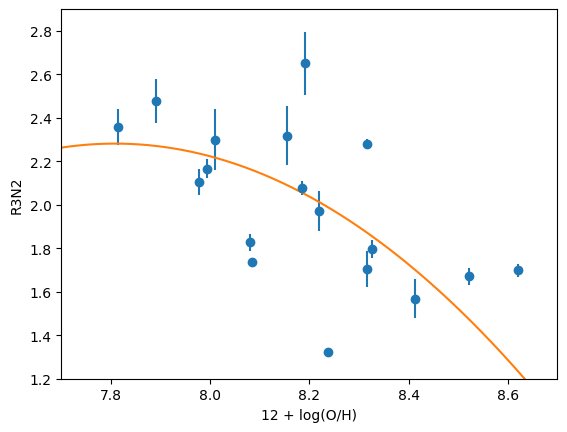

In [37]:
plt.errorbar(metals['log_OH'], upy.nominal_values(R3N2), 10*upy.std_devs(R3N2),
            ls='', fmt='o')
plt.ylabel('R3N2')
plt.xlabel('12 + log(O/H)')

plt.ylim(1.2, 2.9)
plt.xlim(7.7, 8.7)

plt.plot(log_OH_tp,  -94.409 + 24.767 * log_OH_tp -1.586 * log_OH_tp**2)

In [38]:
def ln_prior_R3N2(theta):
    a0, a1, a2, s, Pb, Yb, logVb = theta
    if -100 < a0 < -70 and 15 < a1 < 30 and -2.0 < a2 < -1.0 and 0 < s < 1 and 0 < Pb < 1 and 0 < Yb < 2000 and -2 < logVb < 10:
        return 0
    return -np.inf

def ln_likelihood_R3N2(theta, x, y, yerr):
    a0, a1, a2, s, Pb, Yb, logVb = theta
    Vb = 10**(logVb)
    model = a0 + a1 * x + a2 * x**2
    p_fg = (1 - Pb) / np.sqrt(2 * np.pi * (yerr**2 + s**2)) * np.exp(-(y - model)**2/(2 * (yerr**2 + s**2)))
    p_bg = Pb / np.sqrt(2 * np.pi * (Vb + yerr**2 + s**2)) * np.exp(-(y - Yb)**2/(2 * (Vb + yerr**2 + s**2)))
    output = np.sum(np.log(p_fg + p_bg))
    return output

def ln_posterior_R3N2(theta, x, y, err):
    ln_p = ln_prior_R3N2(theta)
    if not np.isfinite(ln_p):
        return -np.inf
    return ln_p + ln_likelihood_R3N2(theta, x, y, err)

In [39]:
np.random.seed(6563)

theta_R3N2 = np.array([-94.409, 24.767, -1.586, 0.1, 0.3, 400, 1.0])

ndim, nwalkers = 7, 100
steps = 10000
burn = int(0.99 * steps * nwalkers)
pos_R3N2 = [theta_R3N2 + 0.03*np.random.randn(ndim) for i in range(nwalkers)]

sampler_R3N2 = emcee.EnsembleSampler(nwalkers, ndim, ln_posterior_R3N2,
                                     args=(metals['log_OH'].values,
                                           upy.nominal_values(R3N2),
                                           upy.std_devs(R3N2)), threads=8)

In [40]:
%timeit -n1 -r1 sampler_R3N2.run_mcmc(pos_R3N2, steps, store=True)

/tmp/ipykernel_180522/3207786055.py:13: RuntimeWarning: divide by zero encountered in log
  output = np.sum(np.log(p_fg + p_bg))


24.2 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


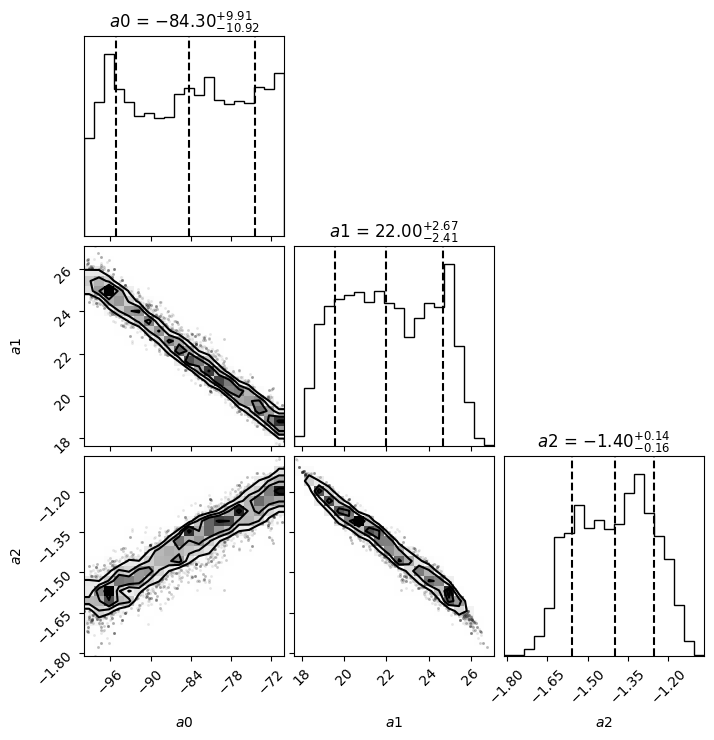

In [41]:
import corner
fig = corner.corner(sampler_R3N2.flatchain[burn:, [0, 1, 2]],
                   labels=['$a0$','$a1$', '$a2$'],
                    #range=(0.9, 0.9, 0.9),
                    quantiles=[0.16, 0.5, 0.84],
                    show_titles=True)

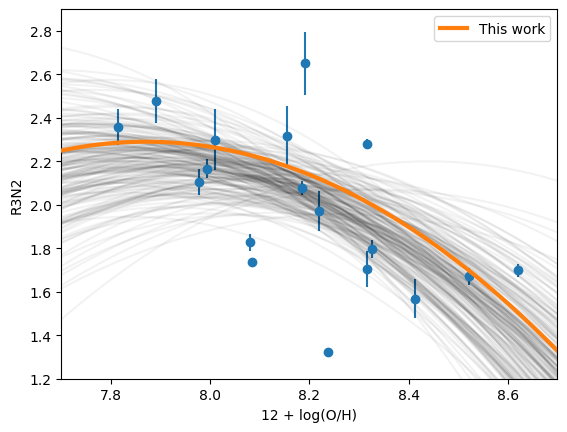

In [42]:
plt.errorbar(metals['log_OH'], upy.nominal_values(R3N2), 10*upy.std_devs(R3N2),
            ls='', fmt='o')
#plt.plot(log_OH_tp,  -30.024 + 7.801 * log_OH_tp -0.493 * log_OH_tp**2)
plt.ylabel('R3N2')
plt.xlabel('12 + log(O/H)')
plt.ylim(1.2, 2.9)
plt.xlim(7.7, 8.7)

best_a0_R3N2 = np.nanpercentile(sampler_R3N2.flatchain[burn:,0], 50)
best_a1_R3N2 = np.nanpercentile(sampler_R3N2.flatchain[burn:,1], 50)
best_a2_R3N2 = np.nanpercentile(sampler_R3N2.flatchain[burn:,2], 50)

plt.plot(log_OH_tp, best_a0_R3N2 + best_a1_R3N2 * log_OH_tp + best_a2_R3N2 * log_OH_tp**2, lw=3, zorder=10, label='This work')
plt.legend()

for i in np.random.randint(0, high=len(sampler_R3N2.flatchain), size=200):
    a0, a1, a2 = sampler_R3N2.flatchain[i, [0, 1, 2]]
    plt.plot(log_OH_tp, a0 + a1 * log_OH_tp + a2 * log_OH_tp**2, color='k', alpha=0.05)

## Fitting N2O2

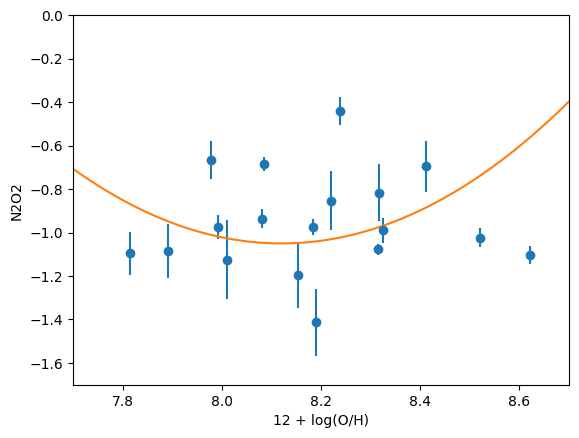

In [43]:
plt.errorbar(metals['log_OH'], upy.nominal_values(N2O2), 10*upy.std_devs(N2O2),
            ls='', fmt='o')
plt.ylabel('N2O2')
plt.xlabel('12 + log(O/H)')

plt.ylim(-1.7, 0.0)
plt.xlim(7.7, 8.7)

plt.plot(log_OH_tp,  127.138 - 31.572  * log_OH_tp + 1.944 * log_OH_tp**2)

In [44]:
def ln_prior_N2O2(theta):
    a0, a1, a2, s, Pb, Yb, logVb = theta
    if 80 < a0 < 180 and -60 < a1 < 0 and 1.0 < a2 < 3.0 and 0 < s < 1 and 0 < Pb < 1 and 0 < Yb < 2000 and -2 < logVb < 10:
        return 0
    return -np.inf

def ln_likelihood_N2O2(theta, x, y, yerr):
    a0, a1, a2, s, Pb, Yb, logVb = theta
    Vb = 10**(logVb)
    model = a0 + a1 * x + a2 * x**2
    p_fg = (1 - Pb) / np.sqrt(2 * np.pi * (yerr**2 + s**2)) * np.exp(-(y - model)**2/(2 * (yerr**2 + s**2)))
    p_bg = Pb / np.sqrt(2 * np.pi * (Vb + yerr**2 + s**2)) * np.exp(-(y - Yb)**2/(2 * (Vb + yerr**2 + s**2)))
    output = np.sum(np.log(p_fg + p_bg))
    return output

def ln_posterior_N2O2(theta, x, y, err):
    ln_p = ln_prior_N2O2(theta)
    if not np.isfinite(ln_p):
        return -np.inf
    return ln_p + ln_likelihood_N2O2(theta, x, y, err)

In [45]:
np.random.seed(6563)

theta_N2O2 = np.array([127.138, -31.572, 1.944, 0.1, 0.3, 400, 1.0])

ndim, nwalkers = 7, 100
steps = 10000
burn = int(0.99 * steps * nwalkers)
pos_N2O2 = [theta_N2O2 + 0.1*np.random.randn(ndim) for i in range(nwalkers)]

sampler_N2O2 = emcee.EnsembleSampler(nwalkers, ndim, ln_posterior_N2O2,
                                   args=(metals['log_OH'].values,
                                         upy.nominal_values(N2O2),
                                         upy.std_devs(N2O2)), threads=8)

In [46]:
%timeit -n1 -r1 sampler_N2O2.run_mcmc(pos_N2O2, steps, store=True)

/tmp/ipykernel_180522/1375142351.py:13: RuntimeWarning: divide by zero encountered in log
  output = np.sum(np.log(p_fg + p_bg))


24.4 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


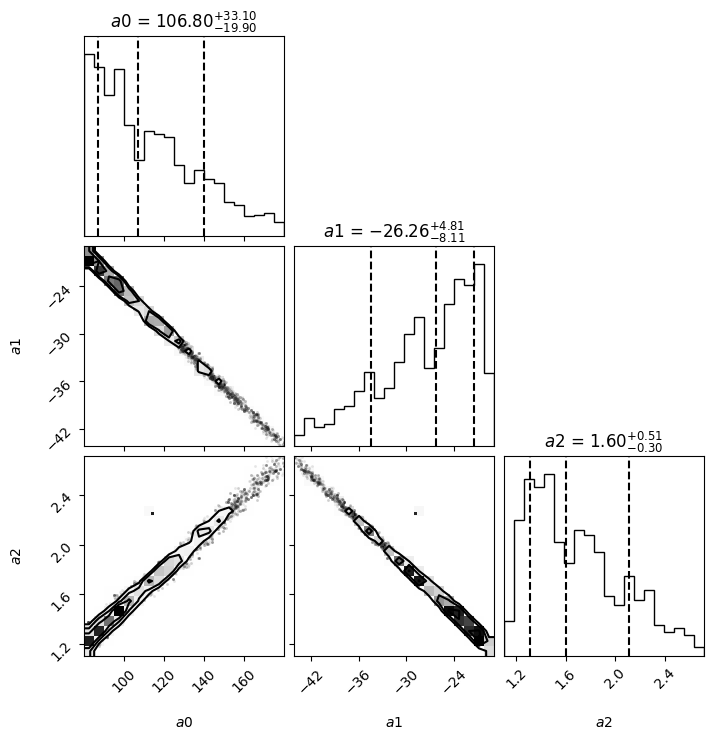

In [47]:
import corner
fig = corner.corner(sampler_N2O2.flatchain[burn:, [0, 1, 2]],
                   labels=['$a0$','$a1$', '$a2$'],
                    #range=(0.9, 0.9, 0.9),
                    quantiles=[0.16, 0.5, 0.84],
                    show_titles=True)

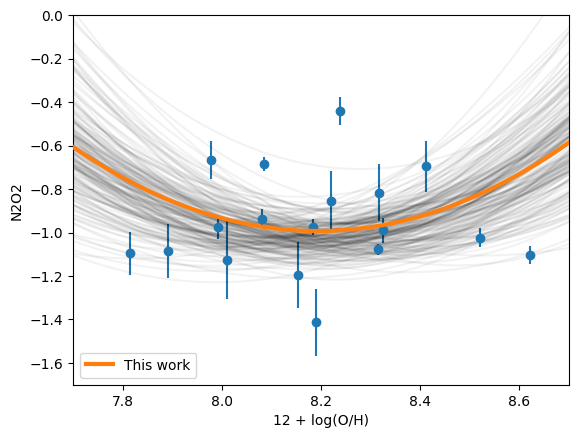

In [48]:
plt.errorbar(metals['log_OH'], upy.nominal_values(N2O2), 10*upy.std_devs(N2O2),
            ls='', fmt='o')
#plt.plot(log_OH_tp,  -30.024 + 7.801 * log_OH_tp -0.493 * log_OH_tp**2)
plt.ylabel('N2O2')
plt.xlabel('12 + log(O/H)')
plt.ylim(-1.7, 0.0)
plt.xlim(7.7, 8.7)

best_a0_N2O2 = np.nanpercentile(sampler_N2O2.flatchain[:,0], 50)
best_a1_N2O2 = np.nanpercentile(sampler_N2O2.flatchain[:,1], 50)
best_a2_N2O2 = np.nanpercentile(sampler_N2O2.flatchain[:,2], 50)

plt.plot(log_OH_tp, best_a0_N2O2 + best_a1_N2O2 * log_OH_tp + best_a2_N2O2 * log_OH_tp**2, lw=3, zorder=10, label='This work')
plt.legend()

for i in np.random.randint(0, high=len(sampler_N2O2.flatchain), size=200):
    a0, a1, a2 = sampler_N2O2.flatchain[i, [0, 1, 2]]
    plt.plot(log_OH_tp, a0 + a1 * log_OH_tp + a2 * log_OH_tp**2, color='k', alpha=0.05)

## Fitting N2S2

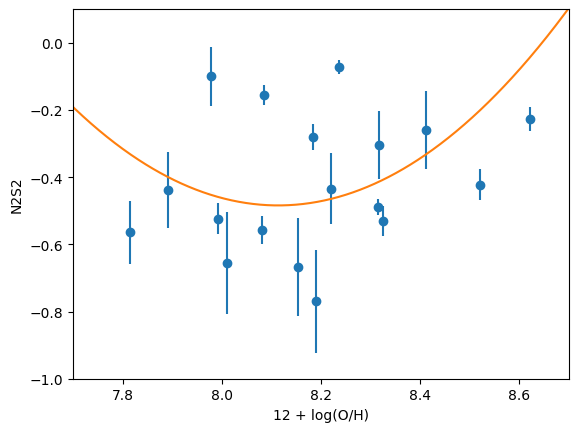

In [49]:
plt.errorbar(metals['log_OH'], upy.nominal_values(N2S2), 10*upy.std_devs(N2S2),
            ls='', fmt='o')
plt.ylabel('N2S2')
plt.xlabel('12 + log(O/H)')

plt.ylim(-1.0, 0.1)
plt.xlim(7.7, 8.7)

plt.plot(log_OH_tp,  112.162 - 27.766  * log_OH_tp + 1.711 * log_OH_tp**2)

In [50]:
def ln_prior_N2S2(theta):
    a0, a1, a2, s, Pb, Yb, logVb = theta
    if 80 < a0 < 130 and -30 < a1 < -15 and 1.0 < a2 < 2.0 and 0 < s < 1 and 0 < Pb < 1 and 0 < Yb < 2000 and -2 < logVb < 10:
        return 0
    return -np.inf

def ln_likelihood_N2S2(theta, x, y, yerr):
    a0, a1, a2, s, Pb, Yb, logVb = theta
    Vb = 10**(logVb)
    model = a0 + a1 * x + a2 * x**2
    p_fg = (1 - Pb) / np.sqrt(2 * np.pi * (yerr**2 + s**2)) * np.exp(-(y - model)**2/(2 * (yerr**2 + s**2)))
    p_bg = Pb / np.sqrt(2 * np.pi * (Vb + yerr**2 + s**2)) * np.exp(-(y - Yb)**2/(2 * (Vb + yerr**2 + s**2)))
    output = np.sum(np.log(p_fg + p_bg))
    return output

def ln_posterior_N2S2(theta, x, y, err):
    ln_p = ln_prior_N2S2(theta)
    if not np.isfinite(ln_p):
        return -np.inf
    return ln_p + ln_likelihood_N2S2(theta, x, y, err)

In [51]:
np.random.seed(6563)

theta_N2S2 = np.array([112.162, -27.766, 1.711, 0.1, 0.3, 400, 1.0])

ndim, nwalkers = 7, 100
steps = 10000
burn = int(0.99 * steps * nwalkers)
pos_N2S2 = [theta_N2S2 + 0.0464*np.random.randn(ndim) for i in range(nwalkers)]

sampler_N2S2 = emcee.EnsembleSampler(nwalkers, ndim, ln_posterior_N2S2,
                                     args=(metals['log_OH'].values,
                                             upy.nominal_values(N2S2),
                                             upy.std_devs(N2S2)), threads=8)

In [52]:
%timeit -n1 -r1 sampler_N2S2.run_mcmc(pos_N2S2, steps, store=True)

/tmp/ipykernel_180522/1578703052.py:13: RuntimeWarning: divide by zero encountered in log
  output = np.sum(np.log(p_fg + p_bg))


24.5 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


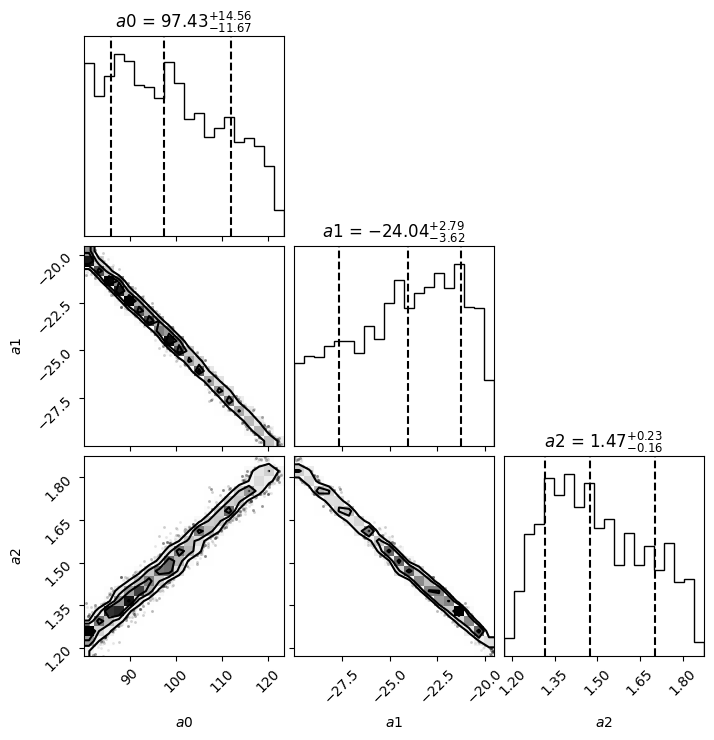

In [53]:
import corner
fig = corner.corner(sampler_N2S2.flatchain[burn:, [0, 1, 2]],
                   labels=['$a0$','$a1$', '$a2$'],
                    #range=(0.9, 0.9, 0.9),
                    quantiles=[0.16, 0.5, 0.84],
                    show_titles=True)

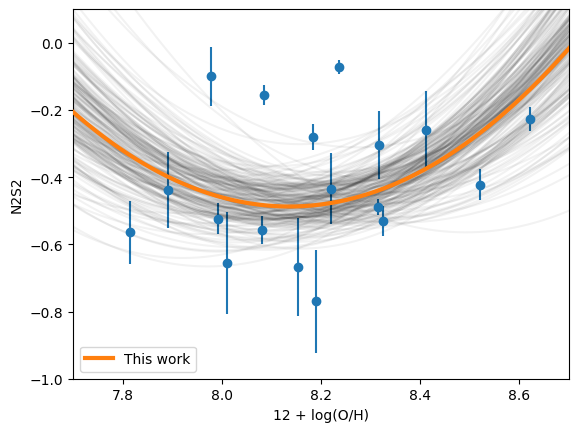

In [54]:
plt.errorbar(metals['log_OH'], upy.nominal_values(N2S2), 10*upy.std_devs(N2S2),
            ls='', fmt='o')
#plt.plot(log_OH_tp,  -30.024 + 7.801 * log_OH_tp -0.493 * log_OH_tp**2)
plt.ylabel('N2S2')
plt.xlabel('12 + log(O/H)')
plt.ylim(-1.0, 0.1)
plt.xlim(7.7, 8.7)

best_a0_N2S2 = np.nanpercentile(sampler_N2S2.flatchain[:,0], 50)
best_a1_N2S2 = np.nanpercentile(sampler_N2S2.flatchain[:,1], 50)
best_a2_N2S2 = np.nanpercentile(sampler_N2S2.flatchain[:,2], 50)

plt.plot(log_OH_tp, best_a0_N2S2 + best_a1_N2S2 * log_OH_tp + best_a2_N2S2 * log_OH_tp**2, lw=3, zorder=10, label='This work')
plt.legend()

for i in np.random.randint(0, high=len(sampler_N2S2.flatchain), size=200):
    a0, a1, a2 = sampler_N2S2.flatchain[i, [0, 1, 2]]
    plt.plot(log_OH_tp, a0 + a1 * log_OH_tp + a2 * log_OH_tp**2, color='k', alpha=0.05)

# Solutions

In [10]:
# Linear relations
slope_N2, int_N2 = np.mean(lm_n2.chain['beta']), np.mean(lm_n2.chain['alpha'])
slope_O3N2, int_O3N2 = np.mean(lm_o3n2.chain['beta']), np.mean(lm_o3n2.chain['alpha'])

In [55]:
# Linear relations
slope_N2, int_N2 = np.mean(lm_n2.chain['beta']), np.mean(lm_n2.chain['alpha'])
slope_O3N2, int_O3N2 = np.mean(lm_o3n2.chain['beta']), np.mean(lm_o3n2.chain['alpha'])
slope_O3O2, int_O3O2 = np.mean(lm_o3o2.chain['beta']), np.mean(lm_o3o2.chain['alpha'])
slope_Ne3O2, int_Ne3O2 = np.mean(lm_ne3o2.chain['beta']), np.mean(lm_ne3o2.chain['alpha'])
slope_S2, int_S2 = np.mean(lm_s2.chain['beta']), np.mean(lm_s2.chain['alpha'])
slope_O3S2, int_O3S2 = np.mean(lm_o3s2.chain['beta']), np.mean(lm_o3s2.chain['alpha'])

# Polynomial
a0_R3, a1_R3, a2_R3 = best_a0_R3, best_a1_R3, best_a2_R3
a0_R2, a1_R2, a2_R2 = best_a0_R2, best_a1_R2, best_a2_R2
a0_R23, a1_R23, a2_R23 = best_a0_R23, best_a1_R23, best_a2_R23
a0_R3N2, a1_R3N2, a2_R3N2 = best_a0_R3N2, best_a1_R3N2, best_a2_R3N2
a0_N2O2, a1_N2O2, a2_N2O2 = best_a0_N2O2, best_a1_N2O2, best_a2_N2O2
a0_N2S2, a1_N2S2, a2_N2S2 = best_a0_N2S2, best_a1_N2S2, best_a2_N2S2

In [56]:
# Intrinsic sigma
sigint_N2 = np.sqrt(np.mean(lm_n2.chain['sigsqr']))
sigint_O3N2 = np.sqrt(np.mean(lm_o3n2.chain['sigsqr']))
sigint_O3O2 = np.sqrt(np.mean(lm_o3o2.chain['sigsqr']))
sigint_Ne3O2 = np.sqrt(np.mean(lm_ne3o2.chain['sigsqr']))
sigint_S2 = np.sqrt(np.mean(lm_s2.chain['sigsqr']))
sigint_O3S2 = np.sqrt(np.mean(lm_o3s2.chain['sigsqr']))

sigint_R2 = np.percentile(sampler_R2.flatchain[:,3], 50)
sigint_R3 = np.percentile(sampler_R3.flatchain[:,3], 50)
sigint_R23 = np.percentile(sampler_R23.flatchain[:,3], 50)
sigint_R3N2 = np.percentile(sampler_R3N2.flatchain[:,3], 50)
sigint_N2O2 = np.percentile(sampler_N2O2.flatchain[:,3], 50)
sigint_N2S2 = np.percentile(sampler_N2S2.flatchain[:,3], 50)

In [57]:
# Scatter sigma

sig_N2 = np.std(upy.nominal_values(N2) - linear(metals['log_OH'].values, int_N2, slope_N2))
sig_O3N2 = np.std(upy.nominal_values(O3N2) - linear(metals['log_OH'].values, int_O3N2, slope_O3N2))
sig_O3O2 = np.std(upy.nominal_values(O3O2) - linear(metals['log_OH'].values, int_O3O2, slope_O3O2))
sig_Ne3O2 = np.std(upy.nominal_values(Ne3O2) - linear(metals['log_OH'].values, int_Ne3O2, slope_Ne3O2))
sig_S2 = np.std(upy.nominal_values(S2) - linear(metals['log_OH'].values, int_S2, slope_S2))
sig_O3S2 = np.std(upy.nominal_values(O3S2) - linear(metals['log_OH'].values, int_O3S2, slope_O3S2))

sig_R2 = np.std(upy.nominal_values(R2) - poly2(metals['log_OH'].values, a0_R2, a1_R2, a2_R2))
sig_R3 = np.std(upy.nominal_values(R3) - poly2(metals['log_OH'].values, a0_R3, a1_R3, a2_R3))
sig_R23 = np.std(upy.nominal_values(R23) - poly2(metals['log_OH'].values, a0_R23, a1_R23, a2_R23))
sig_R3N2 = np.std(upy.nominal_values(R3N2) - poly2(metals['log_OH'].values, a0_R3N2, a1_R3N2, a2_R3N2))
sig_N2O2 = np.std(upy.nominal_values(N2O2) - poly2(metals['log_OH'].values, a0_N2O2, a1_N2O2, a2_N2O2))
sig_N2S2 = np.std(upy.nominal_values(N2S2) - poly2(metals['log_OH'].values, a0_N2S2, a1_N2S2, a2_N2S2))

In [58]:
calib_dict = {'Ratio': ['N2', 'R2', 'R3', 'R23', 'O3N2', 'R3N2', 'N2O2', 'O3O2', 'Ne3O2', 'S2', 'O3S2', 'N2S2'],
             'a0': [int_N2, a0_R2, a0_R3, a0_R23,
                    int_O3N2, a0_R3N2, a0_N2O2,
                    int_O3O2, int_Ne3O2, int_S2,
                    int_O3S2, a0_N2S2],
             'a1': [slope_N2, a1_R2, a1_R3, a1_R23,
                    slope_O3N2, a1_R3N2, a1_N2O2,
                    slope_O3O2, slope_Ne3O2, slope_S2,
                    slope_O3S2, a1_N2S2],
             'a2': [None, a2_R2, a2_R3, a2_R23,
                    None, a2_R3N2, a2_N2O2,
                    None, None, None,
                    None, a2_N2S2],
              'sigma': [sig_N2, sig_R2, sig_R3, sig_R23, sig_O3N2, sig_R3N2,
                        sig_N2O2, sig_O3O2, sig_Ne3O2, sig_S2, sig_O3S2, sig_N2S2],
              'sigma_int': [sigint_N2, sigint_R2, sigint_R3, sigint_R23, sigint_O3N2, sigint_R3N2,
                            sigint_N2O2, sigint_O3O2, sigint_Ne3O2, sigint_S2, sigint_O3S2, sigint_N2S2]
}

calib_dict_pd = pd.DataFrame(data=calib_dict, index=None)
calib_dict_pd.to_latex(index=None, float_format='%.3f')

'\\begin{tabular}{llrrrrr}\n\\toprule\n & Ratio & a0 & a1 & a2 & sigma & sigma_int \\\\\n\\midrule\n0 & N2 & -8.112 & 0.790 & NaN & 0.227 & 0.278 \\\\\n1 & R2 & -151.672 & 36.458 & -2.187 & 0.180 & 0.198 \\\\\n2 & R3 & -28.775 & 7.413 & -0.464 & 0.060 & 0.067 \\\\\n3 & R23 & -1.677 & 0.746 & -0.051 & 0.045 & 0.055 \\\\\n4 & O3N2 & 10.586 & -0.994 & NaN & 0.270 & 0.330 \\\\\n5 & R3N2 & -84.296 & 22.002 & -1.398 & 0.297 & 0.333 \\\\\n6 & N2O2 & 105.545 & -26.006 & 1.587 & 0.254 & 0.289 \\\\\n7 & O3O2 & 8.199 & -0.918 & NaN & 0.141 & 0.173 \\\\\n8 & Ne3O2 & 6.491 & -0.838 & NaN & 0.155 & 0.190 \\\\\n9 & S2 & -5.901 & 0.571 & NaN & 0.148 & 0.183 \\\\\n10 & O3S2 & 8.292 & -0.765 & NaN & 0.190 & 0.232 \\\\\n11 & N2S2 & 97.508 & -24.089 & 1.480 & 0.201 & 0.225 \\\\\n\\bottomrule\n\\end{tabular}\n'

In [59]:
calib_dict_pd

,Ratio,a0,a1,a2,sigma,sigma_int
0,N2,-8.111672,0.789939,NaN,0.226902,0.277918
1,R2,-151.671901,36.457640,-2.186688,0.180299,0.198035
2,R3,-28.774926,7.412670,-0.463943,0.059778,0.067463
3,R23,-1.676667,0.746114,-0.051223,0.044616,0.055056
4,O3N2,10.585990,-0.993953,NaN,0.270178,0.330103
5,R3N2,-84.295821,22.002452,-1.397766,0.297269,0.333492
6,N2O2,105.544559,-26.005601,1.586979,0.254014,0.289137
7,O3O2,8.198524,-0.918165,NaN,0.141042,0.173193
8,Ne3O2,6.490891,-0.838309,NaN,0.154972,0.189556
9,S2,-5.901193,0.571466,NaN,0.148331,0.182554


# Metallicity Calibrations

In [60]:
help(linear)

Help on function linear in module __main__:

linear(x, a0, a1)



In [61]:
help(poly2)

Help on function poly2 in module __main__:

poly2(x, a0, a1, a2)



## All fits

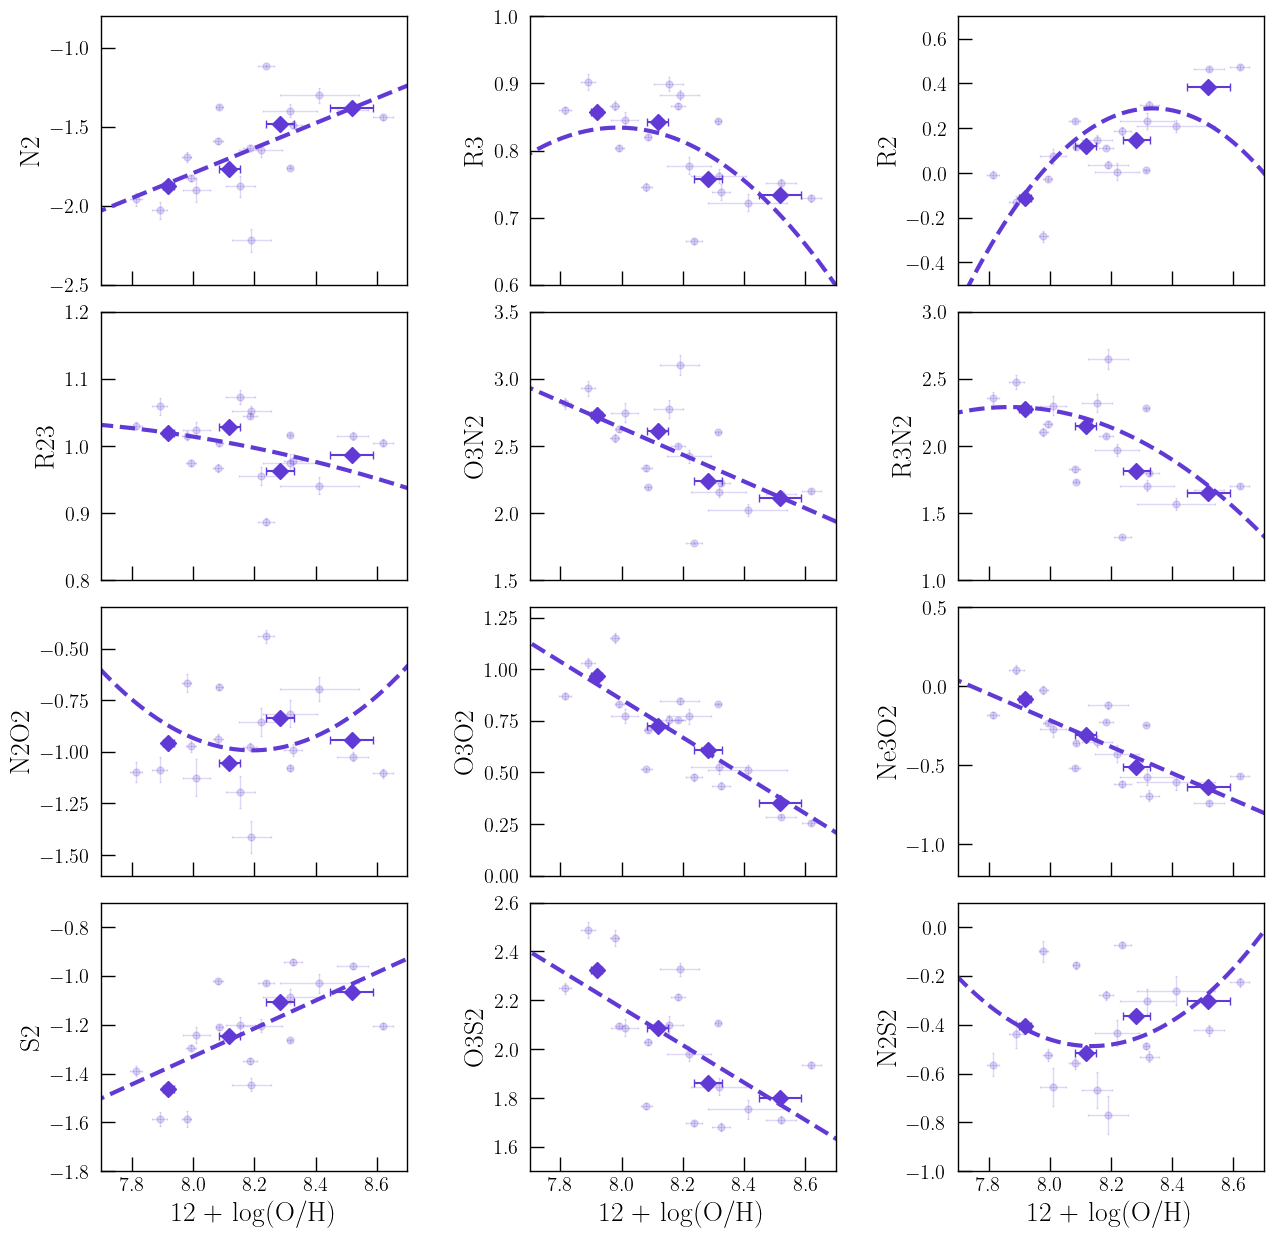

In [62]:
texPlot('on')
fig, axs = plt.subplots(4, 3, sharex=True)
fig.set_size_inches((15, 15))
fig.subplots_adjust(wspace=0.4, hspace=0.1)

# ===========================================================================================================
# N2
# ===========================================================================================================

axs[0, 0].errorbar(metals['log_OH'], upy.nominal_values(N2), xerr=2*log_OH_err, yerr=5*upy.std_devs(N2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 0].plot(log_OH_tp, linear(log_OH_tp, int_N2, slope_N2), color=c[2], ls='--', lw=3)
axs[0, 0].set_ylabel('N2')

# ===========================================================================================================
# R3
# ===========================================================================================================

axs[0, 1].errorbar(metals['log_OH'], upy.nominal_values(R3), xerr=2*log_OH_err, yerr=5*upy.std_devs(R3), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R3),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R3),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 1].plot(log_OH_tp, poly2(log_OH_tp, a0_R3, a1_R3, a2_R3), color=c[2], ls='--', lw=3)
axs[0, 1].set_ylabel('R3')

# ===========================================================================================================
# R2
# ===========================================================================================================

axs[0, 2].errorbar(metals['log_OH'], upy.nominal_values(R2), xerr=2*log_OH_err, yerr=5*upy.std_devs(R2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 2].plot(log_OH_tp, poly2(log_OH_tp, a0_R2, a1_R2, a2_R2), color=c[2], ls='--', lw=3)
axs[0, 2].set_ylabel('R2')

# ===========================================================================================================
# R23
# ===========================================================================================================

axs[1, 0].errorbar(metals['log_OH'], upy.nominal_values(R23), xerr=2*log_OH_err, yerr=5*upy.std_devs(R23), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[1, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R23),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R23),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 0].plot(log_OH_tp, poly2(log_OH_tp, a0_R23, a1_R23, a2_R23), color=c[2], ls='--', lw=3)
axs[1, 0].set_ylabel('R23')

# ===========================================================================================================
# O3N2
# ===========================================================================================================

axs[1, 1].errorbar(metals['log_OH'], upy.nominal_values(O3N2), xerr=2*log_OH_err, yerr=5*upy.std_devs(O3N2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[1, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3N2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_O3N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 1].plot(log_OH_tp, linear(log_OH_tp, int_O3N2, slope_O3N2), color=c[2], ls='--', lw=3)
axs[1, 1].set_ylabel('O3N2')

# ===========================================================================================================
# R3N2
# ===========================================================================================================

axs[1, 2].errorbar(metals['log_OH'], upy.nominal_values(R3N2), xerr=2*log_OH_err, yerr=5*upy.std_devs(R3N2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[1, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R3N2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R3N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 2].plot(log_OH_tp, poly2(log_OH_tp, a0_R3N2, a1_R3N2, a2_R3N2), color=c[2], ls='--', lw=3)
axs[1, 2].set_ylabel('R3N2')


# ===========================================================================================================
# N2O2
# ===========================================================================================================

axs[2, 0].errorbar(metals['log_OH'], upy.nominal_values(N2O2), xerr=2*log_OH_err, yerr=5*upy.std_devs(N2O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[2, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2O2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_N2O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 0].plot(log_OH_tp, poly2(log_OH_tp, a0_N2O2, a1_N2O2, a2_N2O2), color=c[2], ls='--', lw=3)
axs[2, 0].set_ylabel('N2O2')

# ===========================================================================================================
# O3O2
# ===========================================================================================================

axs[2, 1].errorbar(metals['log_OH'], upy.nominal_values(O3O2), xerr=2*log_OH_err, yerr=5*upy.std_devs(O3O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[2, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3O2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_O3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 1].plot(log_OH_tp, linear(log_OH_tp, int_O3O2, slope_O3O2), color=c[2], ls='--', lw=3)
axs[2, 1].set_ylabel('O3O2')

# ===========================================================================================================
# Ne3O2
# ===========================================================================================================

axs[2, 2].errorbar(metals['log_OH'], upy.nominal_values(Ne3O2), xerr=2*log_OH_err, yerr=5*upy.std_devs(Ne3O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[2, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_Ne3O2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_Ne3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 2].plot(log_OH_tp, linear(log_OH_tp, int_Ne3O2, slope_Ne3O2), color=c[2], ls='--', lw=3)
axs[2, 2].set_ylabel('Ne3O2')

# ===========================================================================================================
# S2
# ===========================================================================================================

axs[3, 0].errorbar(metals['log_OH'], upy.nominal_values(S2), xerr=2*log_OH_err, yerr=5*upy.std_devs(S2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[3, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_S2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_S2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[3, 0].plot(log_OH_tp, linear(log_OH_tp, int_S2, slope_S2), color=c[2], ls='--', lw=3)
axs[3, 0].set_ylabel('S2')

# ===========================================================================================================
# O3S2
# ===========================================================================================================

axs[3, 1].errorbar(metals['log_OH'], upy.nominal_values(O3S2), xerr=2*log_OH_err, yerr=5*upy.std_devs(O3S2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[3, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3S2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_O3S2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[3, 1].plot(log_OH_tp, linear(log_OH_tp, int_O3S2, slope_O3S2), color=c[2], ls='--', lw=3)
axs[3, 1].set_ylabel('O3S2')

# ===========================================================================================================
# N2S2
# ===========================================================================================================

axs[3, 2].errorbar(metals['log_OH'], upy.nominal_values(N2S2), xerr=2*log_OH_err, yerr=5*upy.std_devs(N2S2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[3, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2S2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_N2S2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[3, 2].plot(log_OH_tp, poly2(log_OH_tp, a0_N2S2, a1_N2S2, a2_N2S2), color=c[2], ls='--', lw=3)
axs[3, 2].set_ylabel('N2S2')

# ===========================================================================================================
# General settings
# ===========================================================================================================

axs[3, 0].set_xlabel(r'12 + log(O/H)')
axs[3, 1].set_xlabel(r'12 + log(O/H)')
axs[3, 2].set_xlabel(r'12 + log(O/H)')

# limits
# x
axs[0, 0].set_xlim(7.7, 8.7) 

# y
axs[0, 0].set_ylim(-2.5, -0.8) # N2
axs[0, 1].set_ylim(0.6, 1.0) # R3
axs[0, 2].set_ylim(-0.5, 0.7) # R2

axs[1, 0].set_ylim(0.8, 1.2) # R23
axs[1, 1].set_ylim(1.5, 3.5) # O3N2
axs[1, 2].set_ylim(1, 3) # R3N2

axs[2, 0].set_ylim(-1.6, -0.3) # N2O2
axs[2, 1].set_ylim(0, 1.3) # O3O2
axs[2, 2].set_ylim(-1.2, 0.5) # Ne3O2

axs[3, 0].set_ylim(-1.8, -0.7) # S2
axs[3, 1].set_ylim(1.5, 2.6) # O3S2
axs[3, 2].set_ylim(-1.0, 0.1) # N2S2


index_model = [0, 1, 2, 3]
index_sec = [0, 1, 2]
for i in index_model:
    for j in index_sec:
        axs[i, j].tick_params(axis="y", direction="in", length=10)
        axs[i, j].tick_params(axis="x", direction="in", length=10)
        
#fig.savefig(magePath+'analysis/chapter4/calibrations.pdf', bbox_inches='tight')

## Local relations

In [63]:
# Functions

def denicolo2002_N2(log_OH_12):
    N2 = (log_OH_12 - 9.12) / 0.73
    return N2


def tremonti2004_R23(R23):
    log_OH_12 = 9.185 - (0.313 * R23) - (0.264 * (R23**2)) - (0.321 * (R23**3)) 
    return log_OH_12


def pettini_pagel2004_O3N2(log_OH_12):
    O3N2 = - (log_OH_12 - 8.73) / 0.32
    return O3N2


def pettini_pagel2004_N2(N2):
    log_OH_12 = 9.37 + (2.03 * N2) + (1.26 * (N2**2)) + (0.32 * (N2**3))
    return log_OH_12


def nagao2006(log_OH_12, ratio='asd'):
    if ratio == 'R23':
        b0 = 1.2299
        b1 = -4.1926
        b2 = 1.0246
        b3 = -0.063169
    if ratio == 'N2':
        b0 = 96.641
        b1 = -39.941
        b2 = 5.2227
        b3 = -0.22040
    if ratio == 'R3N2':
        b0 = -232.18
        b1 = 84.423
        b2 = -9.9330
        b3 = 0.37941
    if ratio == 'N2O2':
        b0 = -128.94
        b1 = 48.818
        b2 = -6.2759
        b3 = 0.27101
    if ratio == 'O3O2':
        b0 = -1.4089
        b1 = 1.3745
        b2 = -0.14359
        b3 = 0
    return b0 + (b1 * log_OH_12) + (b2 * (log_OH_12**2)) + (b3 * (log_OH_12**3))

def maiolino2008(log_OH_12, ratio='asd'):
    x = (log_OH_12 - 8.69)
    if ratio == 'R23':
        c0 = 0.7462
        c1 = -0.7149
        c2 = -0.9401
        c3 = -0.6154
        c4 = -0.2524
    if ratio == 'N2':
        c0 = -0.7732
        c1 = 1.2357
        c2 = -0.2811
        c3 = -0.7201
        c4 = -0.3330
    if ratio == 'R3':
        c0 = 0.1549
        c1 = -1.5031
        c2 = -0.9790
        c3 = -0.0297
        c4 = 0.0
    if ratio == 'O3O2':
        c0 = -0.2839
        c1 = -1.3881
        c2 = -0.3172
        c3 = 0.0
        c4 = 0.0
    if ratio == 'R2':
        c0 = 0.5603
        c1 = 0.0450
        c2 = -1.8017
        c3 = -1.8434
        c4 = -0.6549
    if ratio == 'R3N2':
        c0 = 0.4520
        c1 = -2.6096
        c2 = -0.7170
        c3 = 0.1347
        c4 = 0.0
    if ratio == 'Ne3O2':
        c0 = -1.2608
        c1 = -1.0861
        c2 = -0.1470
        c3 = 0.0
        c4 = 0.0
    return c0 + (c1 * x) + (c2 * (x**2)) + (c3 * (x**3)) + (c4 * (x**4))


def marino2013_N2(log_OH_12):
    N2 = (log_OH_12 - 8.743) / 0.462
    return N2


def marino2013_O3N2(log_OH_12):
    O3N2 = - (log_OH_12 - 8.533) / 0.214
    return O3N2


def curti2020(log_OH_12, ratio='asd'):
    x = (log_OH_12 - 8.69)
    if ratio == 'R2':
        c0 = 0.435
        c1 = -1.362
        c2 = -5.655
        c3 = -4.851
        c4 = -0.478
        c5 = 0.736
    if ratio == 'R3':
        c0 = -0.277
        c1 = -3.549
        c2 = -3.593
        c3 = -0.981
        c4 = 0.0
        c5 = 0.0
    if ratio == 'O3O2':
        c0 = -0.691
        c1 = -2.944
        c2 = -1.308
        c3 = 0.0
        c4 = 0.0
        c5 = 0.0
    if ratio == 'R23':
        c0 = 0.527
        c1 = -1.569
        c2 = -1.652
        c3 = -0.421
        c4 = 0.0
        c5 = 0.0
    if ratio == 'N2':
        c0 = -0.489
        c1 = 1.513
        c2 = -2.554
        c3 = -5.293
        c4 = -2.867
        c5 = 0.0
    if ratio == 'O3N2':
        c0 = 0.281
        c1 = -4.765
        c2 = -2.268
        c3 = 0.0
        c4 = 0.0
        c5 = 0.0
    if ratio == 'S2':
        c0 = -0.442
        c1 = -0.360
        c2 = -6.271
        c3 = -8.339
        c4 = -3.559
        c5 = 0.0
    if ratio == 'O3S2':
        c0 = 0.191
        c1 = -4.292
        c2 = -2.538
        c3 = 0.053
        c4 = 0.332
        c5 = 0.0
    return c0 + (c1 * x) + (c2 * (x**2)) + (c3 * (x**3)) + (c4 * (x**4)) + (c5 * (x**5))

def sanders2021(log_OH_12, ratio='asd'):
    x = (log_OH_12 - 8.69)
    if ratio == 'R3':
        c0 = -0.143
        c1 = -3.16
        c2 = -4.06
        c3 = -1.49
    if ratio == 'R2':
        c0 = 0.27
        c1 = -0.452
        c2 = -0.52
        c3 = 0.0831
    if ratio == 'O3O2':
        c0 = -0.413
        c1 = -2.7
        c2 = -3.52
        c3 = -1.55
    if ratio == 'R23':
        c0 = 0.469
        c1 = -1.51
        c2 = -1.75
        c3 = -0.508
    if ratio == 'N2':
        c0 = -0.606
        c1 = 1.28
        c2 = -0.435
        c3 = -0.485
    if ratio == 'O3N2':
        c0 = 0.461
        c1 = -4.40
        c2 = -3.37
        c3 = -0.761
    return c0 + (c1 * x) + (c2 * (x**2)) + (c3 * (x**3))

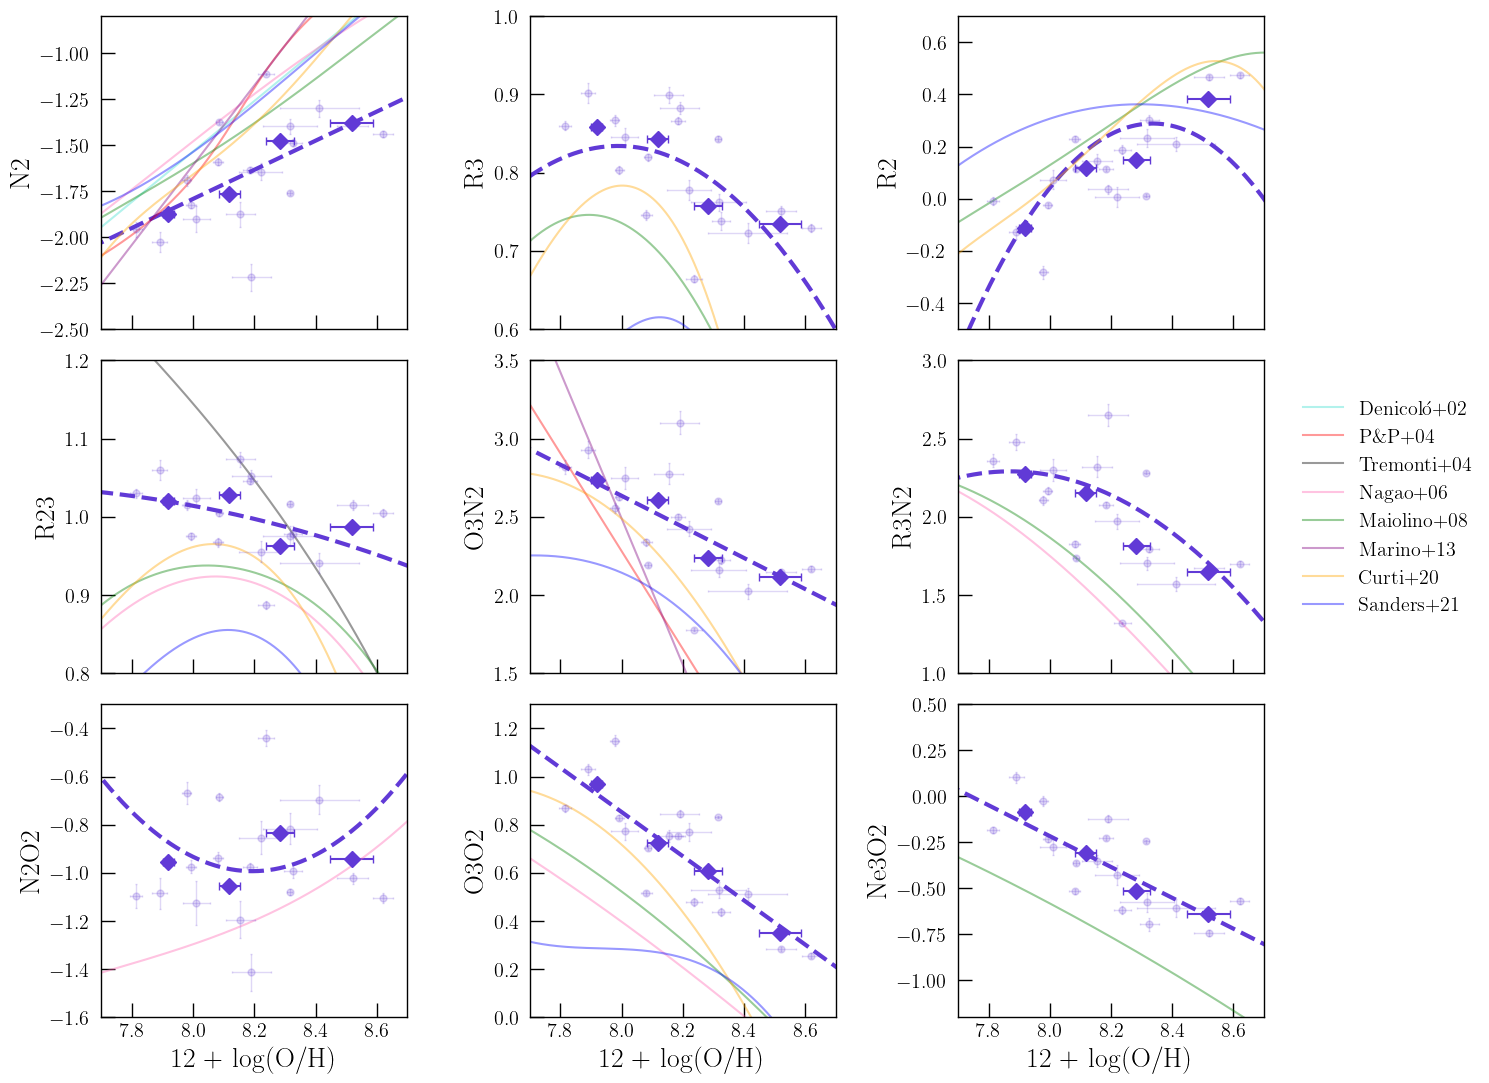

In [64]:
texPlot('on')
fig, axs = plt.subplots(3, 3, sharex=True)
fig.set_size_inches((15, 13))
fig.subplots_adjust(wspace=0.4, hspace=0.1)

# ===========================================================================================================
# N2 Ratio
# ===========================================================================================================

axs[0, 0].errorbar(metals['log_OH'], upy.nominal_values(N2), xerr=2*log_OH_err, yerr=5*upy.std_devs(N2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 0].plot(log_OH_tp, linear(log_OH_tp, int_N2, slope_N2), color=c[2], ls='--', lw=3)

# Relations
axs[0, 0].plot(log_OH_tp, denicolo2002_N2(log_OH_tp), label='Denicoló+02', color='turquoise', alpha=0.4)
axs[0, 0].plot(pettini_pagel2004_N2(N2_tp), N2_tp,
               label=r'P\&P+04', color='red', alpha=0.4)
axs[0, 0].plot(log_OH_tp, nagao2006(log_OH_tp, 'N2'), color='hotpink', alpha=0.4)
axs[0, 0].plot(log_OH_tp, maiolino2008(log_OH_tp, 'N2'), color='green', alpha=0.4)
axs[0, 0].plot(log_OH_tp, marino2013_N2(log_OH_tp), color='purple', alpha=0.4)
axs[0, 0].plot(log_OH_tp, curti2020(log_OH_tp, 'N2'), color='orange', alpha=0.4)
axs[0, 0].plot(log_OH_tp, sanders2021(log_OH_tp, 'N2'), color='blue', alpha=0.4)
axs[0, 0].set_ylabel('N2')


# ===========================================================================================================
# R3 Ratio
# ===========================================================================================================

axs[0, 1].errorbar(metals['log_OH'], upy.nominal_values(R3), xerr=2*log_OH_err, yerr=5*upy.std_devs(R3), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R3),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R3),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 1].plot(log_OH_tp, poly2(log_OH_tp, a0_R3, a1_R3, a2_R3), color=c[2], ls='--', lw=3)

# Relations
axs[0, 1].plot(log_OH_tp, maiolino2008(log_OH_tp, 'R3'), label='Maiolino+08', color='green', alpha=0.4)
axs[0, 1].plot(log_OH_tp, curti2020(log_OH_tp, 'R3'), label='Curti+20', color='orange', alpha=0.4)
axs[0, 1].plot(log_OH_tp, sanders2021(log_OH_tp, 'R3'), label='Sanders+21', color='blue', alpha=0.4)
axs[0, 1].set_ylabel('R3')

# ===========================================================================================================
# R2 Ratio
# ===========================================================================================================

axs[0, 2].errorbar(metals['log_OH'], upy.nominal_values(R2), xerr=2*log_OH_err, yerr=5*upy.std_devs(R2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 2].plot(log_OH_tp, poly2(log_OH_tp, a0_R2, a1_R2, a2_R2), color=c[2], ls='--', lw=3)

# Relations
axs[0, 2].plot(log_OH_tp, maiolino2008(log_OH_tp, 'R2'), label='Maiolino+2008', color='green', alpha=0.4)
axs[0, 2].plot(log_OH_tp, curti2020(log_OH_tp, 'R2'), label='Curti+2020', color='orange', alpha=0.4)
axs[0, 2].plot(log_OH_tp, sanders2021(log_OH_tp, 'R2'), label='Sanders+2021', color='blue', alpha=0.4)
axs[0, 2].set_ylabel('R2')

# ===========================================================================================================
# R23 Ratio
# ===========================================================================================================

axs[1, 0].errorbar(metals['log_OH'], upy.nominal_values(R23), xerr=2*log_OH_err, yerr=5*upy.std_devs(R23), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[1, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R23),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R23),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 0].plot(log_OH_tp, poly2(log_OH_tp, a0_R23, a1_R23, a2_R23), color=c[2], ls='--', lw=3)

# Relations
axs[1, 0].plot(tremonti2004_R23(R23_tp), R23_tp, label='Tremonti+04', color='black', alpha=0.4)
axs[1, 0].plot(log_OH_tp, nagao2006(log_OH_tp, 'R23'), color='hotpink', alpha=0.4)
axs[1, 0].plot(log_OH_tp, maiolino2008(log_OH_tp, 'R23'), color='green', alpha=0.4)
axs[1, 0].plot(log_OH_tp, curti2020(log_OH_tp, 'R23'), color='orange', alpha=0.4)
axs[1, 0].plot(log_OH_tp, sanders2021(log_OH_tp, 'R23'), color='blue', alpha=0.4)
axs[1, 0].set_ylabel('R23')

# ===========================================================================================================
# O3N2 Ratio
# ===========================================================================================================

axs[1, 1].errorbar(metals['log_OH'], upy.nominal_values(O3N2), xerr=2*log_OH_err, yerr=5*upy.std_devs(O3N2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[1, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3N2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_O3N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 1].plot(log_OH_tp, linear(log_OH_tp, int_O3N2, slope_O3N2), color=c[2], ls='--', lw=3)

# Relations
axs[1, 1].plot(log_OH_tp, pettini_pagel2004_O3N2(log_OH_tp), color='red', alpha=0.4)
axs[1, 1].plot(log_OH_tp, marino2013_O3N2(log_OH_tp), label='Marino+13', color='purple', alpha=0.4)
axs[1, 1].plot(log_OH_tp, curti2020(log_OH_tp, 'O3N2'), label='Curti+20', color='orange', alpha=0.4)
axs[1, 1].plot(log_OH_tp, sanders2021(log_OH_tp, 'O3N2'), label='Sanders+21', color='blue', alpha=0.4)
axs[1, 1].set_ylabel('O3N2')

# ===========================================================================================================
# R3N2 Ratio
# ===========================================================================================================

axs[1, 2].errorbar(metals['log_OH'], upy.nominal_values(R3N2), xerr=2*log_OH_err, yerr=5*upy.std_devs(R3N2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[1, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R3N2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R3N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 2].plot(log_OH_tp, poly2(log_OH_tp, a0_R3N2, a1_R3N2, a2_R3N2), color=c[2], ls='--', lw=3)

# Relations
axs[1, 2].plot(log_OH_tp, nagao2006(log_OH_tp, 'R3N2'), label='Nagao+06', color='hotpink', alpha=0.4)
axs[1, 2].plot(log_OH_tp, maiolino2008(log_OH_tp, 'R3N2'), label='Maiolino+08', color='green', alpha=0.4)
axs[1, 2].set_ylabel('R3N2')

# ===========================================================================================================
# N2O2 Ratio
# ===========================================================================================================

axs[2, 0].errorbar(metals['log_OH'], upy.nominal_values(N2O2), xerr=2*log_OH_err, yerr=5*upy.std_devs(N2O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[2, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2O2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_N2O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 0].plot(log_OH_tp, poly2(log_OH_tp, a0_N2O2, a1_N2O2, a2_N2O2), color=c[2], ls='--', lw=3)

# Relations
axs[2, 0].plot(log_OH_tp, nagao2006(log_OH_tp, 'N2O2'), label='Nagao+2006', color='hotpink', alpha=0.4)
axs[2, 0].set_ylabel('N2O2')

# ===========================================================================================================
# O3O2 Ratio
# ===========================================================================================================

axs[2, 1].errorbar(metals['log_OH'], upy.nominal_values(O3O2), xerr=2*log_OH_err, yerr=5*upy.std_devs(O3O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[2, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3O2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_O3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 1].plot(log_OH_tp, linear(log_OH_tp, int_O3O2, slope_O3O2), color=c[2], ls='--', lw=3)

# Relations
axs[2, 1].plot(log_OH_tp, nagao2006(log_OH_tp, 'O3O2'), label='Nagao+2006', color='hotpink', alpha=0.4)
axs[2, 1].plot(log_OH_tp, maiolino2008(log_OH_tp, 'O3O2'), label='Maiolino+2008', color='green', alpha=0.4)
axs[2, 1].plot(log_OH_tp, curti2020(log_OH_tp, 'O3O2'), label='Curti+2020', color='orange', alpha=0.4)
axs[2, 1].plot(log_OH_tp, sanders2021(log_OH_tp, 'O3O2'), label='Sanders+2021', color='blue', alpha=0.4)
axs[2, 1].set_ylabel('O3O2')

# ===========================================================================================================
# Ne3O2 Ratio
# ===========================================================================================================

axs[2, 2].errorbar(metals['log_OH'], upy.nominal_values(Ne3O2), xerr=2*log_OH_err, yerr=5*upy.std_devs(Ne3O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[2, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_Ne3O2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_Ne3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 2].plot(log_OH_tp, linear(log_OH_tp, int_Ne3O2, slope_Ne3O2), color=c[2], ls='--', lw=3)

# Relations
axs[2, 2].plot(log_OH_tp, maiolino2008(log_OH_tp, 'Ne3O2'), label='Maiolino+2008', color='green', alpha=0.4)
axs[2, 2].set_ylabel('Ne3O2')


# ===========================================================================================================
# General settings
# ===========================================================================================================
axs[2, 0].set_xlabel(r'12 + log(O/H)')
axs[2, 1].set_xlabel(r'12 + log(O/H)')
axs[2, 2].set_xlabel(r'12 + log(O/H)')

# limits
# x
axs[0, 0].set_xlim(7.7, 8.7) 

# y
axs[0, 0].set_ylim(-2.5, -0.8) # N2
axs[0, 1].set_ylim(0.6, 1.0) # R3
axs[0, 2].set_ylim(-0.5, 0.7) # R2

axs[1, 0].set_ylim(0.8, 1.2) # R23
axs[1, 1].set_ylim(1.5, 3.5) # O3N2
axs[1, 2].set_ylim(1, 3) # R3N2

axs[2, 0].set_ylim(-1.6, -0.3) # N2O2
axs[2, 1].set_ylim(0, 1.3) # O3O2
axs[2, 2].set_ylim(-1.2, 0.5) # Ne3O2

# legend
axs[0, 0].legend(frameon=False, loc=(3.9, -0.4))
axs[1, 0].legend(frameon=False, loc=(3.9, 0.61))
axs[1, 1].legend(frameon=False, loc=(2.5, 0.16))
axs[1, 2].legend(frameon=False, loc=(1.1, 0.43))

# Setting tick params
index_local = [0, 1, 2]
for index in index_local:
    for sec_index in index_local:
        axs[index, sec_index].tick_params(axis="y", direction="in", length=10)
        axs[index, sec_index].tick_params(axis="x", direction="in", length=10)

#fig.savefig(magePath+'analysis/chapter4/calibration_vs_local.pdf', bbox_inches='tight')

## Analogs

In [65]:
def jones2015(log_OH_12, ratio='asd'):
    if ratio == 'Ne3O2':
        c0 = 16.8974
        c1 = -2.1588
        c2 = 0.0
    if ratio == 'O3O2':
        c0 = 17.9828
        c1 = -2.1552
        c2 = 0.0
    if ratio == 'R3':
        c0 = -88.4378
        c1 = 22.7529
        c2 = -1.4501
    if ratio == 'R2':
        c0 = -154.9571
        c1 = 36.9128
        c2 = -2.1921
    if ratio == 'R23':
        c0 = -54.1003
        c1 = 13.9083
        c2 = -0.8782
    return c0 + (c1 * log_OH_12) + (c2 * (log_OH_12**2))

def bian2018(log_OH_12, ratio='asd'):
    if ratio == 'N2':
        return (log_OH_12 - 8.82) / 0.49
    if ratio == 'O3N2':
        return - (log_OH_12 - 8.97) / 0.39
    if ratio == 'R23':
        c0 = 138.0430
        c1 = -54.8284
        c2 = 7.2954
        c3 = -0.32293
        return c0 + (c1 * log_OH_12) + (c2 * (log_OH_12**2)) + (c3 * (log_OH_12**3))
    if ratio == 'O3O2':
        return - (log_OH_12 - 8.54) / 0.59
    if ratio == 'R3':
        c0 = 43.9836
        c1 = -21.6211
        c2 = 3.4277
        c3 = -0.1747
        return c0 + (c1 * log_OH_12) + (c2 * (log_OH_12**2)) + (c3 * (log_OH_12**3))
    if ratio == 'Ne3O2':
        return - (log_OH_12 - 7.8) / 0.63
    
def perez_montero2021(log_OH_12, ratio='asd'):
    if ratio == 'O3O2':
        return - (log_OH_12 - 8.308) / 0.352
    if ratio == 'Ne3O2':
        return - (log_OH_12 - 7.823) / 0.455
    if ratio == 'N2':
        return (log_OH_12 - 8.625) / 0.361
    if ratio == 'O3N2':
        return - (log_OH_12 - 8.677) / 0.270

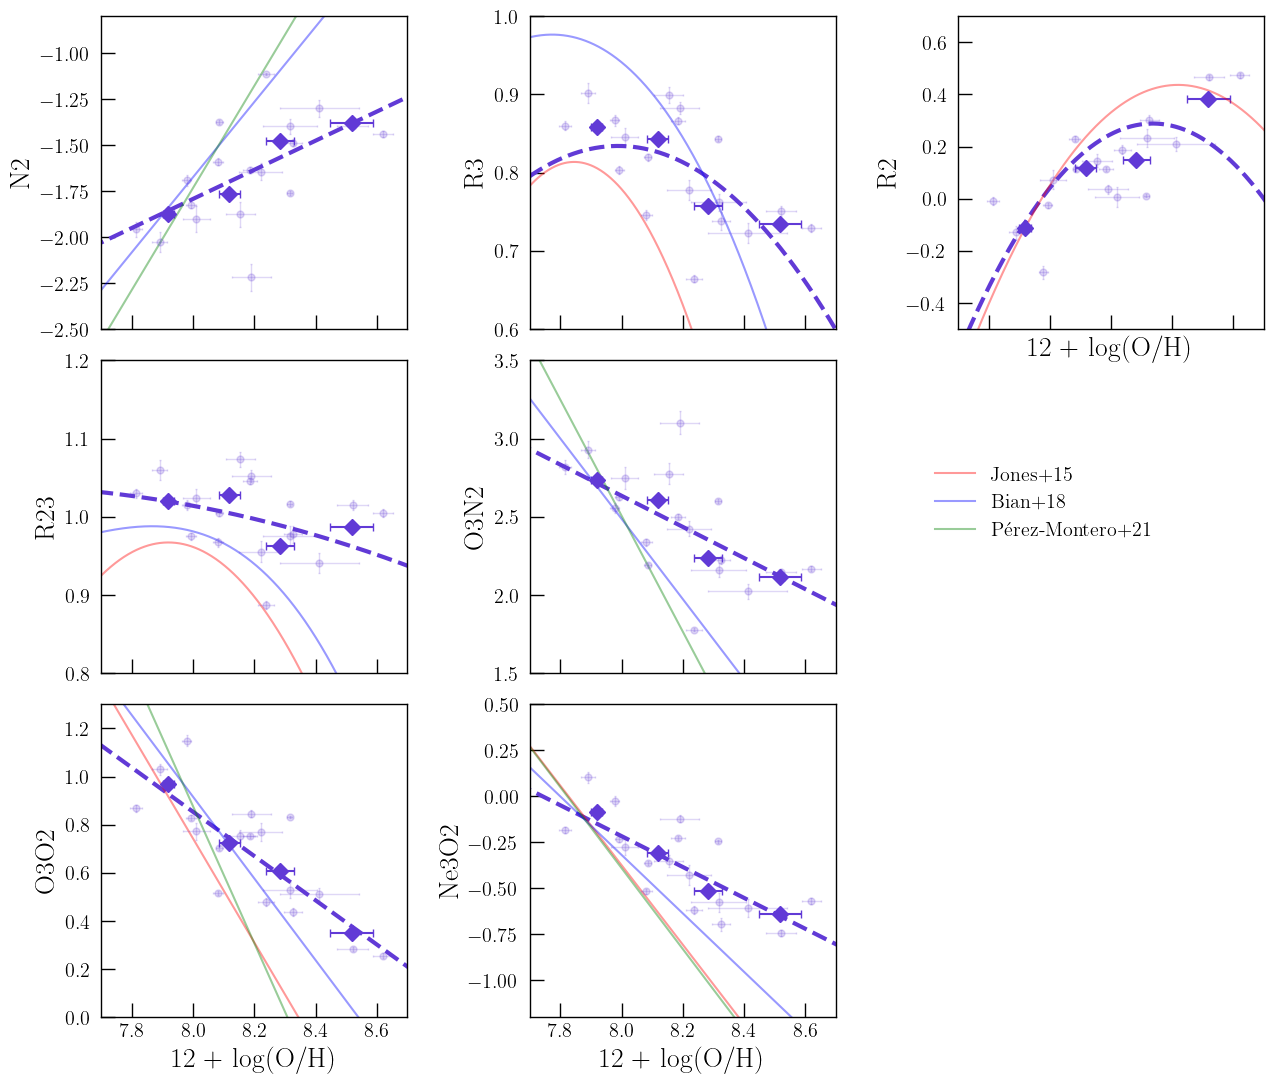

In [ ]:
texPlot('on')
fig, axs = plt.subplots(3, 3, sharex=True)
fig.set_size_inches((15, 13))
fig.subplots_adjust(wspace=0.4, hspace=0.1)

# ===========================================================================================================
# N2
# ===========================================================================================================

axs[0, 0].errorbar(metals['log_OH'], upy.nominal_values(N2), xerr=2*log_OH_err, yerr=5*upy.std_devs(N2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 0].plot(log_OH_tp, linear(log_OH_tp, int_N2, slope_N2), color=c[2], ls='--', lw=3)

# Relations
axs[0, 0].plot(log_OH_tp, bian2018(log_OH_tp, 'N2'), label='Bian+2018', color='blue', alpha=0.4)
axs[0, 0].plot(log_OH_tp, perez_montero2021(log_OH_tp, 'N2'), label='Pérez-Montero+2021', color='green', alpha=0.4)
axs[0, 0].set_ylabel('N2')

# ===========================================================================================================
# R3
# ===========================================================================================================

axs[0, 1].errorbar(metals['log_OH'], upy.nominal_values(R3), xerr=2*log_OH_err, yerr=5*upy.std_devs(R3), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R3),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R3),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 1].plot(log_OH_tp, poly2(log_OH_tp, a0_R3, a1_R3, a2_R3), color=c[2], ls='--', lw=3)

# Relations
axs[0, 1].plot(log_OH_tp, jones2015(log_OH_tp, 'R3'), label='Jones+2015', color='red', alpha=0.4)
axs[0, 1].plot(log_OH_tp, bian2018(log_OH_tp, 'R3'), label='Bian+2018', color='blue', alpha=0.4)
axs[0, 1].set_ylabel('R3')

# ===========================================================================================================
# R2
# ===========================================================================================================

axs[0, 2].errorbar(metals['log_OH'], upy.nominal_values(R2), xerr=2*log_OH_err, yerr=5*upy.std_devs(R2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 2].plot(log_OH_tp, poly2(log_OH_tp, a0_R2, a1_R2, a2_R2), color=c[2], ls='--', lw=3)

# Relations
axs[0, 2].plot(log_OH_tp, jones2015(log_OH_tp, 'R2'), label='Jones+2015', color='red', alpha=0.4)
axs[0, 2].set_ylabel('R2')


# ===========================================================================================================
# R23
# ===========================================================================================================

axs[1, 0].errorbar(metals['log_OH'], upy.nominal_values(R23), xerr=2*log_OH_err, yerr=5*upy.std_devs(R23), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[1, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R23),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R23),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 0].plot(log_OH_tp, poly2(log_OH_tp, a0_R23, a1_R23, a2_R23), color=c[2], ls='--', lw=3)

# Relations
axs[1, 0].plot(log_OH_tp, jones2015(log_OH_tp, 'R23'), label='Jones+2015', color='red', alpha=0.4)
axs[1, 0].plot(log_OH_tp, bian2018(log_OH_tp, 'R23'), label='Bian+2018', color='blue', alpha=0.4)
axs[1, 0].set_ylabel('R23')

# ===========================================================================================================
# O3N2
# ===========================================================================================================

axs[1, 1].errorbar(metals['log_OH'], upy.nominal_values(O3N2), xerr=2*log_OH_err, yerr=5*upy.std_devs(O3N2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[1, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3N2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_O3N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 1].plot(log_OH_tp, linear(log_OH_tp, int_O3N2, slope_O3N2), color=c[2], ls='--', lw=3)

# Relations
axs[1, 1].plot(log_OH_tp, bian2018(log_OH_tp, 'O3N2'), label='Bian+2018', color='blue', alpha=0.4)
axs[1, 1].plot(log_OH_tp, perez_montero2021(log_OH_tp, 'O3N2'), label='Pérez-Montero+2021', color='green', alpha=0.4)
axs[1, 1].set_ylabel('O3N2')


# ===========================================================================================================
# O3O2
# ===========================================================================================================

axs[2, 0].errorbar(metals['log_OH'], upy.nominal_values(O3O2), xerr=2*log_OH_err, yerr=5*upy.std_devs(O3O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[2, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3O2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_O3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 0].plot(log_OH_tp, linear(log_OH_tp, int_O3O2, slope_O3O2), color=c[2], ls='--', lw=3)

# Relations
axs[2, 0].plot(log_OH_tp, jones2015(log_OH_tp, 'O3O2'), label='Jones+2015', color='red', alpha=0.4)
axs[2, 0].plot(log_OH_tp, bian2018(log_OH_tp, 'O3O2'), label='Bian+2018', color='blue', alpha=0.4)
axs[2, 0].plot(log_OH_tp, perez_montero2021(log_OH_tp, 'O3O2'), label='Pérez-Montero+2021', color='green', alpha=0.4)
axs[2, 0].set_ylabel('O3O2')

# ===========================================================================================================
# Ne3O2
# ===========================================================================================================

axs[2, 1].errorbar(metals['log_OH'], upy.nominal_values(Ne3O2), xerr=2*log_OH_err, yerr=5*upy.std_devs(Ne3O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[2, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_Ne3O2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_Ne3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 1].plot(log_OH_tp, linear(log_OH_tp, int_Ne3O2, slope_Ne3O2), color=c[2], ls='--', lw=3)

# Relations
axs[2, 1].plot(log_OH_tp, jones2015(log_OH_tp, 'Ne3O2'), label='Jones+15', color='red', alpha=0.4)
axs[2, 1].plot(log_OH_tp, bian2018(log_OH_tp, 'Ne3O2'), label='Bian+18', color='blue', alpha=0.4)
axs[2, 1].plot(log_OH_tp, perez_montero2021(log_OH_tp, 'Ne3O2'), label='Pérez-Montero+21', color='green', alpha=0.4)
axs[2, 1].legend(frameon=False, loc=(1.3, 1.5))
axs[2, 1].set_ylabel('Ne3O2')


# ===========================================================================================================
# General settings
# ===========================================================================================================

axs[2, 0].set_xlabel(r'12 + log(O/H)')
axs[2, 1].set_xlabel(r'12 + log(O/H)')
axs[0, 2].set_xlabel(r'12 + log(O/H)')

# limits

# x
axs[0, 0].set_xlim(7.7, 8.7) # N2 (Shared)

# y
axs[0, 0].set_ylim(-2.5, -0.8) # N2
axs[0, 1].set_ylim(0.6, 1.0) # R3
axs[0, 2].set_ylim(-0.5, 0.7) # R2

axs[1, 0].set_ylim(0.8, 1.2) # R23
axs[1, 1].set_ylim(1.5, 3.5) # O3N2

axs[2, 0].set_ylim(0, 1.3) # O3O2
axs[2, 1].set_ylim(-1.2, 0.5) # Ne3O2


axs[1, 2].axis('off')
axs[2, 2].axis('off')

# Setting tick params

axs[0, 0].tick_params(axis="y", direction="in", length=10)
axs[0, 0].tick_params(axis="x", direction="in", length=10)

axs[0, 1].tick_params(axis="y", direction="in", length=10)
axs[0, 1].tick_params(axis="x", direction="in", length=10)

axs[0, 2].tick_params(axis="y", direction="in", length=10)
axs[0, 2].tick_params(axis="x", direction="in", length=10)

axs[1, 0].tick_params(axis="y", direction="in", length=10)
axs[1, 0].tick_params(axis="x", direction="in", length=10)

axs[1, 1].tick_params(axis="y", direction="in", length=10)
axs[1, 1].tick_params(axis="x", direction="in", length=10)

axs[2, 0].tick_params(axis="y", direction="in", length=10)
axs[2, 0].tick_params(axis="x", direction="in", length=10)

axs[2, 1].tick_params(axis="y", direction="in", length=10)
axs[2, 1].tick_params(axis="x", direction="in", length=10)

#fig.savefig(magePath+'analysis/chapter4/calbration_vs_analogs.pdf', bbox_inches='tight')

## Photoionization models

In [67]:
def dopita2016_N2S2(log_OH_12):
    N2S2 = (log_OH_12 - 8.77)
    return N2S2


def strom2018(log_OH_12, ratio='asd'):
    if ratio == 'R23':
        return - (((log_OH_12 - 8.24)**2) - 0.85) / 0.87
    if ratio == 'N2':
        return (log_OH_12 - 8.77) / 0.34
    if ratio == 'O3N2':
        return  - (log_OH_12 - 8.75) /0.21


def papovich2022_R23(log_OH_12):
    log_Z0 = 8.228
    log_R0 = 1.041
    A = -1.07
    return A * ((log_OH_12 - log_Z0)**2) + log_R0


def garg2023_z_0(SEL, ratio='asd'):
    if ratio == 'N2':
        a0 = -13.9
        a1 = 1.918
        a2 = -0.046
    if ratio == 'R3':
        a0 = -57.889
        a1 = 14.552
        a2 = -0.905
    if ratio == 'R2':
        a0 = -43.87
        a1 = 10.558
        a2 = -0.632
    if ratio == 'R23':
        a0 = -47.251
        a1 = 11.872
        a2 = -0.732
    if ratio == 'O3N2':
        a0 = -45.251
        a1 = 12.947
        a2 = -0.878
    if ratio == 'R3N2':
        a0 = -49.279
        a1 = 13.895
        a2 = -0.941
    if ratio == 'N2O2':
        a0 = 34.201
        a1 = -9.642
        a2 = 0.652
    if ratio == 'O3O2':
        a0 = -15.091
        a1 = 4.258
        a2 = -0.289
    if ratio == 'Ne3O2':
        a0 = 3.986
        a1 = -0.877
        a2 = 0.035
    if ratio == 'S2':
        a0 = -28.699
        a1 = 6.227
        a2 = -0.347
    if ratio == 'O3S2':
        a0 = -29.935
        a1 = 8.511
        a2 = -0.57
    if ratio == 'N2S2':
        a0 = 11.406
        a1 = -3.871
        a2 = 0.292
    return a0 + (a1 * SEL) + (a2 * (SEL**2))

def garg2023_z_2(SEL, ratio='asd'):
    if ratio == 'N2':
        a0 = 16.247
        a1 = -5.606
        a2 = 0.42
    if ratio == 'R3':
        a0 = -41.669
        a1 = 10.511
        a2 = -0.653
    if ratio == 'R2':
        a0 = -21.727
        a1 = 4.973
        a2 = -0.281
    if ratio == 'R23':
        a0 = -34.364
        a1 = 8.641
        a2 = -0.53
    if ratio == 'O3N2':
        a0 = -57.392
        a1 = 15.982
        a2 = -1.064
    if ratio == 'R3N2':
        a0 = -64.199
        a1 = 17.678
        a2 = -1.177
    if ratio == 'N2O2':
        a0 = 44.395
        a1 = -12.176
        a2 = 0.808
    if ratio == 'O3O2':
        a0 = -19.924
        a1 = 5.534
        a2 = -0.371
    if ratio == 'Ne3O2':
        a0 = -14.735
        a1 = 3.814
        a2 = -0.258
    if ratio == 'S2':
        a0 = -1.276
        a1 = -0.78
        a2 = 0.098
    if ratio == 'O3S2':
        a0 = -39.426
        a1 = 11.041
        a2 = -0.735
    if ratio == 'N2S2':
        a0 = 21.596
        a1 = -6.25
        a2 = 0.429
    return a0 + (a1 * SEL) + (a2 * (SEL**2))

def garg2023_z_5(SEL, ratio='asd'):
    if ratio == 'N2':
        a0 = 6.902
        a1 = -3.176
        a2 = 0.261
    if ratio == 'R3':
        a0 = -24.688
        a1 = 6.118
        a2 = -0.369
    if ratio == 'R2':
        a0 = -19.95
        a1 = 4.556
        a2 = -0.258
    if ratio == 'R23':
        a0 = -23.269
        a1 = 5.776
        a2 = -0.346
    if ratio == 'O3N2':
        a0 = -31.59
        a1 = 9.294
        a2 = -0.63
    if ratio == 'R3N2':
        a0 = -35.253
        a1 = 10.157
        a2 = -0.688
    if ratio == 'N2O2':
        a0 = 30.515
        a1 = -8.595
        a2 = 0.577
    if ratio == 'O3O2':
        a0 = -4.737
        a1 = 1.562
        a2 = -0.111
    if ratio == 'Ne3O2':
        a0 = -6.314
        a1 = 1.597
        a2 = -0.112
    if ratio == 'S2':
        a0 = -10.901
        a1 = 1.8
        a2 = -0.076
    if ratio == 'O3S2':
        a0 = -13.787
        a1 = 4.318
        a2 = -0.293
    if ratio == 'N2S2':
        a0 = 19.625
        a1 = -5.814
        a2 = 0.406
    return a0 + (a1 * SEL) + (a2 * (SEL**2))

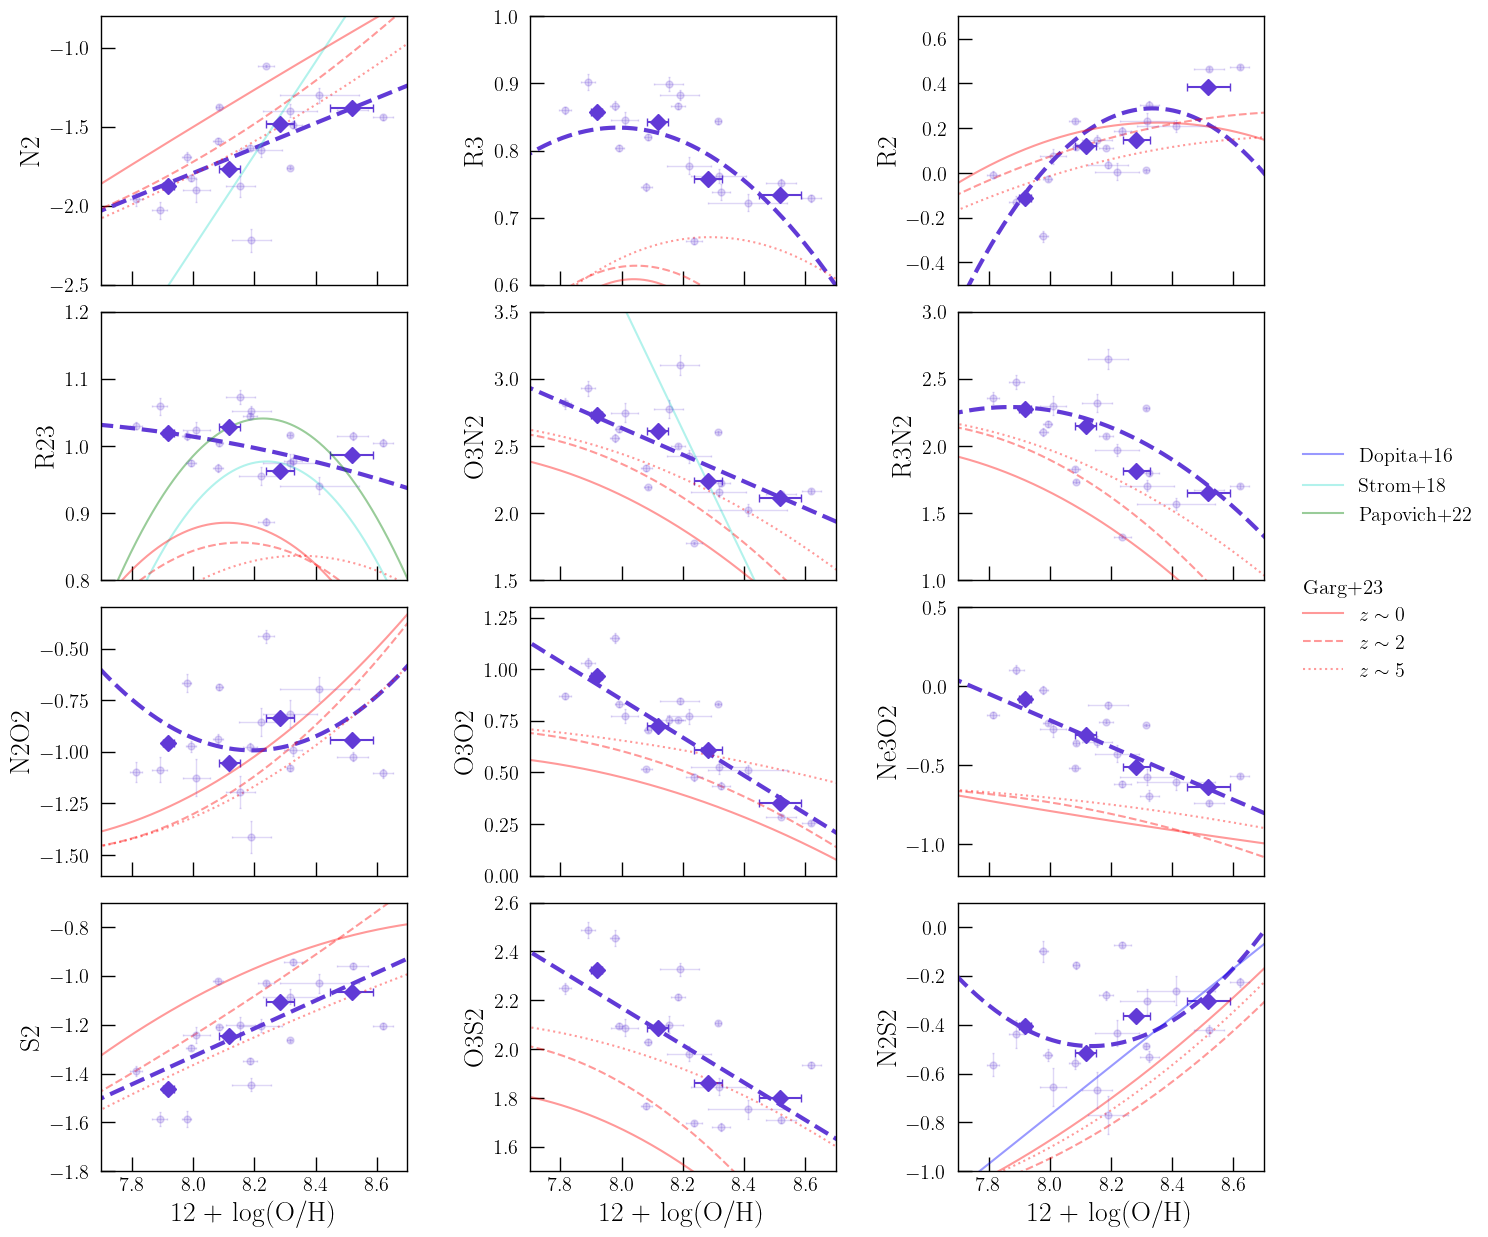

In [68]:
texPlot('on')
fig, axs = plt.subplots(4, 3, sharex=True)
fig.set_size_inches((15, 15))
fig.subplots_adjust(wspace=0.4, hspace=0.1)

# ===========================================================================================================
# N2
# ===========================================================================================================

axs[0, 0].errorbar(metals['log_OH'], upy.nominal_values(N2), xerr=2*log_OH_err, yerr=5*upy.std_devs(N2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 0].plot(log_OH_tp, linear(log_OH_tp, int_N2, slope_N2), color=c[2], ls='--', lw=3)

# Relations
axs[0, 0].plot(log_OH_tp, strom2018(log_OH_tp, 'N2'), color='turquoise', alpha=0.4)
axs[0, 0].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'N2'), label=r'$z \sim 0$', color='red', alpha=0.4)
axs[0, 0].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'N2'), label=r'$z \sim 2$', color='red', alpha=0.4, ls='--')
axs[0, 0].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'N2'), label=r'$z \sim 5$', color='red', alpha=0.4, ls=':')
axs[0, 0].set_ylabel('N2')

# ===========================================================================================================
# R3
# ===========================================================================================================

axs[0, 1].errorbar(metals['log_OH'], upy.nominal_values(R3), xerr=2*log_OH_err, yerr=5*upy.std_devs(R3), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R3),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R3),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 1].plot(log_OH_tp, poly2(log_OH_tp, a0_R3, a1_R3, a2_R3), color=c[2], ls='--', lw=3)

# Relations
axs[0, 1].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'R3'), color='red', alpha=0.4)
axs[0, 1].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'R3'), color='red', alpha=0.4, ls='--')
axs[0, 1].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'R3'), color='red', alpha=0.4, ls=':')
axs[0, 1].set_ylabel('R3')

# ===========================================================================================================
# R2
# ===========================================================================================================

axs[0, 2].errorbar(metals['log_OH'], upy.nominal_values(R2), xerr=2*log_OH_err, yerr=5*upy.std_devs(R2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 2].plot(log_OH_tp, poly2(log_OH_tp, a0_R2, a1_R2, a2_R2), color=c[2], ls='--', lw=3)

# Relations
axs[0, 2].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'R2'), color='red', alpha=0.4)
axs[0, 2].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'R2'), color='red', alpha=0.4, ls='--')
axs[0, 2].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'R2'), color='red', alpha=0.4, ls=':')
axs[0, 2].set_ylabel('R2')


# ===========================================================================================================
# R23
# ===========================================================================================================

axs[1, 0].errorbar(metals['log_OH'], upy.nominal_values(R23), xerr=2*log_OH_err, yerr=5*upy.std_devs(R23), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[1, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R23),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R23),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 0].plot(log_OH_tp, poly2(log_OH_tp, a0_R23, a1_R23, a2_R23), color=c[2], ls='--', lw=3)

# Relations
axs[1, 0].plot(log_OH_tp, strom2018(log_OH_tp, 'R23'), label='Strom+18', color='turquoise', alpha=0.4)
axs[1, 0].plot(log_OH_tp, papovich2022_R23(log_OH_tp), label='Papovich+22', color='green', alpha=0.4)
axs[1, 0].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'R23'), color='red', alpha=0.4)
axs[1, 0].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'R23'), color='red', alpha=0.4, ls='--')
axs[1, 0].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'R23'), color='red', alpha=0.4, ls=':')
axs[1, 0].set_ylabel('R23')

# ===========================================================================================================
# O3N2
# ===========================================================================================================

axs[1, 1].errorbar(metals['log_OH'], upy.nominal_values(O3N2), xerr=2*log_OH_err, yerr=5*upy.std_devs(O3N2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[1, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3N2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_O3N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 1].plot(log_OH_tp, linear(log_OH_tp, int_O3N2, slope_O3N2), color=c[2], ls='--', lw=3)

# Relations
axs[1, 1].plot(log_OH_tp, strom2018(log_OH_tp, 'O3N2'), label='Strom+2018', color='turquoise', alpha=0.4)
axs[1, 1].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'O3N2'), color='red', alpha=0.4)
axs[1, 1].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'O3N2'), color='red', alpha=0.4, ls='--')
axs[1, 1].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'O3N2'), color='red', alpha=0.4, ls=':')
axs[1, 1].set_ylabel('O3N2')

# ===========================================================================================================
# R3N2
# ===========================================================================================================

axs[1, 2].errorbar(metals['log_OH'], upy.nominal_values(R3N2), xerr=2*log_OH_err, yerr=5*upy.std_devs(R3N2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[1, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R3N2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R3N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 2].plot(log_OH_tp, poly2(log_OH_tp, a0_R3N2, a1_R3N2, a2_R3N2), color=c[2], ls='--', lw=3)

# Relations
axs[1, 2].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'R3N2'), color='red', alpha=0.4)
axs[1, 2].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'R3N2'), color='red', alpha=0.4, ls='--')
axs[1, 2].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'R3N2'), color='red', alpha=0.4, ls=':')
axs[1, 2].set_ylabel('R3N2')


# ===========================================================================================================
# N2O2
# ===========================================================================================================

axs[2, 0].errorbar(metals['log_OH'], upy.nominal_values(N2O2), xerr=2*log_OH_err, yerr=5*upy.std_devs(N2O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[2, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2O2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_N2O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 0].plot(log_OH_tp, poly2(log_OH_tp, a0_N2O2, a1_N2O2, a2_N2O2), color=c[2], ls='--', lw=3)

# Relations
axs[2, 0].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'N2O2'), color='red', alpha=0.4)
axs[2, 0].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'N2O2'), color='red', alpha=0.4, ls='--')
axs[2, 0].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'N2O2'), color='red', alpha=0.4, ls=':')
axs[2, 0].set_ylabel('N2O2')

# ===========================================================================================================
# O3O2
# ===========================================================================================================

axs[2, 1].errorbar(metals['log_OH'], upy.nominal_values(O3O2), xerr=2*log_OH_err, yerr=5*upy.std_devs(O3O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[2, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3O2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_O3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 1].plot(log_OH_tp, linear(log_OH_tp, int_O3O2, slope_O3O2), color=c[2], ls='--', lw=3)

# Relations
axs[2, 1].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'O3O2'), color='red', alpha=0.4)
axs[2, 1].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'O3O2'), color='red', alpha=0.4, ls='--')
axs[2, 1].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'O3O2'), color='red', alpha=0.4, ls=':')
axs[2, 1].set_ylabel('O3O2')

# ===========================================================================================================
# Ne3O2
# ===========================================================================================================

axs[2, 2].errorbar(metals['log_OH'], upy.nominal_values(Ne3O2), xerr=2*log_OH_err, yerr=5*upy.std_devs(Ne3O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[2, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_Ne3O2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_Ne3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 2].plot(log_OH_tp, linear(log_OH_tp, int_Ne3O2, slope_Ne3O2), color=c[2], ls='--', lw=3)

# Relations
axs[2, 2].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'Ne3O2'), color='red', alpha=0.4)
axs[2, 2].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'Ne3O2'), color='red', alpha=0.4, ls='--')
axs[2, 2].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'Ne3O2'), color='red', alpha=0.4, ls=':')
axs[2, 2].set_ylabel('Ne3O2')

# ===========================================================================================================
# S2
# ===========================================================================================================

axs[3, 0].errorbar(metals['log_OH'], upy.nominal_values(S2), xerr=2*log_OH_err, yerr=5*upy.std_devs(S2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[3, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_S2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_S2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[3, 0].plot(log_OH_tp, linear(log_OH_tp, int_S2, slope_S2), color=c[2], ls='--', lw=3)

# Relations
axs[3, 0].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'S2'), color='red', alpha=0.4)
axs[3, 0].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'S2'), color='red', alpha=0.4, ls='--')
axs[3, 0].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'S2'), color='red', alpha=0.4, ls=':')
axs[3, 0].set_ylabel('S2')

# ===========================================================================================================
# O3S2
# ===========================================================================================================

axs[3, 1].errorbar(metals['log_OH'], upy.nominal_values(O3S2), xerr=2*log_OH_err, yerr=5*upy.std_devs(O3S2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[3, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3S2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_O3S2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[3, 1].plot(log_OH_tp, linear(log_OH_tp, int_O3S2, slope_O3S2), color=c[2], ls='--', lw=3)

# Relations
axs[3, 1].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'O3S2'), color='red', alpha=0.4)
axs[3, 1].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'O3S2'), color='red', alpha=0.4, ls='--')
axs[3, 1].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'O3S2'), color='red', alpha=0.4, ls=':')
axs[3, 1].set_ylabel('O3S2')

# ===========================================================================================================
# N2S2
# ===========================================================================================================

axs[3, 2].errorbar(metals['log_OH'], upy.nominal_values(N2S2), xerr=2*log_OH_err, yerr=5*upy.std_devs(N2S2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[3, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2S2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_N2S2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[3, 2].plot(log_OH_tp, poly2(log_OH_tp, a0_N2S2, a1_N2S2, a2_N2S2), color=c[2], ls='--', lw=3)

# Relations
axs[3, 2].plot(log_OH_tp, dopita2016_N2S2(log_OH_tp), label='Dopita+16', color='blue', alpha=0.4)
axs[3, 2].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'N2S2'), color='red', alpha=0.4)
axs[3, 2].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'N2S2'), color='red', alpha=0.4, ls='--')
axs[3, 2].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'N2S2'), color='red', alpha=0.4, ls=':')
axs[3, 2].set_ylabel('N2S2')

# ===========================================================================================================
# General settings
# ===========================================================================================================

axs[3, 0].set_xlabel(r'12 + log(O/H)')
axs[3, 1].set_xlabel(r'12 + log(O/H)')
axs[3, 2].set_xlabel(r'12 + log(O/H)')

# limits
# x
axs[0, 0].set_xlim(7.7, 8.7) 

# y
axs[0, 0].set_ylim(-2.5, -0.8) # N2
axs[0, 1].set_ylim(0.6, 1.0) # R3
axs[0, 2].set_ylim(-0.5, 0.7) # R2

axs[1, 0].set_ylim(0.8, 1.2) # R23
axs[1, 1].set_ylim(1.5, 3.5) # O3N2
axs[1, 2].set_ylim(1, 3) # R3N2

axs[2, 0].set_ylim(-1.6, -0.3) # N2O2
axs[2, 1].set_ylim(0, 1.3) # O3O2
axs[2, 2].set_ylim(-1.2, 0.5) # Ne3O2

axs[3, 0].set_ylim(-1.8, -0.7) # S2
axs[3, 1].set_ylim(1.5, 2.6) # O3S2
axs[3, 2].set_ylim(-1.0, 0.1) # N2S2

# Legends
axs[0, 0].legend(frameon=False, loc=(3.9, -1.5))
axs[1, 0].legend(frameon=False, loc=(3.9, 0.18))
axs[1, 2].text(8.83, 0.9, 'Garg+23', fontsize=15)
axs[3, 2].legend(frameon=False, loc=(1.1, 2.6))

index_model = [0, 1, 2, 3]
index_sec = [0, 1, 2]
for i in index_model:
    for j in index_sec:
        axs[i, j].tick_params(axis="y", direction="in", length=10)
        axs[i, j].tick_params(axis="x", direction="in", length=10)
        
#fig.savefig(magePath+'analysis/chapter4/calbration_vs_models.pdf', bbox_inches='tight')

# Predictions for galaxies at high-$z$

In [11]:
# Steidel UV selected galaxies

steidel_14 = fits.open('./steidel14.fits')[1].data

N2_steidel = steidel_14['log([NII]/Ha)']
N2_steidel_err = np.array([steidel_14['E_log([NII]/Ha)'], steidel_14['e_log([NII]/Ha)']])

O3_steidel = steidel_14['log([OIII]/Hb)']
O3_steidel_err = np.array([steidel_14['E_log([OIII]/Hb)'], steidel_14['e_log([OIII]/Hb)']])

O3N2_steidel = O3_steidel - N2_steidel

OH_from_N2_PP04_steidel = steidel_14['12+log(O/H)']
OH_from_N2_PP04_steidel_err = np.array([steidel_14['E_12+log(O/H)'], steidel_14['e_12+log(O/H)']])

OH_from_O3N2_PP04_steidel = steidel_14['12+log(O/H)O3']
OH_from_O3N2_PP04_steidel_err = np.array([steidel_14['E_12+log(O/H)O3'], steidel_14['e_12+log(O/H)O3']])

In [12]:
# Predictions of N2 from Bian 2018 and this work.
mask_valid_N2 = (N2_steidel <= np.max(N2).nominal_value)

OH_from_N2_Bian_steidel = N2_steidel[mask_valid_N2] * 0.49 + 8.82
N2_from_OH_tw_steidel = (OH_from_N2_PP04_steidel * slope_N2) + int_N2
OH_from_N2_tw_steidel = (N2_steidel[mask_valid_N2] - int_N2) / slope_N2

In [13]:
# Precitions of O3N2 from Bian 2018 and this work.
mask_valid_O3N2 = (O3N2_steidel >= np.min(O3N2).nominal_value)

OH_from_O3N2_Bian_steidel = -0.39 * O3N2_steidel[mask_valid_O3N2] + 8.97
OH_from_O3N2_tw_steidel = (O3N2_steidel[mask_valid_O3N2] - int_O3N2) / slope_O3N2

In [16]:
texPlot('on')

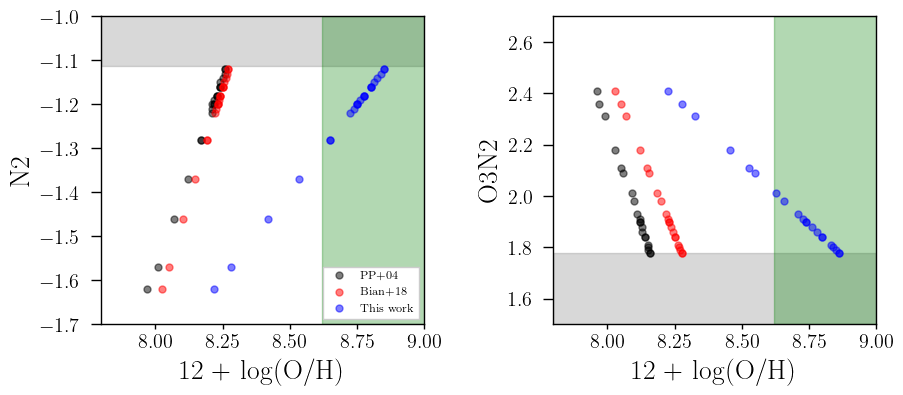

In [17]:
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(10, 4)
fig.subplots_adjust(wspace=0.4)

ax[0].errorbar(OH_from_N2_PP04_steidel[mask_valid_N2], N2_steidel[mask_valid_N2],
             #xerr=OH_from_N2_PP04_steidel_err, yerr=N2_steidel_err,
             fmt='o', ls='', markersize=5, color='black',
             alpha=0.5, elinewidth=1, capsize=3, label='PP+04'
)
ax[0].errorbar(OH_from_N2_Bian_steidel, N2_steidel[mask_valid_N2],
             #xerr=OH_steidel_err, yerr=N2_steidel_err,
             fmt='o', ls='', markersize=5, color='red',
             alpha=0.5, elinewidth=1, capsize=3, label='Bian+18'
)
ax[0].errorbar(OH_from_N2_tw_steidel, N2_steidel[mask_valid_N2],
             #xerr=OH_steidel_err, yerr=N2_steidel_err,
             fmt='o', ls='', markersize=5, color='blue',
             alpha=0.5, elinewidth=1, capsize=3, label='This work'
)
ax[0].axhspan(np.max(N2).nominal_value, 0.0, zorder=0, color='gray', alpha=0.3)
ax[0].axvspan(np.max(metals['log_OH'].values), 10.0, zorder=0, color='green', alpha=0.3)
ax[0].set_xlabel('12 + log(O/H)')
ax[0].set_ylabel('N2')
ax[0].legend(fontsize='small', frameon=True, fancybox=False, framealpha=1.0)
ax[0].set_ylim(-1.7, -1.0)
ax[0].set_xlim(7.8, 9.0)


ax[1].errorbar(OH_from_O3N2_PP04_steidel[mask_valid_O3N2], O3N2_steidel[mask_valid_O3N2],
             #xerr=OH_from_N2_PP04_steidel_err, yerr=N2_steidel_err,
             fmt='o', ls='', markersize=5, color='black',
             alpha=0.5, elinewidth=1, capsize=3, label='PP+04'
)
ax[1].errorbar(OH_from_O3N2_Bian_steidel, O3N2_steidel[mask_valid_O3N2],
             #xerr=OH_steidel_err, yerr=N2_steidel_err,
             fmt='o', ls='', markersize=5, color='red',
             alpha=0.5, elinewidth=1, capsize=3, label='Bian+18'
)
ax[1].errorbar(OH_from_O3N2_tw_steidel, O3N2_steidel[mask_valid_O3N2],
             #xerr=OH_steidel_err, yerr=N2_steidel_err,
             fmt='o', ls='', markersize=5, color='blue',
             alpha=0.5, elinewidth=1, capsize=3, label='This work'
)
ax[1].axhspan(0.0, np.min(O3N2).nominal_value, zorder=0, color='gray', alpha=0.3)
ax[1].axvspan(np.max(metals['log_OH'].values), 10.0, zorder=0, color='green', alpha=0.3)
ax[1].set_xlabel('12 + log(O/H)')
ax[1].set_ylabel('O3N2')
ax[1].set_ylim(1.5, 2.7)
ax[1].set_xlim(7.8, 9.0)

#fig.savefig('./chapter5/testing_calibration.pdf', bbox_inches='tight')

In [109]:
np.max(metals['log_OH'])

8.620668467580337

In [106]:
dOH_N2_Bian = np.mean(np.abs(OH_from_N2_tw_steidel[OH_from_N2_tw_steidel < 8.6] - OH_from_N2_Bian_steidel[N2_steidel[mask_valid_N2] < -1.3]))
dOH_N2_PP = np.mean(np.abs(OH_from_N2_tw_steidel[OH_from_N2_tw_steidel < 8.6] - OH_from_N2_PP04_steidel[N2_steidel < -1.3]))

In [107]:
dOH_O3N2_PP = np.mean(np.abs(OH_from_O3N2_tw_steidel[OH_from_O3N2_tw_steidel < 8.6] - OH_from_O3N2_PP04_steidel[O3N2_steidel > 2.05]))
dOH_O3N2_Bian = np.mean(np.abs(OH_from_O3N2_tw_steidel[OH_from_O3N2_tw_steidel < 8.6] - OH_from_O3N2_Bian_steidel[O3N2_steidel[mask_valid_O3N2] > 2.05]))

(8.2, 9.0)

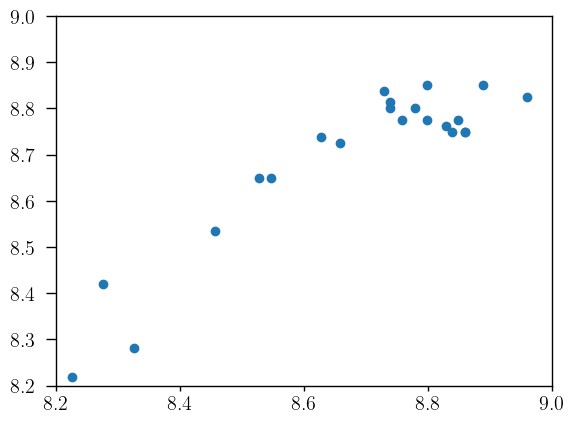

In [76]:
plt.scatter((O3N2_steidel[mask_valid_N2] - int_O3N2) / slope_O3N2,
         OH_from_N2_tw_steidel)
plt.xlim(8.2, 9.0)
plt.ylim(8.2, 9.0)
plt.xlabel('12 + log(O/H)')

In [108]:
print('Mean differences')
print('=================')
print('N2 PP:', dOH_N2_PP)
print('N2 Bian:', dOH_N2_Bian)
print('-----------------')
print('O3N2 PP:', dOH_O3N2_PP)
print('O3N2 Bian:', dOH_O3N2_Bian)

Mean differences
N2 PP: 0.32101997694839857
N2 Bian: 0.2809699769483984
-----------------
O3N2 PP: 0.3834132020550811
O3N2 Bian: 0.2983132020550805


In [96]:
r23 = upy.uarray([0.15, 0.90, 0.26], [0.07, 0.10, 0.08]) + upy.uarray([3.08, 8.29, 7.11], [0.13, 0.21, 0.24])
ne3o2 = upy.uarray([0.17, 0.45, 0.50], [0.03, 0.03, 0.04]) / upy.uarray([0.15, 0.90, 0.26], [0.07, 0.10, 0.08])
o3o2 = upy.uarray([3.08, 8.29, 7.11], [0.13, 0.21, 0.24]) / upy.uarray([0.15, 0.90, 0.26], [0.07, 0.10, 0.08])

Curti_dict = {
    'R2': upy.log10(upy.uarray([0.15, 0.90, 0.26], [0.07, 0.10, 0.08])),
    'R3': upy.log10(upy.uarray([3.08, 8.29, 7.11], [0.13, 0.21, 0.24])),
    'R23': upy.log10(r23),
    'O3O2': upy.log10(o3o2),
    'Ne3O2': upy.log10(ne3o2),
    '12_log_OH': upy.uarray([7.25, 7.53, 7.50], [0.21, 0.08, 0.12])
}

def sanders2023(log_OH_12, ratio='asd'):
    x = (log_OH_12 - 8.0)
    if ratio == 'R2':
        c0 = 0.067
        c1 = 1.069
        c2 = 0.0
    if ratio == 'R3':
        c0 = 0.834
        c1 = -0.072
        c2 = -0.453
    if ratio == 'R23':
        c0 = 1.017
        c1 = 0.026
        c2 = -0.331
    if ratio == 'O3O2':
        c0 = 0.723
        c1 = -1.153
        c2 = 0.0
    if ratio == 'Ne3O2':
        c0 = -0.386
        c1 = -0.998
        c2 = 0.0
    return c0 + (c1 * x) + (c2 * (x**2))

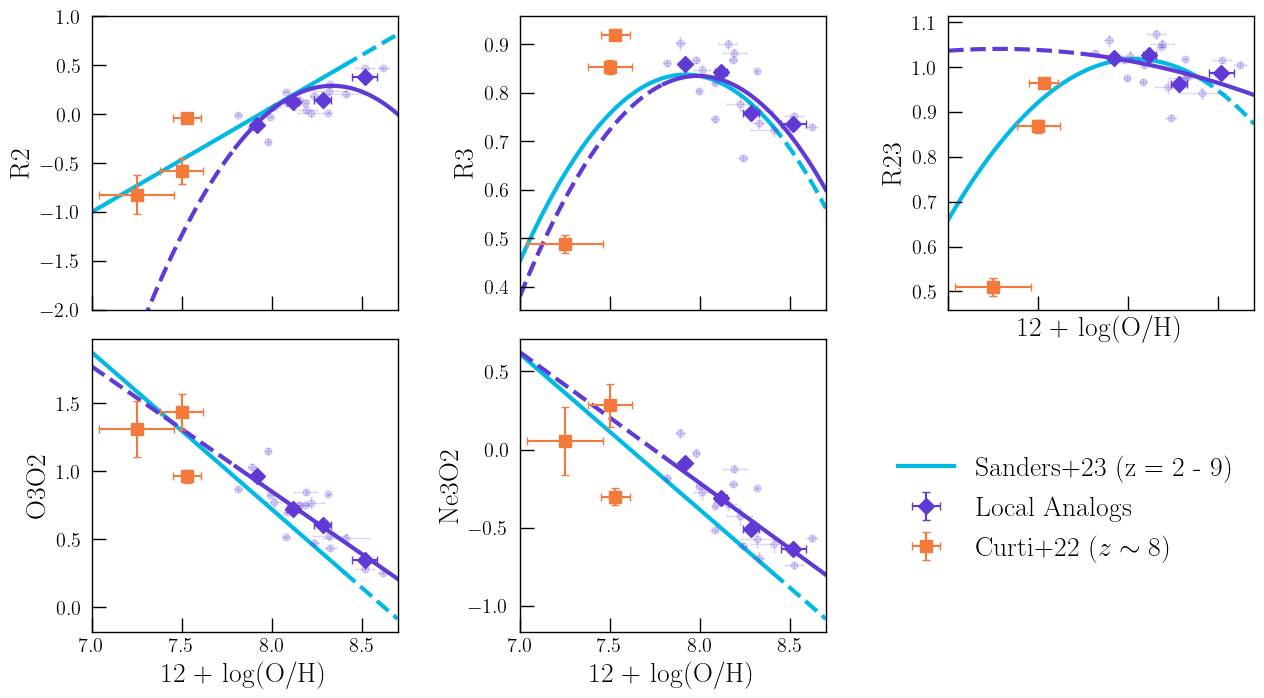

In [122]:
texPlot('on')
fig, axs = plt.subplots(2, 3, sharex=True)
fig.set_size_inches((15, 8))
fig.subplots_adjust(wspace=0.4, hspace=0.1)

# Utils

highz_OH_poor = np.linspace(7.0, 8.4, 100)
highz_OH_rich = np.linspace(8.4, 8.7, 100)

analog_OH_rich = np.linspace(7.8, 8.7, 100)
analog_OH_poor = np.linspace(7.0, 7.8, 100)

# ===========================================================================================================
# R2
# ===========================================================================================================

axs[0, 0].errorbar(metals['log_OH'], upy.nominal_values(R2), xerr=2*log_OH_err, yerr=5*upy.std_devs(R2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)

# High-z sample
axs[0, 0].errorbar(upy.nominal_values(Curti_dict['12_log_OH']), upy.nominal_values(Curti_dict['R2']),
                  xerr=upy.std_devs(Curti_dict['12_log_OH']), yerr=upy.std_devs(Curti_dict['R2']),
                  ls='', markersize=8, marker='s', color=cz[0], capsize=3)

# z = 2 - 9 relation
axs[0, 0].plot(highz_OH_poor, sanders2023(highz_OH_poor, 'R2'), color=c[0], lw=3, zorder=0)
axs[0, 0].plot(highz_OH_rich, sanders2023(highz_OH_rich, 'R2'), color=c[0], ls='--', lw=3, zorder=0)

# analogs relation
axs[0, 0].plot(analog_OH_poor, poly2(analog_OH_poor, a0_R2, a1_R2, a2_R2), color=c[2], ls='--', lw=3, zorder=0)
axs[0, 0].plot(analog_OH_rich, poly2(analog_OH_rich, a0_R2, a1_R2, a2_R2), color=c[2], lw=3, zorder=0)
axs[0, 0].set_ylabel('R2')

# ===========================================================================================================
# R3
# ===========================================================================================================

axs[0, 1].errorbar(metals['log_OH'], upy.nominal_values(R3), xerr=2*log_OH_err, yerr=5*upy.std_devs(R3), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R3),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R3),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)

axs[0, 1].errorbar(upy.nominal_values(Curti_dict['12_log_OH']), upy.nominal_values(Curti_dict['R3']),
                  xerr=upy.std_devs(Curti_dict['12_log_OH']), yerr=upy.std_devs(Curti_dict['R3']),
                  ls='', markersize=8, marker='s', color=cz[0], capsize=3)

# z = 2 - 9 relation
axs[0, 1].plot(highz_OH_poor, sanders2023(highz_OH_poor, 'R3'), color=c[0], lw=3, zorder=0)
axs[0, 1].plot(highz_OH_rich, sanders2023(highz_OH_rich, 'R3'), color=c[0], ls='--', lw=3, zorder=0)

# analogs relation
axs[0, 1].plot(analog_OH_poor, poly2(analog_OH_poor, a0_R3, a1_R3, a2_R3), color=c[2], ls='--', lw=3, zorder=0)
axs[0, 1].plot(analog_OH_rich, poly2(analog_OH_rich, a0_R3, a1_R3, a2_R3), color=c[2], lw=3, zorder=0)
axs[0, 1].set_ylabel('R3')

# ===========================================================================================================
# R23
# ===========================================================================================================

axs[0, 2].errorbar(metals['log_OH'], upy.nominal_values(R23), xerr=2*log_OH_err, yerr=5*upy.std_devs(R23), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R23),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R23),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8, label='Local Analogs')

axs[0, 2].errorbar(upy.nominal_values(Curti_dict['12_log_OH']), upy.nominal_values(Curti_dict['R23']),
                  xerr=upy.std_devs(Curti_dict['12_log_OH']), yerr=upy.std_devs(Curti_dict['R23']),
                  ls='', markersize=8, marker='s', color=cz[0], capsize=3, label=r'Curti+22 ($z \sim 8$)')

# z = 2 - 9 relation
axs[0, 2].plot(highz_OH_poor, sanders2023(highz_OH_poor, 'R23'), color=c[0],
               label='Sanders+23 (z = 2 - 9)', lw=3, zorder=0)
axs[0, 2].plot(highz_OH_rich, sanders2023(highz_OH_rich, 'R23'), color=c[0], ls='--', lw=3, zorder=0)

# analogs relation
axs[0, 2].plot(analog_OH_poor, poly2(analog_OH_poor, a0_R23, a1_R23, a2_R23), color=c[2], ls='--', lw=3, zorder=0)
axs[0, 2].plot(analog_OH_rich, poly2(analog_OH_rich, a0_R23, a1_R23, a2_R23), color=c[2], lw=3, zorder=0)
axs[0, 2].set_ylabel('R23')

# ===========================================================================================================
# O3O2
# ===========================================================================================================

axs[1, 0].errorbar(metals['log_OH'], upy.nominal_values(O3O2), xerr=2*log_OH_err, yerr=5*upy.std_devs(O3O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[1, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3O2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_O3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)

axs[1, 0].errorbar(upy.nominal_values(Curti_dict['12_log_OH']), upy.nominal_values(Curti_dict['O3O2']),
                  xerr=upy.std_devs(Curti_dict['12_log_OH']), yerr=upy.std_devs(Curti_dict['O3O2']),
                  ls='', markersize=8, marker='s', color=cz[0], capsize=3)

# z = 2 - 9 relation
axs[1, 0].plot(highz_OH_poor, sanders2023(highz_OH_poor, 'O3O2'), color=c[0], lw=3, zorder=0)
axs[1, 0].plot(highz_OH_rich, sanders2023(highz_OH_rich, 'O3O2'), color=c[0], ls='--', lw=3, zorder=0)

# analogs relation
axs[1, 0].plot(analog_OH_poor, linear(analog_OH_poor, int_O3O2, slope_O3O2), color=c[2], ls='--', lw=3, zorder=0)
axs[1, 0].plot(analog_OH_rich, linear(analog_OH_rich, int_O3O2, slope_O3O2), color=c[2], lw=3, zorder=0)
axs[1, 0].set_ylabel('O3O2')

# ===========================================================================================================
# Ne3O2
# ===========================================================================================================

axs[1, 1].errorbar(metals['log_OH'], upy.nominal_values(Ne3O2), xerr=2*log_OH_err, yerr=5*upy.std_devs(Ne3O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[1, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_Ne3O2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_Ne3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)

axs[1, 1].errorbar(upy.nominal_values(Curti_dict['12_log_OH']), upy.nominal_values(Curti_dict['Ne3O2']),
                  xerr=upy.std_devs(Curti_dict['12_log_OH']), yerr=upy.std_devs(Curti_dict['Ne3O2']),
                  ls='', markersize=8, marker='s', color=cz[0], capsize=3)

# z = 2 - 9 relation
axs[1, 1].plot(highz_OH_poor, sanders2023(highz_OH_poor, 'Ne3O2'), color=c[0], lw=3, zorder=0)
axs[1, 1].plot(highz_OH_rich, sanders2023(highz_OH_rich, 'Ne3O2'), color=c[0], ls='--', lw=3, zorder=0)

# analogs relation
axs[1, 1].plot(analog_OH_poor, linear(analog_OH_poor, int_Ne3O2, slope_Ne3O2), color=c[2], ls='--', lw=3, zorder=0)
axs[1, 1].plot(analog_OH_rich, linear(analog_OH_rich, int_Ne3O2, slope_Ne3O2), color=c[2], lw=3, zorder=0)
axs[1, 1].set_ylabel('Ne3O2')

# ===========================================================================================================
# General settings
# ===========================================================================================================

axs[1, 0].set_xlabel(r'12 + log(O/H)')
axs[1, 1].set_xlabel(r'12 + log(O/H)')
axs[0, 2].set_xlabel(r'12 + log(O/H)')

axs[1, 0].set_xlim(7.0, 8.7)
axs[1, 1].set_xlim(7.0, 8.7)
axs[0, 2].set_xlim(7.0, 8.7)

axs[0, 0].set_ylim(-2.0, 1.0)

axs[0, 0].tick_params(axis="y", direction="in", length=10)
axs[0, 0].tick_params(axis="x", direction="in", length=10)

axs[0, 1].tick_params(axis="y", direction="in", length=10)
axs[0, 1].tick_params(axis="x", direction="in", length=10)

axs[0, 2].tick_params(axis="y", direction="in", length=10)
axs[0, 2].tick_params(axis="x", direction="in", length=10)

axs[1, 0].tick_params(axis="y", direction="in", length=10)
axs[1, 0].tick_params(axis="x", direction="in", length=10)

axs[1, 1].tick_params(axis="y", direction="in", length=10)
axs[1, 1].tick_params(axis="x", direction="in", length=10)

axs[1, 2].axis('off')

axs[0, 2].legend(frameon=False, loc=(-0.2, -0.9), fontsize=20)

fig.savefig('./chapter5/very_high_z.pdf', bbox_inches='tight')

# ---------------------------------------------------------------------------------------------

# Testing bayesian regression approach to outliers 

Text(0.5, 0, '12 + log(O/H)')

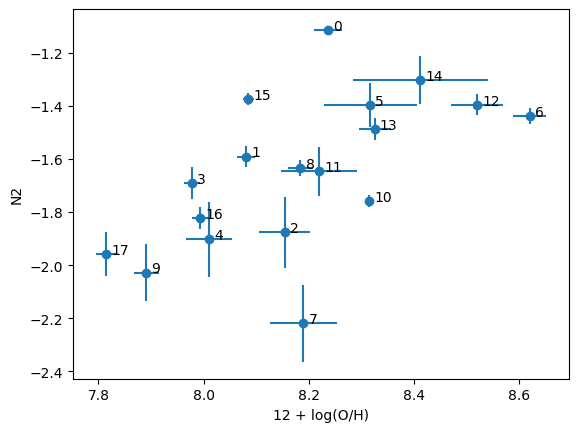

In [7]:
plt.errorbar(metals['log_OH'], upy.nominal_values(N2), 
             xerr=2*log_OH_err, yerr=10*upy.std_devs(N2),
            ls='', fmt='o')

for i in range(18):
    plt.text(metals['log_OH'][i]+0.01, upy.nominal_values(N2)[i], s=str(i))
plt.ylabel('N2')
plt.xlabel('12 + log(O/H)')

In [15]:
def ln_prior(theta):
    a0, a1, a2, Pb, Yb, logVb = theta
    if -20 < a0 < 20 and -20 < a1 < 20 and -20 < a2 < 0 and 0 < Pb < 1 and 0 < Yb < 2000 and -2 < logVb < 10:
        return 0
    return -np.inf

def ln_likelihood(theta, x, y, yerr):
    a0, a1, a2, Pb, Yb, logVb = theta
    Vb = 10**(logVb)
    model = a0 + a1 * x + a2 * x**2
    p_fg = (1 - Pb) / np.sqrt(2 * np.pi * yerr**2) * np.exp(-(y - model)**2/(2 * yerr**2))
    p_bg = Pb / np.sqrt(2 * np.pi * (Vb + yerr**2)) * np.exp(-(y - Yb)**2/(2 * (Vb + yerr**2)))
    output = np.sum(np.log(p_fg + p_bg))
    return output

def ln_posterior(theta, x, y, err):
    ln_p = ln_prior(theta)
    if not np.isfinite(ln_p):
        return -np.inf
    return ln_p + ln_likelihood(theta, x, y, err)

In [18]:
np.random.seed(6563)

theta_0 = np.array([0.5, 0.2, -0.1, 0.25, 400, 1.0])

ndim, nwalkers = 6, 32
pos_0 = [theta_0 + 0.1*np.random.randn(ndim) for i in range(nwalkers)]

sampler = emcee.EnsembleSampler(nwalkers, ndim, ln_posterior,
                               args=(metals['log_OH'].values,
                                     upy.nominal_values(R23),
                                     upy.std_devs(R23)), threads=8)

In [19]:
%timeit -n1 -r1 sampler.run_mcmc(pos_0, 1000)

/tmp/ipykernel_120369/3420653844.py:13: RuntimeWarning: divide by zero encountered in log
  output = np.sum(np.log(p_fg + p_bg))


1.26 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


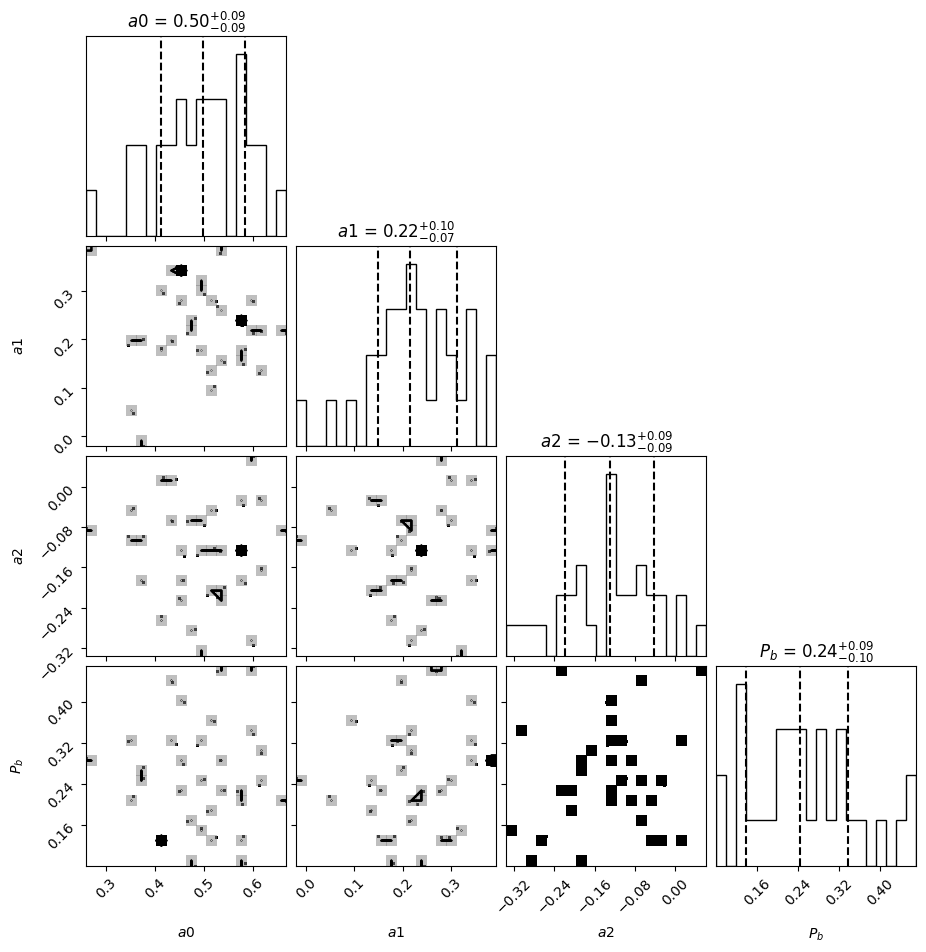

In [20]:
import corner

fig = corner.corner(sampler.flatchain[:, [0, 1, 2, 3]],
                   labels=['$a0$','$a1$', '$a2$', '$P_{b}$'],
                    quantiles=[0.16, 0.5, 0.84],
                    show_titles=True)

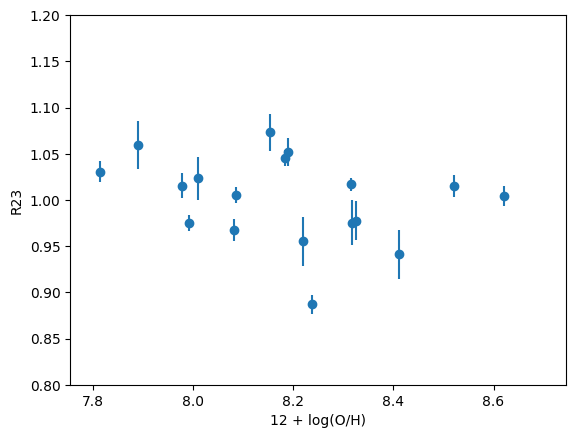

In [21]:
plt.errorbar(metals['log_OH'], upy.nominal_values(R23), 10*upy.std_devs(R23),
            ls='', fmt='o')
plt.ylabel('R23')
plt.xlabel('12 + log(O/H)')

plt.ylim(0.8, 1.2)

metal_to_plot = np.linspace(7.8, 8.7, 50)
for i in np.random.randint(0, high=len(sampler.flatchain), size=100):
    a0, a1, a2 = sampler.flatchain[i, [0, 1, 2]]
    plt.plot(metal_to_plot, a0 + a1 * metal_to_plot + a2 * metal_to_plot**2, color='k', alpha=0.05)
    

In [22]:
def ln_prior(theta):
    a0, a1, a2, s = theta
    if -20 < a0 < 20 and -20 < a1 < 20 and -20 < a2 < 0 and 0 < s < 1:
        return 0
    return -np.inf

def ln_likelihood(theta, x, y, yerr):
    a0, a1, a2, s = theta
    #Vb = 10**(logVb)
    model = a0 + a1 * x + a2 * x**2
    lh = 1 / np.sqrt(2 * np.pi * (yerr**2 + s**2)) * np.exp(-(y - model)**2/(2 * (yerr**2 + s**2)))
    output = np.sum(np.log(lh))
    return output

def ln_posterior(theta, x, y, err):
    ln_p = ln_prior(theta)
    if not np.isfinite(ln_p):
        return -np.inf
    return ln_p + ln_likelihood(theta, x, y, err)

In [52]:
np.random.seed(6563)

theta_0 = np.array([0.5, 0.2, -0.1, 0.1])

ndim, nwalkers = 4, 32
pos_0 = [theta_0 + 0.1*np.random.randn(ndim) for i in range(nwalkers)]

sampler = emcee.EnsembleSampler(nwalkers, ndim, ln_posterior,
                               args=(metals['log_OH'].values,
                                     upy.nominal_values(R23),
                                     upy.std_devs(R23)), threads=8)

In [53]:
%timeit -n1 -r1 sampler.run_mcmc(pos_0, 10000)

/tmp/ipykernel_120369/1809464726.py:12: RuntimeWarning: divide by zero encountered in log
  output = np.sum(np.log(lh))
/home/benjamin/anaconda3/envs/analogs/lib/python3.9/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


8.55 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


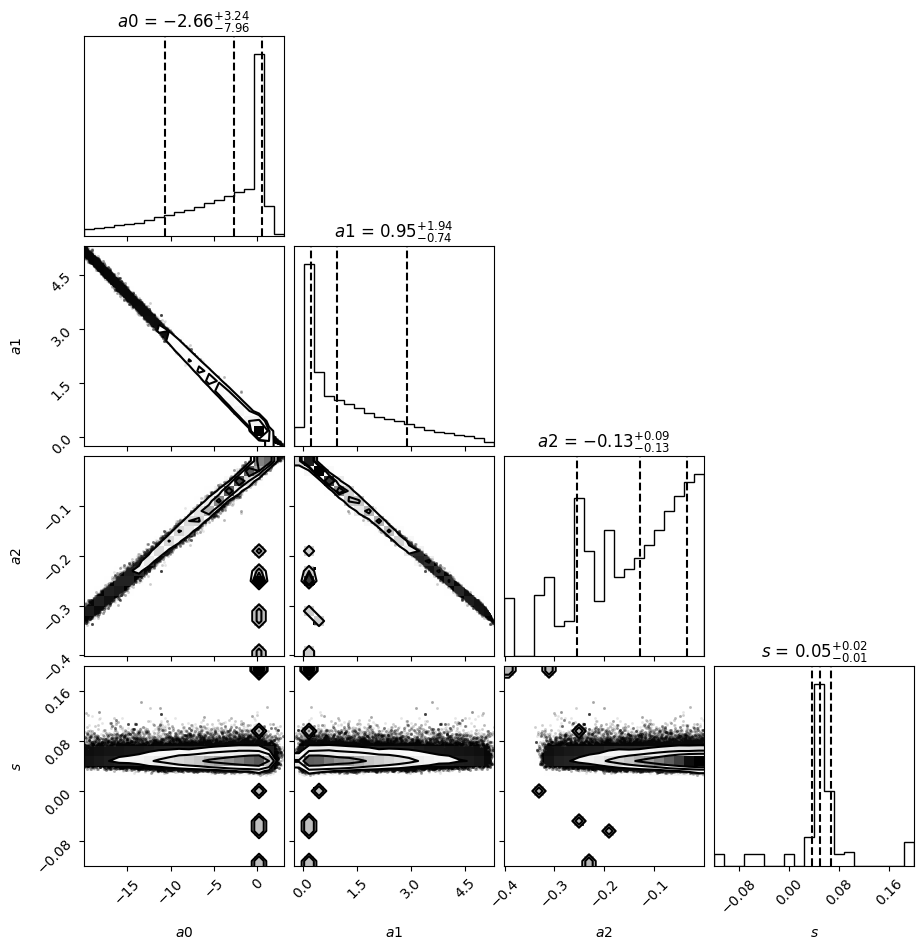

In [54]:
import corner

fig = corner.corner(sampler.flatchain[20000:, [0, 1, 2, 3]],
                   labels=['$a0$','$a1$', '$a2$', '$s$'],
                    quantiles=[0.16, 0.5, 0.84],
                    show_titles=True)

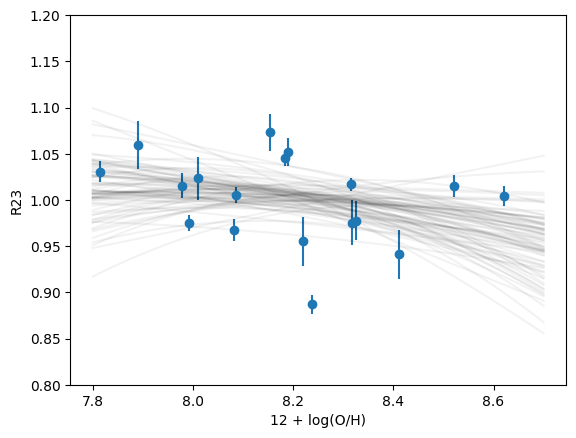

In [55]:
plt.errorbar(metals['log_OH'], upy.nominal_values(R23), 10*upy.std_devs(R23),
            ls='', fmt='o')
plt.ylabel('R23')
plt.xlabel('12 + log(O/H)')

plt.ylim(0.8, 1.2)

metal_to_plot = np.linspace(7.8, 8.7, 50)
for i in np.random.randint(0, high=len(sampler.flatchain), size=100):
    a0, a1, a2 = sampler.flatchain[i, [0, 1, 2]]
    plt.plot(metal_to_plot, a0 + a1 * metal_to_plot + a2 * metal_to_plot**2, color='k', alpha=0.05)

# Testing outliers fit with Huber

# Fits

## Linear

In [36]:
# ===========================================================================================================
# N2 Ratio
# ===========================================================================================================

params_N2 = Parameters()
params_N2.add('a0', value=np.mean(lm_n2_rev.chain['alpha']))
params_N2.add('a1', value=np.mean(lm_n2_rev.chain['beta']))

out_N2 = minimize(residuals_linear, params_N2, args=(metals['log_OH'].to_numpy(),
                                                     upy.nominal_values(N2),
                                                     upy.std_devs(N2)),
                                                     method='leastsq')

# ===========================================================================================================
# O3N2 Ratio
# ===========================================================================================================

params_O3N2 = Parameters()
params_O3N2.add('a0', value=-8.97/0.39)
params_O3N2.add('a1', value=-1/0.39)

out_O3N2 = minimize(residuals_linear, params_O3N2, args=(metals['log_OH'].to_numpy(),
                                                     upy.nominal_values(O3N2),
                                                     upy.std_devs(O3N2)),
                                                     method='leastsq')

# ===========================================================================================================
# O3O2 Ratio
# ===========================================================================================================

params_O3O2 = Parameters()
params_O3O2.add('a0', value=-8.54/0.59)
params_O3O2.add('a1', value=-1/0.59)

out_O3O2 = minimize(residuals_linear, params_O3O2, args=(metals['log_OH'].to_numpy(),
                                                         upy.nominal_values(O3O2),
                                                         upy.std_devs(O3O2)),
                                                         method='leastsq')

# ===========================================================================================================
# Ne3O2 Ratio
# ===========================================================================================================

params_Ne3O2 = Parameters()
params_Ne3O2.add('a0', value=-7.8/0.63)
params_Ne3O2.add('a1', value=-1/0.63)

out_Ne3O2 = minimize(residuals_linear, params_Ne3O2, args=(metals['log_OH'].to_numpy(),
                                                           upy.nominal_values(Ne3O2),
                                                           upy.std_devs(Ne3O2)),
                                                           method='leastsq')

# ===========================================================================================================
# S2 Ratio
# ===========================================================================================================

params_S2 = Parameters()
params_S2.add('a0', value=3)
params_S2.add('a1', value=3)

out_S2 = minimize(residuals_linear, params_S2, args=(metals['log_OH'].to_numpy(),
                                                     upy.nominal_values(S2),
                                                     upy.std_devs(S2)),
                                                     method='leastsq')

# ===========================================================================================================
# O3S2 Ratio
# ===========================================================================================================

params_O3S2 = Parameters()
params_O3S2.add('a0', value=-0.4)
params_O3S2.add('a1', value=-8.8)

out_O3S2 = minimize(residuals_linear, params_O3S2, args=(metals['log_OH'].to_numpy(),
                                                         upy.nominal_values(O3S2),
                                                         upy.std_devs(O3S2)),
                                                         method='leastsq')

In [13]:
# ===========================================================================================================
# N2 Ratio
# ===========================================================================================================

params_N2 = Parameters()
params_N2.add('a0', value=8.82)
params_N2.add('a1', value=0.49)

out_N2 = minimize(residuals_linear, params_N2, args=(upy.nominal_values(N2),
                                                     metals['log_OH'].to_numpy(),
                                                     log_OH_err),
                                                     method='leastsq')

#out_N2_med = minimize(residuals_linear, params_N2, args=(upy.nominal_values(bin_N2),
#                                                     upy.nominal_values(bin_OH),
#                                                     upy.std_devs(bin_OH)),
#                                                     method='leastsq')

# ===========================================================================================================
# O3N2 Ratio
# ===========================================================================================================

params_O3N2 = Parameters()
params_O3N2.add('a0', value=8.97)
params_O3N2.add('a1', value=-0.39)

out_O3N2 = minimize(residuals_linear, params_O3N2, args=(upy.nominal_values(O3N2),
                                                     metals['log_OH'].to_numpy(),
                                                     log_OH_err),
                                                     method='leastsq')

#out_O3N2_med = minimize(residuals_linear, params_O3N2, args=(upy.nominal_values(bin_O3N2),
#                                                     upy.nominal_values(bin_OH),
#                                                     upy.std_devs(bin_OH)),
#                                                     method='leastsq')

# ===========================================================================================================
# O3O2 Ratio
# ===========================================================================================================

params_O3O2 = Parameters()
params_O3O2.add('a0', value=8.54)
params_O3O2.add('a1', value=-0.59)

out_O3O2 = minimize(residuals_linear, params_O3O2, args=(upy.nominal_values(O3O2),
                                                     metals['log_OH'].to_numpy(),
                                                     log_OH_err),
                                                     method='leastsq')

#out_O3O2_med = minimize(residuals_linear, params_O3O2, args=(upy.nominal_values(bin_O3O2),
#                                                     upy.nominal_values(bin_OH),
#                                                     upy.std_devs(bin_OH)),
#                                                     method='leastsq')

# ===========================================================================================================
# Ne3O2 Ratio
# ===========================================================================================================

params_Ne3O2 = Parameters()
params_Ne3O2.add('a0', value=7.8)
params_Ne3O2.add('a1', value=-0.63)

out_Ne3O2 = minimize(residuals_linear, params_Ne3O2, args=(upy.nominal_values(Ne3O2),
                                                     metals['log_OH'].to_numpy(),
                                                     log_OH_err),
                                                     method='leastsq')

#out_Ne3O2_med = minimize(residuals_linear, params_Ne3O2, args=(upy.nominal_values(bin_Ne3O2),
#                                                     upy.nominal_values(bin_OH),
#                                                     upy.std_devs(bin_OH)),
#                                                     method='leastsq')

# ===========================================================================================================
# S2 Ratio
# ===========================================================================================================

params_S2 = Parameters()
params_S2.add('a0', value=0.9)
params_S2.add('a1', value=9.2)

out_S2 = minimize(residuals_linear, params_S2, args=(upy.nominal_values(S2),
                                                     metals['log_OH'].to_numpy(),
                                                     log_OH_err),
                                                     method='leastsq')

#out_S2_med = minimize(residuals_linear, params_S2, args=(upy.nominal_values(bin_S2),
#                                                     upy.nominal_values(bin_OH),
#                                                     upy.std_devs(bin_OH)),
#                                                     method='leastsq')

# ===========================================================================================================
# O3S2 Ratio
# ===========================================================================================================

params_O3S2 = Parameters()
params_O3S2.add('a0', value=-0.4)
params_O3S2.add('a1', value=-8.8)

out_O3S2 = minimize(residuals_linear, params_O3S2, args=(upy.nominal_values(O3S2),
                                                     metals['log_OH'].to_numpy(),
                                                     log_OH_err),
                                                     method='leastsq')

#out_O3S2_med = minimize(residuals_linear, params_O3S2, args=(upy.nominal_values(bin_O3S2),
#                                                     upy.nominal_values(bin_OH),
#                                                     upy.std_devs(bin_OH)),
#                                                     method='leastsq')

In [27]:
np.random.seed(999)

lm_n2 = linmix.LinMix(upy.nominal_values(N2), metals['log_OH'].to_numpy(),
                      upy.std_devs(N2), log_OH_err)
lm_n2.run_mcmc(silent=True)

lm_n2_rev = linmix.LinMix(metals['log_OH'].to_numpy(), upy.nominal_values(N2), 
                         log_OH_err, upy.std_devs(N2))
lm_n2_rev.run_mcmc(silent=True)



lm_o3n2 = linmix.LinMix(upy.nominal_values(O3N2), metals['log_OH'].to_numpy(),
                      upy.std_devs(O3N2), log_OH_err)
lm_o3n2.run_mcmc(silent=True)

lm_o3n2_rev = linmix.LinMix(metals['log_OH'].to_numpy(), upy.nominal_values(O3N2), 
                            log_OH_err, upy.std_devs(O3N2))
lm_o3n2_rev.run_mcmc(silent=True)




lm_o3o2 = linmix.LinMix(upy.nominal_values(O3O2), metals['log_OH'].to_numpy(),
                      upy.std_devs(O3O2), log_OH_err)
lm_o3o2.run_mcmc(silent=True)

lm_o3o2_rev = linmix.LinMix(metals['log_OH'].to_numpy(), upy.nominal_values(O3O2), 
                            log_OH_err, upy.std_devs(O3O2))
lm_o3o2_rev.run_mcmc(silent=True)



lm_ne3o2 = linmix.LinMix(upy.nominal_values(Ne3O2), metals['log_OH'].to_numpy(),
                      upy.std_devs(Ne3O2), log_OH_err)
lm_ne3o2.run_mcmc(silent=True)

lm_ne3o2_rev = linmix.LinMix(metals['log_OH'].to_numpy(), upy.nominal_values(Ne3O2), 
                             log_OH_err, upy.std_devs(Ne3O2))
lm_ne3o2_rev.run_mcmc(silent=True)




lm_s2 = linmix.LinMix(upy.nominal_values(S2), metals['log_OH'].to_numpy(),
                      upy.std_devs(S2), log_OH_err)
lm_s2.run_mcmc(silent=True)

lm_s2_rev = linmix.LinMix(metals['log_OH'].to_numpy(), upy.nominal_values(S2), 
                            log_OH_err, upy.std_devs(S2))
lm_s2_rev.run_mcmc(silent=True)



lm_o3s2 = linmix.LinMix(upy.nominal_values(O3S2), metals['log_OH'].to_numpy(),
                      upy.std_devs(O3S2), log_OH_err)
lm_o3s2.run_mcmc(silent=True)

lm_o3s2_rev = linmix.LinMix(metals['log_OH'].to_numpy(), upy.nominal_values(O3S2), 
                            log_OH_err, upy.std_devs(O3S2))
lm_o3s2_rev.run_mcmc(silent=True)

## Testing fitting with outliers

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
import sklearn.metrics as skm

In [29]:
np.random.seed(999)

# ===========================================================================================================
# R2 Ratio
# ===========================================================================================================

R2_data = pd.DataFrame({'x': metals['log_OH'].values,
                        'y': upy.nominal_values(R2)})

train_R2, test_R2 = train_test_split(R2_data)
R2_weights = (1/(upy.std_devs(R2[train_R2.x.index])**2))

poly_R2 = PolynomialFeatures()
reg_R2 = HuberRegressor(epsilon=1.35, alpha=0.001)

x_poly_R2 = poly_R2.fit_transform(train_R2.x.values.reshape(-1, 1))
reg_R2.fit(x_poly_R2, train_R2.y.values, R2_weights)

# ===========================================================================================================
# R3 Ratio
# ===========================================================================================================

R3_data = pd.DataFrame({'x': metals['log_OH'].values,
                        'y': upy.nominal_values(R3)})

train_R3, test_R3 = train_test_split(R3_data)
R3_weights = (1/(upy.std_devs(R3[train_R3.x.index])**2))

poly_R3 = PolynomialFeatures()
reg_R3 = HuberRegressor(epsilon=1.35, alpha=0.001)

x_poly_R3 = poly_R3.fit_transform(train_R3.x.values.reshape(-1, 1))
reg_R3.fit(x_poly_R3, train_R3.y.values, R3_weights)

# ===========================================================================================================
# R23 Ratio
# ===========================================================================================================

R23_data = pd.DataFrame({'x': metals['log_OH'].values,
                         'y': upy.nominal_values(R23)})

train_R23, test_R23 = train_test_split(R23_data)
R23_weights = (1/(upy.std_devs(R23[train_R23.x.index])**2))

poly_R23 = PolynomialFeatures()
reg_R23 = HuberRegressor(epsilon=1.35, alpha=0.001)

x_poly_R23 = poly_R23.fit_transform(train_R23.x.values.reshape(-1, 1))
reg_R23.fit(x_poly_R23, train_R23.y.values, R23_weights)

# ===========================================================================================================
# R3N2 Ratio
# ===========================================================================================================

R3N2_data = pd.DataFrame({'x': metals['log_OH'].values,
                          'y': upy.nominal_values(R3N2)})

train_R3N2, test_R3N2 = train_test_split(R3N2_data)
R3N2_weights = (1/(upy.std_devs(R3N2[train_R3N2.x.index])**2))

poly_R3N2 = PolynomialFeatures()
reg_R3N2 = HuberRegressor(epsilon=1.35, alpha=0.001)

x_poly_R3N2 = poly_R3N2.fit_transform(train_R3N2.x.values.reshape(-1, 1))
reg_R3N2.fit(x_poly_R3N2, train_R3N2.y.values, R3N2_weights)

# ===========================================================================================================
# N2O2 Ratio
# ===========================================================================================================

N2O2_data = pd.DataFrame({'x': metals['log_OH'].values,
                          'y': upy.nominal_values(N2O2)})

train_N2O2, test_N2O2 = train_test_split(N2O2_data)
N2O2_weights = (1/(upy.std_devs(N2O2[train_N2O2.x.index])**2))

poly_N2O2 = PolynomialFeatures()
reg_N2O2 = HuberRegressor(epsilon=1.35, alpha=0.001)

x_poly_N2O2 = poly_N2O2.fit_transform(train_N2O2.x.values.reshape(-1, 1))
reg_N2O2.fit(x_poly_N2O2, train_N2O2.y.values, N2O2_weights)

# ===========================================================================================================
# N2S2 Ratio
# ===========================================================================================================

N2S2_data = pd.DataFrame({'x': metals['log_OH'].values,
                          'y': upy.nominal_values(N2S2)})

train_N2S2, test_N2S2 = train_test_split(N2S2_data)
N2S2_weights = (1/(upy.std_devs(N2S2[train_N2S2.x.index])**2))

poly_N2S2 = PolynomialFeatures()
reg_N2S2 = HuberRegressor(epsilon=1.35, alpha=0.001)

x_poly_N2S2 = poly_N2S2.fit_transform(train_N2S2.x.values.reshape(-1, 1))
reg_N2S2.fit(x_poly_N2S2, train_N2S2.y.values, N2S2_weights)


HuberRegressor(alpha=0.001)

### N2

In [30]:
mask_N2_train = (1 / upy.std_devs(N2)**2) < 100000

xdata_cut = metals['log_OH'].values[mask_N2_train].reshape(-1, 1)
ydata_cut = upy.nominal_values(N2[mask_N2_train]).reshape(-1, 1)
N2_weights_cut = ((1/(upy.std_devs(N2[mask_N2_train])**2)))
N2_weights_cut

ols_cut = LinearRegression()
huber_cut = HuberRegressor(epsilon=1.35, alpha=0.001)
ols_cut.fit(xdata_cut, ydata_cut, sample_weight=N2_weights_cut)
huber_cut.fit(xdata_cut, ydata_cut, sample_weight=N2_weights_cut)

/home/benjamin/anaconda3/envs/analogs/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


HuberRegressor(alpha=0.001)

/home/benjamin/anaconda3/envs/analogs/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/benjamin/anaconda3/envs/analogs/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/benjamin/anaconda3/envs/analogs/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/benjamin/anaconda3/envs/analogs/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-v

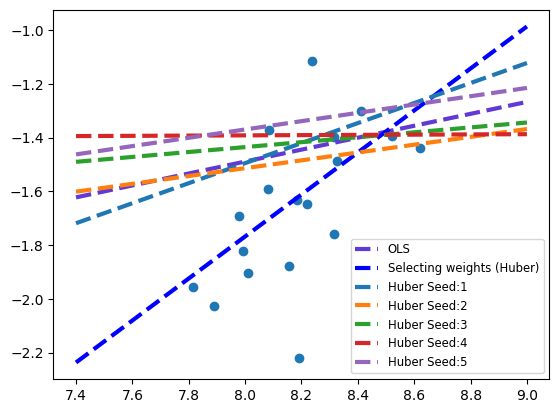

In [38]:
# Hubber loss

N2_data = pd.DataFrame({'x': metals['log_OH'].values,
                         'y': upy.nominal_values(N2)})

plt.scatter(metals['log_OH'], upy.nominal_values(N2))
plt.plot(log_OH_tp, linear(log_OH_tp, out_N2.params['a0'].value, out_N2.params['a1'].value), color=c[2], ls='--', lw=3, label='OLS')
plt.plot(log_OH_tp, huber_cut.predict(log_OH_tp.reshape(-1, 1)), 
         lw=3, ls='--', color='blue', label='Selecting weights (Huber)')

for seed in [1, 2, 3, 4, 5]:
    np.random.seed(seed)
    train, test = train_test_split(N2_data)
    N2_weights = (1/(upy.std_devs(N2[train.x.index])**2))
    N2_weights
    
    huber = HuberRegressor(epsilon=1.35, alpha=0.001)
    huber.fit(train.x.values.reshape(-1, 1), train.y.values.reshape(-1, 1), sample_weight=N2_weights)

    plt.plot(log_OH_tp, huber.predict(log_OH_tp.reshape(-1, 1)), 
         lw=3, ls='--', label='Huber Seed:'+str(seed))

plt.legend(fontsize='small')

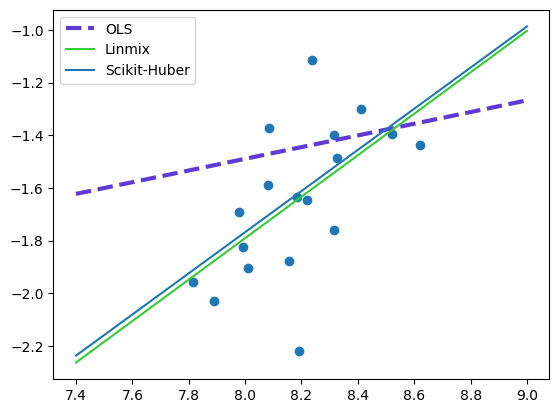

In [39]:
plt.scatter(metals['log_OH'], upy.nominal_values(N2))
plt.plot(log_OH_tp, (log_OH_tp * out_N2.params['a1'].value) + out_N2.params['a0'].value,
               color=c[2], ls='--', lw=3, label='OLS')
plt.plot(log_OH_tp, (log_OH_tp * lm_n2_rev.chain['beta'].mean()) + lm_n2_rev.chain['alpha'].mean(),
        color='limegreen', label='Linmix')
plt.plot(log_OH_tp, huber_cut.predict(log_OH_tp.reshape(-1, 1)), label='Scikit-Huber')
plt.legend()

### R23 

/home/benjamin/anaconda3/envs/analogs/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


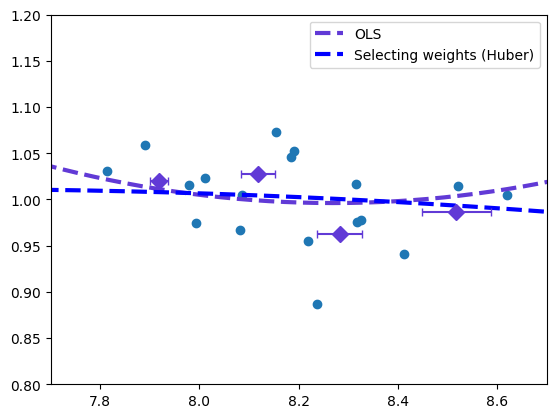

In [43]:
mask_R23_train = (1 / upy.std_devs(R23)**2) < 1e6

xdata_cut = metals['log_OH'].values[mask_R23_train].reshape(-1, 1)
ydata_cut = upy.nominal_values(R23[mask_R23_train]).reshape(-1, 1)
R23_weights_cut = (1/(upy.std_devs(R23[mask_R23_train])**2))
R23_weights_cut

poly_cut = PolynomialFeatures()
reg_cut = HuberRegressor(epsilon=1.35, alpha=0.001)

x_poly_cut = poly_cut.fit_transform(xdata_cut)
reg_cut.fit(x_poly_cut, ydata_cut, R23_weights_cut)
reg_cut.coef_

plt.scatter(metals['log_OH'], upy.nominal_values(R23))
plt.plot(log_OH_tp, poly2(log_OH_tp, *out_R23), color=c[2], ls='--', lw=3, label='OLS')
plt.plot(log_OH_tp, reg_cut.predict(poly_cut.fit_transform(log_OH_tp.reshape(-1, 1))), 
         lw=3, ls='--', color='blue', label='Selecting weights (Huber)')
plt.errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R23),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R23),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
plt.ylim(0.8, 1.2)
plt.xlim(7.7, 8.7)
plt.legend()

Seed: 1 RMS:0.04353730489443654
Seed: 2 RMS:0.04568278280403797
Seed: 3 RMS:0.0442874538743206
Seed: 4 RMS:0.0452050194599438
Seed: 5 RMS:0.04343241023096341


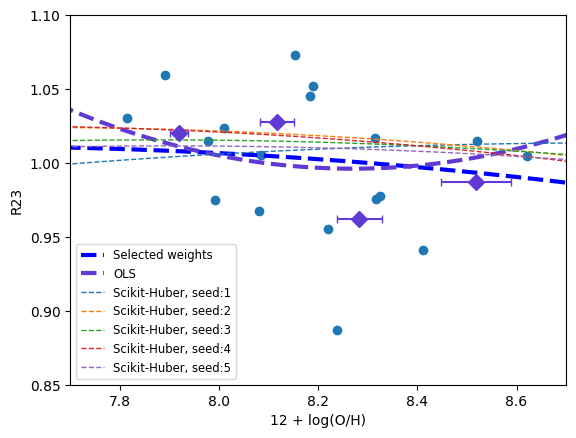

In [44]:
R23_data = pd.DataFrame({'x': metals['log_OH'].values,
                         'y': upy.nominal_values(R23)})

plt.scatter(metals['log_OH'], upy.nominal_values(R23))
plt.plot(log_OH_tp, reg_cut.predict(poly_cut.fit_transform(log_OH_tp.reshape(-1, 1))), 
         lw=3, ls='--', color='blue', label='Selected weights')
plt.errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R23),
                       xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R23),
                       ls='', color=c[2], capsize=3, marker='D', markersize=8)
plt.plot(log_OH_tp, poly2(log_OH_tp, *out_R23), color=c[2], ls='--', lw=3, label='OLS')
plt.ylabel('R23')
plt.xlabel('12 + log(O/H)')
for seed in [1, 2, 3, 4, 5]:
    np.random.seed(seed)
    train, test = train_test_split(R23_data)
    R23_weights = (1/(upy.std_devs(R23[train.x.index])**2))
    R23_weights

    poly = PolynomialFeatures()
    reg = HuberRegressor(epsilon=1.35, alpha=0.001)

    x_poly = poly.fit_transform(train.x.values.reshape(-1, 1))
    reg.fit(x_poly, train.y.values, R23_weights)


    plt.plot(log_OH_tp, reg.predict(poly.fit_transform(log_OH_tp.reshape(-1, 1))), 
             lw=1, ls='--', label='Scikit-Huber, seed:'+ str(seed))
    
    rms = skm.mean_squared_error(y_true=upy.nominal_values(R23),
                       y_pred=reg.predict(poly.fit_transform(metals['log_OH'].values.reshape(-1, 1))),
                       sample_weight=(1 / upy.std_devs(R23)**2),
                       squared=False)
    print('Seed: '+str(seed), 'RMS:'+str(rms))
plt.ylim(0.85, 1.1)
plt.xlim(7.7, 8.7)
plt.legend(fontsize='small')

In [45]:
rms_cut = skm.mean_squared_error(upy.nominal_values(R23),
                       reg_cut.predict(poly_cut.fit_transform(metals['log_OH'].values.reshape(-1, 1))),
                       sample_weight=(1 / upy.std_devs(R23)**2),
                       squared=False)
print('Selecting weights:', rms_cut)

Selecting weights: 0.042815594818483856


## Polynomial

In [41]:
# ===========================================================================================================
# R2 Ratio
# ===========================================================================================================

out_R2, cov_R2 = scipy.optimize.curve_fit(poly2, upy.nominal_values(metals['log_OH']), upy.nominal_values(R2),
                                         p0=[-154.9571, 36.9128, -2.1921], sigma=upy.std_devs(R2),
                                         absolute_sigma=True)

#out_R2_med, cov_R2_med = scipy.optimize.curve_fit(poly2, upy.nominal_values(bin_OH), upy.nominal_values(bin_R2),
#                                         p0=[-154.9571, 36.9128, -2.1921], sigma=upy.std_devs(bin_R2),
#                                         absolute_sigma=True)

# ===========================================================================================================
# R3 Ratio
# ===========================================================================================================

out_R3, cov_R3 = scipy.optimize.curve_fit(poly2, upy.nominal_values(metals['log_OH']), upy.nominal_values(R3),
                                         p0=[-88.4378, 22.7529, -1.4501], sigma=upy.std_devs(R3),
                                         absolute_sigma=True)

#out_R3_med, cov_R3_med = scipy.optimize.curve_fit(poly2, upy.nominal_values(bin_OH), upy.nominal_values(bin_R3),
#                                         p0=[-88.4378, 22.7529, -1.4501], sigma=upy.std_devs(bin_R3),
#                                         absolute_sigma=True)

# ===========================================================================================================
# R23 Ratio
# ===========================================================================================================

out_R23, cov_R23 = scipy.optimize.curve_fit(poly2, upy.nominal_values(metals['log_OH']), upy.nominal_values(R23),
                                   p0=[-26.21514017, 6.78095055, -0.42194886], sigma=upy.std_devs(R23),
                                   absolute_sigma=True)

#out_R23_med, cov_R23_med = scipy.optimize.curve_fit(poly2, upy.nominal_values(bin_OH), upy.nominal_values(bin_R23),
#                                   p0=[-26.21514017, 6.78095055, -0.42194886], sigma=upy.std_devs(bin_R23),
#                                   absolute_sigma=True)

# ===========================================================================================================
# R3N2 Ratio
# ===========================================================================================================

out_R3N2, cov_R3N2 = scipy.optimize.curve_fit(poly2, upy.nominal_values(metals['log_OH']), upy.nominal_values(R3N2),
                                    p0=[-94.40880246, 24.76665082, -1.58572683], sigma=upy.std_devs(R3N2),
                                    absolute_sigma=True)

#out_R3N2_med, cov_R3N2_med = scipy.optimize.curve_fit(poly2, upy.nominal_values(bin_OH), upy.nominal_values(bin_R3N2),
#                                    p0=[-94.40880246, 24.76665082, -1.58572683], sigma=upy.std_devs(bin_R3N2),
#                                    absolute_sigma=True)

# ===========================================================================================================
# N2O2 Ratio
# ===========================================================================================================

out_N2O2, cov_N2O2 = scipy.optimize.curve_fit(poly2, upy.nominal_values(metals['log_OH']), upy.nominal_values(N2O2),
                                    p0=[128.94, -48.818, 6.2759], sigma=upy.std_devs(N2O2),
                                    absolute_sigma=True)

#out_N2O2_med, cov_N2O2_med = scipy.optimize.curve_fit(poly2, upy.nominal_values(bin_OH), upy.nominal_values(bin_N2O2),
#                                    p0=[128.94, -48.818, 6.2759], sigma=upy.std_devs(bin_N2O2),
#                                    absolute_sigma=True)

# ===========================================================================================================
# N2S2 Ratio
# ===========================================================================================================

out_N2S2, cov_N2S2 = scipy.optimize.curve_fit(poly2, upy.nominal_values(metals['log_OH']), upy.nominal_values(N2S2),
                                    p0=[128.94, -48.818, 6.2759], sigma=upy.std_devs(N2S2),
                                    absolute_sigma=True)

#out_N2S2_med, cov_N2S2_med = scipy.optimize.curve_fit(poly2, upy.nominal_values(bin_OH), upy.nominal_values(bin_N2S2),
#                                    p0=[128.94, -48.818, 6.2759], sigma=upy.std_devs(bin_N2S2),
#                                    absolute_sigma=True)

# Metallicity Calibrations

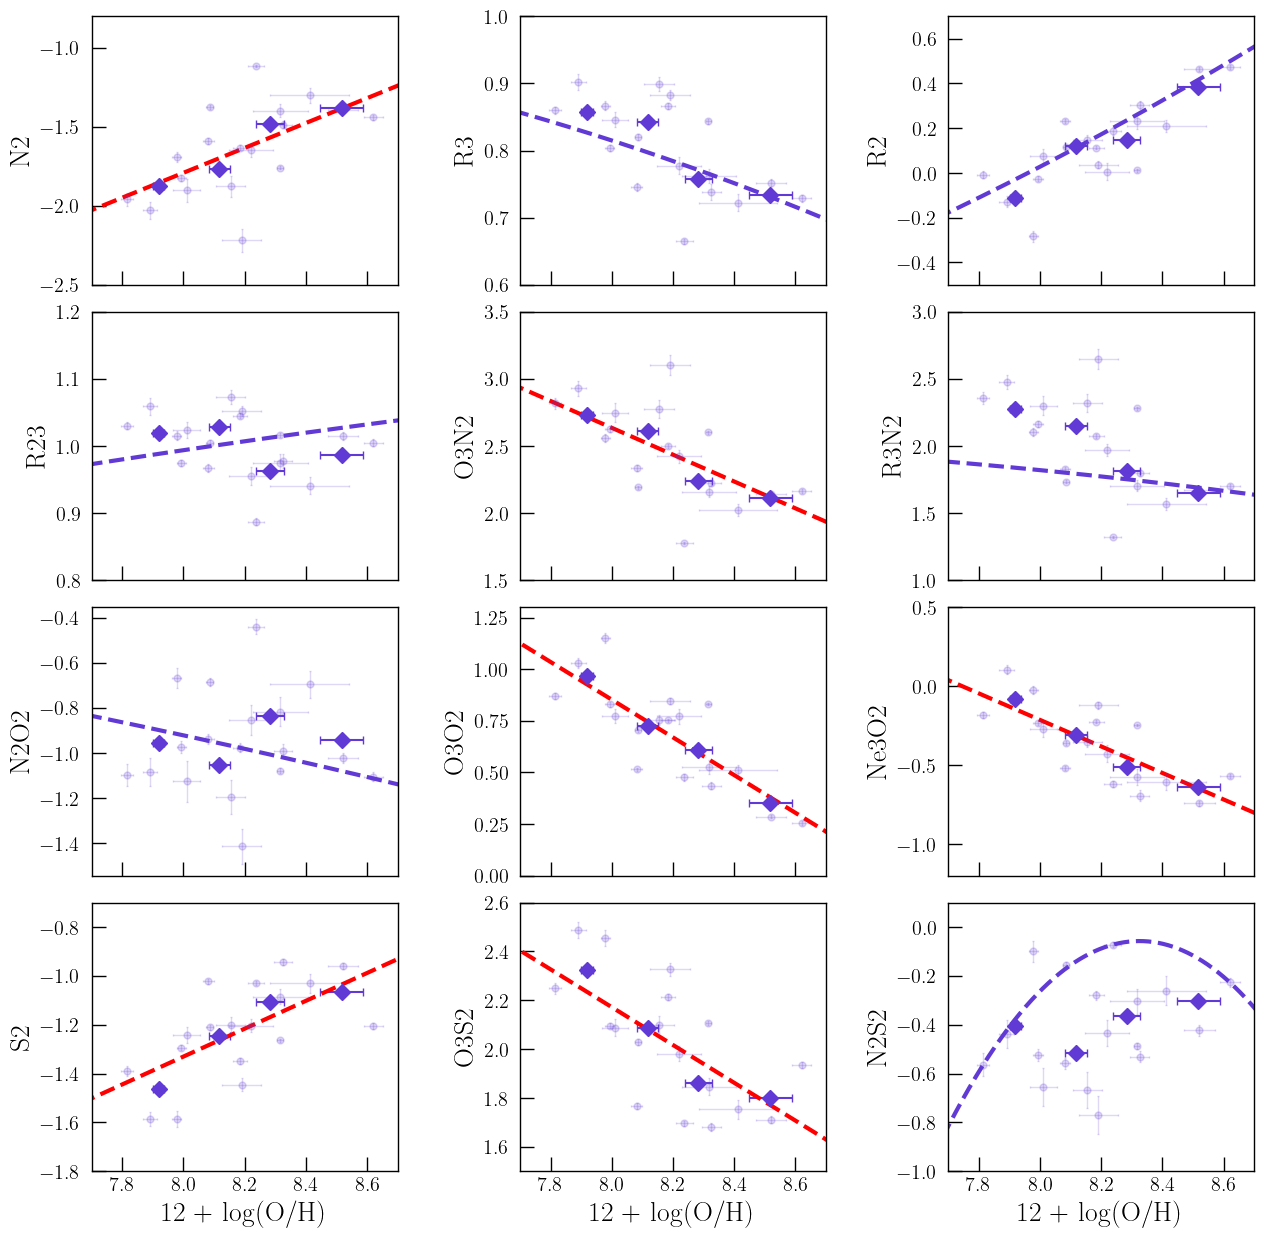

In [27]:
texPlot('on')
fig, axs = plt.subplots(4, 3, sharex=True)
fig.set_size_inches((15, 15))
fig.subplots_adjust(wspace=0.4, hspace=0.1)

# ===========================================================================================================
# N2
# ===========================================================================================================

axs[0, 0].errorbar(metals['log_OH'], upy.nominal_values(N2), xerr=2*log_OH_err, yerr=5*upy.std_devs(N2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 0].plot(log_OH_tp, (log_OH_tp * np.mean(lm_n2_rev.chain['beta'])) + np.mean(lm_n2_rev.chain['alpha']),
               color='red', ls='--', lw=3)
axs[0, 0].set_ylabel('N2')

# ===========================================================================================================
# R3
# ===========================================================================================================

axs[0, 1].errorbar(metals['log_OH'], upy.nominal_values(R3), xerr=2*log_OH_err, yerr=5*upy.std_devs(R3), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R3),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R3),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 1].plot(log_OH_tp, reg_R3.predict(poly_R3.fit_transform(log_OH_tp.reshape(-1, 1))), color=c[2], ls='--', lw=3)
axs[0, 1].set_ylabel('R3')

# ===========================================================================================================
# R2
# ===========================================================================================================

axs[0, 2].errorbar(metals['log_OH'], upy.nominal_values(R2), xerr=2*log_OH_err, yerr=5*upy.std_devs(R2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 2].plot(log_OH_tp, reg_R2.predict(poly_R2.fit_transform(log_OH_tp.reshape(-1, 1))), color=c[2], ls='--', lw=3)
axs[0, 2].set_ylabel('R2')

# ===========================================================================================================
# R23
# ===========================================================================================================

axs[1, 0].errorbar(metals['log_OH'], upy.nominal_values(R23), xerr=2*log_OH_err, yerr=5*upy.std_devs(R23), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[1, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R23),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R23),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 0].plot(log_OH_tp, reg_R23.predict(poly_R23.fit_transform(log_OH_tp.reshape(-1, 1))), color=c[2], ls='--', lw=3)
axs[1, 0].set_ylabel('R23')

# ===========================================================================================================
# O3N2
# ===========================================================================================================

axs[1, 1].errorbar(metals['log_OH'], upy.nominal_values(O3N2), xerr=2*log_OH_err, yerr=5*upy.std_devs(O3N2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[1, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3N2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_O3N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 1].plot(log_OH_tp, (log_OH_tp * np.mean(lm_o3n2_rev.chain['beta'])) + np.mean(lm_o3n2_rev.chain['alpha']),
               color='red', ls='--', lw=3)
axs[1, 1].set_ylabel('O3N2')

# ===========================================================================================================
# R3N2
# ===========================================================================================================

axs[1, 2].errorbar(metals['log_OH'], upy.nominal_values(R3N2), xerr=2*log_OH_err, yerr=5*upy.std_devs(R3N2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[1, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R3N2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R3N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 2].plot(log_OH_tp, reg_R3N2.predict(poly_R3N2.fit_transform(log_OH_tp.reshape(-1, 1))), color=c[2], ls='--', lw=3)
axs[1, 2].set_ylabel('R3N2')


# ===========================================================================================================
# N2O2
# ===========================================================================================================

axs[2, 0].errorbar(metals['log_OH'], upy.nominal_values(N2O2), xerr=2*log_OH_err, yerr=5*upy.std_devs(N2O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[2, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2O2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_N2O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 0].plot(log_OH_tp, reg_N2O2.predict(poly_N2O2.fit_transform(log_OH_tp.reshape(-1, 1))), color=c[2], ls='--', lw=3)
axs[2, 0].set_ylabel('N2O2')

# ===========================================================================================================
# O3O2
# ===========================================================================================================

axs[2, 1].errorbar(metals['log_OH'], upy.nominal_values(O3O2), xerr=2*log_OH_err, yerr=5*upy.std_devs(O3O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[2, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3O2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_O3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 1].plot(log_OH_tp, (log_OH_tp * np.mean(lm_o3o2_rev.chain['beta'])) + np.mean(lm_o3o2_rev.chain['alpha']),
               color='red', ls='--', lw=3)
axs[2, 1].set_ylabel('O3O2')

# ===========================================================================================================
# Ne3O2
# ===========================================================================================================

axs[2, 2].errorbar(metals['log_OH'], upy.nominal_values(Ne3O2), xerr=2*log_OH_err, yerr=5*upy.std_devs(Ne3O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[2, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_Ne3O2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_Ne3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 2].plot(log_OH_tp, (log_OH_tp * np.mean(lm_ne3o2_rev.chain['beta'])) + np.mean(lm_ne3o2_rev.chain['alpha']),
               color='red', ls='--', lw=3)
axs[2, 2].set_ylabel('Ne3O2')

# ===========================================================================================================
# S2
# ===========================================================================================================

axs[3, 0].errorbar(metals['log_OH'], upy.nominal_values(S2), xerr=2*log_OH_err, yerr=5*upy.std_devs(S2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[3, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_S2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_S2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[3, 0].plot(log_OH_tp, (log_OH_tp * np.mean(lm_s2_rev.chain['beta'])) + np.mean(lm_s2_rev.chain['alpha']),
               color='red', ls='--', lw=3)
axs[3, 0].set_ylabel('S2')

# ===========================================================================================================
# O3S2
# ===========================================================================================================

axs[3, 1].errorbar(metals['log_OH'], upy.nominal_values(O3S2), xerr=2*log_OH_err, yerr=5*upy.std_devs(O3S2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[3, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3S2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_O3S2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[3, 1].plot(log_OH_tp, (log_OH_tp * np.mean(lm_o3s2_rev.chain['beta'])) + np.mean(lm_o3s2_rev.chain['alpha']),
               color='red', ls='--', lw=3)
axs[3, 1].set_ylabel('O3S2')

# ===========================================================================================================
# N2S2
# ===========================================================================================================

axs[3, 2].errorbar(metals['log_OH'], upy.nominal_values(N2S2), xerr=2*log_OH_err, yerr=5*upy.std_devs(N2S2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[3, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2S2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_N2S2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[3, 2].plot(log_OH_tp, reg_N2S2.predict(poly_N2S2.fit_transform(log_OH_tp.reshape(-1, 1))), color=c[2], ls='--', lw=3)
axs[3, 2].set_ylabel('N2S2')

# ===========================================================================================================
# General settings
# ===========================================================================================================

axs[3, 0].set_xlabel(r'12 + log(O/H)')
axs[3, 1].set_xlabel(r'12 + log(O/H)')
axs[3, 2].set_xlabel(r'12 + log(O/H)')

# limits
# x
axs[0, 0].set_xlim(7.7, 8.7) 

# y
axs[0, 0].set_ylim(-2.5, -0.8) # N2
axs[0, 1].set_ylim(0.6, 1.0) # R3
axs[0, 2].set_ylim(-0.5, 0.7) # R2

axs[1, 0].set_ylim(0.8, 1.2) # R23
axs[1, 1].set_ylim(1.5, 3.5) # O3N2
axs[1, 2].set_ylim(1, 3) # R3N2

axs[2, 1].set_ylim(0, 1.3) # O3O2
axs[2, 2].set_ylim(-1.2, 0.5) # Ne3O2

axs[3, 0].set_ylim(-1.8, -0.7) # S2
axs[3, 1].set_ylim(1.5, 2.6) # O3S2
axs[3, 2].set_ylim(-1.0, 0.1) # N2S2


index_model = [0, 1, 2, 3]
index_sec = [0, 1, 2]
for i in index_model:
    for j in index_sec:
        axs[i, j].tick_params(axis="y", direction="in", length=10)
        axs[i, j].tick_params(axis="x", direction="in", length=10)

NameError: name 'out_N2' is not defined

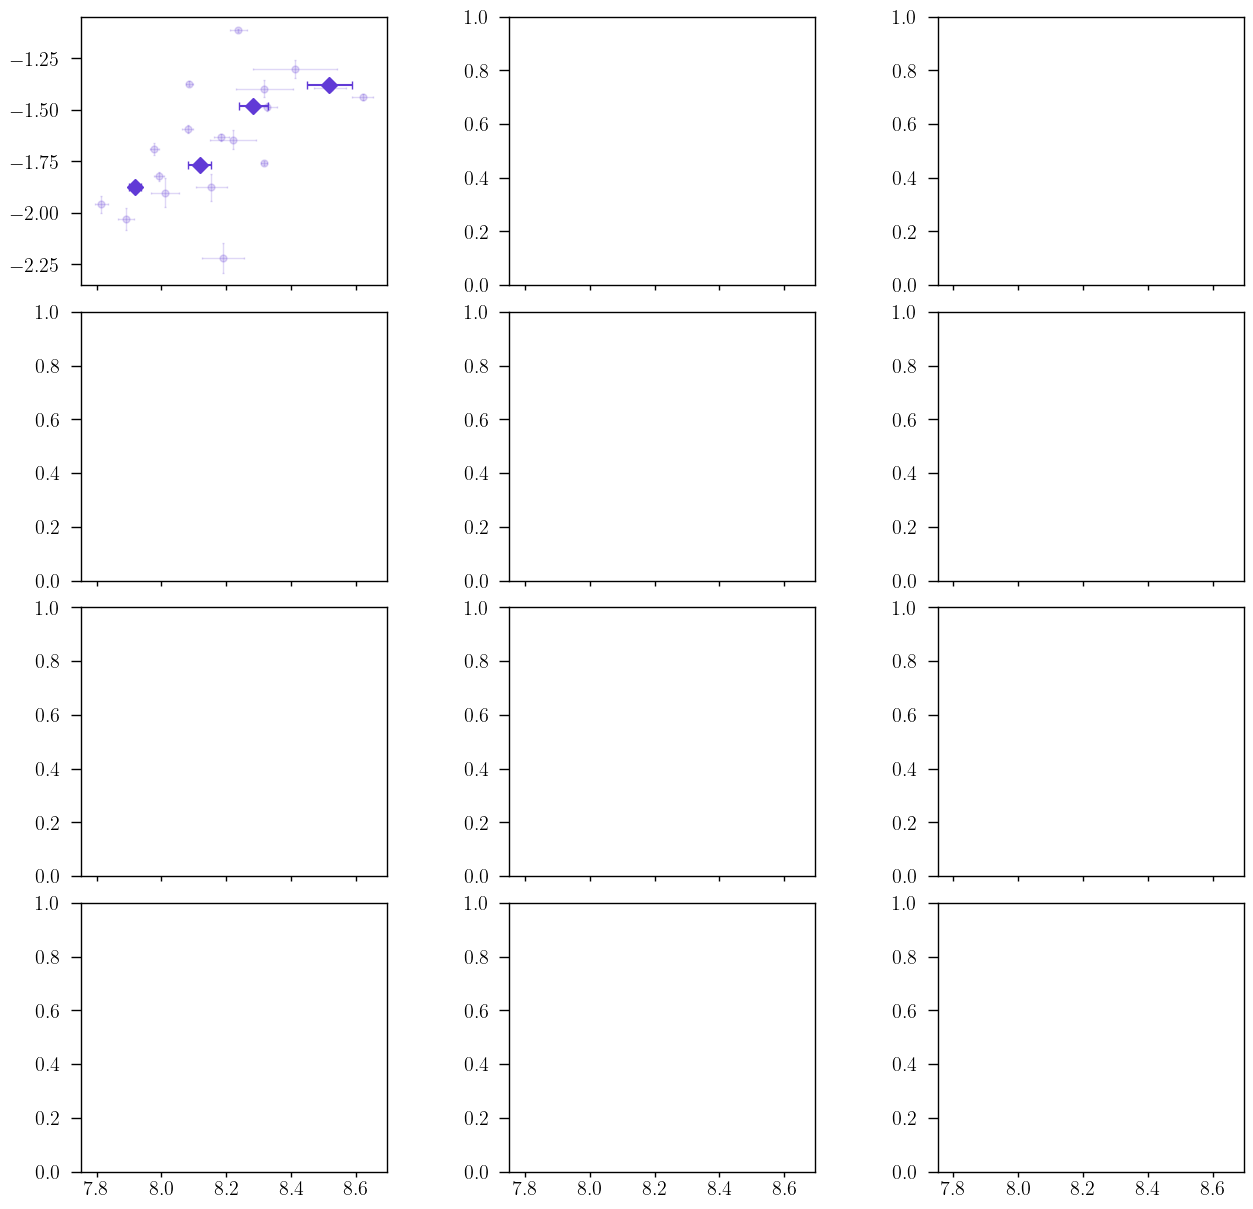

In [8]:
texPlot('on')
fig, axs = plt.subplots(4, 3, sharex=True)
fig.set_size_inches((15, 15))
fig.subplots_adjust(wspace=0.4, hspace=0.1)

# ===========================================================================================================
# N2
# ===========================================================================================================

axs[0, 0].errorbar(metals['log_OH'], upy.nominal_values(N2), xerr=2*log_OH_err, yerr=5*upy.std_devs(N2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 0].plot(log_OH_tp, (log_OH_tp * np.mean(lm_n2_rev.chain['beta'])) + np.mean(lm_n2_rev.chain['alpha']),
               color=c[2], ls='--', lw=3)
axs[0, 0].plot(log_OH_tp, ols.predict(log_OH_tp.reshape(-1, 1)), label='Scikit-OLS')
axs[0, 0].plot(log_OH_tp, huber.predict(log_OH_tp.reshape(-1, 1)), label='Scikit-Huber')
axs[0, 0].set_ylabel('N2')

# ===========================================================================================================
# R3
# ===========================================================================================================

axs[0, 1].errorbar(metals['log_OH'], upy.nominal_values(R3), xerr=2*log_OH_err, yerr=5*upy.std_devs(R3), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R3),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R3),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 1].plot(log_OH_tp, reg_R3(poly_R3.fit_transform(metals['log_OH'].values.reshape(-1, 1))), color=c[2], ls='--', lw=3)
axs[0, 1].plot(log_OH_tp, poly2(log_OH_tp, *out_R3), color=c[2], ls='--', lw=3)
axs[0, 1].set_ylabel('R3')

# ===========================================================================================================
# R2
# ===========================================================================================================

axs[0, 2].errorbar(metals['log_OH'], upy.nominal_values(R2), xerr=2*log_OH_err, yerr=5*upy.std_devs(R2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 2].plot(log_OH_tp, poly2(log_OH_tp, *out_R2), color=c[2], ls='--', lw=3)
axs[0, 2].set_ylabel('R2')


# ===========================================================================================================
# R23
# ===========================================================================================================

axs[1, 0].errorbar(metals['log_OH'], upy.nominal_values(R23), xerr=2*log_OH_err, yerr=5*upy.std_devs(R23), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[1, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R23),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R23),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 0].plot(log_OH_tp, poly2(log_OH_tp, *out_R23), color=c[2], ls='--', lw=3)
axs[1, 0].set_ylabel('R23')

# ===========================================================================================================
# O3N2
# ===========================================================================================================

axs[1, 1].errorbar(metals['log_OH'], upy.nominal_values(O3N2), xerr=2*log_OH_err, yerr=5*upy.std_devs(O3N2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[1, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3N2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_O3N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 1].plot(log_OH_tp, (log_OH_tp * out_O3N2.params['a1'].value) + out_O3N2.params['a0'].value,
               color=c[2], ls='--', lw=3)
#axs[1, 1].plot((O3N2_tp * np.mean(lm_o3n2.chain['beta'])) + np.mean(lm_o3n2.chain['alpha']), O3N2_tp,
#               color='red', ls='--', lw=3)
axs[1, 1].plot(log_OH_tp, (log_OH_tp * np.mean(lm_o3n2_rev.chain['beta'])) + np.mean(lm_o3n2_rev.chain['alpha']),
               color='limegreen', ls='--', lw=1.5)
axs[1, 1].set_ylabel('O3N2')

# ===========================================================================================================
# R3N2
# ===========================================================================================================

axs[1, 2].errorbar(metals['log_OH'], upy.nominal_values(R3N2), xerr=2*log_OH_err, yerr=5*upy.std_devs(R3N2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[1, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R3N2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R3N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 2].plot(log_OH_tp, poly2(log_OH_tp, *out_R3N2), color=c[2], ls='--', lw=3)
axs[1, 2].set_ylabel('R3N2')


# ===========================================================================================================
# N2O2
# ===========================================================================================================

axs[2, 0].errorbar(metals['log_OH'], upy.nominal_values(N2O2), xerr=2*log_OH_err, yerr=5*upy.std_devs(N2O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[2, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2O2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_N2O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 0].plot(log_OH_tp, poly2(log_OH_tp, *out_N2O2), color=c[2], ls='--', lw=3)
axs[2, 0].set_ylabel('N2O2')

# ===========================================================================================================
# O3O2
# ===========================================================================================================

axs[2, 1].errorbar(metals['log_OH'], upy.nominal_values(O3O2), xerr=2*log_OH_err, yerr=5*upy.std_devs(O3O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[2, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3O2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_O3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 1].plot(log_OH_tp, (log_OH_tp * out_O3O2.params['a1'].value) + out_O3O2.params['a0'].value,
               color=c[2], ls='--', lw=3)
#axs[2, 1].plot((O3O2_tp * np.mean(lm_o3o2.chain['beta'])) + np.mean(lm_o3o2.chain['alpha']), O3O2_tp,
#               color='red', ls='--', lw=3)
axs[2, 1].plot(log_OH_tp, (log_OH_tp * np.mean(lm_o3o2_rev.chain['beta'])) + np.mean(lm_o3o2_rev.chain['alpha']),
               color='limegreen', ls='--', lw=1.5)
axs[2, 1].set_ylabel('O3O2')

# ===========================================================================================================
# Ne3O2
# ===========================================================================================================

axs[2, 2].errorbar(metals['log_OH'], upy.nominal_values(Ne3O2), xerr=2*log_OH_err, yerr=5*upy.std_devs(Ne3O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[2, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_Ne3O2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_Ne3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 2].plot(log_OH_tp, (log_OH_tp * out_Ne3O2.params['a1'].value) + out_Ne3O2.params['a0'].value,
               color=c[2], ls='--', lw=3)
#axs[2, 2].plot((Ne3O2_tp * np.mean(lm_ne3o2.chain['beta'])) + np.mean(lm_ne3o2.chain['alpha']), Ne3O2_tp,
#               color='red', ls='--', lw=3)
axs[2, 2].plot(log_OH_tp, (log_OH_tp * np.mean(lm_ne3o2_rev.chain['beta'])) + np.mean(lm_ne3o2_rev.chain['alpha']),
               color='green', ls='--', lw=1.5)
axs[2, 2].set_ylabel('Ne3O2')

# ===========================================================================================================
# S2
# ===========================================================================================================

axs[3, 0].errorbar(metals['log_OH'], upy.nominal_values(S2), xerr=2*log_OH_err, yerr=5*upy.std_devs(S2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[3, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_S2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_S2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[3, 0].plot(log_OH_tp, (log_OH_tp * out_S2.params['a1'].value) + out_S2.params['a0'].value,
               color=c[2], ls='--', lw=3)
#axs[3, 0].plot((S2_tp * np.mean(lm_s2.chain['beta'])) + np.mean(lm_s2.chain['alpha']), S2_tp,
#               color='red', ls='--', lw=3)
axs[3, 0].plot(log_OH_tp, (log_OH_tp * np.mean(lm_s2_rev.chain['beta'])) + np.mean(lm_s2_rev.chain['alpha']),
               color='limegreen', ls='--', lw=1.5)
axs[3, 0].set_ylabel('S2')

# ===========================================================================================================
# O3S2
# ===========================================================================================================

axs[3, 1].errorbar(metals['log_OH'], upy.nominal_values(O3S2), xerr=2*log_OH_err, yerr=5*upy.std_devs(O3S2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[3, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3S2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_O3S2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[3, 1].plot(log_OH_tp, (log_OH_tp * out_O3S2.params['a1'].value) + out_O3S2.params['a0'].value,
               color=c[2], ls='--', lw=3)
#axs[3, 1].plot((O3S2_tp * np.mean(lm_o3s2.chain['beta'])) + np.mean(lm_o3s2.chain['alpha']), O3S2_tp,
#               color='red', ls='--', lw=3)
axs[3, 1].plot(log_OH_tp, (log_OH_tp * np.mean(lm_o3s2_rev.chain['beta'])) + np.mean(lm_o3s2_rev.chain['alpha']),
               color='limegreen', ls='--', lw=1.5)
axs[3, 1].set_ylabel('O3S2')

# ===========================================================================================================
# N2S2
# ===========================================================================================================

axs[3, 2].errorbar(metals['log_OH'], upy.nominal_values(N2S2), xerr=2*log_OH_err, yerr=5*upy.std_devs(N2S2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[3, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2S2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_N2S2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[3, 2].plot(log_OH_tp, poly2(log_OH_tp, *out_N2S2), color=c[2], ls='--', lw=3)
axs[3, 2].set_ylabel('N2S2')

# ===========================================================================================================
# General settings
# ===========================================================================================================

axs[3, 0].set_xlabel(r'12 + log(O/H)')
axs[3, 1].set_xlabel(r'12 + log(O/H)')
axs[3, 2].set_xlabel(r'12 + log(O/H)')

# limits
# x
axs[0, 0].set_xlim(7.7, 8.7) 

# y
axs[0, 0].set_ylim(-2.5, -0.8) # N2
axs[0, 1].set_ylim(0.6, 1.0) # R3
axs[0, 2].set_ylim(-0.5, 0.7) # R2

axs[1, 0].set_ylim(0.8, 1.2) # R23
axs[1, 1].set_ylim(1.5, 3.5) # O3N2
axs[1, 2].set_ylim(1, 3) # R3N2

axs[2, 1].set_ylim(0, 1.3) # O3O2
axs[2, 2].set_ylim(-1.2, 0.5) # Ne3O2

axs[3, 0].set_ylim(-1.8, -0.7) # S2
axs[3, 1].set_ylim(1.5, 2.6) # O3S2


index_model = [0, 1, 2, 3]
index_sec = [0, 1, 2]
for i in index_model:
    for j in index_sec:
        axs[i, j].tick_params(axis="y", direction="in", length=10)
        axs[i, j].tick_params(axis="x", direction="in", length=10)

        
axs[0, 1].text(7.2, 1.05, s='Using uniform errors', fontsize=50)
#fig.savefig(magePath+'analysis/chapter4/calbrations_linmix_ue.pdf', bbox_inches='tight')

NameError: name 'out_N2' is not defined

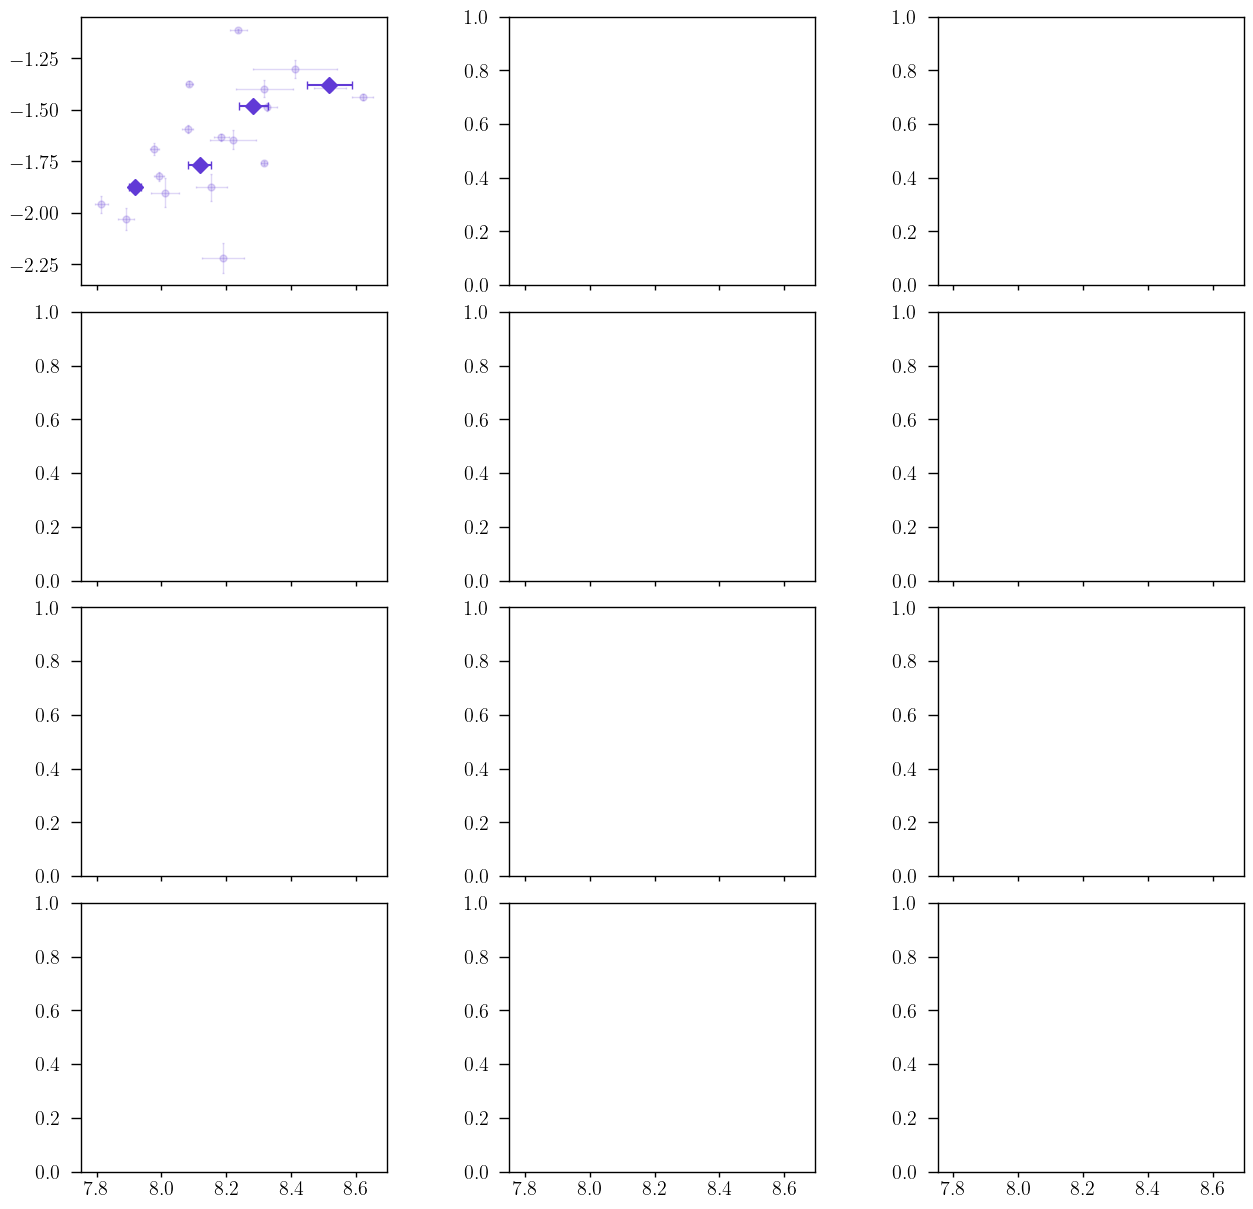

In [8]:
texPlot('on')
fig, axs = plt.subplots(4, 3, sharex=True)
fig.set_size_inches((15, 15))
fig.subplots_adjust(wspace=0.4, hspace=0.1)

# ===========================================================================================================
# N2
# ===========================================================================================================

axs[0, 0].errorbar(metals['log_OH'], upy.nominal_values(N2), xerr=2*log_OH_err, yerr=5*upy.std_devs(N2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
#axs[0, 0].plot(log_OH_tp, (log_OH_tp * out_N2.params['a1'].value) + out_N2.params['a0'].value,
#               color=c[2], ls='--', lw=3)
#axs[0, 0].plot((N2_tp * np.mean(lm_n2.chain['beta'])) + np.mean(lm_n2.chain['alpha']), N2_tp,
#               color='red', ls='--', lw=3)
#axs[0, 0].plot(log_OH_tp, (log_OH_tp * np.mean(lm_n2_rev.chain['beta'])) + np.mean(lm_n2_rev.chain['alpha']),
#               color='limegreen', ls='--', lw=1.5)

axs[0, 0].plot(log_OH_tp, (log_OH_tp * out_N2.params['a1'].value) + out_N2.params['a0'].value,
               color=c[2], ls='--', lw=3, label='OLS')
axs[0, 0].plot(log_OH_tp, (log_OH_tp * lm_n2_rev.chain['beta'].mean()) + lm_n2_rev.chain['alpha'].mean(),
               color='limegreen', label='Linmix')
axs[0, 0].plot(log_OH_tp, ols.predict(log_OH_tp.reshape(-1, 1)), label='Scikit-OLS')
axs[0, 0].plot(log_OH_tp, huber.predict(log_OH_tp.reshape(-1, 1)), label='Scikit-Huber')
axs[0, 0].set_ylabel('N2')

# ===========================================================================================================
# R3
# ===========================================================================================================

axs[0, 1].errorbar(metals['log_OH'], upy.nominal_values(R3), xerr=2*log_OH_err, yerr=5*upy.std_devs(R3), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R3),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R3),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 1].plot(log_OH_tp, poly2(log_OH_tp, *out_R3), color=c[2], ls='--', lw=3)
axs[0, 1].set_ylabel('R3')

# ===========================================================================================================
# R2
# ===========================================================================================================

axs[0, 2].errorbar(metals['log_OH'], upy.nominal_values(R2), xerr=2*log_OH_err, yerr=5*upy.std_devs(R2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 2].plot(log_OH_tp, poly2(log_OH_tp, *out_R2), color=c[2], ls='--', lw=3)
axs[0, 2].set_ylabel('R2')


# ===========================================================================================================
# R23
# ===========================================================================================================

axs[1, 0].errorbar(metals['log_OH'], upy.nominal_values(R23), xerr=2*log_OH_err, yerr=5*upy.std_devs(R23), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[1, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R23),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R23),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 0].plot(log_OH_tp, poly2(log_OH_tp, *out_R23), color=c[2], ls='--', lw=3)
axs[1, 0].set_ylabel('R23')

# ===========================================================================================================
# O3N2
# ===========================================================================================================

axs[1, 1].errorbar(metals['log_OH'], upy.nominal_values(O3N2), xerr=2*log_OH_err, yerr=5*upy.std_devs(O3N2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[1, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3N2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_O3N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 1].plot(log_OH_tp, (log_OH_tp * out_O3N2.params['a1'].value) + out_O3N2.params['a0'].value,
               color=c[2], ls='--', lw=3)
#axs[1, 1].plot((O3N2_tp * np.mean(lm_o3n2.chain['beta'])) + np.mean(lm_o3n2.chain['alpha']), O3N2_tp,
#               color='red', ls='--', lw=3)
axs[1, 1].plot(log_OH_tp, (log_OH_tp * np.mean(lm_o3n2_rev.chain['beta'])) + np.mean(lm_o3n2_rev.chain['alpha']),
               color='limegreen', ls='--', lw=1.5)
axs[1, 1].set_ylabel('O3N2')

# ===========================================================================================================
# R3N2
# ===========================================================================================================

axs[1, 2].errorbar(metals['log_OH'], upy.nominal_values(R3N2), xerr=2*log_OH_err, yerr=5*upy.std_devs(R3N2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[1, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R3N2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R3N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 2].plot(log_OH_tp, poly2(log_OH_tp, *out_R3N2), color=c[2], ls='--', lw=3)
axs[1, 2].set_ylabel('R3N2')


# ===========================================================================================================
# N2O2
# ===========================================================================================================

axs[2, 0].errorbar(metals['log_OH'], upy.nominal_values(N2O2), xerr=2*log_OH_err, yerr=5*upy.std_devs(N2O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[2, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2O2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_N2O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 0].plot(log_OH_tp, poly2(log_OH_tp, *out_N2O2), color=c[2], ls='--', lw=3)
axs[2, 0].set_ylabel('N2O2')

# ===========================================================================================================
# O3O2
# ===========================================================================================================

axs[2, 1].errorbar(metals['log_OH'], upy.nominal_values(O3O2), xerr=2*log_OH_err, yerr=5*upy.std_devs(O3O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[2, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3O2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_O3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 1].plot(log_OH_tp, (log_OH_tp * out_O3O2.params['a1'].value) + out_O3O2.params['a0'].value,
               color=c[2], ls='--', lw=3)
#axs[2, 1].plot((O3O2_tp * np.mean(lm_o3o2.chain['beta'])) + np.mean(lm_o3o2.chain['alpha']), O3O2_tp,
#               color='red', ls='--', lw=3)
axs[2, 1].plot(log_OH_tp, (log_OH_tp * np.mean(lm_o3o2_rev.chain['beta'])) + np.mean(lm_o3o2_rev.chain['alpha']),
               color='limegreen', ls='--', lw=1.5)
axs[2, 1].set_ylabel('O3O2')

# ===========================================================================================================
# Ne3O2
# ===========================================================================================================

axs[2, 2].errorbar(metals['log_OH'], upy.nominal_values(Ne3O2), xerr=2*log_OH_err, yerr=5*upy.std_devs(Ne3O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[2, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_Ne3O2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_Ne3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 2].plot(log_OH_tp, (log_OH_tp * out_Ne3O2.params['a1'].value) + out_Ne3O2.params['a0'].value,
               color=c[2], ls='--', lw=3)
#axs[2, 2].plot((Ne3O2_tp * np.mean(lm_ne3o2.chain['beta'])) + np.mean(lm_ne3o2.chain['alpha']), Ne3O2_tp,
#               color='red', ls='--', lw=3)
axs[2, 2].plot(log_OH_tp, (log_OH_tp * np.mean(lm_ne3o2_rev.chain['beta'])) + np.mean(lm_ne3o2_rev.chain['alpha']),
               color='green', ls='--', lw=1.5)
axs[2, 2].set_ylabel('Ne3O2')

# ===========================================================================================================
# S2
# ===========================================================================================================

axs[3, 0].errorbar(metals['log_OH'], upy.nominal_values(S2), xerr=2*log_OH_err, yerr=5*upy.std_devs(S2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[3, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_S2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_S2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[3, 0].plot(log_OH_tp, (log_OH_tp * out_S2.params['a1'].value) + out_S2.params['a0'].value,
               color=c[2], ls='--', lw=3)
#axs[3, 0].plot((S2_tp * np.mean(lm_s2.chain['beta'])) + np.mean(lm_s2.chain['alpha']), S2_tp,
#               color='red', ls='--', lw=3)
axs[3, 0].plot(log_OH_tp, (log_OH_tp * np.mean(lm_s2_rev.chain['beta'])) + np.mean(lm_s2_rev.chain['alpha']),
               color='limegreen', ls='--', lw=1.5)
axs[3, 0].set_ylabel('S2')

# ===========================================================================================================
# O3S2
# ===========================================================================================================

axs[3, 1].errorbar(metals['log_OH'], upy.nominal_values(O3S2), xerr=2*log_OH_err, yerr=5*upy.std_devs(O3S2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[3, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3S2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_O3S2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[3, 1].plot(log_OH_tp, (log_OH_tp * out_O3S2.params['a1'].value) + out_O3S2.params['a0'].value,
               color=c[2], ls='--', lw=3)
#axs[3, 1].plot((O3S2_tp * np.mean(lm_o3s2.chain['beta'])) + np.mean(lm_o3s2.chain['alpha']), O3S2_tp,
#               color='red', ls='--', lw=3)
axs[3, 1].plot(log_OH_tp, (log_OH_tp * np.mean(lm_o3s2_rev.chain['beta'])) + np.mean(lm_o3s2_rev.chain['alpha']),
               color='limegreen', ls='--', lw=1.5)
axs[3, 1].set_ylabel('O3S2')

# ===========================================================================================================
# N2S2
# ===========================================================================================================

axs[3, 2].errorbar(metals['log_OH'], upy.nominal_values(N2S2), xerr=2*log_OH_err, yerr=5*upy.std_devs(N2S2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[3, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2S2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_N2S2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[3, 2].plot(log_OH_tp, poly2(log_OH_tp, *out_N2S2), color=c[2], ls='--', lw=3)
axs[3, 2].set_ylabel('N2S2')

# ===========================================================================================================
# General settings
# ===========================================================================================================

axs[3, 0].set_xlabel(r'12 + log(O/H)')
axs[3, 1].set_xlabel(r'12 + log(O/H)')
axs[3, 2].set_xlabel(r'12 + log(O/H)')

# limits
# x
axs[0, 0].set_xlim(7.7, 8.7) 

# y
axs[0, 0].set_ylim(-2.5, -0.8) # N2
axs[0, 1].set_ylim(0.6, 1.0) # R3
axs[0, 2].set_ylim(-0.5, 0.7) # R2

axs[1, 0].set_ylim(0.8, 1.2) # R23
axs[1, 1].set_ylim(1.5, 3.5) # O3N2
axs[1, 2].set_ylim(1, 3) # R3N2

axs[2, 1].set_ylim(0, 1.3) # O3O2
axs[2, 2].set_ylim(-1.2, 0.5) # Ne3O2

axs[3, 0].set_ylim(-1.8, -0.7) # S2
axs[3, 1].set_ylim(1.5, 2.6) # O3S2


index_model = [0, 1, 2, 3]
index_sec = [0, 1, 2]
for i in index_model:
    for j in index_sec:
        axs[i, j].tick_params(axis="y", direction="in", length=10)
        axs[i, j].tick_params(axis="x", direction="in", length=10)

        
axs[0, 1].text(7.2, 1.05, s='Using uniform errors', fontsize=50)
#fig.savefig(magePath+'analysis/chapter4/calbrations_linmix_ue.pdf', bbox_inches='tight')

## Local relations

In [10]:
# Functions

def denicolo2002_N2(log_OH_12):
    N2 = (log_OH_12 - 9.12) / 0.73
    return N2


def tremonti2004_R23(R23):
    log_OH_12 = 9.185 - (0.313 * R23) - (0.264 * (R23**2)) - (0.321 * (R23**3)) 
    return log_OH_12


def pettini_pagel2004_O3N2(log_OH_12):
    O3N2 = - (log_OH_12 - 8.73) / 0.32
    return O3N2


def pettini_pagel2004_N2(N2):
    log_OH_12 = 9.37 + (2.03 * N2) + (1.26 * (N2**2)) + (0.32 * (N2**3))
    return log_OH_12


def nagao2006(log_OH_12, ratio='asd'):
    if ratio == 'R23':
        b0 = 1.2299
        b1 = -4.1926
        b2 = 1.0246
        b3 = -0.063169
    if ratio == 'N2':
        b0 = 96.641
        b1 = -39.941
        b2 = 5.2227
        b3 = -0.22040
    if ratio == 'R3N2':
        b0 = -232.18
        b1 = 84.423
        b2 = -9.9330
        b3 = 0.37941
    if ratio == 'N2O2':
        b0 = -128.94
        b1 = 48.818
        b2 = -6.2759
        b3 = 0.27101
    if ratio == 'O3O2':
        b0 = -1.4089
        b1 = 1.3745
        b2 = -0.14359
        b3 = 0
    return b0 + (b1 * log_OH_12) + (b2 * (log_OH_12**2)) + (b3 * (log_OH_12**3))

def maiolino2008(log_OH_12, ratio='asd'):
    x = (log_OH_12 - 8.69)
    if ratio == 'R23':
        c0 = 0.7462
        c1 = -0.7149
        c2 = -0.9401
        c3 = -0.6154
        c4 = -0.2524
    if ratio == 'N2':
        c0 = -0.7732
        c1 = 1.2357
        c2 = -0.2811
        c3 = -0.7201
        c4 = -0.3330
    if ratio == 'R3':
        c0 = 0.1549
        c1 = -1.5031
        c2 = -0.9790
        c3 = -0.0297
        c4 = 0.0
    if ratio == 'O3O2':
        c0 = -0.2839
        c1 = -1.3881
        c2 = -0.3172
        c3 = 0.0
        c4 = 0.0
    if ratio == 'R2':
        c0 = 0.5603
        c1 = 0.0450
        c2 = -1.8017
        c3 = -1.8434
        c4 = -0.6549
    if ratio == 'R3N2':
        c0 = 0.4520
        c1 = -2.6096
        c2 = -0.7170
        c3 = 0.1347
        c4 = 0.0
    if ratio == 'Ne3O2':
        c0 = -1.2608
        c1 = -1.0861
        c2 = -0.1470
        c3 = 0.0
        c4 = 0.0
    return c0 + (c1 * x) + (c2 * (x**2)) + (c3 * (x**3)) + (c4 * (x**4))


def marino2013_N2(log_OH_12):
    N2 = (log_OH_12 - 8.743) / 0.462
    return N2


def marino2013_O3N2(log_OH_12):
    O3N2 = - (log_OH_12 - 8.533) / 0.214
    return O3N2


def curti2020(log_OH_12, ratio='asd'):
    x = (log_OH_12 - 8.69)
    if ratio == 'R2':
        c0 = 0.435
        c1 = -1.362
        c2 = -5.655
        c3 = -4.851
        c4 = -0.478
        c5 = 0.736
    if ratio == 'R3':
        c0 = -0.277
        c1 = -3.549
        c2 = -3.593
        c3 = -0.981
        c4 = 0.0
        c5 = 0.0
    if ratio == 'O3O2':
        c0 = -0.691
        c1 = -2.944
        c2 = -1.308
        c3 = 0.0
        c4 = 0.0
        c5 = 0.0
    if ratio == 'R23':
        c0 = 0.527
        c1 = -1.569
        c2 = -1.652
        c3 = -0.421
        c4 = 0.0
        c5 = 0.0
    if ratio == 'N2':
        c0 = -0.489
        c1 = 1.513
        c2 = -2.554
        c3 = -5.293
        c4 = -2.867
        c5 = 0.0
    if ratio == 'O3N2':
        c0 = 0.281
        c1 = -4.765
        c2 = -2.268
        c3 = 0.0
        c4 = 0.0
        c5 = 0.0
    if ratio == 'S2':
        c0 = -0.442
        c1 = -0.360
        c2 = -6.271
        c3 = -8.339
        c4 = -3.559
        c5 = 0.0
    if ratio == 'O3S2':
        c0 = 0.191
        c1 = -4.292
        c2 = -2.538
        c3 = 0.053
        c4 = 0.332
        c5 = 0.0
    return c0 + (c1 * x) + (c2 * (x**2)) + (c3 * (x**3)) + (c4 * (x**4)) + (c5 * (x**5))

def sanders2021(log_OH_12, ratio='asd'):
    x = (log_OH_12 - 8.69)
    if ratio == 'R3':
        c0 = -0.143
        c1 = -3.16
        c2 = -4.06
        c3 = -1.49
    if ratio == 'R2':
        c0 = 0.27
        c1 = -0.452
        c2 = -0.52
        c3 = 0.0831
    if ratio == 'O3O2':
        c0 = -0.413
        c1 = -2.7
        c2 = -3.52
        c3 = -1.55
    if ratio == 'R23':
        c0 = 0.469
        c1 = -1.51
        c2 = -1.75
        c3 = -0.508
    if ratio == 'N2':
        c0 = -0.606
        c1 = 1.28
        c2 = -0.435
        c3 = -0.485
    if ratio == 'O3N2':
        c0 = 0.461
        c1 = -4.40
        c2 = -3.37
        c3 = -0.761
    return c0 + (c1 * x) + (c2 * (x**2)) + (c3 * (x**3))

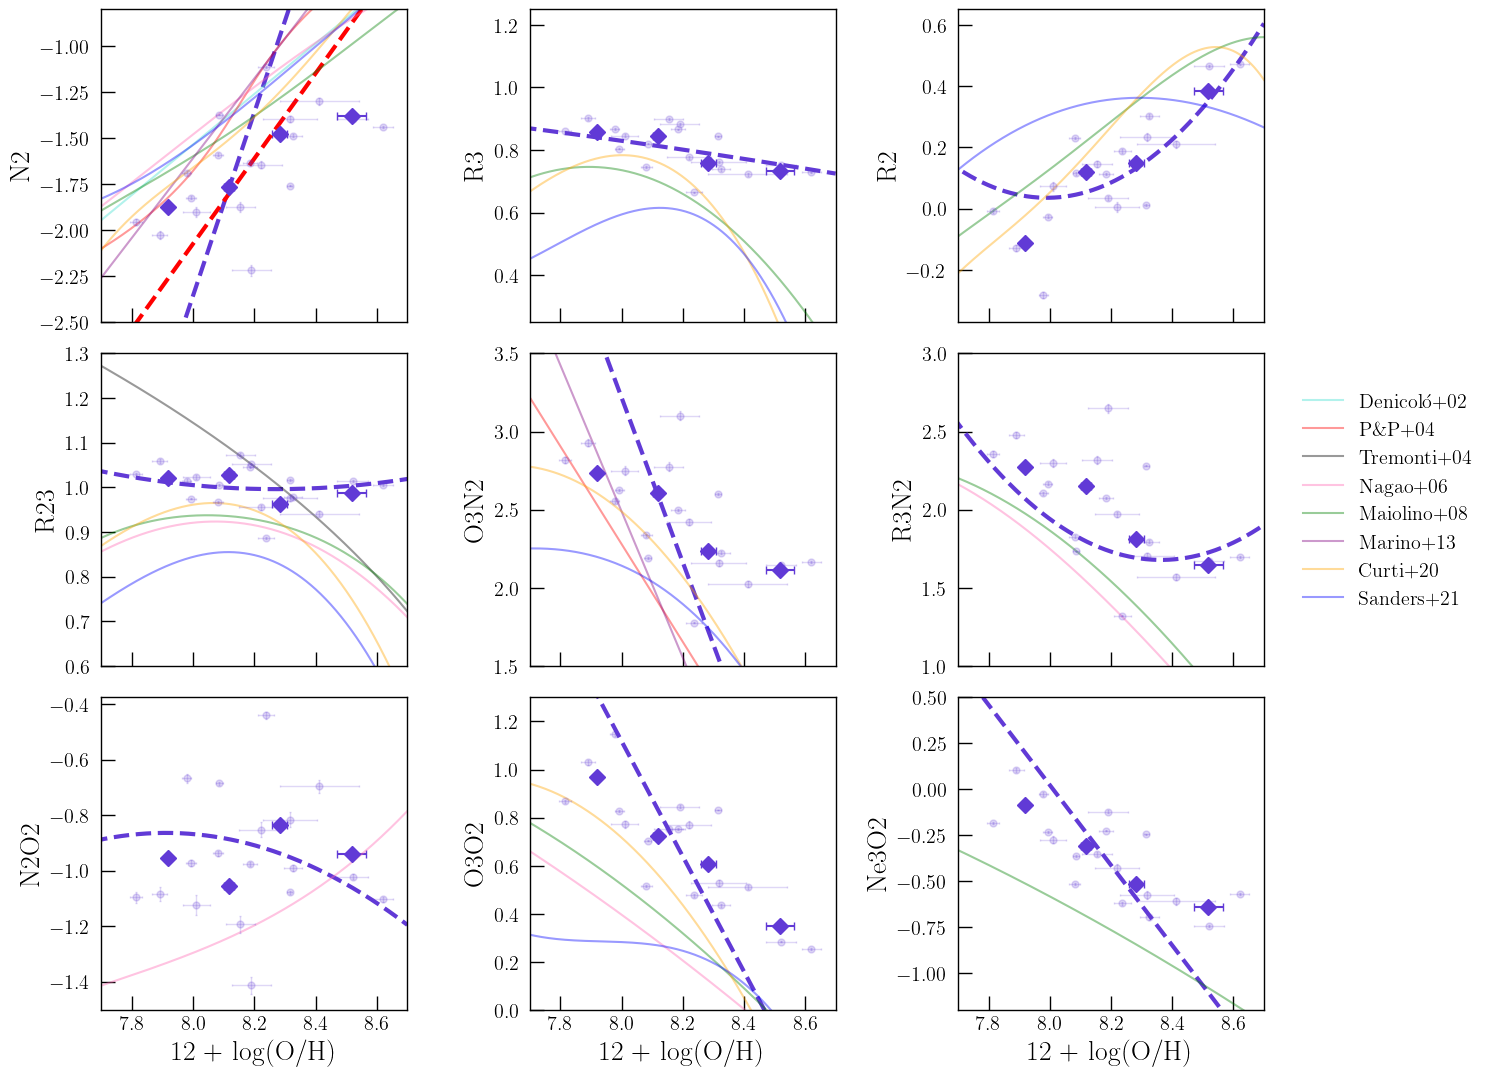

In [28]:
texPlot('on')
fig, axs = plt.subplots(3, 3, sharex=True)
fig.set_size_inches((15, 13))
fig.subplots_adjust(wspace=0.4, hspace=0.1)

# ===========================================================================================================
# N2 Ratio
# ===========================================================================================================

axs[0, 0].errorbar(metals['log_OH'], upy.nominal_values(N2), xerr=2*log_OH_err, yerr=2*upy.std_devs(N2), 
                  marker='o', markersize=5, ls='', color=c[2], elinewidth=1, capsize=1, zorder=100, alpha=0.2)
axs[0, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 0].plot((N2_tp * out_N2.params['a1'].value) + out_N2.params['a0'].value, N2_tp,
               color=c[2], ls='--', lw=3)
#axs[0, 0].plot((N2_tp * np.mean(lm_n2.chain['beta'])) + np.mean(lm_n2.chain['alpha']), N2_tp,
#               color='red', ls='--', lw=3)

# Relations
axs[0, 0].plot(log_OH_tp, denicolo2002_N2(log_OH_tp), label='Denicoló+02', color='turquoise', alpha=0.4)
axs[0, 0].plot(pettini_pagel2004_N2(N2_tp), N2_tp,
               label=r'P\&P+04', color='red', alpha=0.4)
axs[0, 0].plot(log_OH_tp, nagao2006(log_OH_tp, 'N2'), color='hotpink', alpha=0.4)
axs[0, 0].plot(log_OH_tp, maiolino2008(log_OH_tp, 'N2'), color='green', alpha=0.4)
axs[0, 0].plot(log_OH_tp, marino2013_N2(log_OH_tp), color='purple', alpha=0.4)
axs[0, 0].plot(log_OH_tp, curti2020(log_OH_tp, 'N2'), color='orange', alpha=0.4)
axs[0, 0].plot(log_OH_tp, sanders2021(log_OH_tp, 'N2'), color='blue', alpha=0.4)
axs[0, 0].set_ylabel('N2')


# ===========================================================================================================
# R3 Ratio
# ===========================================================================================================

axs[0, 1].errorbar(metals['log_OH'], upy.nominal_values(R3), xerr=2*log_OH_err, yerr=2*upy.std_devs(R3), 
                  marker='o', markersize=5, ls='', color=c[2], elinewidth=1, capsize=1, zorder=100, alpha=0.2)
axs[0, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R3),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R3),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 1].plot(log_OH_tp, poly2(log_OH_tp, *out_R3), color=c[2], ls='--', lw=3)

axs[0, 1].plot(log_OH_tp, maiolino2008(log_OH_tp, 'R3'), label='Maiolino+08', color='green', alpha=0.4)
axs[0, 1].plot(log_OH_tp, curti2020(log_OH_tp, 'R3'), label='Curti+20', color='orange', alpha=0.4)
axs[0, 1].plot(log_OH_tp, sanders2021(log_OH_tp, 'R3'), label='Sanders+21', color='blue', alpha=0.4)
axs[0, 1].set_ylabel('R3')

# ===========================================================================================================
# R2 Ratio
# ===========================================================================================================

axs[0, 2].errorbar(metals['log_OH'], upy.nominal_values(R2), xerr=2*log_OH_err, yerr=2*upy.std_devs(R2), 
                  marker='o', markersize=5, ls='', color=c[2], elinewidth=1, capsize=1, zorder=100, alpha=0.2)
axs[0, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 2].plot(log_OH_tp, poly2(log_OH_tp, *out_R2), color=c[2], ls='--', lw=3)

axs[0, 2].plot(log_OH_tp, maiolino2008(log_OH_tp, 'R2'), label='Maiolino+2008', color='green', alpha=0.4)
axs[0, 2].plot(log_OH_tp, curti2020(log_OH_tp, 'R2'), label='Curti+2020', color='orange', alpha=0.4)
axs[0, 2].plot(log_OH_tp, sanders2021(log_OH_tp, 'R2'), label='Sanders+2021', color='blue', alpha=0.4)
axs[0, 2].set_ylabel('R2')

# ===========================================================================================================
# R23 Ratio
# ===========================================================================================================

axs[1, 0].errorbar(metals['log_OH'], upy.nominal_values(R23), xerr=2*log_OH_err, yerr=2*upy.std_devs(R23), 
                  marker='o', markersize=5, ls='', color=c[2], elinewidth=1, capsize=1, zorder=100, alpha=0.2)
axs[1, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R23),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R23),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 0].plot(log_OH_tp, poly2(log_OH_tp, *out_R23), color=c[2], ls='--', lw=3)

axs[1, 0].plot(tremonti2004_R23(R23_tp), R23_tp, label='Tremonti+04', color='black', alpha=0.4)
axs[1, 0].plot(log_OH_tp, nagao2006(log_OH_tp, 'R23'), color='hotpink', alpha=0.4)
axs[1, 0].plot(log_OH_tp, maiolino2008(log_OH_tp, 'R23'), color='green', alpha=0.4)
axs[1, 0].plot(log_OH_tp, curti2020(log_OH_tp, 'R23'), color='orange', alpha=0.4)
axs[1, 0].plot(log_OH_tp, sanders2021(log_OH_tp, 'R23'), color='blue', alpha=0.4)
axs[1, 0].set_ylabel('R23')

# ===========================================================================================================
# O3N2 Ratio
# ===========================================================================================================

axs[1, 1].errorbar(metals['log_OH'], upy.nominal_values(O3N2), xerr=2*log_OH_err, yerr=2*upy.std_devs(O3N2), 
                  marker='o', markersize=5, ls='', color=c[2], elinewidth=1, capsize=1, zorder=100, alpha=0.2)
axs[1, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3N2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_O3N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 1].plot((O3N2_tp * out_O3N2.params['a1'].value) + out_O3N2.params['a0'].value, O3N2_tp,
               color=c[2], ls='--', lw=3)

axs[1, 1].plot(log_OH_tp, pettini_pagel2004_O3N2(log_OH_tp), color='red', alpha=0.4)
axs[1, 1].plot(log_OH_tp, marino2013_O3N2(log_OH_tp), label='Marino+13', color='purple', alpha=0.4)
axs[1, 1].plot(log_OH_tp, curti2020(log_OH_tp, 'O3N2'), label='Curti+20', color='orange', alpha=0.4)
axs[1, 1].plot(log_OH_tp, sanders2021(log_OH_tp, 'O3N2'), label='Sanders+21', color='blue', alpha=0.4)
axs[1, 1].set_ylabel('O3N2')

# ===========================================================================================================
# R3N2 Ratio
# ===========================================================================================================

axs[1, 2].errorbar(metals['log_OH'], upy.nominal_values(R3N2), xerr=2*log_OH_err, yerr=2*upy.std_devs(R3N2), 
                  marker='o', markersize=5, ls='', color=c[2], elinewidth=1, capsize=1, zorder=100, alpha=0.2)
axs[1, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R3N2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R3N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 2].plot(log_OH_tp, poly2(log_OH_tp, *out_R3N2), color=c[2], ls='--', lw=3)

axs[1, 2].plot(log_OH_tp, nagao2006(log_OH_tp, 'R3N2'), label='Nagao+06', color='hotpink', alpha=0.4)
axs[1, 2].plot(log_OH_tp, maiolino2008(log_OH_tp, 'R3N2'), label='Maiolino+08', color='green', alpha=0.4)
axs[1, 2].set_ylabel('R3N2')

# ===========================================================================================================
# N2O2 Ratio
# ===========================================================================================================

axs[2, 0].errorbar(metals['log_OH'], upy.nominal_values(N2O2), xerr=2*log_OH_err, yerr=2*upy.std_devs(N2O2), 
                  marker='o', markersize=5, ls='', color=c[2], elinewidth=1, capsize=1, zorder=100, alpha=0.2)
axs[2, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2O2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_N2O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 0].plot(log_OH_tp, poly2(log_OH_tp, *out_N2O2), color=c[2], ls='--', lw=3)

axs[2, 0].plot(log_OH_tp, nagao2006(log_OH_tp, 'N2O2'), label='Nagao+2006', color='hotpink', alpha=0.4)
axs[2, 0].set_ylabel('N2O2')

# ===========================================================================================================
# O3O2 Ratio
# ===========================================================================================================

axs[2, 1].errorbar(metals['log_OH'], upy.nominal_values(O3O2), xerr=2*log_OH_err, yerr=2*upy.std_devs(O3O2), 
                  marker='o', markersize=5, ls='', color=c[2], elinewidth=1, capsize=1, zorder=100, alpha=0.2)
axs[2, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3O2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_O3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 1].plot((O3O2_tp * out_O3O2.params['a1'].value) + out_O3O2.params['a0'].value, O3O2_tp,
               color=c[2], ls='--', lw=3)

axs[2, 1].plot(log_OH_tp, nagao2006(log_OH_tp, 'O3O2'), label='Nagao+2006', color='hotpink', alpha=0.4)
axs[2, 1].plot(log_OH_tp, maiolino2008(log_OH_tp, 'O3O2'), label='Maiolino+2008', color='green', alpha=0.4)
axs[2, 1].plot(log_OH_tp, curti2020(log_OH_tp, 'O3O2'), label='Curti+2020', color='orange', alpha=0.4)
axs[2, 1].plot(log_OH_tp, sanders2021(log_OH_tp, 'O3O2'), label='Sanders+2021', color='blue', alpha=0.4)
axs[2, 1].set_ylabel('O3O2')

# ===========================================================================================================
# Ne3O2 Ratio
# ===========================================================================================================

axs[2, 2].errorbar(metals['log_OH'], upy.nominal_values(Ne3O2), xerr=2*log_OH_err, yerr=2*upy.std_devs(Ne3O2), 
                  marker='o', markersize=5, ls='', color=c[2], elinewidth=1, capsize=1, zorder=100, alpha=0.2)
axs[2, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_Ne3O2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_Ne3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 2].plot((Ne3O2_tp * out_Ne3O2.params['a1'].value) + out_Ne3O2.params['a0'].value, Ne3O2_tp,
               color=c[2], ls='--', lw=3)

axs[2, 2].plot(log_OH_tp, maiolino2008(log_OH_tp, 'Ne3O2'), label='Maiolino+2008', color='green', alpha=0.4)
axs[2, 2].set_ylabel('Ne3O2')


# ===========================================================================================================
# General settings
# ===========================================================================================================
axs[2, 0].set_xlabel(r'12 + log(O/H)')
axs[2, 1].set_xlabel(r'12 + log(O/H)')
axs[2, 2].set_xlabel(r'12 + log(O/H)')

# limits

# x
axs[0, 0].set_xlim(7.7, 8.7) 

# y
axs[0, 0].set_ylim(-2.5, -0.8) # N2
axs[0, 1].set_ylim(0.25, 1.25) # R2

axs[1, 0].set_ylim(0.6, 1.3) # R23
axs[1, 1].set_ylim(1.5, 3.5) # O3N2
axs[1, 2].set_ylim(1, 3) # R3N2

axs[2, 1].set_ylim(0, 1.3) # O3O2
axs[2, 2].set_ylim(-1.2, 0.5) # Ne3O2

# legend
axs[0, 0].legend(frameon=False, loc=(3.9, -0.4))
axs[1, 0].legend(frameon=False, loc=(3.9, 0.61))
axs[1, 1].legend(frameon=False, loc=(2.5, 0.16))
axs[1, 2].legend(frameon=False, loc=(1.1, 0.43))

# Setting tick params
index_local = [0, 1, 2]
for index in index_local:
    for sec_index in index_local:
        axs[index, sec_index].tick_params(axis="y", direction="in", length=10)
        axs[index, sec_index].tick_params(axis="x", direction="in", length=10)

#fig.savefig(magePath+'analysis/chapter4/calibration_vs_local.pdf', bbox_inches='tight')

## Analogs

In [12]:
def jones2015(log_OH_12, ratio='asd'):
    if ratio == 'Ne3O2':
        c0 = 16.8974
        c1 = -2.1588
        c2 = 0.0
    if ratio == 'O3O2':
        c0 = 17.9828
        c1 = -2.1552
        c2 = 0.0
    if ratio == 'R3':
        c0 = -88.4378
        c1 = 22.7529
        c2 = -1.4501
    if ratio == 'R2':
        c0 = -154.9571
        c1 = 36.9128
        c2 = -2.1921
    if ratio == 'R23':
        c0 = -54.1003
        c1 = 13.9083
        c2 = -0.8782
    return c0 + (c1 * log_OH_12) + (c2 * (log_OH_12**2))

def bian2018(log_OH_12, ratio='asd'):
    if ratio == 'N2':
        return (log_OH_12 - 8.82) / 0.49
    if ratio == 'O3N2':
        return - (log_OH_12 - 8.97) / 0.39
    if ratio == 'R23':
        c0 = 138.0430
        c1 = -54.8284
        c2 = 7.2954
        c3 = -0.32293
        return c0 + (c1 * log_OH_12) + (c2 * (log_OH_12**2)) + (c3 * (log_OH_12**3))
    if ratio == 'O3O2':
        return - (log_OH_12 - 8.54) / 0.59
    if ratio == 'R3':
        c0 = 43.9836
        c1 = -21.6211
        c2 = 3.4277
        c3 = -0.1747
        return c0 + (c1 * log_OH_12) + (c2 * (log_OH_12**2)) + (c3 * (log_OH_12**3))
    if ratio == 'Ne3O2':
        return - (log_OH_12 - 7.8) / 0.63
    
def perez_montero2021(log_OH_12, ratio='asd'):
    if ratio == 'O3O2':
        return - (log_OH_12 - 8.308) / 0.352
    if ratio == 'Ne3O2':
        return - (log_OH_12 - 7.823) / 0.455
    if ratio == 'N2':
        return (log_OH_12 - 8.625) / 0.361
    if ratio == 'O3N2':
        return - (log_OH_12 - 8.677) / 0.270

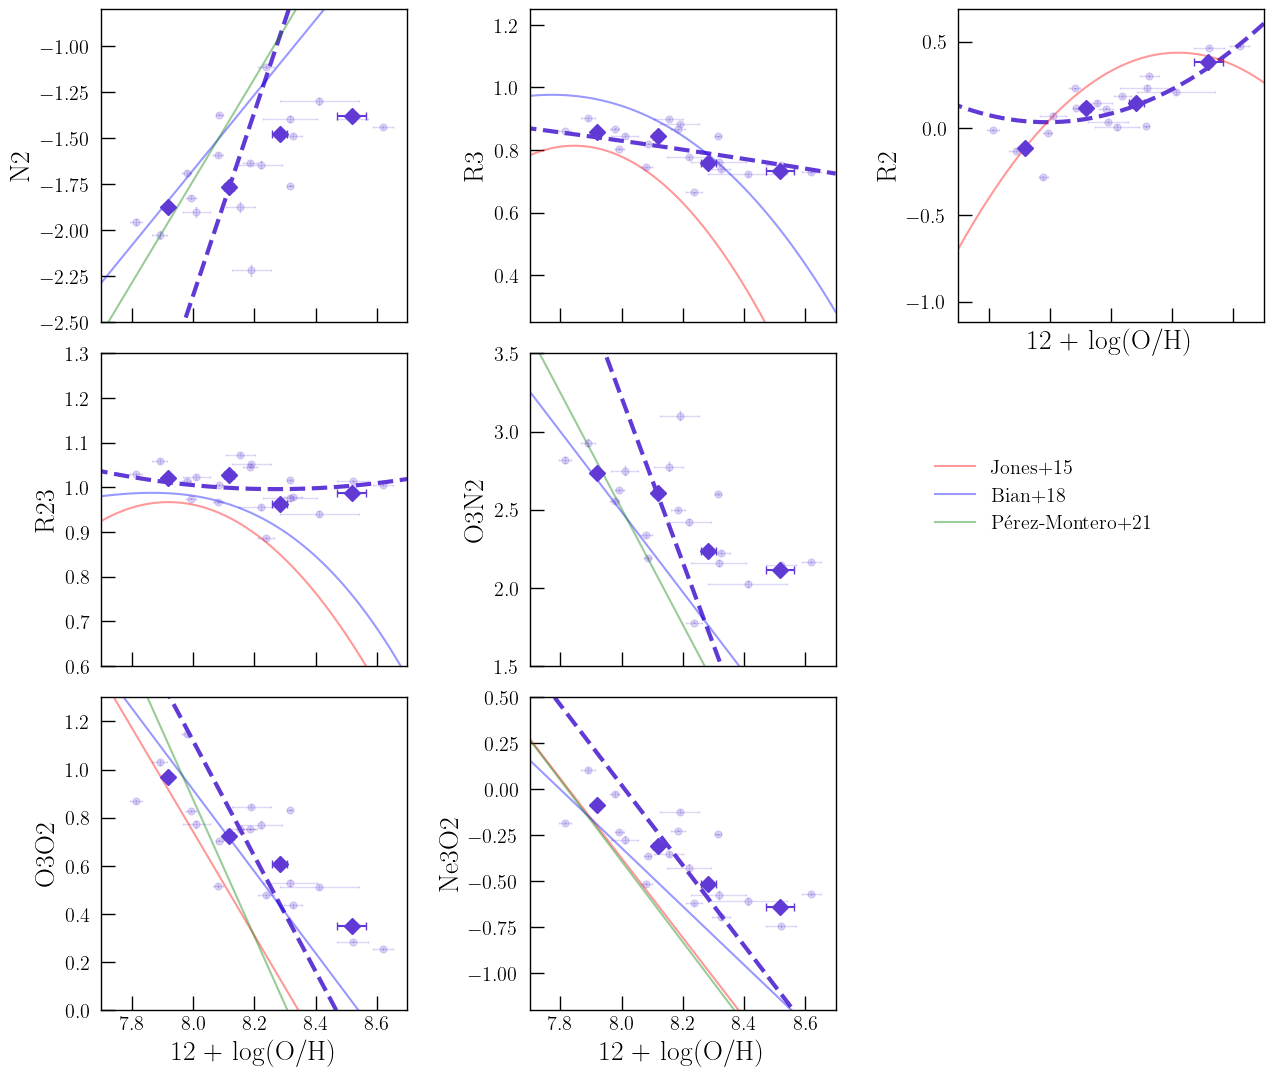

In [13]:
texPlot('on')
fig, axs = plt.subplots(3, 3, sharex=True)
fig.set_size_inches((15, 13))
fig.subplots_adjust(wspace=0.4, hspace=0.1)

# ===========================================================================================================
# N2
# ===========================================================================================================

axs[0, 0].errorbar(metals['log_OH'], upy.nominal_values(N2), xerr=2*log_OH_err, yerr=2*upy.std_devs(N2), 
                  marker='o', capsize=1, elinewidth=1, markersize=5, ls='', color=c[2], alpha=0.2)
axs[0, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 0].plot((N2_tp * out_N2.params['a1'].value) + out_N2.params['a0'].value, N2_tp,
               color=c[2], ls='--', lw=3)

axs[0, 0].plot(log_OH_tp, bian2018(log_OH_tp, 'N2'), label='Bian+2018', color='blue', alpha=0.4)
axs[0, 0].plot(log_OH_tp, perez_montero2021(log_OH_tp, 'N2'), label='Pérez-Montero+2021', color='green', alpha=0.4)
axs[0, 0].set_ylabel('N2')

# ===========================================================================================================
# R3
# ===========================================================================================================

axs[0, 1].errorbar(metals['log_OH'], upy.nominal_values(R3), xerr=2*log_OH_err, yerr=2*upy.std_devs(R3), 
                  marker='o', capsize=1, elinewidth=1, markersize=5, ls='', color=c[2], alpha=0.2)
axs[0, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R3),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R3),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 1].plot(log_OH_tp, poly2(log_OH_tp, *out_R3), color=c[2], ls='--', lw=3)

axs[0, 1].plot(log_OH_tp, jones2015(log_OH_tp, 'R3'), label='Jones+2015', color='red', alpha=0.4)
axs[0, 1].plot(log_OH_tp, bian2018(log_OH_tp, 'R3'), label='Bian+2018', color='blue', alpha=0.4)
axs[0, 1].set_ylabel('R3')

# ===========================================================================================================
# R2
# ===========================================================================================================

axs[0, 2].errorbar(metals['log_OH'], upy.nominal_values(R2), xerr=2*log_OH_err, yerr=2*upy.std_devs(R2), 
                  marker='o', capsize=1, elinewidth=1, markersize=5, ls='', color=c[2], alpha=0.2)
axs[0, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 2].plot(log_OH_tp, poly2(log_OH_tp, *out_R2), color=c[2], ls='--', lw=3)

axs[0, 2].plot(log_OH_tp, jones2015(log_OH_tp, 'R2'), label='Jones+2015', color='red', alpha=0.4)
axs[0, 2].set_ylabel('R2')


# ===========================================================================================================
# R23
# ===========================================================================================================

axs[1, 0].errorbar(metals['log_OH'], upy.nominal_values(R23), xerr=2*log_OH_err, yerr=2*upy.std_devs(R23), 
                  marker='o', capsize=1, elinewidth=1, markersize=5, ls='', color=c[2], alpha=0.2)
axs[1, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R23),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R23),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 0].plot(log_OH_tp, poly2(log_OH_tp, *out_R23), color=c[2], ls='--', lw=3)

axs[1, 0].plot(log_OH_tp, jones2015(log_OH_tp, 'R23'), label='Jones+2015', color='red', alpha=0.4)
axs[1, 0].plot(log_OH_tp, bian2018(log_OH_tp, 'R23'), label='Bian+2018', color='blue', alpha=0.4)
axs[1, 0].set_ylabel('R23')

# ===========================================================================================================
# O3N2
# ===========================================================================================================

axs[1, 1].errorbar(metals['log_OH'], upy.nominal_values(O3N2), xerr=2*log_OH_err, yerr=2*upy.std_devs(O3N2), 
                  marker='o', capsize=1, elinewidth=1, markersize=5, ls='', color=c[2], alpha=0.2)
axs[1, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3N2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_O3N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 1].plot((O3N2_tp * out_O3N2.params['a1'].value) + out_O3N2.params['a0'].value, O3N2_tp,
               color=c[2], ls='--', lw=3)

axs[1, 1].plot(log_OH_tp, bian2018(log_OH_tp, 'O3N2'), label='Bian+2018', color='blue', alpha=0.4)
axs[1, 1].plot(log_OH_tp, perez_montero2021(log_OH_tp, 'O3N2'), label='Pérez-Montero+2021', color='green', alpha=0.4)
axs[1, 1].set_ylabel('O3N2')


# ===========================================================================================================
# O3O2
# ===========================================================================================================

axs[2, 0].errorbar(metals['log_OH'], upy.nominal_values(O3O2), xerr=2*log_OH_err, yerr=2*upy.std_devs(O3O2), 
                  marker='o', capsize=1, elinewidth=1, markersize=5, ls='', color=c[2], alpha=0.2)
axs[2, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3O2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_O3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 0].plot((O3O2_tp * out_O3O2.params['a1'].value) + out_O3O2.params['a0'].value, O3O2_tp,
               color=c[2], ls='--', lw=3)

axs[2, 0].plot(log_OH_tp, jones2015(log_OH_tp, 'O3O2'), label='Jones+2015', color='red', alpha=0.4)
axs[2, 0].plot(log_OH_tp, bian2018(log_OH_tp, 'O3O2'), label='Bian+2018', color='blue', alpha=0.4)
axs[2, 0].plot(log_OH_tp, perez_montero2021(log_OH_tp, 'O3O2'), label='Pérez-Montero+2021', color='green', alpha=0.4)
axs[2, 0].set_ylabel('O3O2')

# ===========================================================================================================
# Ne3O2
# ===========================================================================================================

axs[2, 1].errorbar(metals['log_OH'], upy.nominal_values(Ne3O2), xerr=2*log_OH_err, yerr=2*upy.std_devs(Ne3O2), 
                  marker='o', capsize=1, elinewidth=1, markersize=5, ls='', color=c[2], alpha=0.2)
axs[2, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_Ne3O2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_Ne3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 1].plot((Ne3O2_tp * out_Ne3O2.params['a1'].value) + out_Ne3O2.params['a0'].value, Ne3O2_tp,
               color=c[2], ls='--', lw=3)

axs[2, 1].plot(log_OH_tp, jones2015(log_OH_tp, 'Ne3O2'), label='Jones+15', color='red', alpha=0.4)
axs[2, 1].plot(log_OH_tp, bian2018(log_OH_tp, 'Ne3O2'), label='Bian+18', color='blue', alpha=0.4)
axs[2, 1].plot(log_OH_tp, perez_montero2021(log_OH_tp, 'Ne3O2'), label='Pérez-Montero+21', color='green', alpha=0.4)
axs[2, 1].legend(frameon=False, loc=(1.3, 1.5))
axs[2, 1].set_ylabel('Ne3O2')


# ===========================================================================================================
# General settings
# ===========================================================================================================

axs[2, 0].set_xlabel(r'12 + log(O/H)')
axs[2, 1].set_xlabel(r'12 + log(O/H)')
axs[0, 2].set_xlabel(r'12 + log(O/H)')

# limits

# x
axs[0, 0].set_xlim(7.7, 8.7) # N2 (Shared)

# y
axs[0, 0].set_ylim(-2.5, -0.8) # N2
axs[0, 1].set_ylim(0.25, 1.25) # R3

axs[1, 0].set_ylim(0.6, 1.3) # R23
axs[1, 1].set_ylim(1.5, 3.5) # O3N2

axs[2, 0].set_ylim(0, 1.3) # O3O2
axs[2, 1].set_ylim(-1.2, 0.5) # Ne3O2

axs[1, 2].axis('off')
axs[2, 2].axis('off')

# Setting tick params

axs[0, 0].tick_params(axis="y", direction="in", length=10)
axs[0, 0].tick_params(axis="x", direction="in", length=10)

axs[0, 1].tick_params(axis="y", direction="in", length=10)
axs[0, 1].tick_params(axis="x", direction="in", length=10)

axs[0, 2].tick_params(axis="y", direction="in", length=10)
axs[0, 2].tick_params(axis="x", direction="in", length=10)

axs[1, 0].tick_params(axis="y", direction="in", length=10)
axs[1, 0].tick_params(axis="x", direction="in", length=10)

axs[1, 1].tick_params(axis="y", direction="in", length=10)
axs[1, 1].tick_params(axis="x", direction="in", length=10)


axs[2, 0].tick_params(axis="y", direction="in", length=10)
axs[2, 0].tick_params(axis="x", direction="in", length=10)

axs[2, 1].tick_params(axis="y", direction="in", length=10)
axs[2, 1].tick_params(axis="x", direction="in", length=10)
#fig.savefig(magePath+'analysis/chapter4/calbration_vs_analogs.pdf', bbox_inches='tight')

## Photoionization models

In [15]:
def dopita2016_N2S2(log_OH_12):
    N2S2 = (log_OH_12 - 8.77)
    return N2S2


def strom2018(log_OH_12, ratio='asd'):
    if ratio == 'R23':
        return - (((log_OH_12 - 8.24)**2) - 0.85) / 0.87
    if ratio == 'N2':
        return (log_OH_12 - 8.77) / 0.34
    if ratio == 'O3N2':
        return  - (log_OH_12 - 8.75) /0.21


def papovich2022_R23(log_OH_12):
    log_Z0 = 8.228
    log_R0 = 1.041
    A = -1.07
    return A * ((log_OH_12 - log_Z0)**2) + log_R0


def garg2023_z_0(SEL, ratio='asd'):
    if ratio == 'N2':
        a0 = -13.9
        a1 = 1.918
        a2 = -0.046
    if ratio == 'R3':
        a0 = -57.889
        a1 = 14.552
        a2 = -0.905
    if ratio == 'R2':
        a0 = -43.87
        a1 = 10.558
        a2 = -0.632
    if ratio == 'R23':
        a0 = -47.251
        a1 = 11.872
        a2 = -0.732
    if ratio == 'O3N2':
        a0 = -45.251
        a1 = 12.947
        a2 = -0.878
    if ratio == 'R3N2':
        a0 = -49.279
        a1 = 13.895
        a2 = -0.941
    if ratio == 'N2O2':
        a0 = 34.201
        a1 = -9.642
        a2 = 0.652
    if ratio == 'O3O2':
        a0 = -15.091
        a1 = 4.258
        a2 = -0.289
    if ratio == 'Ne3O2':
        a0 = 3.986
        a1 = -0.877
        a2 = 0.035
    if ratio == 'S2':
        a0 = -28.699
        a1 = 6.227
        a2 = -0.347
    if ratio == 'O3S2':
        a0 = -29.935
        a1 = 8.511
        a2 = -0.57
    if ratio == 'N2S2':
        a0 = 11.406
        a1 = -3.871
        a2 = 0.292
    return a0 + (a1 * SEL) + (a2 * (SEL**2))

def garg2023_z_2(SEL, ratio='asd'):
    if ratio == 'N2':
        a0 = 16.247
        a1 = -5.606
        a2 = 0.42
    if ratio == 'R3':
        a0 = -41.669
        a1 = 10.511
        a2 = -0.653
    if ratio == 'R2':
        a0 = -21.727
        a1 = 4.973
        a2 = -0.281
    if ratio == 'R23':
        a0 = -34.364
        a1 = 8.641
        a2 = -0.53
    if ratio == 'O3N2':
        a0 = -57.392
        a1 = 15.982
        a2 = -1.064
    if ratio == 'R3N2':
        a0 = -64.199
        a1 = 17.678
        a2 = -1.177
    if ratio == 'N2O2':
        a0 = 44.395
        a1 = -12.176
        a2 = 0.808
    if ratio == 'O3O2':
        a0 = -19.924
        a1 = 5.534
        a2 = -0.371
    if ratio == 'Ne3O2':
        a0 = -14.735
        a1 = 3.814
        a2 = -0.258
    if ratio == 'S2':
        a0 = -1.276
        a1 = -0.78
        a2 = 0.098
    if ratio == 'O3S2':
        a0 = -39.426
        a1 = 11.041
        a2 = -0.735
    if ratio == 'N2S2':
        a0 = 21.596
        a1 = -6.25
        a2 = 0.429
    return a0 + (a1 * SEL) + (a2 * (SEL**2))

def garg2023_z_5(SEL, ratio='asd'):
    if ratio == 'N2':
        a0 = 6.902
        a1 = -3.176
        a2 = 0.261
    if ratio == 'R3':
        a0 = -24.688
        a1 = 6.118
        a2 = -0.369
    if ratio == 'R2':
        a0 = -19.95
        a1 = 4.556
        a2 = -0.258
    if ratio == 'R23':
        a0 = -23.269
        a1 = 5.776
        a2 = -0.346
    if ratio == 'O3N2':
        a0 = -31.59
        a1 = 9.294
        a2 = -0.63
    if ratio == 'R3N2':
        a0 = -35.253
        a1 = 10.157
        a2 = -0.688
    if ratio == 'N2O2':
        a0 = 30.515
        a1 = -8.595
        a2 = 0.577
    if ratio == 'O3O2':
        a0 = -4.737
        a1 = 1.562
        a2 = -0.111
    if ratio == 'Ne3O2':
        a0 = -6.314
        a1 = 1.597
        a2 = -0.112
    if ratio == 'S2':
        a0 = -10.901
        a1 = 1.8
        a2 = -0.076
    if ratio == 'O3S2':
        a0 = -13.787
        a1 = 4.318
        a2 = -0.293
    if ratio == 'N2S2':
        a0 = 19.625
        a1 = -5.814
        a2 = 0.406
    return a0 + (a1 * SEL) + (a2 * (SEL**2))

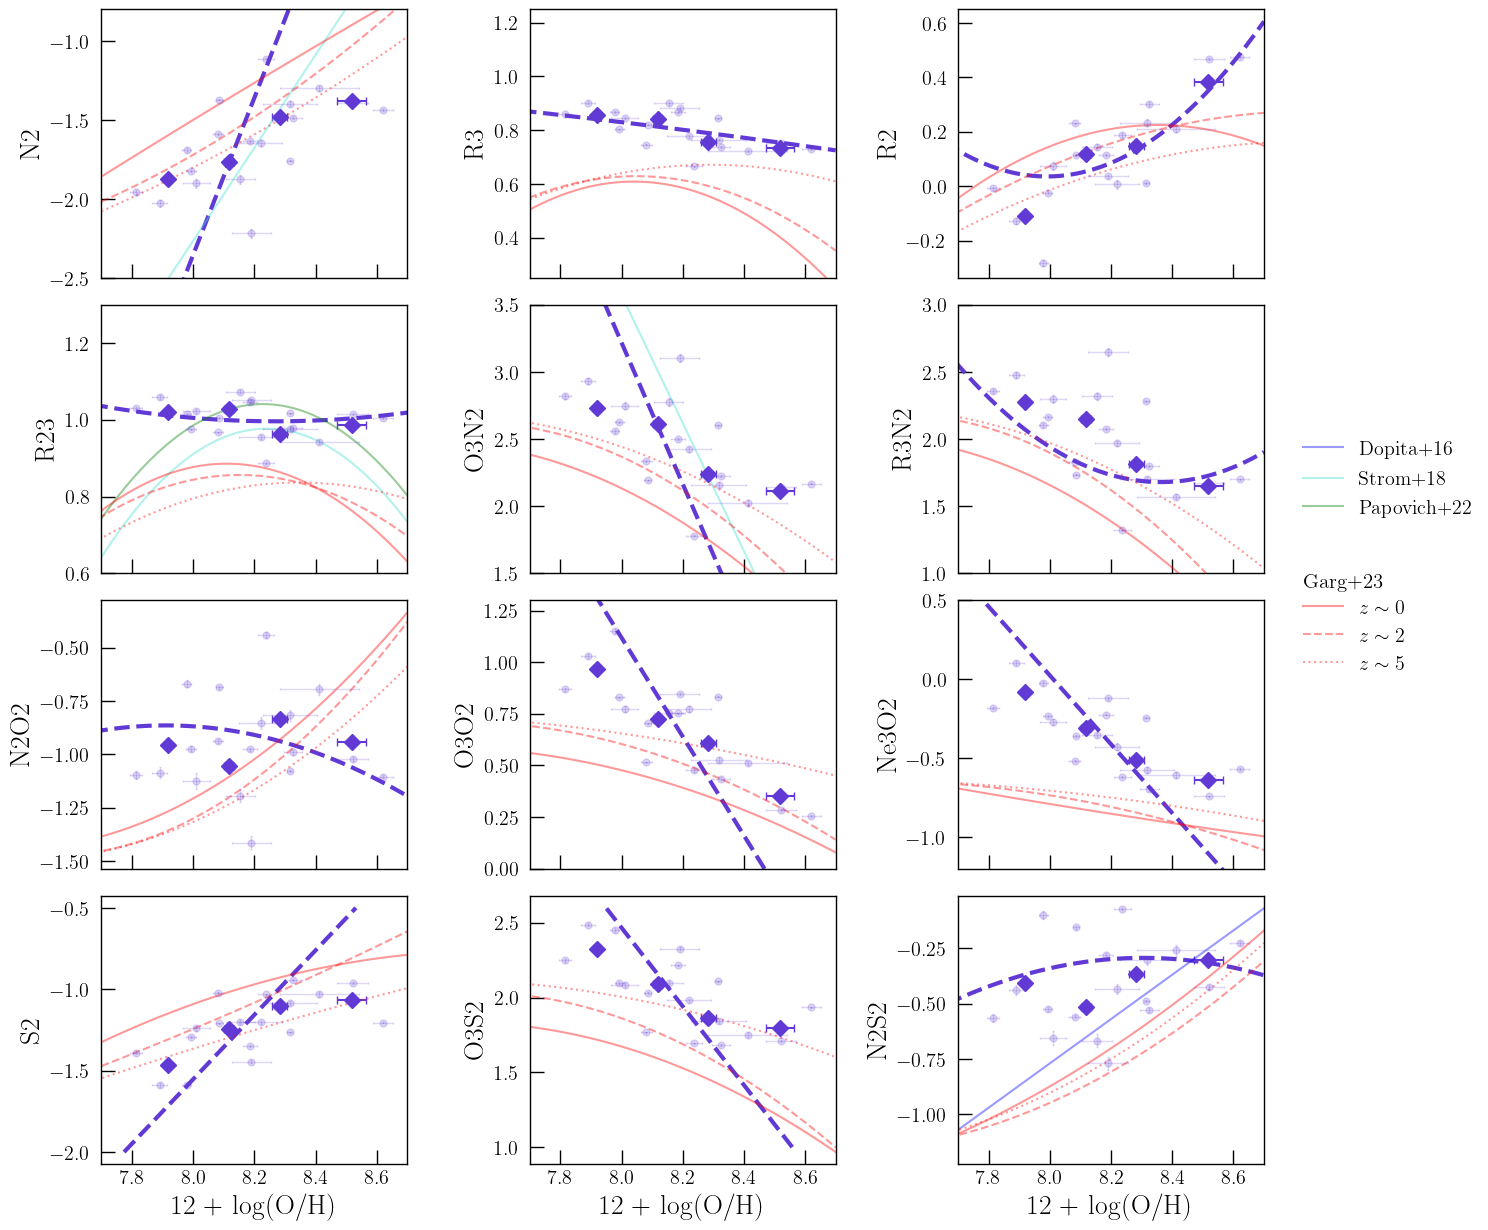

In [16]:
texPlot('on')
fig, axs = plt.subplots(4, 3, sharex=True)
fig.set_size_inches((15, 15))
fig.subplots_adjust(wspace=0.4, hspace=0.1)

# ===========================================================================================================
# N2
# ===========================================================================================================

axs[0, 0].errorbar(metals['log_OH'], upy.nominal_values(N2), xerr=2*log_OH_err, yerr=2*upy.std_devs(N2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 0].plot((N2_tp * out_N2.params['a1'].value) + out_N2.params['a0'].value, N2_tp,
               color=c[2], ls='--', lw=3)

axs[0, 0].plot(log_OH_tp, strom2018(log_OH_tp, 'N2'), color='turquoise', alpha=0.4)
axs[0, 0].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'N2'), label=r'$z \sim 0$', color='red', alpha=0.4)
axs[0, 0].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'N2'), label=r'$z \sim 2$', color='red', alpha=0.4, ls='--')
axs[0, 0].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'N2'), label=r'$z \sim 5$', color='red', alpha=0.4, ls=':')
axs[0, 0].set_ylabel('N2')

# ===========================================================================================================
# R3
# ===========================================================================================================

axs[0, 1].errorbar(metals['log_OH'], upy.nominal_values(R3), xerr=2*log_OH_err, yerr=2*upy.std_devs(R3), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R3),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R3),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 1].plot(log_OH_tp, poly2(log_OH_tp, *out_R3), color=c[2], ls='--', lw=3)

axs[0, 1].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'R3'), color='red', alpha=0.4)
axs[0, 1].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'R3'), color='red', alpha=0.4, ls='--')
axs[0, 1].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'R3'), color='red', alpha=0.4, ls=':')
axs[0, 1].set_ylabel('R3')

# ===========================================================================================================
# R2
# ===========================================================================================================

axs[0, 2].errorbar(metals['log_OH'], upy.nominal_values(R2), xerr=2*log_OH_err, yerr=2*upy.std_devs(R2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 2].plot(log_OH_tp, poly2(log_OH_tp, *out_R2), color=c[2], ls='--', lw=3)

axs[0, 2].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'R2'), color='red', alpha=0.4)
axs[0, 2].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'R2'), color='red', alpha=0.4, ls='--')
axs[0, 2].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'R2'), color='red', alpha=0.4, ls=':')
axs[0, 2].set_ylabel('R2')


# ===========================================================================================================
# R23
# ===========================================================================================================

axs[1, 0].errorbar(metals['log_OH'], upy.nominal_values(R23), xerr=2*log_OH_err, yerr=2*upy.std_devs(R23), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[1, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R23),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R23),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 0].plot(log_OH_tp, poly2(log_OH_tp, *out_R23), color=c[2], ls='--', lw=3)

axs[1, 0].plot(log_OH_tp, strom2018(log_OH_tp, 'R23'), label='Strom+18', color='turquoise', alpha=0.4)
axs[1, 0].plot(log_OH_tp, papovich2022_R23(log_OH_tp), label='Papovich+22', color='green', alpha=0.4)
axs[1, 0].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'R23'), color='red', alpha=0.4)
axs[1, 0].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'R23'), color='red', alpha=0.4, ls='--')
axs[1, 0].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'R23'), color='red', alpha=0.4, ls=':')
axs[1, 0].set_ylabel('R23')

# ===========================================================================================================
# O3N2
# ===========================================================================================================

axs[1, 1].errorbar(metals['log_OH'], upy.nominal_values(O3N2), xerr=2*log_OH_err, yerr=2*upy.std_devs(O3N2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[1, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3N2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_O3N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 1].plot((O3N2_tp * out_O3N2.params['a1'].value) + out_O3N2.params['a0'].value, O3N2_tp,
               color=c[2], ls='--', lw=3)

axs[1, 1].plot(log_OH_tp, strom2018(log_OH_tp, 'O3N2'), label='Strom+2018', color='turquoise', alpha=0.4)
axs[1, 1].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'O3N2'), color='red', alpha=0.4)
axs[1, 1].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'O3N2'), color='red', alpha=0.4, ls='--')
axs[1, 1].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'O3N2'), color='red', alpha=0.4, ls=':')
axs[1, 1].set_ylabel('O3N2')

# ===========================================================================================================
# R3N2
# ===========================================================================================================

axs[1, 2].errorbar(metals['log_OH'], upy.nominal_values(R3N2), xerr=2*log_OH_err, yerr=2*upy.std_devs(R3N2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[1, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R3N2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_R3N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 2].plot(log_OH_tp, poly2(log_OH_tp, *out_R3N2), color=c[2], ls='--', lw=3)

axs[1, 2].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'R3N2'), color='red', alpha=0.4)
axs[1, 2].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'R3N2'), color='red', alpha=0.4, ls='--')
axs[1, 2].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'R3N2'), color='red', alpha=0.4, ls=':')
axs[1, 2].set_ylabel('R3N2')


# ===========================================================================================================
# N2O2
# ===========================================================================================================

axs[2, 0].errorbar(metals['log_OH'], upy.nominal_values(N2O2), xerr=2*log_OH_err, yerr=2*upy.std_devs(N2O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[2, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2O2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_N2O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 0].plot(log_OH_tp, poly2(log_OH_tp, *out_N2O2), color=c[2], ls='--', lw=3)

axs[2, 0].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'N2O2'), color='red', alpha=0.4)
axs[2, 0].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'N2O2'), color='red', alpha=0.4, ls='--')
axs[2, 0].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'N2O2'), color='red', alpha=0.4, ls=':')
axs[2, 0].set_ylabel('N2O2')

# ===========================================================================================================
# O3O2
# ===========================================================================================================

axs[2, 1].errorbar(metals['log_OH'], upy.nominal_values(O3O2), xerr=2*log_OH_err, yerr=2*upy.std_devs(O3O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[2, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3O2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_O3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 1].plot((O3O2_tp * out_O3O2.params['a1'].value) + out_O3O2.params['a0'].value, O3O2_tp,
               color=c[2], ls='--', lw=3)

axs[2, 1].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'O3O2'), color='red', alpha=0.4)
axs[2, 1].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'O3O2'), color='red', alpha=0.4, ls='--')
axs[2, 1].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'O3O2'), color='red', alpha=0.4, ls=':')
axs[2, 1].set_ylabel('O3O2')

# ===========================================================================================================
# Ne3O2
# ===========================================================================================================

axs[2, 2].errorbar(metals['log_OH'], upy.nominal_values(Ne3O2), xerr=2*log_OH_err, yerr=2*upy.std_devs(Ne3O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[2, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_Ne3O2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_Ne3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 2].plot((Ne3O2_tp * out_Ne3O2.params['a1'].value) + out_Ne3O2.params['a0'].value, Ne3O2_tp,
               color=c[2], ls='--', lw=3)

axs[2, 2].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'Ne3O2'), color='red', alpha=0.4)
axs[2, 2].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'Ne3O2'), color='red', alpha=0.4, ls='--')
axs[2, 2].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'Ne3O2'), color='red', alpha=0.4, ls=':')
axs[2, 2].set_ylabel('Ne3O2')

# ===========================================================================================================
# S2
# ===========================================================================================================

axs[3, 0].errorbar(metals['log_OH'], upy.nominal_values(S2), xerr=2*log_OH_err, yerr=2*upy.std_devs(S2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[3, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_S2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_S2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[3, 0].plot((S2_tp * out_S2.params['a1'].value) + out_S2.params['a0'].value, S2_tp,
               color=c[2], ls='--', lw=3)

axs[3, 0].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'S2'), color='red', alpha=0.4)
axs[3, 0].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'S2'), color='red', alpha=0.4, ls='--')
axs[3, 0].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'S2'), color='red', alpha=0.4, ls=':')
axs[3, 0].set_ylabel('S2')

# ===========================================================================================================
# O3S2
# ===========================================================================================================

axs[3, 1].errorbar(metals['log_OH'], upy.nominal_values(O3S2), xerr=2*log_OH_err, yerr=2*upy.std_devs(O3S2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[3, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3S2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_O3S2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[3, 1].plot((O3S2_tp * out_O3S2.params['a1'].value) + out_O3S2.params['a0'].value, O3S2_tp,
               color=c[2], ls='--', lw=3)

axs[3, 1].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'O3S2'), color='red', alpha=0.4)
axs[3, 1].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'O3S2'), color='red', alpha=0.4, ls='--')
axs[3, 1].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'O3S2'), color='red', alpha=0.4, ls=':')
axs[3, 1].set_ylabel('O3S2')

# ===========================================================================================================
# N2S2
# ===========================================================================================================

axs[3, 2].errorbar(metals['log_OH'], upy.nominal_values(N2S2), xerr=2*log_OH_err, yerr=2*upy.std_devs(N2S2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[3, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2S2),
                   xerr=2*upy.std_devs(bin_OH), yerr=2*upy.std_devs(bin_N2S2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[3, 2].plot(log_OH_tp, poly2(log_OH_tp, *out_N2S2), color=c[2], ls='--', lw=3)

axs[3, 2].plot(log_OH_tp, dopita2016_N2S2(log_OH_tp), label='Dopita+16', color='blue', alpha=0.4)
axs[3, 2].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'N2S2'), color='red', alpha=0.4)
axs[3, 2].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'N2S2'), color='red', alpha=0.4, ls='--')
axs[3, 2].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'N2S2'), color='red', alpha=0.4, ls=':')
axs[3, 2].set_ylabel('N2S2')

# ===========================================================================================================
# General settings
# ===========================================================================================================

axs[3, 0].set_xlabel(r'12 + log(O/H)')
axs[3, 1].set_xlabel(r'12 + log(O/H)')
axs[3, 2].set_xlabel(r'12 + log(O/H)')

# limits
# x
axs[0, 0].set_xlim(7.7, 8.7) 

# y
axs[0, 0].set_ylim(-2.5, -0.8) # N2
axs[0, 1].set_ylim(0.25, 1.25) # R3

axs[1, 0].set_ylim(0.6, 1.3) # R23
axs[1, 1].set_ylim(1.5, 3.5) # O3N2
axs[1, 2].set_ylim(1, 3) # R3N2

axs[2, 1].set_ylim(0, 1.3) # O3O2
axs[2, 2].set_ylim(-1.2, 0.5) # Ne3O2

# Legends
axs[0, 0].legend(frameon=False, loc=(3.9, -1.5))
axs[1, 0].legend(frameon=False, loc=(3.9, 0.18))
axs[1, 2].text(8.83, 0.9, 'Garg+23', fontsize=15)
axs[3, 2].legend(frameon=False, loc=(1.1, 2.6))

index_model = [0, 1, 2, 3]
index_sec = [0, 1, 2]
for i in index_model:
    for j in index_sec:
        axs[i, j].tick_params(axis="y", direction="in", length=10)
        axs[i, j].tick_params(axis="x", direction="in", length=10)
        
#fig.savefig(magePath+'analysis/chapter4/calbration_vs_models.pdf', bbox_inches='tight')

# -----------------------

In [2]:
# Metallicities and more
metals = pd.read_csv(magePath+'results/metals/abundance_measured_lstsq.csv')
em_lines = pd.read_csv(magePath+'results/em_lines_lstsq.csv')
sed_results = fits.open('/home/benjamin/Documents/sed_fitting/old_pop_late_burst/results.fits') # SED fitting results

# log(M*)
unc_m_star = upy.uarray(sed_results[1].data['bayes.stellar.m_star'],
                        sed_results[1].data['bayes.stellar.m_star_err'])
m_star = upy.nominal_values(upy.log10(unc_m_star))
m_star_err = upy.std_devs(upy.log10(unc_m_star))

# log(SFR)
unc_sfr = upy.uarray(sed_results[1].data['bayes.sfh.sfr100Myrs'],
                     sed_results[1].data['bayes.sfh.sfr100Myrs_err'])
sfr = upy.nominal_values(upy.log10(unc_sfr))
sfr_err = upy.std_devs(upy.log10(unc_sfr))

metals.keys()

Index(['galname', 'He/H', 'He/H_err', 'log_OH', 'log_OH_err', 'log_SH',
       'log_SH_err', 'log_NH', 'log_NH_err', 'log_NO', 'log_NO_err', 'log_NeH',
       'log_NeH_err', 'log_ArH', 'log_ArH_err', 'log_FeH', 'log_FeH_err',
       'log_q', 'log_q_err', 'log_U', 'log_U_err'],
      dtype='object')

In [3]:
em_lines.keys()

Index(['galname', '[OII]3726', '[OII]3726_err', '[OII]3729', '[OII]3729_err',
       '[NeIII]3868', '[NeIII]3868_err', 'Hd', 'Hd_err', 'Hg', 'Hg_err',
       '[OIII]4363', '[OIII]4363_err', 'HeI4471', 'HeI4471_err', '[FeIII]4658',
       '[FeIII]4658_err', 'HeII4686', 'HeII4686_err', '[ArIV]4740',
       '[ArIV]4740_err', 'Hb', 'Hb_err', '[OIII]4959', '[OIII]4959_err',
       '[OIII]5007', '[OIII]5007_err', '[NII]5755', '[NII]5755_err', 'HeI5875',
       'HeI5875_err', '[OI]6300', '[OI]6300_err', '[SIII]6312',
       '[SIII]6312_err', '[NII]6548', '[NII]6548_err', 'Ha', 'Ha_err',
       '[NII]6584', '[NII]6584_err', 'HeI6678', 'HeI6678_err', '[SII]6716',
       '[SII]6716_err', '[SII]6730', '[SII]6730_err', 'HeI7065', 'HeI7065_err',
       '[ArIII]7135', '[ArIII]7135_err', '[OII]7319', '[OII]7319_err',
       '[OII]7330', '[OII]7330_err', '[SIII]9069', '[SIII]9069_err',
       '[SIII]9532', '[SIII]9532_err'],
      dtype='object')

In [4]:
# Line ratios

N2 = upy.log10(upy.uarray(em_lines['[NII]6584'], em_lines['[NII]6584_err']) / upy.uarray(em_lines['Ha'], em_lines['Ha_err']))

R2 = upy.log10((upy.uarray(em_lines['[OII]3726'], em_lines['[OII]3726_err']) \
              + upy.uarray(em_lines['[OII]3729'], em_lines['[OII]3729_err'])) / upy.uarray(em_lines['Hb'], em_lines['Hb_err']))

R3 = upy.log10(upy.uarray(em_lines['[OIII]5007'], em_lines['[OIII]5007_err']) / upy.uarray(em_lines['Hb'], em_lines['Hb_err']))

R23 = upy.log10((upy.uarray(em_lines['[OII]3726'], em_lines['[OII]3726_err']) \
               + upy.uarray(em_lines['[OII]3729'], em_lines['[OII]3729_err']) \
               + upy.uarray(em_lines['[OIII]4959'], em_lines['[OIII]4959_err']) \
               + upy.uarray(em_lines['[OIII]5007'], em_lines['[OIII]5007_err']))  / upy.uarray(em_lines['Hb'], em_lines['Hb_err']))

O3N2 = upy.log10((upy.uarray(em_lines['[OIII]5007'], em_lines['[OIII]5007_err']) / upy.uarray(em_lines['Hb'], em_lines['Hb_err'])) \
               / (upy.uarray(em_lines['[NII]6584'], em_lines['[NII]6584_err']) / upy.uarray(em_lines['Ha'], em_lines['Ha_err'])))

R3N2 = upy.log10(upy.uarray(em_lines['[OIII]5007'], em_lines['[OIII]5007_err']) / upy.uarray(em_lines['[NII]6584'], em_lines['[NII]6584_err']))

N2O2 = upy.log10(upy.uarray(em_lines['[NII]6584'], em_lines['[NII]6584_err']) / upy.uarray(em_lines['[OII]3726'], em_lines['[OII]3726_err']))

O3O2 = upy.log10(upy.uarray(em_lines['[OIII]5007'], em_lines['[OIII]5007_err']) / (upy.uarray(em_lines['[OII]3726'], em_lines['[OII]3726_err']) \
               + upy.uarray(em_lines['[OII]3729'], em_lines['[OII]3729_err'])))

Ne3O2 = upy.log10(upy.uarray(em_lines['[NeIII]3868'], em_lines['[NeIII]3868_err'])/ (upy.uarray(em_lines['[OII]3726'], em_lines['[OII]3726_err']) \
                + upy.uarray(em_lines['[OII]3729'], em_lines['[OII]3729_err'])))

S2 = upy.log10((upy.uarray(em_lines['[SII]6716'], em_lines['[SII]6716_err']) + upy.uarray(em_lines['[SII]6730'], em_lines['[SII]6730_err'])) \
              / upy.uarray(em_lines['Ha'], em_lines['Ha_err']))

O3S2 = upy.log10((upy.uarray(em_lines['[OIII]5007'], em_lines['[OIII]5007_err']) / upy.uarray(em_lines['Hb'], em_lines['Hb_err'])) \
              / ((upy.uarray(em_lines['[SII]6716'], em_lines['[SII]6716_err']) + upy.uarray(em_lines['[SII]6730'], em_lines['[SII]6730_err']))  / upy.uarray(em_lines['Ha'], em_lines['Ha_err'])))
 
N2S2 = upy.log10((upy.uarray(em_lines['[NII]6584'], em_lines['[NII]6584_err']) / (upy.uarray(em_lines['[SII]6716'], em_lines['[SII]6716_err']) \
                + upy.uarray(em_lines['[SII]6730'], em_lines['[SII]6730_err']))) + (0.264 * (upy.uarray(em_lines['[NII]6584'], em_lines['[NII]6584_err']) \
                / upy.uarray(em_lines['Ha'], em_lines['Ha_err']))))

# Data binning

In [5]:
mask1 = (metals['log_OH'] > 7.8) & (metals['log_OH'] <= 8.0)
mask2 = (metals['log_OH'] > 8.0) & (metals['log_OH'] <= 8.2)
mask3 = (metals['log_OH'] > 8.2) & (metals['log_OH'] <= 8.4)
mask4 = (metals['log_OH'] > 8.4) & (metals['log_OH'] <= 8.6)

def binning(values, errors):
    bin1 = np.mean(upy.uarray(values[mask1], errors[mask1]))
    bin2 = np.mean(upy.uarray(values[mask2], errors[mask2]))
    bin3 = np.mean(upy.uarray(values[mask3], errors[mask3]))
    bin4 = np.mean(upy.uarray(values[mask4], errors[mask4]))
    
    total_bin = upy.uarray([bin1.nominal_value, bin2.nominal_value, bin3.nominal_value, bin4.nominal_value],
                           [bin1.std_dev, bin2.std_dev, bin3.std_dev, bin4.std_dev])
    return total_bin

bin_OH = binning(metals['log_OH'], metals['log_OH_err'])
bin_N2 = binning(upy.nominal_values(N2), upy.std_devs(N2))
bin_R2 = binning(upy.nominal_values(R2), upy.std_devs(R2))
bin_R3 = binning(upy.nominal_values(R3), upy.std_devs(R3))
bin_R23 = binning(upy.nominal_values(R23), upy.std_devs(R23))
bin_O3N2 = binning(upy.nominal_values(O3N2), upy.std_devs(O3N2))
bin_R3N2 = binning(upy.nominal_values(R3N2), upy.std_devs(R3N2))
bin_N2O2 = binning(upy.nominal_values(N2O2), upy.std_devs(N2O2))
bin_O3O2 = binning(upy.nominal_values(O3O2), upy.std_devs(O3O2))
bin_Ne3O2 = binning(upy.nominal_values(Ne3O2), upy.std_devs(Ne3O2))
bin_S2 = binning(upy.nominal_values(S2), upy.std_devs(S2))
bin_O3S2 = binning(upy.nominal_values(O3S2), upy.std_devs(O3S2))
bin_N2S2 = binning(upy.nominal_values(N2S2), upy.std_devs(N2S2))

In [18]:
len(metals['log_OH'][mask1])

4

In [19]:
len(metals['log_OH'][mask2])

6

In [21]:
len(metals['log_OH'][mask3])

3

In [22]:
len(metals['log_OH'][mask4])

5

# Table

In [6]:
ratios_table = {'ID': metals['galname'].to_numpy(),
                '12 + log(O/H)': upy.uarray(metals['log_OH'], metals['log_OH_err']),
                '12 + log(N/H)': upy.uarray(metals['log_NH'], metals['log_NH_err']),
                'log(N/O)': upy.uarray(metals['log_NO'], metals['log_NO_err']),
                'N2': N2,
                'R2': R2,
                'R3': R3,
                'R23': R23,
                'O3N2': O3N2,
                'R3N2': R3N2,
                'N2O2': N2O2,
                'O3O2': O3O2,
                'Ne3O2': Ne3O2,
                'S2': S2,
                'O3S2': O3S2,
                'N2S2': N2S2
}
ratios_table_pd = pd.DataFrame(data=ratios_table, index=None)

bin_table = {'Bin': np.array(['7.8 - 8.0', '8.0 - 8.2', '8.2 - 8.4', '8.4 - 8.6']),
             '12 + log(O/H)': bin_OH,
             '12 + log(N/H)': None,
             'log(N/O)': None,
             'N2': bin_N2,
             'R2': bin_R2,
             'R3': bin_R3,
             'R23': bin_R23,
             'O3N2': bin_O3N2,
             'R3N2': bin_R3N2,
             'N2O2': bin_N2O2,
             'O3O2': bin_O3O2,
             'Ne3O2': bin_Ne3O2,
             'S2': bin_S2,
             'O3S2': bin_O3S2,
             'N2S2': bin_N2S2
}
bin_table_pd = pd.DataFrame(data=bin_table, index=None)

In [7]:
ratios_table_pd.to_latex(index=None, float_format='%.3f')

'\\begin{tabular}{lllllllllllllllll}\n\\toprule\n & ID & 12 + log(O/H) & 12 + log(N/H) & log(N/O) & N2 & R2 & R3 & R23 & O3N2 & R3N2 & N2O2 & O3O2 & Ne3O2 & S2 & O3S2 & N2S2 \\\\\n\\midrule\n0 & J0021 & 8.24+/-0.04 & 7.23+/-0.05 & -1.01+/-0.06 & -1.11+/-0.04 & 0.187+/-0.032 & 0.665+/-0.029 & 0.887+/-0.025 & 1.78+/-0.05 & 1.32+/-0.04 & -0.44+/-0.05 & 0.477+/-0.031 & -0.62+/-0.04 & -1.031+/-0.022 & 1.70+/-0.04 & -0.07+/-0.04 \\\\\n1 & J0023 & 8.112+/-0.030 & 6.64+/-0.07 & -1.47+/-0.10 & -1.59+/-0.08 & 0.26+/-0.07 & 0.74+/-0.07 & 0.97+/-0.06 & 2.33+/-0.11 & 1.86+/-0.09 & -1.00+/-0.10 & 0.48+/-0.07 & -0.52+/-0.08 & -1.02+/-0.05 & 1.77+/-0.09 & -0.56+/-0.08 \\\\\n2 & J0136 & 8.135+/-0.032 & 6.43+/-0.07 & -1.67+/-0.08 & -1.88+/-0.06 & 0.15+/-0.07 & 0.90+/-0.07 & 1.07+/-0.06 & 2.78+/-0.09 & 2.33+/-0.07 & -1.21+/-0.08 & 0.75+/-0.06 & -0.35+/-0.07 & -1.24+/-0.04 & 2.14+/-0.08 & -0.63+/-0.06 \\\\\n3 & J0240 & 7.975+/-0.020 & 6.99+/-0.12 & -0.92+/-0.13 & -1.69+/-0.10 & -0.28+/-0.05 & 0.87+/-0.05 

In [8]:
bin_table_pd.to_latex(index=None, float_format='%.3f')

'\\begin{tabular}{lllllllllllllllll}\n\\toprule\n & Bin & 12 + log(O/H) & 12 + log(N/H) & log(N/O) & N2 & R2 & R3 & R23 & O3N2 & R3N2 & N2O2 & O3O2 & Ne3O2 & S2 & O3S2 & N2S2 \\\\\n\\midrule\n0 & 7.8 - 8.0 & 7.913+/-0.011 & NaN & NaN & -1.87+/-0.04 & -0.115+/-0.028 & 0.858+/-0.028 & 1.020+/-0.025 & 2.73+/-0.05 & 2.27+/-0.04 & -0.95+/-0.04 & 0.973+/-0.028 & -0.083+/-0.032 & -1.463+/-0.019 & 2.321+/-0.034 & -0.407+/-0.035 \\\\\n1 & 8.0 - 8.2 & 8.116+/-0.015 & NaN & NaN & -1.768+/-0.027 & 0.124+/-0.018 & 0.843+/-0.018 & 1.028+/-0.015 & 2.610+/-0.032 & 2.157+/-0.027 & -1.067+/-0.030 & 0.719+/-0.017 & -0.308+/-0.020 & -1.250+/-0.014 & 2.093+/-0.022 & -0.511+/-0.025 \\\\\n2 & 8.2 - 8.4 & 8.28+/-0.04 & NaN & NaN & -1.51+/-0.06 & 0.08+/-0.07 & 0.76+/-0.07 & 0.95+/-0.06 & 2.27+/-0.09 & 1.87+/-0.07 & -0.82+/-0.08 & 0.68+/-0.07 & -0.43+/-0.08 & -1.17+/-0.05 & 1.93+/-0.08 & -0.33+/-0.05 \\\\\n3 & 8.4 - 8.6 & 8.45+/-0.06 & NaN & NaN & -1.40+/-0.07 & 0.34+/-0.09 & 0.74+/-0.09 & 0.98+/-0.08 & 2.14+/-

# Models to fit

In [9]:
# For LMFIT

# Linear
def residuals_linear(params, x, y, err):
    m = params['a1']
    n = params['a0']
    
    model = (m * x) + n
    return (model - y) / err

# Polynomial of degree 3

def residuals_poly3(params, x, y, err):
    a0 = params['a0']
    a1 = params['a1']
    a2 = params['a2']
    a3 = params['a3']
    
    model = a0 + (a1 * x) + (a2 * (x**2)) + (a3 + (x**3))
    return (model - y) / np.max(err)


# For curve_fit

import scipy

def poly2(x, a0, a1, a2):
    t0 = a0
    t1 = a1 * x
    t2 = a2 * (x**2)
    return t0 + t1 + t2

def poly3(x, a0, a1, a2, a3):
    t0 = a0
    t1 = a1 * x
    t2 = a2 * (x**2)
    t3 = a3 * (x**3)
    return t0 + t1 + t2 + t3

# Fits

## Linear

In [10]:
# ===========================================================================================================
# N2 Ratio
# ===========================================================================================================

params_N2 = Parameters()
params_N2.add('a0', value=8.82)
params_N2.add('a1', value=0.49)

#out_N2 = minimize(residuals_linear, params_N2, args=(upy.nominal_values(N2),
#                                                     metals['log_OH'].to_numpy(),
#                                                     metals['log_OH_err'].to_numpy()),
#                                                     method='leastsq')

out_N2_med = minimize(residuals_linear, params_N2, args=(upy.nominal_values(bin_N2),
                                                     upy.nominal_values(bin_OH),
                                                     upy.std_devs(bin_OH)),
                                                     method='leastsq')

# ===========================================================================================================
# O3N2 Ratio
# ===========================================================================================================

params_O3N2 = Parameters()
params_O3N2.add('a0', value=8.97)
params_O3N2.add('a1', value=-0.39)

#out_O3N2 = minimize(residuals_linear, params_O3N2, args=(upy.nominal_values(O3N2),
#                                                     metals['log_OH'].to_numpy(),
#                                                     metals['log_OH_err'].to_numpy()),
#                                                     method='leastsq')

out_O3N2_med = minimize(residuals_linear, params_O3N2, args=(upy.nominal_values(bin_O3N2),
                                                     upy.nominal_values(bin_OH),
                                                     upy.std_devs(bin_OH)),
                                                     method='leastsq')

# ===========================================================================================================
# O3O2 Ratio
# ===========================================================================================================

params_O3O2 = Parameters()
params_O3O2.add('a0', value=8.54)
params_O3O2.add('a1', value=-0.59)

#out_O3O2 = minimize(residuals_linear, params_O3O2, args=(upy.nominal_values(O3O2),
#                                                     metals['log_OH'].to_numpy(),
#                                                     metals['log_OH_err'].to_numpy()),
#                                                     method='leastsq')

out_O3O2_med = minimize(residuals_linear, params_O3O2, args=(upy.nominal_values(bin_O3O2),
                                                     upy.nominal_values(bin_OH),
                                                     upy.std_devs(bin_OH)),
                                                     method='leastsq')

# ===========================================================================================================
# Ne3O2 Ratio
# ===========================================================================================================

params_Ne3O2 = Parameters()
params_Ne3O2.add('a0', value=7.8)
params_Ne3O2.add('a1', value=-0.63)

#out_Ne3O2 = minimize(residuals_linear, params_Ne3O2, args=(upy.nominal_values(Ne3O2),
#                                                     metals['log_OH'].to_numpy(),
#                                                     metals['log_OH_err'].to_numpy()),
#                                                     method='leastsq')

out_Ne3O2_med = minimize(residuals_linear, params_Ne3O2, args=(upy.nominal_values(bin_Ne3O2),
                                                     upy.nominal_values(bin_OH),
                                                     upy.std_devs(bin_OH)),
                                                     method='leastsq')

# ===========================================================================================================
# S2 Ratio
# ===========================================================================================================

params_S2 = Parameters()
params_S2.add('a0', value=0.9)
params_S2.add('a1', value=9.2)

#out_S2 = minimize(residuals_linear, params_S2, args=(upy.nominal_values(S2),
#                                                     metals['log_OH'].to_numpy(),
#                                                     metals['log_OH_err'].to_numpy()),
#                                                     method='leastsq')

out_S2_med = minimize(residuals_linear, params_S2, args=(upy.nominal_values(bin_S2),
                                                     upy.nominal_values(bin_OH),
                                                     upy.std_devs(bin_OH)),
                                                     method='leastsq')

# ===========================================================================================================
# O3S2 Ratio
# ===========================================================================================================

params_O3S2 = Parameters()
params_O3S2.add('a0', value=-0.4)
params_O3S2.add('a1', value=-8.8)

#out_O3S2 = minimize(residuals_linear, params_O3S2, args=(upy.nominal_values(O3S2),
#                                                     metals['log_OH'].to_numpy(),
#                                                     metals['log_OH_err'].to_numpy()),
#                                                     method='leastsq')
out_O3S2_med = minimize(residuals_linear, params_O3S2, args=(upy.nominal_values(bin_O3S2),
                                                     upy.nominal_values(bin_OH),
                                                     upy.std_devs(bin_OH)),
                                                     method='leastsq')

## Polynomial

In [11]:
# ===========================================================================================================
# R2 Ratio
# ===========================================================================================================

out_R2_med, cov_R2_med = scipy.optimize.curve_fit(poly2, upy.nominal_values(bin_OH), upy.nominal_values(bin_R2),
                                         p0=[-154.9571, 36.9128, -2.1921], sigma=upy.std_devs(bin_R2),
                                         absolute_sigma=True)

# ===========================================================================================================
# R3 Ratio
# ===========================================================================================================

out_R3_med, cov_R3_med = scipy.optimize.curve_fit(poly2, upy.nominal_values(bin_OH), upy.nominal_values(bin_R3),
                                         p0=[-88.4378, 22.7529, -1.4501], sigma=upy.std_devs(bin_R3),
                                         absolute_sigma=True)

# ===========================================================================================================
# R23 Ratio
# ===========================================================================================================

out_R23_med, cov_R23_med = scipy.optimize.curve_fit(poly2, upy.nominal_values(bin_OH), upy.nominal_values(bin_R23),
                                   p0=[-26.21514017, 6.78095055, -0.42194886], sigma=upy.std_devs(bin_R23),
                                   absolute_sigma=True)

# ===========================================================================================================
# R3N2 Ratio
# ===========================================================================================================

out_R3N2_med, cov_R3N2_med = scipy.optimize.curve_fit(poly2, upy.nominal_values(bin_OH), upy.nominal_values(bin_R3N2),
                                    p0=[-94.40880246, 24.76665082, -1.58572683], sigma=upy.std_devs(bin_R3N2),
                                    absolute_sigma=True)

# ===========================================================================================================
# N2O2 Ratio
# ===========================================================================================================

out_N2O2_med, cov_N2O2_med = scipy.optimize.curve_fit(poly2, upy.nominal_values(bin_OH), upy.nominal_values(bin_N2O2),
                                    p0=[128.94, -48.818, 6.2759], sigma=upy.std_devs(bin_N2O2),
                                    absolute_sigma=True)

# ===========================================================================================================
# N2S2 Ratio
# ===========================================================================================================

out_N2S2_med, cov_N2S2_med = scipy.optimize.curve_fit(poly2, upy.nominal_values(bin_OH), upy.nominal_values(bin_N2S2),
                                    p0=[128.94, -48.818, 6.2759], sigma=upy.std_devs(bin_N2S2),
                                    absolute_sigma=True)

# Metallicity Calibrations

In [12]:
# Utils
log_OH_tp = np.linspace(7.6, 8.7, 1000)
N2_tp = np.linspace(-3.5, 0.1, 1000)
R3_tp = np.linspace(0.2, 1.3, 1000)
R23_tp = np.linspace(0.4, 1.3, 1000)
O3N2_tp = np.linspace(1, 4, 1000)
O3O2_tp = np.linspace(0, 1.5, 1000)
Ne3O2_tp = np.linspace(-2.0, 0.5, 1000)
S2_tp = np.linspace(-2.0, -0.5, 1000)
O3S2_tp = np.linspace(1.0, 2.6, 1000)

## Local relations

In [13]:
# Functions

def denicolo2002_N2(log_OH_12):
    N2 = (log_OH_12 - 9.12) / 0.73
    return N2


def tremonti2004_R23(R23):
    log_OH_12 = 9.185 - (0.313 * R23) - (0.264 * (R23**2)) - (0.321 * (R23**3)) 
    return log_OH_12


def pettini_pagel2004_O3N2(log_OH_12):
    O3N2 = - (log_OH_12 - 8.73) / 0.32
    return O3N2


def pettini_pagel2004_N2(N2):
    log_OH_12 = 9.37 + (2.03 * N2) + (1.26 * (N2**2)) + (0.32 * (N2**3))
    return log_OH_12


def nagao2006(log_OH_12, ratio='asd'):
    if ratio == 'R23':
        b0 = 1.2299
        b1 = -4.1926
        b2 = 1.0246
        b3 = -0.063169
    if ratio == 'N2':
        b0 = 96.641
        b1 = -39.941
        b2 = 5.2227
        b3 = -0.22040
    if ratio == 'R3N2':
        b0 = -232.18
        b1 = 84.423
        b2 = -9.9330
        b3 = 0.37941
    if ratio == 'N2O2':
        b0 = -128.94
        b1 = 48.818
        b2 = -6.2759
        b3 = 0.27101
    if ratio == 'O3O2':
        b0 = -1.4089
        b1 = 1.3745
        b2 = -0.14359
        b3 = 0
    return b0 + (b1 * log_OH_12) + (b2 * (log_OH_12**2)) + (b3 * (log_OH_12**3))

def maiolino2008(log_OH_12, ratio='asd'):
    x = (log_OH_12 - 8.69)
    if ratio == 'R23':
        c0 = 0.7462
        c1 = -0.7149
        c2 = -0.9401
        c3 = -0.6154
        c4 = -0.2524
    if ratio == 'N2':
        c0 = -0.7732
        c1 = 1.2357
        c2 = -0.2811
        c3 = -0.7201
        c4 = -0.3330
    if ratio == 'R3':
        c0 = 0.1549
        c1 = -1.5031
        c2 = -0.9790
        c3 = -0.0297
        c4 = 0.0
    if ratio == 'O3O2':
        c0 = -0.2839
        c1 = -1.3881
        c2 = -0.3172
        c3 = 0.0
        c4 = 0.0
    if ratio == 'R2':
        c0 = 0.5603
        c1 = 0.0450
        c2 = -1.8017
        c3 = -1.8434
        c4 = -0.6549
    if ratio == 'R3N2':
        c0 = 0.4520
        c1 = -2.6096
        c2 = -0.7170
        c3 = 0.1347
        c4 = 0.0
    if ratio == 'Ne3O2':
        c0 = -1.2608
        c1 = -1.0861
        c2 = -0.1470
        c3 = 0.0
        c4 = 0.0
    return c0 + (c1 * x) + (c2 * (x**2)) + (c3 * (x**3)) + (c4 * (x**4))


def marino2013_N2(log_OH_12):
    N2 = (log_OH_12 - 8.743) / 0.462
    return N2


def marino2013_O3N2(log_OH_12):
    O3N2 = - (log_OH_12 - 8.533) / 0.214
    return O3N2


def curti2020(log_OH_12, ratio='asd'):
    x = (log_OH_12 - 8.69)
    if ratio == 'R2':
        c0 = 0.435
        c1 = -1.362
        c2 = -5.655
        c3 = -4.851
        c4 = -0.478
        c5 = 0.736
    if ratio == 'R3':
        c0 = -0.277
        c1 = -3.549
        c2 = -3.593
        c3 = -0.981
        c4 = 0.0
        c5 = 0.0
    if ratio == 'O3O2':
        c0 = -0.691
        c1 = -2.944
        c2 = -1.308
        c3 = 0.0
        c4 = 0.0
        c5 = 0.0
    if ratio == 'R23':
        c0 = 0.527
        c1 = -1.569
        c2 = -1.652
        c3 = -0.421
        c4 = 0.0
        c5 = 0.0
    if ratio == 'N2':
        c0 = -0.489
        c1 = 1.513
        c2 = -2.554
        c3 = -5.293
        c4 = -2.867
        c5 = 0.0
    if ratio == 'O3N2':
        c0 = 0.281
        c1 = -4.765
        c2 = -2.268
        c3 = 0.0
        c4 = 0.0
        c5 = 0.0
    if ratio == 'S2':
        c0 = -0.442
        c1 = -0.360
        c2 = -6.271
        c3 = -8.339
        c4 = -3.559
        c5 = 0.0
    if ratio == 'O3S2':
        c0 = 0.191
        c1 = -4.292
        c2 = -2.538
        c3 = 0.053
        c4 = 0.332
        c5 = 0.0
    return c0 + (c1 * x) + (c2 * (x**2)) + (c3 * (x**3)) + (c4 * (x**4)) + (c5 * (x**5))

def sanders2021(log_OH_12, ratio='asd'):
    x = (log_OH_12 - 8.69)
    if ratio == 'R3':
        c0 = -0.143
        c1 = -3.16
        c2 = -4.06
        c3 = -1.49
    if ratio == 'R2':
        c0 = 0.27
        c1 = -0.452
        c2 = -0.52
        c3 = 0.0831
    if ratio == 'O3O2':
        c0 = -0.413
        c1 = -2.7
        c2 = -3.52
        c3 = -1.55
    if ratio == 'R23':
        c0 = 0.469
        c1 = -1.51
        c2 = -1.75
        c3 = -0.508
    if ratio == 'N2':
        c0 = -0.606
        c1 = 1.28
        c2 = -0.435
        c3 = -0.485
    if ratio == 'O3N2':
        c0 = 0.461
        c1 = -4.40
        c2 = -3.37
        c3 = -0.761
    return c0 + (c1 * x) + (c2 * (x**2)) + (c3 * (x**3))

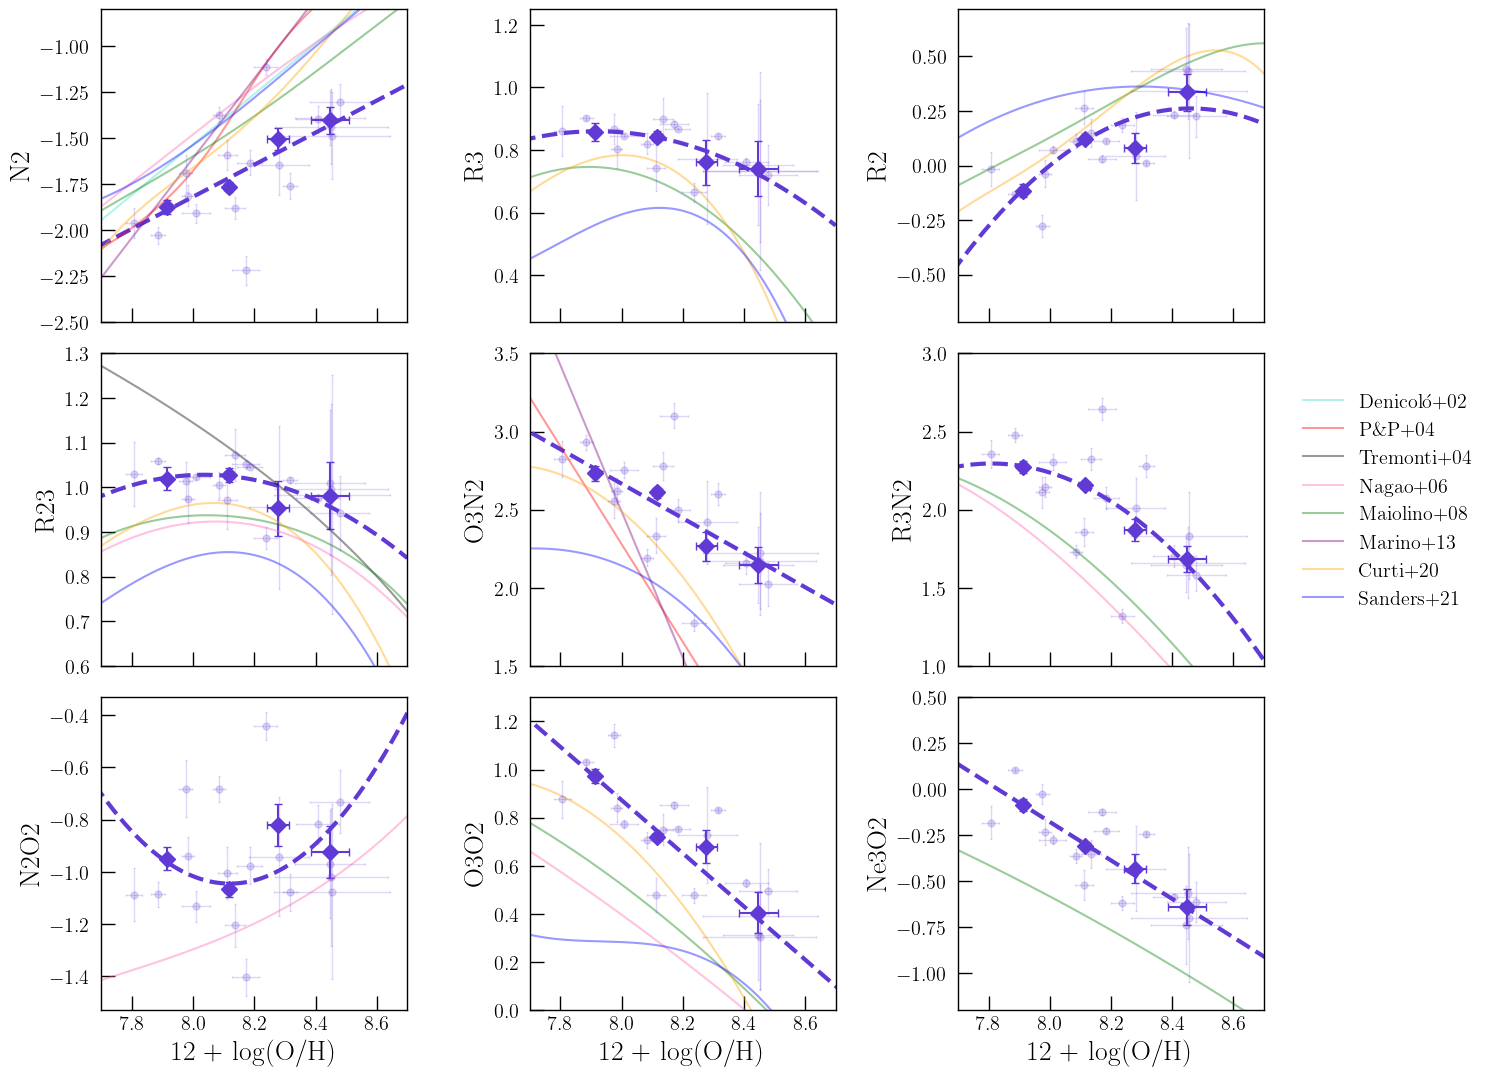

In [14]:
texPlot('on')
fig, axs = plt.subplots(3, 3, sharex=True)
fig.set_size_inches((15, 13))
fig.subplots_adjust(wspace=0.4, hspace=0.1)

# ===========================================================================================================
# N2 Ratio
# ===========================================================================================================

axs[0, 0].errorbar(metals['log_OH'], upy.nominal_values(N2), xerr=metals['log_OH_err'], yerr=upy.std_devs(N2), 
                  marker='o', markersize=5, ls='', color=c[2], elinewidth=1, capsize=1, zorder=100, alpha=0.2)
axs[0, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 0].plot((N2_tp * out_N2_med.params['a1'].value) + out_N2_med.params['a0'].value, N2_tp,
               color=c[2], ls='--', lw=3)

# Relations
axs[0, 0].plot(log_OH_tp, denicolo2002_N2(log_OH_tp), label='Denicoló+02', color='turquoise', alpha=0.4)
axs[0, 0].plot(pettini_pagel2004_N2(N2_tp), N2_tp,
               label=r'P\&P+04', color='red', alpha=0.4)
axs[0, 0].plot(log_OH_tp, nagao2006(log_OH_tp, 'N2'), color='hotpink', alpha=0.4)
axs[0, 0].plot(log_OH_tp, maiolino2008(log_OH_tp, 'N2'), color='green', alpha=0.4)
axs[0, 0].plot(log_OH_tp, marino2013_N2(log_OH_tp), color='purple', alpha=0.4)
axs[0, 0].plot(log_OH_tp, curti2020(log_OH_tp, 'N2'), color='orange', alpha=0.4)
axs[0, 0].plot(log_OH_tp, sanders2021(log_OH_tp, 'N2'), color='blue', alpha=0.4)
axs[0, 0].set_ylabel('N2')


# ===========================================================================================================
# R3 Ratio
# ===========================================================================================================

axs[0, 1].errorbar(metals['log_OH'], upy.nominal_values(R3), xerr=metals['log_OH_err'], yerr=upy.std_devs(R3), 
                  marker='o', markersize=5, ls='', color=c[2], elinewidth=1, capsize=1, zorder=100, alpha=0.2)
axs[0, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R3),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_R3),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 1].plot(log_OH_tp, poly2(log_OH_tp, *out_R3_med), color=c[2], ls='--', lw=3)

axs[0, 1].plot(log_OH_tp, maiolino2008(log_OH_tp, 'R3'), label='Maiolino+08', color='green', alpha=0.4)
axs[0, 1].plot(log_OH_tp, curti2020(log_OH_tp, 'R3'), label='Curti+20', color='orange', alpha=0.4)
axs[0, 1].plot(log_OH_tp, sanders2021(log_OH_tp, 'R3'), label='Sanders+21', color='blue', alpha=0.4)
axs[0, 1].set_ylabel('R3')

# ===========================================================================================================
# R2 Ratio
# ===========================================================================================================

axs[0, 2].errorbar(metals['log_OH'], upy.nominal_values(R2), xerr=metals['log_OH_err'], yerr=upy.std_devs(R2), 
                  marker='o', markersize=5, ls='', color=c[2], elinewidth=1, capsize=1, zorder=100, alpha=0.2)
axs[0, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_R2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 2].plot(log_OH_tp, poly2(log_OH_tp, *out_R2_med), color=c[2], ls='--', lw=3)

axs[0, 2].plot(log_OH_tp, maiolino2008(log_OH_tp, 'R2'), label='Maiolino+2008', color='green', alpha=0.4)
axs[0, 2].plot(log_OH_tp, curti2020(log_OH_tp, 'R2'), label='Curti+2020', color='orange', alpha=0.4)
axs[0, 2].plot(log_OH_tp, sanders2021(log_OH_tp, 'R2'), label='Sanders+2021', color='blue', alpha=0.4)
axs[0, 2].set_ylabel('R2')

# ===========================================================================================================
# R23 Ratio
# ===========================================================================================================

axs[1, 0].errorbar(metals['log_OH'], upy.nominal_values(R23), xerr=metals['log_OH_err'], yerr=upy.std_devs(R23), 
                  marker='o', markersize=5, ls='', color=c[2], elinewidth=1, capsize=1, zorder=100, alpha=0.2)
axs[1, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R23),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_R23),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 0].plot(log_OH_tp, poly2(log_OH_tp, *out_R23_med), color=c[2], ls='--', lw=3)

axs[1, 0].plot(tremonti2004_R23(R23_tp), R23_tp, label='Tremonti+04', color='black', alpha=0.4)
axs[1, 0].plot(log_OH_tp, nagao2006(log_OH_tp, 'R23'), color='hotpink', alpha=0.4)
axs[1, 0].plot(log_OH_tp, maiolino2008(log_OH_tp, 'R23'), color='green', alpha=0.4)
axs[1, 0].plot(log_OH_tp, curti2020(log_OH_tp, 'R23'), color='orange', alpha=0.4)
axs[1, 0].plot(log_OH_tp, sanders2021(log_OH_tp, 'R23'), color='blue', alpha=0.4)
axs[1, 0].set_ylabel('R23')

# ===========================================================================================================
# O3N2 Ratio
# ===========================================================================================================

axs[1, 1].errorbar(metals['log_OH'], upy.nominal_values(O3N2), xerr=metals['log_OH_err'], yerr=upy.std_devs(O3N2), 
                  marker='o', markersize=5, ls='', color=c[2], elinewidth=1, capsize=1, zorder=100, alpha=0.2)
axs[1, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3N2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_O3N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 1].plot((O3N2_tp * out_O3N2_med.params['a1'].value) + out_O3N2_med.params['a0'].value, O3N2_tp,
               color=c[2], ls='--', lw=3)

axs[1, 1].plot(log_OH_tp, pettini_pagel2004_O3N2(log_OH_tp), color='red', alpha=0.4)
axs[1, 1].plot(log_OH_tp, marino2013_O3N2(log_OH_tp), label='Marino+13', color='purple', alpha=0.4)
axs[1, 1].plot(log_OH_tp, curti2020(log_OH_tp, 'O3N2'), label='Curti+20', color='orange', alpha=0.4)
axs[1, 1].plot(log_OH_tp, sanders2021(log_OH_tp, 'O3N2'), label='Sanders+21', color='blue', alpha=0.4)
axs[1, 1].set_ylabel('O3N2')

# ===========================================================================================================
# R3N2 Ratio
# ===========================================================================================================

axs[1, 2].errorbar(metals['log_OH'], upy.nominal_values(R3N2), xerr=metals['log_OH_err'], yerr=upy.std_devs(R3N2), 
                  marker='o', markersize=5, ls='', color=c[2], elinewidth=1, capsize=1, zorder=100, alpha=0.2)
axs[1, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R3N2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_R3N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 2].plot(log_OH_tp, poly2(log_OH_tp, *out_R3N2_med), color=c[2], ls='--', lw=3)

axs[1, 2].plot(log_OH_tp, nagao2006(log_OH_tp, 'R3N2'), label='Nagao+06', color='hotpink', alpha=0.4)
axs[1, 2].plot(log_OH_tp, maiolino2008(log_OH_tp, 'R3N2'), label='Maiolino+08', color='green', alpha=0.4)
axs[1, 2].set_ylabel('R3N2')

# ===========================================================================================================
# N2O2 Ratio
# ===========================================================================================================

axs[2, 0].errorbar(metals['log_OH'], upy.nominal_values(N2O2), xerr=metals['log_OH_err'], yerr=upy.std_devs(N2O2), 
                  marker='o', markersize=5, ls='', color=c[2], elinewidth=1, capsize=1, zorder=100, alpha=0.2)
axs[2, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2O2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_N2O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 0].plot(log_OH_tp, poly2(log_OH_tp, *out_N2O2_med), color=c[2], ls='--', lw=3)

axs[2, 0].plot(log_OH_tp, nagao2006(log_OH_tp, 'N2O2'), label='Nagao+2006', color='hotpink', alpha=0.4)
axs[2, 0].set_ylabel('N2O2')

# ===========================================================================================================
# O3O2 Ratio
# ===========================================================================================================

axs[2, 1].errorbar(metals['log_OH'], upy.nominal_values(O3O2), xerr=metals['log_OH_err'], yerr=upy.std_devs(O3O2), 
                  marker='o', markersize=5, ls='', color=c[2], elinewidth=1, capsize=1, zorder=100, alpha=0.2)
axs[2, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3O2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_O3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 1].plot((O3O2_tp * out_O3O2_med.params['a1'].value) + out_O3O2_med.params['a0'].value, O3O2_tp,
               color=c[2], ls='--', lw=3)

axs[2, 1].plot(log_OH_tp, nagao2006(log_OH_tp, 'O3O2'), label='Nagao+2006', color='hotpink', alpha=0.4)
axs[2, 1].plot(log_OH_tp, maiolino2008(log_OH_tp, 'O3O2'), label='Maiolino+2008', color='green', alpha=0.4)
axs[2, 1].plot(log_OH_tp, curti2020(log_OH_tp, 'O3O2'), label='Curti+2020', color='orange', alpha=0.4)
axs[2, 1].plot(log_OH_tp, sanders2021(log_OH_tp, 'O3O2'), label='Sanders+2021', color='blue', alpha=0.4)
axs[2, 1].set_ylabel('O3O2')

# ===========================================================================================================
# Ne3O2 Ratio
# ===========================================================================================================

axs[2, 2].errorbar(metals['log_OH'], upy.nominal_values(Ne3O2), xerr=metals['log_OH_err'], yerr=upy.std_devs(Ne3O2), 
                  marker='o', markersize=5, ls='', color=c[2], elinewidth=1, capsize=1, zorder=100, alpha=0.2)
axs[2, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_Ne3O2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_Ne3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 2].plot((Ne3O2_tp * out_Ne3O2_med.params['a1'].value) + out_Ne3O2_med.params['a0'].value, Ne3O2_tp,
               color=c[2], ls='--', lw=3)

axs[2, 2].plot(log_OH_tp, maiolino2008(log_OH_tp, 'Ne3O2'), label='Maiolino+2008', color='green', alpha=0.4)
axs[2, 2].set_ylabel('Ne3O2')


# ===========================================================================================================
# General settings
# ===========================================================================================================
axs[2, 0].set_xlabel(r'12 + log(O/H)')
axs[2, 1].set_xlabel(r'12 + log(O/H)')
axs[2, 2].set_xlabel(r'12 + log(O/H)')



# limits

# x
axs[0, 0].set_xlim(7.7, 8.7) 

# y
axs[0, 0].set_ylim(-2.5, -0.8) # N2
axs[0, 1].set_ylim(0.25, 1.25) # R2

axs[1, 0].set_ylim(0.6, 1.3) # R23
axs[1, 1].set_ylim(1.5, 3.5) # O3N2
axs[1, 2].set_ylim(1, 3) # R3N2

axs[2, 1].set_ylim(0, 1.3) # O3O2
axs[2, 2].set_ylim(-1.2, 0.5) # Ne3O2

# legend
axs[0, 0].legend(frameon=False, loc=(3.9, -0.4))
axs[1, 0].legend(frameon=False, loc=(3.9, 0.61))
axs[1, 1].legend(frameon=False, loc=(2.5, 0.16))
axs[1, 2].legend(frameon=False, loc=(1.1, 0.43))

# Setting tick params
index_local = [0, 1, 2]
for index in index_local:
    for sec_index in index_local:
        axs[index, sec_index].tick_params(axis="y", direction="in", length=10)
        axs[index, sec_index].tick_params(axis="x", direction="in", length=10)

#fig.savefig(magePath+'analysis/chapter4/calibration_vs_local.pdf', bbox_inches='tight')

## Analogs

In [15]:
def jones2015(log_OH_12, ratio='asd'):
    if ratio == 'Ne3O2':
        c0 = 16.8974
        c1 = -2.1588
        c2 = 0.0
    if ratio == 'O3O2':
        c0 = 17.9828
        c1 = -2.1552
        c2 = 0.0
    if ratio == 'R3':
        c0 = -88.4378
        c1 = 22.7529
        c2 = -1.4501
    if ratio == 'R2':
        c0 = -154.9571
        c1 = 36.9128
        c2 = -2.1921
    if ratio == 'R23':
        c0 = -54.1003
        c1 = 13.9083
        c2 = -0.8782
    return c0 + (c1 * log_OH_12) + (c2 * (log_OH_12**2))

def bian2018(log_OH_12, ratio='asd'):
    if ratio == 'N2':
        return (log_OH_12 - 8.82) / 0.49
    if ratio == 'O3N2':
        return - (log_OH_12 - 8.97) / 0.39
    if ratio == 'R23':
        c0 = 138.0430
        c1 = -54.8284
        c2 = 7.2954
        c3 = -0.32293
        return c0 + (c1 * log_OH_12) + (c2 * (log_OH_12**2)) + (c3 * (log_OH_12**3))
    if ratio == 'O3O2':
        return - (log_OH_12 - 8.54) / 0.59
    if ratio == 'R3':
        c0 = 43.9836
        c1 = -21.6211
        c2 = 3.4277
        c3 = -0.1747
        return c0 + (c1 * log_OH_12) + (c2 * (log_OH_12**2)) + (c3 * (log_OH_12**3))
    if ratio == 'Ne3O2':
        return - (log_OH_12 - 7.8) / 0.63
    
def perez_montero2021(log_OH_12, ratio='asd'):
    if ratio == 'O3O2':
        return - (log_OH_12 - 8.308) / 0.352
    if ratio == 'Ne3O2':
        return - (log_OH_12 - 7.823) / 0.455
    if ratio == 'N2':
        return (log_OH_12 - 8.625) / 0.361
    if ratio == 'O3N2':
        return - (log_OH_12 - 8.677) / 0.270

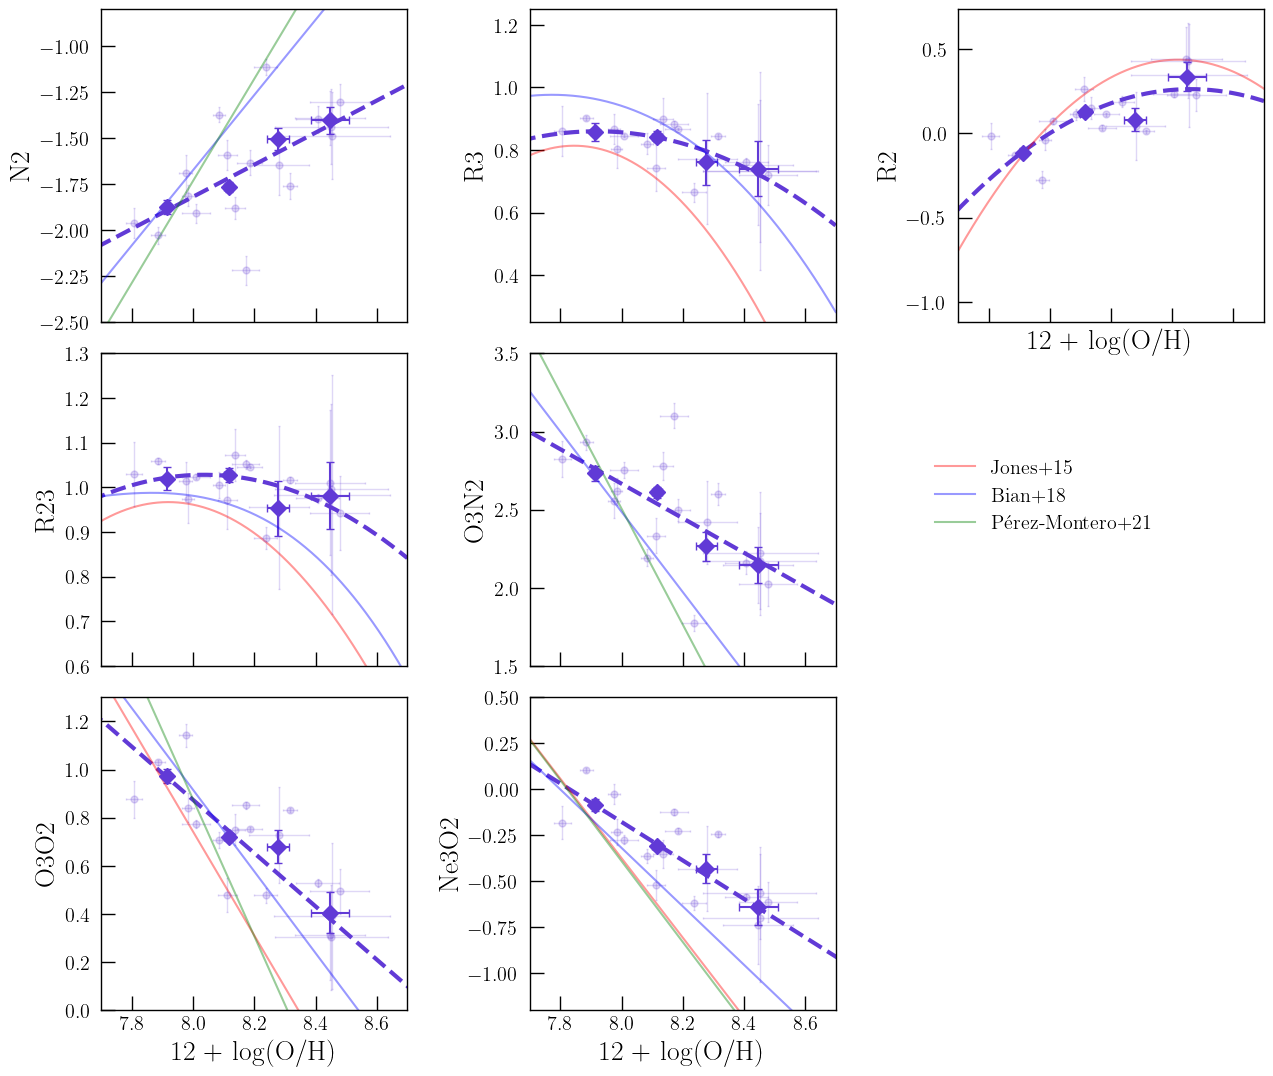

In [16]:
texPlot('on')
fig, axs = plt.subplots(3, 3, sharex=True)
fig.set_size_inches((15, 13))
fig.subplots_adjust(wspace=0.4, hspace=0.1)

# ===========================================================================================================
# N2
# ===========================================================================================================

axs[0, 0].errorbar(metals['log_OH'], upy.nominal_values(N2), xerr=metals['log_OH_err'], yerr=upy.std_devs(N2), 
                  marker='o', capsize=1, elinewidth=1, markersize=5, ls='', color=c[2], alpha=0.2)
axs[0, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 0].plot((N2_tp * out_N2_med.params['a1'].value) + out_N2_med.params['a0'].value, N2_tp,
               color=c[2], ls='--', lw=3)

axs[0, 0].plot(log_OH_tp, bian2018(log_OH_tp, 'N2'), label='Bian+2018', color='blue', alpha=0.4)
axs[0, 0].plot(log_OH_tp, perez_montero2021(log_OH_tp, 'N2'), label='Pérez-Montero+2021', color='green', alpha=0.4)
axs[0, 0].set_ylabel('N2')

# ===========================================================================================================
# R3
# ===========================================================================================================

axs[0, 1].errorbar(metals['log_OH'], upy.nominal_values(R3), xerr=metals['log_OH_err'], yerr=upy.std_devs(R3), 
                  marker='o', capsize=1, elinewidth=1, markersize=5, ls='', color=c[2], alpha=0.2)
axs[0, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R3),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_R3),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 1].plot(log_OH_tp, poly2(log_OH_tp, *out_R3_med), color=c[2], ls='--', lw=3)

axs[0, 1].plot(log_OH_tp, jones2015(log_OH_tp, 'R3'), label='Jones+2015', color='red', alpha=0.4)
axs[0, 1].plot(log_OH_tp, bian2018(log_OH_tp, 'R3'), label='Bian+2018', color='blue', alpha=0.4)
axs[0, 1].set_ylabel('R3')

# ===========================================================================================================
# R2
# ===========================================================================================================

axs[0, 2].errorbar(metals['log_OH'], upy.nominal_values(R2), xerr=metals['log_OH_err'], yerr=upy.std_devs(R2), 
                  marker='o', capsize=1, elinewidth=1, markersize=5, ls='', color=c[2], alpha=0.2)
axs[0, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_R2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 2].plot(log_OH_tp, poly2(log_OH_tp, *out_R2_med), color=c[2], ls='--', lw=3)

axs[0, 2].plot(log_OH_tp, jones2015(log_OH_tp, 'R2'), label='Jones+2015', color='red', alpha=0.4)
axs[0, 2].set_ylabel('R2')


# ===========================================================================================================
# R23
# ===========================================================================================================

axs[1, 0].errorbar(metals['log_OH'], upy.nominal_values(R23), xerr=metals['log_OH_err'], yerr=upy.std_devs(R23), 
                  marker='o', capsize=1, elinewidth=1, markersize=5, ls='', color=c[2], alpha=0.2)
axs[1, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R23),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_R23),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 0].plot(log_OH_tp, poly2(log_OH_tp, *out_R23_med), color=c[2], ls='--', lw=3)

axs[1, 0].plot(log_OH_tp, jones2015(log_OH_tp, 'R23'), label='Jones+2015', color='red', alpha=0.4)
axs[1, 0].plot(log_OH_tp, bian2018(log_OH_tp, 'R23'), label='Bian+2018', color='blue', alpha=0.4)
axs[1, 0].set_ylabel('R23')

# ===========================================================================================================
# O3N2
# ===========================================================================================================

axs[1, 1].errorbar(metals['log_OH'], upy.nominal_values(O3N2), xerr=metals['log_OH_err'], yerr=upy.std_devs(O3N2), 
                  marker='o', capsize=1, elinewidth=1, markersize=5, ls='', color=c[2], alpha=0.2)
axs[1, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3N2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_O3N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 1].plot((O3N2_tp * out_O3N2_med.params['a1'].value) + out_O3N2_med.params['a0'].value, O3N2_tp,
               color=c[2], ls='--', lw=3)

axs[1, 1].plot(log_OH_tp, bian2018(log_OH_tp, 'O3N2'), label='Bian+2018', color='blue', alpha=0.4)
axs[1, 1].plot(log_OH_tp, perez_montero2021(log_OH_tp, 'O3N2'), label='Pérez-Montero+2021', color='green', alpha=0.4)
axs[1, 1].set_ylabel('O3N2')


# ===========================================================================================================
# O3O2
# ===========================================================================================================

axs[2, 0].errorbar(metals['log_OH'], upy.nominal_values(O3O2), xerr=metals['log_OH_err'], yerr=upy.std_devs(O3O2), 
                  marker='o', capsize=1, elinewidth=1, markersize=5, ls='', color=c[2], alpha=0.2)
axs[2, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3O2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_O3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 0].plot((O3O2_tp * out_O3O2_med.params['a1'].value) + out_O3O2_med.params['a0'].value, O3O2_tp,
               color=c[2], ls='--', lw=3)

axs[2, 0].plot(log_OH_tp, jones2015(log_OH_tp, 'O3O2'), label='Jones+2015', color='red', alpha=0.4)
axs[2, 0].plot(log_OH_tp, bian2018(log_OH_tp, 'O3O2'), label='Bian+2018', color='blue', alpha=0.4)
axs[2, 0].plot(log_OH_tp, perez_montero2021(log_OH_tp, 'O3O2'), label='Pérez-Montero+2021', color='green', alpha=0.4)
axs[2, 0].set_ylabel('O3O2')

# ===========================================================================================================
# Ne3O2
# ===========================================================================================================

axs[2, 1].errorbar(metals['log_OH'], upy.nominal_values(Ne3O2), xerr=metals['log_OH_err'], yerr=upy.std_devs(Ne3O2), 
                  marker='o', capsize=1, elinewidth=1, markersize=5, ls='', color=c[2], alpha=0.2)
axs[2, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_Ne3O2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_Ne3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 1].plot((Ne3O2_tp * out_Ne3O2_med.params['a1'].value) + out_Ne3O2_med.params['a0'].value, Ne3O2_tp,
               color=c[2], ls='--', lw=3)

axs[2, 1].plot(log_OH_tp, jones2015(log_OH_tp, 'Ne3O2'), label='Jones+15', color='red', alpha=0.4)
axs[2, 1].plot(log_OH_tp, bian2018(log_OH_tp, 'Ne3O2'), label='Bian+18', color='blue', alpha=0.4)
axs[2, 1].plot(log_OH_tp, perez_montero2021(log_OH_tp, 'Ne3O2'), label='Pérez-Montero+21', color='green', alpha=0.4)
axs[2, 1].legend(frameon=False, loc=(1.3, 1.5))
axs[2, 1].set_ylabel('Ne3O2')


# ===========================================================================================================
# General settings
# ===========================================================================================================

axs[2, 0].set_xlabel(r'12 + log(O/H)')
axs[2, 1].set_xlabel(r'12 + log(O/H)')
axs[0, 2].set_xlabel(r'12 + log(O/H)')

# limits

# x
axs[0, 0].set_xlim(7.7, 8.7) # N2 (Shared)

# y
axs[0, 0].set_ylim(-2.5, -0.8) # N2
axs[0, 1].set_ylim(0.25, 1.25) # R3

axs[1, 0].set_ylim(0.6, 1.3) # R23
axs[1, 1].set_ylim(1.5, 3.5) # O3N2

axs[2, 0].set_ylim(0, 1.3) # O3O2
axs[2, 1].set_ylim(-1.2, 0.5) # Ne3O2

axs[1, 2].axis('off')
axs[2, 2].axis('off')

# Setting tick params

axs[0, 0].tick_params(axis="y", direction="in", length=10)
axs[0, 0].tick_params(axis="x", direction="in", length=10)

axs[0, 1].tick_params(axis="y", direction="in", length=10)
axs[0, 1].tick_params(axis="x", direction="in", length=10)

axs[0, 2].tick_params(axis="y", direction="in", length=10)
axs[0, 2].tick_params(axis="x", direction="in", length=10)

axs[1, 0].tick_params(axis="y", direction="in", length=10)
axs[1, 0].tick_params(axis="x", direction="in", length=10)

axs[1, 1].tick_params(axis="y", direction="in", length=10)
axs[1, 1].tick_params(axis="x", direction="in", length=10)


axs[2, 0].tick_params(axis="y", direction="in", length=10)
axs[2, 0].tick_params(axis="x", direction="in", length=10)

axs[2, 1].tick_params(axis="y", direction="in", length=10)
axs[2, 1].tick_params(axis="x", direction="in", length=10)
#fig.savefig(magePath+'analysis/chapter4/calbration_vs_analogs.pdf', bbox_inches='tight')

## Photoionization models

In [17]:
def dopita2016_N2S2(log_OH_12):
    N2S2 = (log_OH_12 - 8.77)
    return N2S2


def strom2018(log_OH_12, ratio='asd'):
    if ratio == 'R23':
        return - (((log_OH_12 - 8.24)**2) - 0.85) / 0.87
    if ratio == 'N2':
        return (log_OH_12 - 8.77) / 0.34
    if ratio == 'O3N2':
        return  - (log_OH_12 - 8.75) /0.21


def papovich2022_R23(log_OH_12):
    log_Z0 = 8.228
    log_R0 = 1.041
    A = -1.07
    return A * ((log_OH_12 - log_Z0)**2) + log_R0


def garg2023_z_0(SEL, ratio='asd'):
    if ratio == 'N2':
        a0 = -13.9
        a1 = 1.918
        a2 = -0.046
    if ratio == 'R3':
        a0 = -57.889
        a1 = 14.552
        a2 = -0.905
    if ratio == 'R2':
        a0 = -43.87
        a1 = 10.558
        a2 = -0.632
    if ratio == 'R23':
        a0 = -47.251
        a1 = 11.872
        a2 = -0.732
    if ratio == 'O3N2':
        a0 = -45.251
        a1 = 12.947
        a2 = -0.878
    if ratio == 'R3N2':
        a0 = -49.279
        a1 = 13.895
        a2 = -0.941
    if ratio == 'N2O2':
        a0 = 34.201
        a1 = -9.642
        a2 = 0.652
    if ratio == 'O3O2':
        a0 = -15.091
        a1 = 4.258
        a2 = -0.289
    if ratio == 'Ne3O2':
        a0 = 3.986
        a1 = -0.877
        a2 = 0.035
    if ratio == 'S2':
        a0 = -28.699
        a1 = 6.227
        a2 = -0.347
    if ratio == 'O3S2':
        a0 = -29.935
        a1 = 8.511
        a2 = -0.57
    if ratio == 'N2S2':
        a0 = 11.406
        a1 = -3.871
        a2 = 0.292
    return a0 + (a1 * SEL) + (a2 * (SEL**2))

def garg2023_z_2(SEL, ratio='asd'):
    if ratio == 'N2':
        a0 = 16.247
        a1 = -5.606
        a2 = 0.42
    if ratio == 'R3':
        a0 = -41.669
        a1 = 10.511
        a2 = -0.653
    if ratio == 'R2':
        a0 = -21.727
        a1 = 4.973
        a2 = -0.281
    if ratio == 'R23':
        a0 = -34.364
        a1 = 8.641
        a2 = -0.53
    if ratio == 'O3N2':
        a0 = -57.392
        a1 = 15.982
        a2 = -1.064
    if ratio == 'R3N2':
        a0 = -64.199
        a1 = 17.678
        a2 = -1.177
    if ratio == 'N2O2':
        a0 = 44.395
        a1 = -12.176
        a2 = 0.808
    if ratio == 'O3O2':
        a0 = -19.924
        a1 = 5.534
        a2 = -0.371
    if ratio == 'Ne3O2':
        a0 = -14.735
        a1 = 3.814
        a2 = -0.258
    if ratio == 'S2':
        a0 = -1.276
        a1 = -0.78
        a2 = 0.098
    if ratio == 'O3S2':
        a0 = -39.426
        a1 = 11.041
        a2 = -0.735
    if ratio == 'N2S2':
        a0 = 21.596
        a1 = -6.25
        a2 = 0.429
    return a0 + (a1 * SEL) + (a2 * (SEL**2))

def garg2023_z_5(SEL, ratio='asd'):
    if ratio == 'N2':
        a0 = 6.902
        a1 = -3.176
        a2 = 0.261
    if ratio == 'R3':
        a0 = -24.688
        a1 = 6.118
        a2 = -0.369
    if ratio == 'R2':
        a0 = -19.95
        a1 = 4.556
        a2 = -0.258
    if ratio == 'R23':
        a0 = -23.269
        a1 = 5.776
        a2 = -0.346
    if ratio == 'O3N2':
        a0 = -31.59
        a1 = 9.294
        a2 = -0.63
    if ratio == 'R3N2':
        a0 = -35.253
        a1 = 10.157
        a2 = -0.688
    if ratio == 'N2O2':
        a0 = 30.515
        a1 = -8.595
        a2 = 0.577
    if ratio == 'O3O2':
        a0 = -4.737
        a1 = 1.562
        a2 = -0.111
    if ratio == 'Ne3O2':
        a0 = -6.314
        a1 = 1.597
        a2 = -0.112
    if ratio == 'S2':
        a0 = -10.901
        a1 = 1.8
        a2 = -0.076
    if ratio == 'O3S2':
        a0 = -13.787
        a1 = 4.318
        a2 = -0.293
    if ratio == 'N2S2':
        a0 = 19.625
        a1 = -5.814
        a2 = 0.406
    return a0 + (a1 * SEL) + (a2 * (SEL**2))

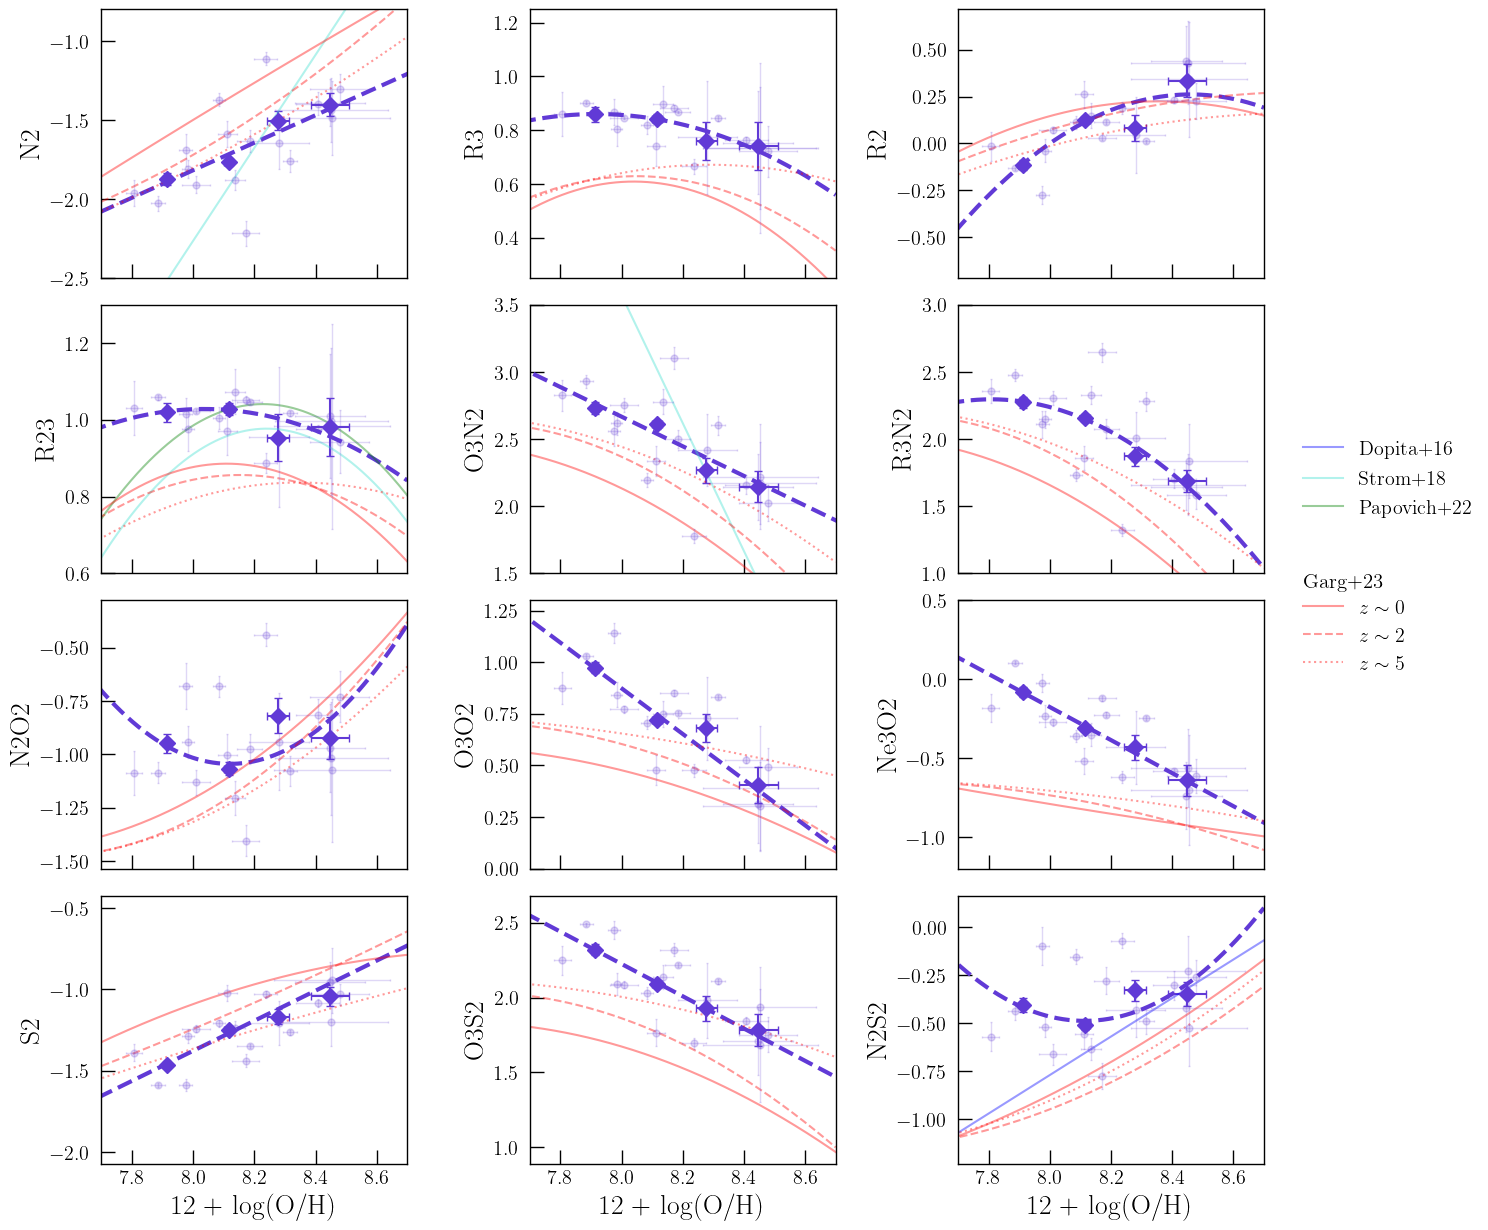

In [18]:
texPlot('on')
fig, axs = plt.subplots(4, 3, sharex=True)
fig.set_size_inches((15, 15))
fig.subplots_adjust(wspace=0.4, hspace=0.1)

# ===========================================================================================================
# N2
# ===========================================================================================================

axs[0, 0].errorbar(metals['log_OH'], upy.nominal_values(N2), xerr=metals['log_OH_err'], yerr=upy.std_devs(N2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 0].plot((N2_tp * out_N2_med.params['a1'].value) + out_N2_med.params['a0'].value, N2_tp,
               color=c[2], ls='--', lw=3)

axs[0, 0].plot(log_OH_tp, strom2018(log_OH_tp, 'N2'), color='turquoise', alpha=0.4)
axs[0, 0].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'N2'), label=r'$z \sim 0$', color='red', alpha=0.4)
axs[0, 0].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'N2'), label=r'$z \sim 2$', color='red', alpha=0.4, ls='--')
axs[0, 0].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'N2'), label=r'$z \sim 5$', color='red', alpha=0.4, ls=':')
axs[0, 0].set_ylabel('N2')

# ===========================================================================================================
# R3
# ===========================================================================================================

axs[0, 1].errorbar(metals['log_OH'], upy.nominal_values(R3), xerr=metals['log_OH_err'], yerr=upy.std_devs(R3), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R3),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_R3),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 1].plot(log_OH_tp, poly2(log_OH_tp, *out_R3_med), color=c[2], ls='--', lw=3)

axs[0, 1].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'R3'), color='red', alpha=0.4)
axs[0, 1].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'R3'), color='red', alpha=0.4, ls='--')
axs[0, 1].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'R3'), color='red', alpha=0.4, ls=':')
axs[0, 1].set_ylabel('R3')

# ===========================================================================================================
# R2
# ===========================================================================================================

axs[0, 2].errorbar(metals['log_OH'], upy.nominal_values(R2), xerr=metals['log_OH_err'], yerr=upy.std_devs(R2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_R2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 2].plot(log_OH_tp, poly2(log_OH_tp, *out_R2_med), color=c[2], ls='--', lw=3)

axs[0, 2].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'R2'), color='red', alpha=0.4)
axs[0, 2].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'R2'), color='red', alpha=0.4, ls='--')
axs[0, 2].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'R2'), color='red', alpha=0.4, ls=':')
axs[0, 2].set_ylabel('R2')


# ===========================================================================================================
# R23
# ===========================================================================================================

axs[1, 0].errorbar(metals['log_OH'], upy.nominal_values(R23), xerr=metals['log_OH_err'], yerr=upy.std_devs(R23), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[1, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R23),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_R23),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 0].plot(log_OH_tp, poly2(log_OH_tp, *out_R23_med), color=c[2], ls='--', lw=3)

axs[1, 0].plot(log_OH_tp, strom2018(log_OH_tp, 'R23'), label='Strom+18', color='turquoise', alpha=0.4)
axs[1, 0].plot(log_OH_tp, papovich2022_R23(log_OH_tp), label='Papovich+22', color='green', alpha=0.4)
axs[1, 0].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'R23'), color='red', alpha=0.4)
axs[1, 0].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'R23'), color='red', alpha=0.4, ls='--')
axs[1, 0].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'R23'), color='red', alpha=0.4, ls=':')
axs[1, 0].set_ylabel('R23')

# ===========================================================================================================
# O3N2
# ===========================================================================================================

axs[1, 1].errorbar(metals['log_OH'], upy.nominal_values(O3N2), xerr=metals['log_OH_err'], yerr=upy.std_devs(O3N2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[1, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3N2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_O3N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 1].plot((O3N2_tp * out_O3N2_med.params['a1'].value) + out_O3N2_med.params['a0'].value, O3N2_tp,
               color=c[2], ls='--', lw=3)

axs[1, 1].plot(log_OH_tp, strom2018(log_OH_tp, 'O3N2'), label='Strom+2018', color='turquoise', alpha=0.4)
axs[1, 1].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'O3N2'), color='red', alpha=0.4)
axs[1, 1].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'O3N2'), color='red', alpha=0.4, ls='--')
axs[1, 1].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'O3N2'), color='red', alpha=0.4, ls=':')
axs[1, 1].set_ylabel('O3N2')

# ===========================================================================================================
# R3N2
# ===========================================================================================================

axs[1, 2].errorbar(metals['log_OH'], upy.nominal_values(R3N2), xerr=metals['log_OH_err'], yerr=upy.std_devs(R3N2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[1, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R3N2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_R3N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 2].plot(log_OH_tp, poly2(log_OH_tp, *out_R3N2_med), color=c[2], ls='--', lw=3)

axs[1, 2].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'R3N2'), color='red', alpha=0.4)
axs[1, 2].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'R3N2'), color='red', alpha=0.4, ls='--')
axs[1, 2].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'R3N2'), color='red', alpha=0.4, ls=':')
axs[1, 2].set_ylabel('R3N2')


# ===========================================================================================================
# N2O2
# ===========================================================================================================

axs[2, 0].errorbar(metals['log_OH'], upy.nominal_values(N2O2), xerr=metals['log_OH_err'], yerr=upy.std_devs(N2O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[2, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2O2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_N2O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 0].plot(log_OH_tp, poly2(log_OH_tp, *out_N2O2_med), color=c[2], ls='--', lw=3)

axs[2, 0].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'N2O2'), color='red', alpha=0.4)
axs[2, 0].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'N2O2'), color='red', alpha=0.4, ls='--')
axs[2, 0].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'N2O2'), color='red', alpha=0.4, ls=':')
axs[2, 0].set_ylabel('N2O2')

# ===========================================================================================================
# O3O2
# ===========================================================================================================

axs[2, 1].errorbar(metals['log_OH'], upy.nominal_values(O3O2), xerr=metals['log_OH_err'], yerr=upy.std_devs(O3O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[2, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3O2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_O3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 1].plot((O3O2_tp * out_O3O2_med.params['a1'].value) + out_O3O2_med.params['a0'].value, O3O2_tp,
               color=c[2], ls='--', lw=3)

axs[2, 1].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'O3O2'), color='red', alpha=0.4)
axs[2, 1].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'O3O2'), color='red', alpha=0.4, ls='--')
axs[2, 1].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'O3O2'), color='red', alpha=0.4, ls=':')
axs[2, 1].set_ylabel('O3O2')

# ===========================================================================================================
# Ne3O2
# ===========================================================================================================

axs[2, 2].errorbar(metals['log_OH'], upy.nominal_values(Ne3O2), xerr=metals['log_OH_err'], yerr=upy.std_devs(Ne3O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[2, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_Ne3O2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_Ne3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 2].plot((Ne3O2_tp * out_Ne3O2_med.params['a1'].value) + out_Ne3O2_med.params['a0'].value, Ne3O2_tp,
               color=c[2], ls='--', lw=3)

axs[2, 2].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'Ne3O2'), color='red', alpha=0.4)
axs[2, 2].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'Ne3O2'), color='red', alpha=0.4, ls='--')
axs[2, 2].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'Ne3O2'), color='red', alpha=0.4, ls=':')
axs[2, 2].set_ylabel('Ne3O2')

# ===========================================================================================================
# S2
# ===========================================================================================================

axs[3, 0].errorbar(metals['log_OH'], upy.nominal_values(S2), xerr=metals['log_OH_err'], yerr=upy.std_devs(S2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[3, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_S2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_S2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[3, 0].plot((S2_tp * out_S2_med.params['a1'].value) + out_S2_med.params['a0'].value, S2_tp,
               color=c[2], ls='--', lw=3)

axs[3, 0].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'S2'), color='red', alpha=0.4)
axs[3, 0].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'S2'), color='red', alpha=0.4, ls='--')
axs[3, 0].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'S2'), color='red', alpha=0.4, ls=':')
axs[3, 0].set_ylabel('S2')

# ===========================================================================================================
# O3S2
# ===========================================================================================================

axs[3, 1].errorbar(metals['log_OH'], upy.nominal_values(O3S2), xerr=metals['log_OH_err'], yerr=upy.std_devs(O3S2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[3, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3S2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_O3S2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[3, 1].plot((O3S2_tp * out_O3S2_med.params['a1'].value) + out_O3S2_med.params['a0'].value, O3S2_tp,
               color=c[2], ls='--', lw=3)

axs[3, 1].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'O3S2'), color='red', alpha=0.4)
axs[3, 1].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'O3S2'), color='red', alpha=0.4, ls='--')
axs[3, 1].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'O3S2'), color='red', alpha=0.4, ls=':')
axs[3, 1].set_ylabel('O3S2')

# ===========================================================================================================
# N2S2
# ===========================================================================================================

axs[3, 2].errorbar(metals['log_OH'], upy.nominal_values(N2S2), xerr=metals['log_OH_err'], yerr=upy.std_devs(N2S2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[3, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2S2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_N2S2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[3, 2].plot(log_OH_tp, poly2(log_OH_tp, *out_N2S2_med), color=c[2], ls='--', lw=3)

axs[3, 2].plot(log_OH_tp, dopita2016_N2S2(log_OH_tp), label='Dopita+16', color='blue', alpha=0.4)
axs[3, 2].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'N2S2'), color='red', alpha=0.4)
axs[3, 2].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'N2S2'), color='red', alpha=0.4, ls='--')
axs[3, 2].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'N2S2'), color='red', alpha=0.4, ls=':')
axs[3, 2].set_ylabel('N2S2')

# ===========================================================================================================
# General settings
# ===========================================================================================================

axs[3, 0].set_xlabel(r'12 + log(O/H)')
axs[3, 1].set_xlabel(r'12 + log(O/H)')
axs[3, 2].set_xlabel(r'12 + log(O/H)')

# limits
# x
axs[0, 0].set_xlim(7.7, 8.7) 

# y
axs[0, 0].set_ylim(-2.5, -0.8) # N2
axs[0, 1].set_ylim(0.25, 1.25) # R3

axs[1, 0].set_ylim(0.6, 1.3) # R23
axs[1, 1].set_ylim(1.5, 3.5) # O3N2
axs[1, 2].set_ylim(1, 3) # R3N2

axs[2, 1].set_ylim(0, 1.3) # O3O2
axs[2, 2].set_ylim(-1.2, 0.5) # Ne3O2

# Legends
axs[0, 0].legend(frameon=False, loc=(3.9, -1.5))
axs[1, 0].legend(frameon=False, loc=(3.9, 0.18))
axs[1, 2].text(8.83, 0.9, 'Garg+23', fontsize=15)
axs[3, 2].legend(frameon=False, loc=(1.1, 2.6))

index_model = [0, 1, 2, 3]
index_sec = [0, 1, 2]
for i in index_model:
    for j in index_sec:
        axs[i, j].tick_params(axis="y", direction="in", length=10)
        axs[i, j].tick_params(axis="x", direction="in", length=10)
        
#fig.savefig(magePath+'analysis/chapter4/calbration_vs_models.pdf', bbox_inches='tight')

## Scatter and table of params

In [19]:
metal_array = upy.uarray(metals['log_OH'], metals['log_OH_err'])

# Linear predicts

N2_predict = out_N2_med.params['a0'].value + (bin_N2 * out_N2_med.params['a1'].value)
O3N2_predict = out_O3N2_med.params['a0'].value + (bin_O3N2 * out_O3N2_med.params['a1'].value)
O3O2_predict = out_O3O2_med.params['a0'].value + (bin_O3O2 * out_O3O2_med.params['a1'].value)
Ne3O2_predict = out_Ne3O2_med.params['a0'].value + (bin_Ne3O2 * out_Ne3O2_med.params['a1'].value)
S2_predict = out_S2_med.params['a0'].value + (bin_S2 * out_S2_med.params['a1'].value)
O3S2_predict = out_O3S2_med.params['a0'].value + (bin_O3S2 * out_O3S2_med.params['a1'].value)

# Non-linear predicts

R2_predict = poly2(bin_OH, *out_R2_med)
R3_predict = poly2(bin_OH, *out_R3_med)
R23_predict = poly2(bin_OH, *out_R23_med)
R3N2_predict = poly2(bin_OH, *out_R3N2_med)
N2O2_predict = poly2(bin_OH, *out_N2O2_med)
N2S2_predict = poly2(bin_OH, *out_N2S2_med)

In [20]:
# Scatters

sigma_N2 = np.std(upy.nominal_values((N2_predict - bin_OH)))
sigma_O3N2 = np.std(upy.nominal_values((O3N2_predict - bin_OH)))
sigma_O3O2 = np.std(upy.nominal_values((O3O2_predict - bin_OH)))
sigma_Ne3O2 = np.std(upy.nominal_values((Ne3O2_predict - bin_OH)))
sigma_S2 = np.std(upy.nominal_values((S2_predict - bin_OH)))
sigma_O3S2 = np.std(upy.nominal_values((O3S2_predict - bin_OH)))

sigma_R2 = np.std(upy.nominal_values(R2_predict - bin_R2))
sigma_R3 = np.std(upy.nominal_values(R3_predict - bin_R3))
sigma_R23 = np.std(upy.nominal_values(R23_predict - bin_R23))
sigma_R3N2 = np.std(upy.nominal_values(R3N2_predict - bin_R3N2))
sigma_N2O2 = np.std(upy.nominal_values(N2O2_predict - bin_N2O2))
sigma_N2S2 = np.std(upy.nominal_values(N2S2_predict - bin_N2S2))

In [21]:
calib_dict = {'Ratio': ['N2', 'R2', 'R3', 'R23', 'O3N2', 'R3N2', 'N2O2', 'O3O2', 'Ne3O2', 'S2', 'O3S2', 'N2S2'],
             'a0': [out_N2_med.params['a0'].value, out_R2_med[0], out_R3_med[0], out_R23_med[0],
                    out_O3N2_med.params['a0'].value, out_R3N2_med[0], out_N2O2_med[0],
                    out_O3O2_med.params['a0'].value, out_Ne3O2_med.params['a0'].value, out_S2_med.params['a0'].value,
                    out_O3S2_med.params['a0'].value, out_N2S2_med[0]],
             'a1': [out_N2_med.params['a1'].value, out_R2_med[1], out_R3_med[1], out_R23_med[1],
                    out_O3N2_med.params['a1'].value, out_R3N2_med[1], out_N2O2_med[1],
                    out_O3O2_med.params['a1'].value, out_Ne3O2_med.params['a1'].value, out_S2_med.params['a1'].value,
                    out_O3S2_med.params['a1'].value, out_N2S2_med[1]],
             'a2': [None, out_R2_med[2], out_R3_med[2], out_R23_med[2],
                    None, out_R3N2_med[2], out_N2O2_med[2],
                    None, None, None,
                    None, out_N2S2_med[2]],
              'sigma': [sigma_N2, sigma_R2, sigma_R3, sigma_R23, sigma_O3N2, sigma_R3N2,
                        sigma_N2O2, sigma_O3O2, sigma_Ne3O2, sigma_S2, sigma_O3S2, sigma_N2S2]
}

calib_dict_pd = pd.DataFrame(data=calib_dict, index=None)
calib_dict_pd.to_latex(index=None, float_format='%.3f')

'\\begin{tabular}{llrrrr}\n\\toprule\n & Ratio & a0 & a1 & a2 & sigma \\\\\n\\midrule\n0 & N2 & 10.090 & 1.149 & NaN & 0.050 \\\\\n1 & R2 & -88.104 & 20.889 & -1.235 & 0.078 \\\\\n2 & R3 & -30.024 & 7.801 & -0.493 & 0.020 \\\\\n3 & R23 & -26.215 & 6.781 & -0.422 & 0.027 \\\\\n4 & O3N2 & 10.418 & -0.907 & NaN & 0.054 \\\\\n5 & R3N2 & -94.409 & 24.767 & -1.586 & 0.042 \\\\\n6 & N2O2 & 127.138 & -31.572 & 1.944 & 0.097 \\\\\n7 & O3O2 & 8.790 & -0.905 & NaN & 0.047 \\\\\n8 & Ne3O2 & 7.831 & -0.957 & NaN & 0.016 \\\\\n9 & S2 & 9.492 & 1.083 & NaN & 0.042 \\\\\n10 & O3S2 & 10.061 & -0.926 & NaN & 0.018 \\\\\n11 & N2S2 & 112.162 & -27.766 & 1.711 & 0.061 \\\\\n\\bottomrule\n\\end{tabular}\n'

### Local relations predictions

In [22]:
# ===========================================================================================================
# N2
# ===========================================================================================================

OH_from_N2_denicolo = (upy.nominal_values(bin_N2) * 0.73) + 9.12
OH_from_N2_marino = (upy.nominal_values(bin_N2) * 0.462) + 8.743
OH_from_N2_PP = pettini_pagel2004_N2(upy.nominal_values(bin_N2))
N2_from_OH_nagao = nagao2006(upy.nominal_values(bin_OH), ratio='N2')
N2_from_OH_maiolino = maiolino2008(upy.nominal_values(bin_OH), ratio='N2')
N2_from_OH_curti = curti2020(upy.nominal_values(bin_OH), ratio='N2')
N2_from_OH_sanders = sanders2021(upy.nominal_values(bin_OH), ratio='N2')

N2_labels = np.array(['Denicolo', 'Marino', 'Pettini', 'Nagao', 'Maiolino', 'Curti', 'Sanders'])
N2_scatters = np.array([np.mean(OH_from_N2_denicolo - upy.nominal_values(bin_OH)),
                        np.mean(OH_from_N2_marino - upy.nominal_values(bin_OH)),
                        np.mean(OH_from_N2_PP - upy.nominal_values(bin_OH)),
                        np.mean(N2_from_OH_nagao - upy.nominal_values(bin_N2)),
                        np.mean(N2_from_OH_maiolino - upy.nominal_values(bin_N2)),
                        np.mean(N2_from_OH_curti - upy.nominal_values(bin_N2)),
                        np.mean(N2_from_OH_sanders - upy.nominal_values(bin_N2)),
])

# ===========================================================================================================
# R2
# ===========================================================================================================

R2_from_OH_maiolino = maiolino2008(upy.nominal_values(bin_OH), ratio='R2')
R2_from_OH_curti = curti2020(upy.nominal_values(bin_OH), ratio='R2')
R2_from_OH_sanders = sanders2021(upy.nominal_values(bin_OH), ratio='R2')

R2_labels = np.array(['Maiolino', 'Curti', 'Sanders'])
R2_scatters = np.array([np.mean(R2_from_OH_maiolino - upy.nominal_values(bin_R2)),
                        np.mean(R2_from_OH_curti - upy.nominal_values(bin_R2)),
                        np.mean(R2_from_OH_sanders - upy.nominal_values(bin_R2))
])

# ===========================================================================================================
# R3
# ===========================================================================================================

R3_from_OH_maiolino = maiolino2008(upy.nominal_values(bin_OH), ratio='R3')
R3_from_OH_curti = curti2020(upy.nominal_values(bin_OH), ratio='R3')
R3_from_OH_sanders = sanders2021(upy.nominal_values(bin_OH), ratio='R3')

R3_labels = np.array(['Maiolino', 'Curti', 'Sanders'])
R3_scatters = np.array([np.mean(R3_from_OH_maiolino - upy.nominal_values(bin_R3)),
                        np.mean(R3_from_OH_curti - upy.nominal_values(bin_R3)),
                        np.mean(R3_from_OH_sanders - upy.nominal_values(bin_R3))
])

# ===========================================================================================================
# R23
# ===========================================================================================================

OH_from_R23_tremonti = tremonti2004_R23(upy.nominal_values(bin_R23))
R23_from_OH_nagao = nagao2006(upy.nominal_values(bin_OH), ratio='R23')
R23_from_OH_maiolino = maiolino2008(upy.nominal_values(bin_OH), ratio='R23')
R23_from_OH_curti = curti2020(upy.nominal_values(bin_OH), ratio='R23')
R23_from_OH_sanders = sanders2021(upy.nominal_values(bin_OH), ratio='R23')

R23_labels = np.array(['Tremonti', 'Nagao', 'Maiolino', 'Curti', 'Sanders'])
R23_scatters = np.array([np.mean(OH_from_R23_tremonti - upy.nominal_values(bin_OH)),
                         np.mean(R23_from_OH_nagao - upy.nominal_values(bin_R23)),
                         np.mean(R23_from_OH_maiolino - upy.nominal_values(bin_R23)),
                         np.mean(R23_from_OH_curti - upy.nominal_values(bin_R23)),
                         np.mean(R23_from_OH_sanders - upy.nominal_values(bin_R23)),
])

# ===========================================================================================================
# R3N2
# ===========================================================================================================

R3N2_from_OH_nagao = nagao2006(upy.nominal_values(bin_OH), ratio='R3N2')
R3N2_from_OH_maiolino = maiolino2008(upy.nominal_values(bin_OH), ratio='R3N2')

R3N2_labels = np.array(['Nagao', 'Maiolino'])
R3N2_scatters = np.array([np.mean(R3N2_from_OH_nagao - upy.nominal_values(bin_R3N2)),
                          np.mean(R3N2_from_OH_maiolino - upy.nominal_values(bin_R3N2))
])

# ===========================================================================================================
# O3N2
# ===========================================================================================================

OH_from_O3N2_PP = (upy.nominal_values(bin_O3N2) * -0.32) + 8.73
OH_from_O3N2_marino = (upy.nominal_values(bin_O3N2) * -0.214) + 8.533
O3N2_from_OH_curti = curti2020(upy.nominal_values(bin_OH), ratio='O3N2')
O3N2_from_OH_sanders = sanders2021(upy.nominal_values(bin_OH), ratio='O3N2')

O3N2_labels = np.array(['Pettini', 'Marino', 'Curti', 'Sanders'])
O3N2_scatters = np.array([np.mean(OH_from_O3N2_PP - upy.nominal_values(bin_OH)),
                          np.mean(OH_from_O3N2_marino - upy.nominal_values(bin_OH)),
                          np.mean(O3N2_from_OH_curti - upy.nominal_values(bin_O3N2)),
                          np.mean(O3N2_from_OH_sanders - upy.nominal_values(bin_O3N2))
])

# ===========================================================================================================
# N2O2
# ===========================================================================================================

N2O2_from_OH_nagao = nagao2006(upy.nominal_values(bin_OH), ratio='N2O2')

N2O2_scatters = np.mean(N2O2_from_OH_nagao - upy.nominal_values(bin_N2O2))

# ===========================================================================================================
# O3O2
# ===========================================================================================================

O3O2_from_OH_nagao = nagao2006(upy.nominal_values(bin_OH), ratio='O3O2')
O3O2_from_OH_maiolino = maiolino2008(upy.nominal_values(bin_OH), ratio='O3O2')
O3O2_from_OH_curti = curti2020(upy.nominal_values(bin_OH), ratio='O3O2')
O3O2_from_OH_sanders = sanders2021(upy.nominal_values(bin_OH), ratio='O3O2')

O3O2_labels = np.array(['Nagao', 'Maiolino', 'Curti', 'Sanders'])
O3O2_scatters = np.array([np.mean(O3O2_from_OH_nagao - upy.nominal_values(bin_O3O2)),
                        np.mean(O3O2_from_OH_maiolino - upy.nominal_values(bin_O3O2)),
                        np.mean(O3O2_from_OH_curti - upy.nominal_values(bin_O3O2)),
                        np.mean(O3O2_from_OH_sanders - upy.nominal_values(bin_O3O2)),
])

# ===========================================================================================================
# Ne3O2
# ===========================================================================================================

Ne3O2_from_OH_maiolino = maiolino2008(upy.nominal_values(bin_OH), ratio='Ne3O2')

Ne3O2_scatters = np.mean(Ne3O2_from_OH_maiolino - upy.nominal_values(bin_Ne3O2))

In [23]:
print('Best local N2 relation: ', N2_labels[np.argmin(N2_scatters)], 'with sigma =',
      round(np.abs(N2_scatters[np.argmin(N2_scatters)]), 3))
print('Best local R2 relation: ', R2_labels[np.argmin(R2_scatters)], 'with sigma =',
      round(np.abs(R2_scatters[np.argmin(R2_scatters)]), 3))
print('Best local R3 relation: ', R3_labels[np.argmin(R3_scatters)], 'with sigma =',
      round(np.abs(R3_scatters[np.argmin(R3_scatters)]), 3))
print('Best local R23 relation: ', R23_labels[np.argmin(R23_scatters)], 'with sigma =',
      round(np.abs(R23_scatters[np.argmin(R23_scatters)]), 3))
print('Best local O3N2 relation: ', O3N2_labels[np.argmin(O3N2_scatters)], 'with sigma =',
      round(np.abs(O3N2_scatters[np.argmin(O3N2_scatters)]), 3))
print('Best local R3N2 relation: ', R3N2_labels[np.argmin(R3N2_scatters)], 'with sigma =',
      round(np.abs(R3N2_scatters[np.argmin(R3N2_scatters)]), 3))
print('Only local N2O2 relation: ', 'Nagao', 'with sigma =', 
     round(np.abs(N2O2_scatters), 3))
print('Best local O3O2 relation: ', O3O2_labels[np.argmin(O3O2_scatters)], 'with sigma =',
      round(np.abs(O3O2_scatters[np.argmin(O3O2_scatters)]), 3))
print('Only local Ne3O2 relation: ', 'Maiolino', 'with sigma =', 
     round(np.abs(Ne3O2_scatters), 3))

Best local N2 relation:  Denicolo with sigma = 0.264
Best local R2 relation:  Curti with sigma = 0.143
Best local R3 relation:  Sanders with sigma = 0.262
Best local R23 relation:  Sanders with sigma = 0.184
Best local O3N2 relation:  Sanders with sigma = 0.609
Best local R3N2 relation:  Nagao with sigma = 0.611
Only local N2O2 relation:  Nagao with sigma = 0.25
Best local O3O2 relation:  Sanders with sigma = 0.488
Only local Ne3O2 relation:  Maiolino with sigma = 0.394


### Other analogs predictions

In [24]:
# ===========================================================================================================
# N2
# ===========================================================================================================

OH_from_N2_pm = (upy.nominal_values(bin_N2) * 0.361) + 8.625
OH_from_N2_bian = (upy.nominal_values(bin_N2) * 0.49) + 8.82

N2_an_labels = np.array(['Perez-Montero', 'Bian'])
N2_an_scatters = np.array([np.mean(OH_from_N2_pm - upy.nominal_values(bin_OH)),
                        np.mean(OH_from_N2_bian - upy.nominal_values(bin_OH))
])

# ===========================================================================================================
# R2
# ===========================================================================================================

R2_from_OH_jones = jones2015(upy.nominal_values(bin_OH), ratio='R2')

R2_an_labels = np.array(['Jones'])
R2_an_scatters = np.array([np.mean(R2_from_OH_jones - upy.nominal_values(bin_R2))
])

# ===========================================================================================================
# R3
# ===========================================================================================================

R3_from_OH_bian = bian2018(upy.nominal_values(bin_OH), ratio='R3')
R3_from_OH_jones = jones2015(upy.nominal_values(bin_OH), ratio='R3')

R3_an_labels = np.array(['Bian', 'Jones'])
R3_an_scatters = np.array([np.mean(R3_from_OH_bian - upy.nominal_values(bin_R3)),
                        np.mean(R3_from_OH_jones - upy.nominal_values(bin_R3))
])

# ===========================================================================================================
# R23
# ===========================================================================================================

R23_from_OH_bian = bian2018(upy.nominal_values(bin_OH), ratio='R23')
R23_from_OH_jones = jones2015(upy.nominal_values(bin_OH), ratio='R23')

R23_an_labels = np.array(['Bian', 'Jones'])
R23_an_scatters = np.array([np.mean(R23_from_OH_bian - upy.nominal_values(bin_R23)),
                        np.mean(R23_from_OH_jones - upy.nominal_values(bin_R23))
])

# ===========================================================================================================
# O3N2
# ===========================================================================================================

OH_from_O3N2_pm = (upy.nominal_values(bin_O3N2) * -0.27) + 8.677
OH_from_O3N2_bian = (upy.nominal_values(bin_O3N2) * -0.39) + 8.97

O3N2_an_labels = np.array(['Perez-Montero', 'Bian'])
O3N2_an_scatters = np.array([np.mean(OH_from_O3N2_pm - upy.nominal_values(bin_OH)),
                        np.mean(OH_from_O3N2_bian - upy.nominal_values(bin_OH))
])

# ===========================================================================================================
# O3O2
# ===========================================================================================================

OH_from_O3O2_pm = (upy.nominal_values(bin_O3O2) * -0.352) + 8.308
OH_from_O3O2_bian = (upy.nominal_values(bin_O3O2) * -0.59) + 8.54
OH_from_O3O2_jones = (upy.nominal_values(bin_O3O2) - 17.9828) / -2.1552

O3O2_an_labels = np.array(['Perez-Montero', 'Bian', 'Jones'])
O3O2_an_scatters = np.array([np.mean(OH_from_O3O2_pm - upy.nominal_values(bin_OH)),
                          np.mean(OH_from_O3O2_bian - upy.nominal_values(bin_OH)),
                          np.mean(OH_from_O3O2_jones - upy.nominal_values(bin_OH))
])

# ===========================================================================================================
# Ne3O2
# ===========================================================================================================

OH_from_Ne3O2_pm = (upy.nominal_values(bin_Ne3O2) * -0.455) + 7.823
OH_from_Ne3O2_bian = (upy.nominal_values(bin_Ne3O2) * -0.63) + 7.8
OH_from_Ne3O2_jones = (upy.nominal_values(bin_O3O2) - 16.8974) / -2.1588

Ne3O2_an_labels = np.array(['Perez-Montero', 'Bian', 'Jones'])
Ne3O2_an_scatters = np.array([np.mean(OH_from_Ne3O2_pm - upy.nominal_values(bin_OH)),
                          np.mean(OH_from_Ne3O2_bian - upy.nominal_values(bin_OH)),
                          np.mean(OH_from_Ne3O2_jones - upy.nominal_values(bin_OH))
])

In [25]:
print('Best analogs N2 relation: ', N2_an_labels[np.argmin(N2_an_scatters)], 'with sigma =',
      round(np.abs(N2_an_scatters[np.argmin(N2_an_scatters)]), 3))
print('Best analogs R2 relation: ', R2_an_labels[np.argmin(R2_an_scatters)], 'with sigma =',
      round(np.abs(R2_an_scatters[np.argmin(R2_an_scatters)]), 3))
print('Only analogs R3 relation: ', R3_an_labels[np.argmin(R3_an_scatters)], 'with sigma =',
      round(np.abs(R3_an_scatters[np.argmin(R3_an_scatters)]), 3))
print('Best analogs R23 relation: ', R23_an_labels[np.argmin(R23_an_scatters)], 'with sigma =',
      round(np.abs(R23_an_scatters[np.argmin(R23_an_scatters)]), 3))
print('Best analogs O3N2 relation: ', O3N2_an_labels[np.argmin(O3N2_an_scatters)], 'with sigma =',
      round(np.abs(O3N2_an_scatters[np.argmin(O3N2_an_scatters)]), 3))
print('Best analogs O3O2 relation: ', O3O2_an_labels[np.argmin(O3O2_an_scatters)], 'with sigma =',
      round(np.abs(O3O2_an_scatters[np.argmin(O3O2_an_scatters)]), 3))
print('Best analogs Ne3O2 relation: ', Ne3O2_an_labels[np.argmin(Ne3O2_an_scatters)], 'with sigma =',
      round(np.abs(Ne3O2_an_scatters[np.argmin(Ne3O2_an_scatters)]), 3))

Best analogs N2 relation:  Bian with sigma = 0.171
Best analogs R2 relation:  Jones with sigma = 0.128
Only analogs R3 relation:  Jones with sigma = 0.214
Best analogs R23 relation:  Jones with sigma = 0.127
Best analogs O3N2 relation:  Perez-Montero with sigma = 0.17
Best analogs O3O2 relation:  Jones with sigma = 0.167
Best analogs Ne3O2 relation:  Jones with sigma = 0.683


### Models predictions

In [26]:
# ===========================================================================================================
# N2
# ===========================================================================================================

OH_from_N2_strom = (upy.nominal_values(bin_N2) * 0.34) + 8.77
N2_from_OH_garg0 = garg2023_z_0(upy.nominal_values(bin_OH), ratio='N2')
N2_from_OH_garg2 = garg2023_z_2(upy.nominal_values(bin_OH), ratio='N2')
N2_from_OH_garg5 = garg2023_z_5(upy.nominal_values(bin_OH), ratio='N2')

N2_mod_labels = np.array(['Strom', 'Garg z=0', 'Garg z=2', 'Garg z=5'])
N2_mod_scatters = np.array([np.mean(OH_from_N2_strom - upy.nominal_values(bin_OH)),
                            np.mean(N2_from_OH_garg0 - upy.nominal_values(bin_N2)),
                            np.mean(N2_from_OH_garg2 - upy.nominal_values(bin_N2)),
                            np.mean(N2_from_OH_garg5 - upy.nominal_values(bin_N2))
])

# ===========================================================================================================
# R2
# ===========================================================================================================

R2_from_OH_garg0 = garg2023_z_0(upy.nominal_values(bin_OH), ratio='R2')
R2_from_OH_garg2 = garg2023_z_2(upy.nominal_values(bin_OH), ratio='R2')
R2_from_OH_garg5 = garg2023_z_5(upy.nominal_values(bin_OH), ratio='R2')

R2_mod_labels = np.array(['Garg z=0', 'Garg z=2', 'Garg z=5'])
R2_mod_scatters = np.array([np.mean(R2_from_OH_garg0 - upy.nominal_values(bin_R2)),
                            np.mean(R2_from_OH_garg2 - upy.nominal_values(bin_R2)),
                            np.mean(R2_from_OH_garg5 - upy.nominal_values(bin_R2))
])

# ===========================================================================================================
# R3
# ===========================================================================================================


R3_from_OH_garg0 = garg2023_z_0(upy.nominal_values(bin_OH), ratio='R3')
R3_from_OH_garg2 = garg2023_z_2(upy.nominal_values(bin_OH), ratio='R3')
R3_from_OH_garg5 = garg2023_z_5(upy.nominal_values(bin_OH), ratio='R3')

R3_mod_labels = np.array(['Garg z=0', 'Garg z=2', 'Garg z=5'])
R3_mod_scatters = np.array([np.mean(R3_from_OH_garg0 - upy.nominal_values(bin_R3)),
                            np.mean(R3_from_OH_garg2 - upy.nominal_values(bin_R3)),
                            np.mean(R3_from_OH_garg5 - upy.nominal_values(bin_R3))
])

# ===========================================================================================================
# R23
# ===========================================================================================================

R23_from_OH_strom = strom2018(upy.nominal_values(bin_OH), ratio='R23')
OH_from_R23_papovich = np.sqrt((upy.nominal_values(bin_R23) - 1.041) / -1.07) + 8.228
R23_from_OH_garg0 = garg2023_z_0(upy.nominal_values(bin_OH), ratio='R23')
R23_from_OH_garg2 = garg2023_z_2(upy.nominal_values(bin_OH), ratio='R23')
R23_from_OH_garg5 = garg2023_z_5(upy.nominal_values(bin_OH), ratio='R23')

R23_mod_labels = np.array(['Strom', 'Papovich', 'Garg z=0', 'Garg z=2', 'Garg z=5'])
R23_mod_scatters = np.array([np.mean(R23_from_OH_strom - upy.nominal_values(bin_R23)),
                             np.mean(OH_from_R23_papovich - upy.nominal_values(bin_OH)),
                             np.mean(R23_from_OH_garg0 - upy.nominal_values(bin_R23)),
                             np.mean(R23_from_OH_garg2 - upy.nominal_values(bin_R23)),
                             np.mean(R23_from_OH_garg5 - upy.nominal_values(bin_R23))
])

# ===========================================================================================================
# O3N2
# ===========================================================================================================

OH_from_O3N2_strom = (upy.nominal_values(bin_O3N2) * -0.21) + 8.75
O3N2_from_OH_garg0 = garg2023_z_0(upy.nominal_values(bin_OH), ratio='O3N2')
O3N2_from_OH_garg2 = garg2023_z_2(upy.nominal_values(bin_OH), ratio='O3N2')
O3N2_from_OH_garg5 = garg2023_z_5(upy.nominal_values(bin_OH), ratio='O3N2')

O3N2_mod_labels = np.array(['Strom', 'Garg z=0', 'Garg z=2', 'Garg z=5'])
O3N2_mod_scatters = np.array([np.mean(OH_from_O3N2_strom - upy.nominal_values(bin_OH)),
                              np.mean(O3N2_from_OH_garg0 - upy.nominal_values(bin_O3N2)),
                              np.mean(O3N2_from_OH_garg2 - upy.nominal_values(bin_O3N2)),
                              np.mean(O3N2_from_OH_garg5 - upy.nominal_values(bin_O3N2))
])

# ===========================================================================================================
# R3N2
# ===========================================================================================================

R3N2_from_OH_garg0 = garg2023_z_0(upy.nominal_values(bin_OH), ratio='R3N2')
R3N2_from_OH_garg2 = garg2023_z_2(upy.nominal_values(bin_OH), ratio='R3N2')
R3N2_from_OH_garg5 = garg2023_z_5(upy.nominal_values(bin_OH), ratio='R3N2')

R3N2_mod_labels = np.array(['Garg z=0', 'Garg z=2', 'Garg z=5'])
R3N2_mod_scatters = np.array([np.mean(R3N2_from_OH_garg0 - upy.nominal_values(bin_R3N2)),
                              np.mean(R3N2_from_OH_garg2 - upy.nominal_values(bin_R3N2)),
                              np.mean(R3N2_from_OH_garg5 - upy.nominal_values(bin_R3N2))
])

# ===========================================================================================================
# N2O2
# ===========================================================================================================

N2O2_from_OH_garg0 = garg2023_z_0(upy.nominal_values(bin_OH), ratio='N2O2')
N2O2_from_OH_garg2 = garg2023_z_2(upy.nominal_values(bin_OH), ratio='N2O2')
N2O2_from_OH_garg5 = garg2023_z_5(upy.nominal_values(bin_OH), ratio='N2O2')

N2O2_mod_labels = np.array(['Garg z=0', 'Garg z=2', 'Garg z=5'])
N2O2_mod_scatters = np.array([np.mean(N2O2_from_OH_garg0 - upy.nominal_values(bin_N2O2)),
                              np.mean(N2O2_from_OH_garg2 - upy.nominal_values(bin_N2O2)),
                              np.mean(N2O2_from_OH_garg5 - upy.nominal_values(bin_N2O2))
])

# ===========================================================================================================
# O3O2
# ===========================================================================================================

O3O2_from_OH_garg0 = garg2023_z_0(upy.nominal_values(bin_OH), ratio='O3O2')
O3O2_from_OH_garg2 = garg2023_z_2(upy.nominal_values(bin_OH), ratio='O3O2')
O3O2_from_OH_garg5 = garg2023_z_5(upy.nominal_values(bin_OH), ratio='O3O2')

O3O2_mod_labels = np.array(['Garg z=0', 'Garg z=2', 'Garg z=5'])
O3O2_mod_scatters = np.array([np.mean(O3O2_from_OH_garg0 - upy.nominal_values(bin_O3O2)),
                              np.mean(O3O2_from_OH_garg2 - upy.nominal_values(bin_O3O2)),
                              np.mean(O3O2_from_OH_garg5 - upy.nominal_values(bin_O3O2))
])

# ===========================================================================================================
# Ne3O2
# ===========================================================================================================

Ne3O2_from_OH_garg0 = garg2023_z_0(upy.nominal_values(bin_OH), ratio='Ne3O2')
Ne3O2_from_OH_garg2 = garg2023_z_2(upy.nominal_values(bin_OH), ratio='Ne3O2')
Ne3O2_from_OH_garg5 = garg2023_z_5(upy.nominal_values(bin_OH), ratio='Ne3O2')

Ne3O2_mod_labels = np.array(['Garg z=0', 'Garg z=2', 'Garg z=5'])
Ne3O2_mod_scatters = np.array([np.mean(Ne3O2_from_OH_garg0 - upy.nominal_values(bin_Ne3O2)),
                               np.mean(Ne3O2_from_OH_garg2 - upy.nominal_values(bin_Ne3O2)),
                               np.mean(Ne3O2_from_OH_garg5 - upy.nominal_values(bin_Ne3O2))
])

# ===========================================================================================================
# S2
# ===========================================================================================================

S2_from_OH_garg0 = garg2023_z_0(upy.nominal_values(bin_OH), ratio='S2')
S2_from_OH_garg2 = garg2023_z_2(upy.nominal_values(bin_OH), ratio='S2')
S2_from_OH_garg5 = garg2023_z_5(upy.nominal_values(bin_OH), ratio='S2')

S2_mod_labels = np.array(['Garg z=0', 'Garg z=2', 'Garg z=5'])
S2_mod_scatters = np.array([np.mean(S2_from_OH_garg0 - upy.nominal_values(bin_S2)),
                            np.mean(S2_from_OH_garg2 - upy.nominal_values(bin_S2)),
                            np.mean(S2_from_OH_garg5 - upy.nominal_values(bin_S2))
])

# ===========================================================================================================
# O3S2
# ===========================================================================================================

O3S2_from_OH_garg0 = garg2023_z_0(upy.nominal_values(bin_OH), ratio='O3S2')
O3S2_from_OH_garg2 = garg2023_z_2(upy.nominal_values(bin_OH), ratio='O3S2')
O3S2_from_OH_garg5 = garg2023_z_5(upy.nominal_values(bin_OH), ratio='O3S2')

O3S2_mod_labels = np.array(['Garg z=0', 'Garg z=2', 'Garg z=5'])
O3S2_mod_scatters = np.array([np.mean(O3S2_from_OH_garg0 - upy.nominal_values(bin_O3S2)),
                              np.mean(O3S2_from_OH_garg2 - upy.nominal_values(bin_O3S2)),
                              np.mean(O3S2_from_OH_garg5 - upy.nominal_values(bin_O3S2))
])

# ===========================================================================================================
# N2S2
# ===========================================================================================================

OH_from_N2S2_dopita = upy.nominal_values(bin_N2) + 8.77
N2S2_from_OH_garg0 = garg2023_z_0(upy.nominal_values(bin_OH), ratio='N2S2')
N2S2_from_OH_garg2 = garg2023_z_2(upy.nominal_values(bin_OH), ratio='N2S2')
N2S2_from_OH_garg5 = garg2023_z_5(upy.nominal_values(bin_OH), ratio='N2S2')

N2S2_mod_labels = np.array(['Dopita', 'Garg z=0', 'Garg z=2', 'Garg z=5'])
N2S2_mod_scatters = np.array([np.mean(N2S2_from_OH_garg0 - upy.nominal_values(bin_N2S2)),
                              np.mean(N2S2_from_OH_garg2 - upy.nominal_values(bin_N2S2)),
                              np.mean(N2S2_from_OH_garg5 - upy.nominal_values(bin_N2S2))
])

In [27]:
print('Best models N2 relation: ', N2_mod_labels[np.argmin(N2_mod_scatters)], 'with sigma =',
      round(np.abs(N2_mod_scatters[np.argmin(N2_mod_scatters)]), 3))
print('Best models R2 relation: ', R2_mod_labels[np.argmin(R2_mod_scatters)], 'with sigma =',
      round(np.abs(R2_mod_scatters[np.argmin(R2_mod_scatters)]), 3))
print('Best models R3 relation: ', R3_mod_labels[np.argmin(R3_mod_scatters)], 'with sigma =',
      round(np.abs(R3_mod_scatters[np.argmin(R3_mod_scatters)]), 3))
print('Best models R23 relation: ', R23_mod_labels[np.argmin(R23_mod_scatters)], 'with sigma =',
      round(np.abs(R23_mod_scatters[np.argmin(R23_mod_scatters)]), 3))
print('Best models O3N2 relation: ', O3N2_mod_labels[np.argmin(O3N2_mod_scatters)], 'with sigma =',
      round(np.abs(O3N2_mod_scatters[np.argmin(O3N2_mod_scatters)]), 3))
print('Best models R3N2 relation: ', R3N2_mod_labels[np.argmin(R3N2_mod_scatters)], 'with sigma =',
      round(np.abs(R3N2_mod_scatters[np.argmin(R3N2_mod_scatters)]), 3))
print('Best models N2O2 relation: ', N2O2_mod_labels[np.argmin(N2O2_mod_scatters)], 'with sigma =',
      round(np.abs(N2O2_mod_scatters[np.argmin(N2O2_mod_scatters)]), 3))
print('Best models O3O2 relation: ', O3O2_mod_labels[np.argmin(O3O2_mod_scatters)], 'with sigma =',
      round(np.abs(O3O2_mod_scatters[np.argmin(O3O2_mod_scatters)]), 3))
print('Best models Ne3O2 relation: ', Ne3O2_mod_labels[np.argmin(Ne3O2_mod_scatters)], 'with sigma =',
      round(np.abs(Ne3O2_mod_scatters[np.argmin(Ne3O2_mod_scatters)]), 3))
print('Best models S2 relation: ', S2_mod_labels[np.argmin(S2_mod_scatters)], 'with sigma =',
      round(np.abs(S2_mod_scatters[np.argmin(S2_mod_scatters)]), 3))
print('Best models O3S2 relation: ', O3S2_mod_labels[np.argmin(O3S2_mod_scatters)], 'with sigma =',
      round(np.abs(O3S2_mod_scatters[np.argmin(O3S2_mod_scatters)]), 3))
print('Best models N2S2 relation: ', N2S2_mod_labels[np.argmin(N2S2_mod_scatters)], 'with sigma =',
      round(np.abs(N2S2_mod_scatters[np.argmin(N2S2_mod_scatters)]), 3))

Best models N2 relation:  Strom with sigma = 0.025
Best models R2 relation:  Garg z=5 with sigma = 0.059
Best models R3 relation:  Garg z=0 with sigma = 0.248
Best models R23 relation:  Garg z=5 with sigma = 0.181
Best models O3N2 relation:  Garg z=0 with sigma = 0.578
Best models R3N2 relation:  Garg z=0 with sigma = 0.629
Best models N2O2 relation:  Garg z=5 with sigma = 0.214
Best models O3O2 relation:  Garg z=0 with sigma = 0.308
Best models Ne3O2 relation:  Garg z=0 with sigma = 0.482
Best models S2 relation:  Garg z=5 with sigma = 0.029
Best models O3S2 relation:  Garg z=0 with sigma = 0.516
Best models N2S2 relation:  Garg z=0 with sigma = 0.401


## Comparison with high z measurements

In [28]:
r23 = upy.uarray([0.15, 0.90, 0.26], [0.07, 0.10, 0.08]) + upy.uarray([3.08, 8.29, 7.11], [0.13, 0.21, 0.24])
ne3o2 = upy.uarray([0.17, 0.45, 0.50], [0.03, 0.03, 0.04]) / upy.uarray([0.15, 0.90, 0.26], [0.07, 0.10, 0.08])
o3o2 = upy.uarray([3.08, 8.29, 7.11], [0.13, 0.21, 0.24]) / upy.uarray([0.15, 0.90, 0.26], [0.07, 0.10, 0.08])

Curti_dict = {
    'R2': upy.log10(upy.uarray([0.15, 0.90, 0.26], [0.07, 0.10, 0.08])),
    'R3': upy.log10(upy.uarray([3.08, 8.29, 7.11], [0.13, 0.21, 0.24])),
    'R23': upy.log10(r23),
    'O3O2': upy.log10(o3o2),
    'Ne3O2': upy.log10(ne3o2),
    '12_log_OH': upy.uarray([7.25, 7.53, 7.50], [0.21, 0.08, 0.12])
}

def sanders2023(log_OH_12, ratio='asd'):
    x = (log_OH_12 - 8.0)
    if ratio == 'R2':
        c0 = 0.067
        c1 = 1.069
        c2 = 0.0
    if ratio == 'R3':
        c0 = 0.834
        c1 = -0.072
        c2 = -0.453
    if ratio == 'R23':
        c0 = 1.017
        c1 = 0.026
        c2 = -0.331
    if ratio == 'O3O2':
        c0 = 0.723
        c1 = -1.153
        c2 = 0.0
    if ratio == 'Ne3O2':
        c0 = -0.386
        c1 = -0.998
        c2 = 0.0
    return c0 + (c1 * x) + (c2 * (x**2))

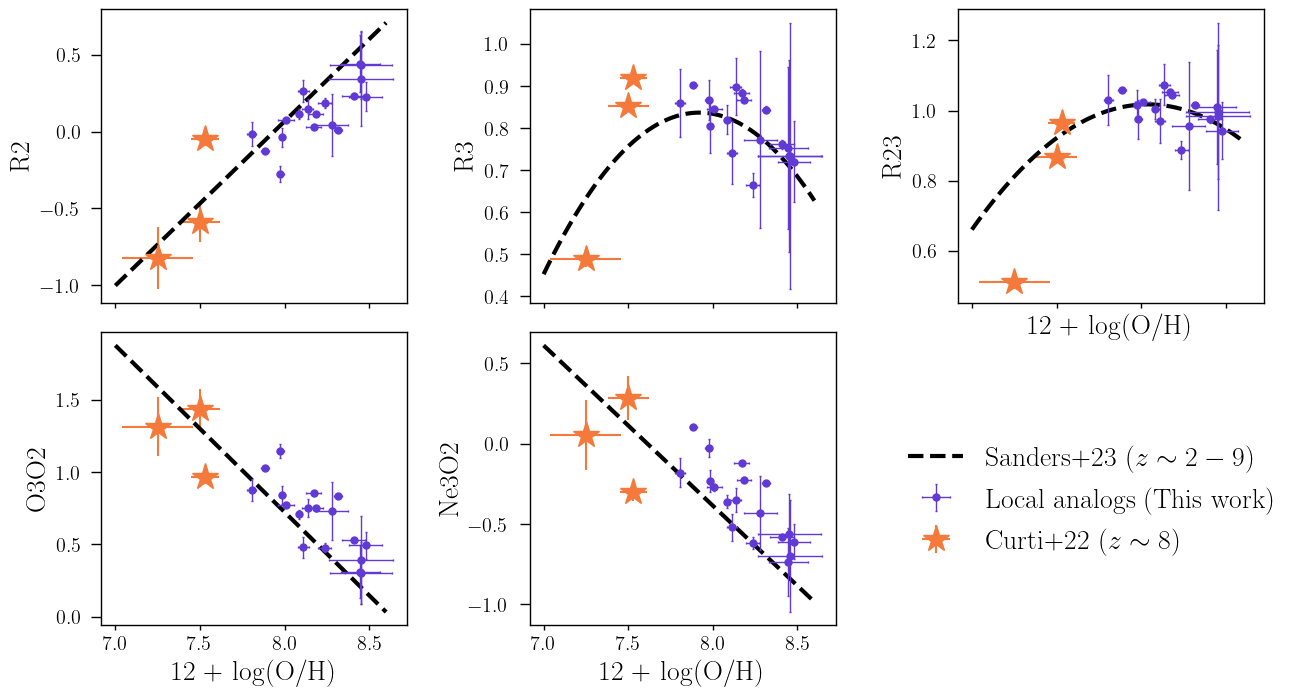

In [29]:
texPlot('on')
fig, axs = plt.subplots(2, 3, sharex=True)
fig.set_size_inches((15, 8))
fig.subplots_adjust(wspace=0.4, hspace=0.1)

# Utils

log_OH_ext = np.linspace(7.0, 8.6, 100)

# ===========================================================================================================
# R2
# ===========================================================================================================

axs[0, 0].errorbar(metals['log_OH'], upy.nominal_values(R2), xerr=metals['log_OH_err'], yerr=upy.std_devs(R2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100)
#axs[0, 0].errorbar(log_OH_med, R2_med, xerr=log_OH_med_err, yerr=R2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[0, 0].errorbar(upy.nominal_values(Curti_dict['12_log_OH']), upy.nominal_values(Curti_dict['R2']),
                  xerr=upy.std_devs(Curti_dict['12_log_OH']), yerr=upy.std_devs(Curti_dict['R2']),
                  ls='', markersize=20, marker='*', color=cz[0])


axs[0, 0].plot(log_OH_ext, sanders2023(log_OH_ext, 'R2'), color='black', ls='--', lw=3)
axs[0, 0].set_ylabel('R2')

# ===========================================================================================================
# R3
# ===========================================================================================================

axs[0, 1].errorbar(metals['log_OH'], upy.nominal_values(R3), xerr=metals['log_OH_err'], yerr=upy.std_devs(R3), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100)
#axs[0, 1].errorbar(log_OH_med, R3_med, xerr=log_OH_med_err, yerr=R3_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[0, 1].errorbar(upy.nominal_values(Curti_dict['12_log_OH']), upy.nominal_values(Curti_dict['R3']),
                  xerr=upy.std_devs(Curti_dict['12_log_OH']), yerr=upy.std_devs(Curti_dict['R3']),
                  ls='', markersize=20, marker='*', color=cz[0])

axs[0, 1].plot(log_OH_ext, sanders2023(log_OH_ext, 'R3'), color='black', ls='--', lw=3)
axs[0, 1].set_ylabel('R3')

# ===========================================================================================================
# R23
# ===========================================================================================================

axs[0, 2].errorbar(metals['log_OH'], upy.nominal_values(R23), xerr=metals['log_OH_err'], yerr=upy.std_devs(R23), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, label='Local analogs (This work)')
#axs[0, 2].errorbar(log_OH_med, R23_med, xerr=log_OH_med_err, yerr=R23_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8, label='Local analogs (This work)')

axs[0, 2].errorbar(upy.nominal_values(Curti_dict['12_log_OH']), upy.nominal_values(Curti_dict['R23']),
                  xerr=upy.std_devs(Curti_dict['12_log_OH']), yerr=upy.std_devs(Curti_dict['R23']),
                  ls='', markersize=20, marker='*', color=cz[0], label=r'Curti+22 ($z \sim 8$)')

axs[0, 2].plot(log_OH_ext, sanders2023(log_OH_ext, 'R23'), label='Sanders+23 ($z \sim 2 - 9$)',
               color='black', ls='--', lw=3)

axs[0, 2].set_ylabel('R23')

axs[1, 2].axis('off')


# ===========================================================================================================
# O3O2
# ===========================================================================================================

axs[1, 0].errorbar(metals['log_OH'], upy.nominal_values(O3O2), xerr=metals['log_OH_err'], yerr=upy.std_devs(O3O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100)
#axs[1, 0].errorbar(log_OH_med, O3O2_med, xerr=log_OH_med_err, yerr=O3O2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[1, 0].errorbar(upy.nominal_values(Curti_dict['12_log_OH']), upy.nominal_values(Curti_dict['O3O2']),
                  xerr=upy.std_devs(Curti_dict['12_log_OH']), yerr=upy.std_devs(Curti_dict['O3O2']),
                  ls='', markersize=20, marker='*', color=cz[0])

axs[1, 0].plot(log_OH_ext, sanders2023(log_OH_ext, 'O3O2'), color='black', ls='--', lw=3)

axs[1, 0].set_ylabel('O3O2')

# ===========================================================================================================
# Ne3O2
# ===========================================================================================================

axs[1, 1].errorbar(metals['log_OH'], upy.nominal_values(Ne3O2), xerr=metals['log_OH_err'], yerr=upy.std_devs(Ne3O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100)
#axs[1, 1].errorbar(log_OH_med, Ne3O2_med, xerr=log_OH_med_err, yerr=Ne3O2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[1, 1].plot(log_OH_ext, sanders2023(log_OH_ext, 'Ne3O2'), color='black', ls='--', lw=3)

axs[1, 1].errorbar(upy.nominal_values(Curti_dict['12_log_OH']), upy.nominal_values(Curti_dict['Ne3O2']),
                  xerr=upy.std_devs(Curti_dict['12_log_OH']), yerr=upy.std_devs(Curti_dict['Ne3O2']),
                  ls='', markersize=20, marker='*', color=cz[0])

axs[1, 1].set_ylabel('Ne3O2')

# ===========================================================================================================
# General settings
# ===========================================================================================================

axs[1, 0].set_xlabel(r'12 + log(O/H)')
axs[1, 1].set_xlabel(r'12 + log(O/H)')
axs[0, 2].set_xlabel(r'12 + log(O/H)')

axs[0, 2].legend(frameon=False, loc=(-0.2, -0.9), fontsize=20)

# -----------------------

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
import uncertainties.unumpy as upy
import lmfit
from lmfit import minimize, Parameters


import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)

from magE.plotutils import * 
from magE.constutils import *

In [2]:
# Metallicities and more
metals = pd.read_csv(magePath+'results/metals/abundance_measured.csv')
em_lines = pd.read_csv(magePath+'results/em_lines.csv')
sed_results = fits.open('/home/benjamin/Documents/sed_fitting/old_pop_late_burst/results.fits') # SED fitting results

# log(M*)
unc_m_star = upy.uarray(sed_results[1].data['bayes.stellar.m_star'],
                        sed_results[1].data['bayes.stellar.m_star_err'])
m_star = upy.nominal_values(upy.log10(unc_m_star))
m_star_err = upy.std_devs(upy.log10(unc_m_star))

# log(SFR)
unc_sfr = upy.uarray(sed_results[1].data['bayes.sfh.sfr100Myrs'],
                     sed_results[1].data['bayes.sfh.sfr100Myrs_err'])
sfr = upy.nominal_values(upy.log10(unc_sfr))
sfr_err = upy.std_devs(upy.log10(unc_sfr))

metals.keys()

Index(['galname', 'He/H', 'He/H_16', 'He/H_84', 'log_OH', 'log_OH_16',
       'log_OH_84', 'log_OH_G92', 'log_OH_G92_16', 'log_OH_G92_84', 'log_SH',
       'log_SH_16', 'log_SH_84', 'log_NH', 'log_NH_16', 'log_NH_84', 'log_NO',
       'log_NO_16', 'log_NO_84'],
      dtype='object')

In [3]:
em_lines.keys()

Index(['galname', '[OII]3726', '[OII]3726_err', '[OII]3729', '[OII]3729_err',
       'Hd', 'Hd_err', 'Hg', 'Hg_err', '[OIII]4363', '[OIII]4363_err',
       'HeI4471', 'HeI4471_err', 'HeII4686', 'HeII4686_err', 'Hb', 'Hb_err',
       '[OIII]4959', '[OIII]4959_err', '[OIII]5007', '[OIII]5007_err',
       '[NII]5755', '[NII]5755_err', 'HeI5875', 'HeI5875_err', '[SIII]6312',
       '[SIII]6312_err', '[NII]6548', '[NII]6548_err', 'Ha', 'Ha_err',
       '[NII]6584', '[NII]6584_err', 'HeI6678', 'HeI6678_err', '[SII]6716',
       '[SII]6716_err', '[SII]6730', '[SII]6730_err', 'HeI7065', 'HeI7065_err',
       '[OII]7319', '[OII]7319_err', '[OII]7330', '[OII]7330_err',
       '[SIII]9069', '[SIII]9069_err', '[SIII]9532', '[SIII]9532_err'],
      dtype='object')

In [4]:
# Line ratios

N2 = upy.log10(upy.uarray(em_lines['[NII]6584'], em_lines['[NII]6584_err']) / upy.uarray(em_lines['Ha'], em_lines['Ha_err']))

R2 = upy.log10((upy.uarray(em_lines['[OII]3726'], em_lines['[OII]3726_err']) \
              + upy.uarray(em_lines['[OII]3729'], em_lines['[OII]3729_err'])) / upy.uarray(em_lines['Hb'], em_lines['Hb_err']))

R3 = upy.log10(upy.uarray(em_lines['[OIII]5007'], em_lines['[OIII]5007_err']) / upy.uarray(em_lines['Hb'], em_lines['Hb_err']))

R23 = upy.log10((upy.uarray(em_lines['[OII]3726'], em_lines['[OII]3726_err']) \
               + upy.uarray(em_lines['[OII]3729'], em_lines['[OII]3729_err']) \
               + upy.uarray(em_lines['[OIII]4959'], em_lines['[OIII]4959_err']) \
               + upy.uarray(em_lines['[OIII]5007'], em_lines['[OIII]5007_err']))  / upy.uarray(em_lines['Hb'], em_lines['Hb_err']))

O3N2 = upy.log10((upy.uarray(em_lines['[OIII]5007'], em_lines['[OIII]5007_err']) / upy.uarray(em_lines['Hb'], em_lines['Hb_err'])) \
               / (upy.uarray(em_lines['[NII]6584'], em_lines['[NII]6584_err']) / upy.uarray(em_lines['Ha'], em_lines['Ha_err'])))

R3N2 = upy.log10(upy.uarray(em_lines['[OIII]5007'], em_lines['[OIII]5007_err']) / upy.uarray(em_lines['[NII]6584'], em_lines['[NII]6584_err']))

N2O2 = upy.log10(upy.uarray(em_lines['[NII]6584'], em_lines['[NII]6584_err']) / upy.uarray(em_lines['[OII]3726'], em_lines['[OII]3726_err']))

O3O2 = upy.log10(upy.uarray(em_lines['[OIII]5007'], em_lines['[OIII]5007_err']) / (upy.uarray(em_lines['[OII]3726'], em_lines['[OII]3726_err']) \
               + upy.uarray(em_lines['[OII]3729'], em_lines['[OII]3729_err'])))

Ne3O2 = upy.log10(upy.uarray(em_lines['[NeIII]3868'], em_lines['[NeIII]3868_err'])/ (upy.uarray(em_lines['[OII]3726'], em_lines['[OII]3726_err']) \
                + upy.uarray(em_lines['[OII]3729'], em_lines['[OII]3729_err'])))

S2 = upy.log10((upy.uarray(em_lines['[SII]6716'], em_lines['[SII]6716_err']) + upy.uarray(em_lines['[SII]6730'], em_lines['[SII]6730_err'])) \
              / upy.uarray(em_lines['Ha'], em_lines['Ha_err']))

O3S2 = upy.log10((upy.uarray(em_lines['[OIII]5007'], em_lines['[OIII]5007_err']) / upy.uarray(em_lines['Hb'], em_lines['Hb_err'])) \
              / ((upy.uarray(em_lines['[SII]6716'], em_lines['[SII]6716_err']) + upy.uarray(em_lines['[SII]6730'], em_lines['[SII]6730_err']))  / upy.uarray(em_lines['Ha'], em_lines['Ha_err'])))
 
N2S2 = upy.log10((upy.uarray(em_lines['[NII]6584'], em_lines['[NII]6584_err']) / (upy.uarray(em_lines['[SII]6716'], em_lines['[SII]6716_err']) \
                + upy.uarray(em_lines['[SII]6730'], em_lines['[SII]6730_err']))) + (0.264 * (upy.uarray(em_lines['[NII]6584'], em_lines['[NII]6584_err']) \
                / upy.uarray(em_lines['Ha'], em_lines['Ha_err']))))

# Data binning

In [5]:
mask1 = (metals['log_OH'] > 7.8) & (metals['log_OH'] <= 8.0)
mask2 = (metals['log_OH'] > 8.0) & (metals['log_OH'] <= 8.2)
mask3 = (metals['log_OH'] > 8.2) & (metals['log_OH'] <= 8.4)
mask4 = (metals['log_OH'] > 8.4) & (metals['log_OH'] <= 8.6)

def binning(values, errors):
    bin1 = np.mean(upy.uarray(values[mask1], errors[mask1]))
    bin2 = np.mean(upy.uarray(values[mask2], errors[mask2]))
    bin3 = np.mean(upy.uarray(values[mask3], errors[mask3]))
    bin4 = np.mean(upy.uarray(values[mask4], errors[mask4]))
    
    total_bin = upy.uarray([bin1.nominal_value, bin2.nominal_value, bin3.nominal_value, bin4.nominal_value],
                           [bin1.std_dev, bin2.std_dev, bin3.std_dev, bin4.std_dev])
    return total_bin

bin_OH = binning(metals['log_OH'], metals['log_OH_err'])
bin_N2 = binning(upy.nominal_values(N2), upy.std_devs(N2))
bin_R2 = binning(upy.nominal_values(R2), upy.std_devs(R2))
bin_R3 = binning(upy.nominal_values(R3), upy.std_devs(R3))
bin_R23 = binning(upy.nominal_values(R23), upy.std_devs(R23))
bin_O3N2 = binning(upy.nominal_values(O3N2), upy.std_devs(O3N2))
bin_R3N2 = binning(upy.nominal_values(R3N2), upy.std_devs(R3N2))
bin_N2O2 = binning(upy.nominal_values(N2O2), upy.std_devs(N2O2))
bin_O3O2 = binning(upy.nominal_values(O3O2), upy.std_devs(O3O2))
bin_Ne3O2 = binning(upy.nominal_values(Ne3O2), upy.std_devs(Ne3O2))
bin_S2 = binning(upy.nominal_values(S2), upy.std_devs(S2))
bin_O3S2 = binning(upy.nominal_values(O3S2), upy.std_devs(O3S2))
bin_N2S2 = binning(upy.nominal_values(N2S2), upy.std_devs(N2S2))

In [18]:
len(metals['log_OH'][mask1])

4

In [19]:
len(metals['log_OH'][mask2])

6

In [21]:
len(metals['log_OH'][mask3])

3

In [22]:
len(metals['log_OH'][mask4])

5

# Table

In [6]:
ratios_table = {'ID': metals['galname'].to_numpy(),
                'N2': N2,
                'R2': R2,
                'R3': R3,
                'R23': R23,
                'O3N2': O3N2,
                'R3N2': R3N2,
                'N2O2': N2O2,
                'O3O2': O3O2,
                'Ne3O2': Ne3O2,
                'S2': S2,
                'O3S2': O3S2,
                'N2S2': N2S2
}
ratios_table_pd = pd.DataFrame(data=ratios_table, index=None)

bin_table = {'Bin': np.array(['7.8 - 8.0', '8.0 - 8.2', '8.2 - 8.4', '8.4 - 8.6']),
             'N2': bin_N2,
             'R2': bin_R2,
             'R3': bin_R3,
             'R23': bin_R23,
             'O3N2': bin_O3N2,
             'R3N2': bin_R3N2,
             'N2O2': bin_N2O2,
             'O3O2': bin_O3O2,
             'Ne3O2': bin_Ne3O2,
             'S2': bin_S2,
             'O3S2': bin_O3S2,
             'N2S2': bin_N2S2
}
bin_table_pd = pd.DataFrame(data=bin_table, index=None)

In [7]:
ratios_table_pd.to_latex(index=None, float_format='%.3f')

'\\begin{tabular}{llllllllllllll}\n\\toprule\n & ID & N2 & R2 & R3 & R23 & O3N2 & R3N2 & N2O2 & O3O2 & Ne3O2 & S2 & O3S2 & N2S2 \\\\\n\\midrule\n0 & J0021 & -1.1138+/-0.0015 & 0.1872+/-0.0034 & 0.6646+/-0.0008 & 0.8871+/-0.0010 & 1.7784+/-0.0017 & 1.3212+/-0.0015 & -0.440+/-0.006 & 0.4774+/-0.0033 & -0.619+/-0.004 & -1.0310+/-0.0016 & 1.6956+/-0.0018 & -0.0723+/-0.0021 \\\\\n1 & J0023 & -1.591+/-0.004 & 0.2303+/-0.0018 & 0.7456+/-0.0013 & 0.9672+/-0.0012 & 2.336+/-0.004 & 1.828+/-0.004 & -0.937+/-0.004 & 0.5153+/-0.0016 & -0.5160+/-0.0026 & -1.0213+/-0.0020 & 1.7669+/-0.0024 & -0.559+/-0.004 \\\\\n2 & J0136 & -1.877+/-0.013 & 0.145+/-0.005 & 0.8991+/-0.0020 & 1.0733+/-0.0020 & 2.776+/-0.014 & 2.318+/-0.013 & -1.194+/-0.015 & 0.754+/-0.005 & -0.351+/-0.007 & -1.201+/-0.006 & 2.100+/-0.007 & -0.668+/-0.015 \\\\\n3 & J0240 & -1.691+/-0.006 & -0.282+/-0.005 & 0.8671+/-0.0014 & 1.0152+/-0.0013 & 2.558+/-0.006 & 2.104+/-0.006 & -0.668+/-0.009 & 1.149+/-0.005 & -0.023+/-0.006 & -1.588+/-0.007

In [9]:
bin_table_pd.to_latex(index=None, float_format='%.3f')

'\\begin{tabular}{llllllllllllll}\n\\toprule\n & Bin & N2 & R2 & R3 & R23 & O3N2 & R3N2 & N2O2 & O3O2 & Ne3O2 & S2 & O3S2 & N2S2 \\\\\n\\midrule\n0 & 7.8 - 8.0 & -1.875+/-0.004 & -0.1112+/-0.0020 & 0.8581+/-0.0008 & 1.0199+/-0.0008 & 2.733+/-0.004 & 2.276+/-0.004 & -0.956+/-0.005 & 0.9693+/-0.0019 & -0.0836+/-0.0023 & -1.4643+/-0.0025 & 2.3224+/-0.0026 & -0.407+/-0.004 \\\\\n1 & 8.0 - 8.2 & -1.766+/-0.004 & 0.1190+/-0.0016 & 0.8432+/-0.0006 & 1.0278+/-0.0006 & 2.609+/-0.004 & 2.151+/-0.004 & -1.055+/-0.005 & 0.7243+/-0.0015 & -0.3076+/-0.0021 & -1.2445+/-0.0019 & 2.0878+/-0.0020 & -0.515+/-0.004 \\\\\n2 & 8.2 - 8.4 & -1.4805+/-0.0027 & 0.1480+/-0.0023 & 0.7571+/-0.0008 & 0.9624+/-0.0009 & 2.2376+/-0.0028 & 1.8147+/-0.0027 & -0.836+/-0.004 & 0.6091+/-0.0022 & -0.5120+/-0.0034 & -1.1054+/-0.0018 & 1.8625+/-0.0020 & -0.3659+/-0.0031 \\\\\n3 & 8.4 - 8.6 & -1.3785+/-0.0035 & 0.3831+/-0.0020 & 0.7342+/-0.0010 & 0.9869+/-0.0010 & 2.113+/-0.004 & 1.6466+/-0.0035 & -0.941+/-0.004 & 0.3511+/-0.0

# Models to fit

In [9]:
# For LMFIT

# Linear
def residuals_linear(params, x, y, err):
    m = params['a1']
    n = params['a0']
    
    model = (m * x) + n
    return (model - y) / err

# Polynomial of degree 3

def residuals_poly3(params, x, y, err):
    a0 = params['a0']
    a1 = params['a1']
    a2 = params['a2']
    a3 = params['a3']
    
    model = a0 + (a1 * x) + (a2 * (x**2)) + (a3 + (x**3))
    return (model - y) / np.max(err)


# For curve_fit

import scipy

def poly2(x, a0, a1, a2):
    t0 = a0
    t1 = a1 * x
    t2 = a2 * (x**2)
    return t0 + t1 + t2

def poly3(x, a0, a1, a2, a3):
    t0 = a0
    t1 = a1 * x
    t2 = a2 * (x**2)
    t3 = a3 * (x**3)
    return t0 + t1 + t2 + t3

# Fits

## Linear

In [10]:
# ===========================================================================================================
# N2 Ratio
# ===========================================================================================================

params_N2 = Parameters()
params_N2.add('a0', value=8.82)
params_N2.add('a1', value=0.49)

#out_N2 = minimize(residuals_linear, params_N2, args=(upy.nominal_values(N2),
#                                                     metals['log_OH'].to_numpy(),
#                                                     metals['log_OH_err'].to_numpy()),
#                                                     method='leastsq')

out_N2_med = minimize(residuals_linear, params_N2, args=(upy.nominal_values(bin_N2),
                                                     upy.nominal_values(bin_OH),
                                                     upy.std_devs(bin_OH)),
                                                     method='leastsq')

# ===========================================================================================================
# O3N2 Ratio
# ===========================================================================================================

params_O3N2 = Parameters()
params_O3N2.add('a0', value=8.97)
params_O3N2.add('a1', value=-0.39)

#out_O3N2 = minimize(residuals_linear, params_O3N2, args=(upy.nominal_values(O3N2),
#                                                     metals['log_OH'].to_numpy(),
#                                                     metals['log_OH_err'].to_numpy()),
#                                                     method='leastsq')

out_O3N2_med = minimize(residuals_linear, params_O3N2, args=(upy.nominal_values(bin_O3N2),
                                                     upy.nominal_values(bin_OH),
                                                     upy.std_devs(bin_OH)),
                                                     method='leastsq')

# ===========================================================================================================
# O3O2 Ratio
# ===========================================================================================================

params_O3O2 = Parameters()
params_O3O2.add('a0', value=8.54)
params_O3O2.add('a1', value=-0.59)

#out_O3O2 = minimize(residuals_linear, params_O3O2, args=(upy.nominal_values(O3O2),
#                                                     metals['log_OH'].to_numpy(),
#                                                     metals['log_OH_err'].to_numpy()),
#                                                     method='leastsq')

out_O3O2_med = minimize(residuals_linear, params_O3O2, args=(upy.nominal_values(bin_O3O2),
                                                     upy.nominal_values(bin_OH),
                                                     upy.std_devs(bin_OH)),
                                                     method='leastsq')

# ===========================================================================================================
# Ne3O2 Ratio
# ===========================================================================================================

params_Ne3O2 = Parameters()
params_Ne3O2.add('a0', value=7.8)
params_Ne3O2.add('a1', value=-0.63)

#out_Ne3O2 = minimize(residuals_linear, params_Ne3O2, args=(upy.nominal_values(Ne3O2),
#                                                     metals['log_OH'].to_numpy(),
#                                                     metals['log_OH_err'].to_numpy()),
#                                                     method='leastsq')

out_Ne3O2_med = minimize(residuals_linear, params_Ne3O2, args=(upy.nominal_values(bin_Ne3O2),
                                                     upy.nominal_values(bin_OH),
                                                     upy.std_devs(bin_OH)),
                                                     method='leastsq')

# ===========================================================================================================
# S2 Ratio
# ===========================================================================================================

params_S2 = Parameters()
params_S2.add('a0', value=0.9)
params_S2.add('a1', value=9.2)

#out_S2 = minimize(residuals_linear, params_S2, args=(upy.nominal_values(S2),
#                                                     metals['log_OH'].to_numpy(),
#                                                     metals['log_OH_err'].to_numpy()),
#                                                     method='leastsq')

out_S2_med = minimize(residuals_linear, params_S2, args=(upy.nominal_values(bin_S2),
                                                     upy.nominal_values(bin_OH),
                                                     upy.std_devs(bin_OH)),
                                                     method='leastsq')

# ===========================================================================================================
# O3S2 Ratio
# ===========================================================================================================

params_O3S2 = Parameters()
params_O3S2.add('a0', value=-0.4)
params_O3S2.add('a1', value=-8.8)

#out_O3S2 = minimize(residuals_linear, params_O3S2, args=(upy.nominal_values(O3S2),
#                                                     metals['log_OH'].to_numpy(),
#                                                     metals['log_OH_err'].to_numpy()),
#                                                     method='leastsq')
out_O3S2_med = minimize(residuals_linear, params_O3S2, args=(upy.nominal_values(bin_O3S2),
                                                     upy.nominal_values(bin_OH),
                                                     upy.std_devs(bin_OH)),
                                                     method='leastsq')

## Polynomial

In [11]:
# ===========================================================================================================
# R2 Ratio
# ===========================================================================================================

out_R2_med, cov_R2_med = scipy.optimize.curve_fit(poly2, upy.nominal_values(bin_OH), upy.nominal_values(bin_R2),
                                         p0=[-154.9571, 36.9128, -2.1921], sigma=upy.std_devs(bin_R2),
                                         absolute_sigma=True)

# ===========================================================================================================
# R3 Ratio
# ===========================================================================================================

out_R3_med, cov_R3_med = scipy.optimize.curve_fit(poly2, upy.nominal_values(bin_OH), upy.nominal_values(bin_R3),
                                         p0=[-88.4378, 22.7529, -1.4501], sigma=upy.std_devs(bin_R3),
                                         absolute_sigma=True)

# ===========================================================================================================
# R23 Ratio
# ===========================================================================================================

out_R23_med, cov_R23_med = scipy.optimize.curve_fit(poly2, upy.nominal_values(bin_OH), upy.nominal_values(bin_R23),
                                   p0=[-26.21514017, 6.78095055, -0.42194886], sigma=upy.std_devs(bin_R23),
                                   absolute_sigma=True)

# ===========================================================================================================
# R3N2 Ratio
# ===========================================================================================================

out_R3N2_med, cov_R3N2_med = scipy.optimize.curve_fit(poly2, upy.nominal_values(bin_OH), upy.nominal_values(bin_R3N2),
                                    p0=[-94.40880246, 24.76665082, -1.58572683], sigma=upy.std_devs(bin_R3N2),
                                    absolute_sigma=True)

# ===========================================================================================================
# N2O2 Ratio
# ===========================================================================================================

out_N2O2_med, cov_N2O2_med = scipy.optimize.curve_fit(poly2, upy.nominal_values(bin_OH), upy.nominal_values(bin_N2O2),
                                    p0=[128.94, -48.818, 6.2759], sigma=upy.std_devs(bin_N2O2),
                                    absolute_sigma=True)

# ===========================================================================================================
# N2S2 Ratio
# ===========================================================================================================

out_N2S2_med, cov_N2S2_med = scipy.optimize.curve_fit(poly2, upy.nominal_values(bin_OH), upy.nominal_values(bin_N2S2),
                                    p0=[128.94, -48.818, 6.2759], sigma=upy.std_devs(bin_N2S2),
                                    absolute_sigma=True)

# Metallicity Calibrations

In [12]:
# Utils
log_OH_tp = np.linspace(7.6, 8.7, 1000)
N2_tp = np.linspace(-3.5, 0.1, 1000)
R3_tp = np.linspace(0.2, 1.3, 1000)
R23_tp = np.linspace(0.4, 1.3, 1000)
O3N2_tp = np.linspace(1, 4, 1000)
O3O2_tp = np.linspace(0, 1.5, 1000)
Ne3O2_tp = np.linspace(-2.0, 0.5, 1000)
S2_tp = np.linspace(-2.0, -0.5, 1000)
O3S2_tp = np.linspace(1.0, 2.6, 1000)

## Local relations

In [13]:
# Functions

def denicolo2002_N2(log_OH_12):
    N2 = (log_OH_12 - 9.12) / 0.73
    return N2


def tremonti2004_R23(R23):
    log_OH_12 = 9.185 - (0.313 * R23) - (0.264 * (R23**2)) - (0.321 * (R23**3)) 
    return log_OH_12


def pettini_pagel2004_O3N2(log_OH_12):
    O3N2 = - (log_OH_12 - 8.73) / 0.32
    return O3N2


def pettini_pagel2004_N2(N2):
    log_OH_12 = 9.37 + (2.03 * N2) + (1.26 * (N2**2)) + (0.32 * (N2**3))
    return log_OH_12


def nagao2006(log_OH_12, ratio='asd'):
    if ratio == 'R23':
        b0 = 1.2299
        b1 = -4.1926
        b2 = 1.0246
        b3 = -0.063169
    if ratio == 'N2':
        b0 = 96.641
        b1 = -39.941
        b2 = 5.2227
        b3 = -0.22040
    if ratio == 'R3N2':
        b0 = -232.18
        b1 = 84.423
        b2 = -9.9330
        b3 = 0.37941
    if ratio == 'N2O2':
        b0 = -128.94
        b1 = 48.818
        b2 = -6.2759
        b3 = 0.27101
    if ratio == 'O3O2':
        b0 = -1.4089
        b1 = 1.3745
        b2 = -0.14359
        b3 = 0
    return b0 + (b1 * log_OH_12) + (b2 * (log_OH_12**2)) + (b3 * (log_OH_12**3))

def maiolino2008(log_OH_12, ratio='asd'):
    x = (log_OH_12 - 8.69)
    if ratio == 'R23':
        c0 = 0.7462
        c1 = -0.7149
        c2 = -0.9401
        c3 = -0.6154
        c4 = -0.2524
    if ratio == 'N2':
        c0 = -0.7732
        c1 = 1.2357
        c2 = -0.2811
        c3 = -0.7201
        c4 = -0.3330
    if ratio == 'R3':
        c0 = 0.1549
        c1 = -1.5031
        c2 = -0.9790
        c3 = -0.0297
        c4 = 0.0
    if ratio == 'O3O2':
        c0 = -0.2839
        c1 = -1.3881
        c2 = -0.3172
        c3 = 0.0
        c4 = 0.0
    if ratio == 'R2':
        c0 = 0.5603
        c1 = 0.0450
        c2 = -1.8017
        c3 = -1.8434
        c4 = -0.6549
    if ratio == 'R3N2':
        c0 = 0.4520
        c1 = -2.6096
        c2 = -0.7170
        c3 = 0.1347
        c4 = 0.0
    if ratio == 'Ne3O2':
        c0 = -1.2608
        c1 = -1.0861
        c2 = -0.1470
        c3 = 0.0
        c4 = 0.0
    return c0 + (c1 * x) + (c2 * (x**2)) + (c3 * (x**3)) + (c4 * (x**4))


def marino2013_N2(log_OH_12):
    N2 = (log_OH_12 - 8.743) / 0.462
    return N2


def marino2013_O3N2(log_OH_12):
    O3N2 = - (log_OH_12 - 8.533) / 0.214
    return O3N2


def curti2020(log_OH_12, ratio='asd'):
    x = (log_OH_12 - 8.69)
    if ratio == 'R2':
        c0 = 0.435
        c1 = -1.362
        c2 = -5.655
        c3 = -4.851
        c4 = -0.478
        c5 = 0.736
    if ratio == 'R3':
        c0 = -0.277
        c1 = -3.549
        c2 = -3.593
        c3 = -0.981
        c4 = 0.0
        c5 = 0.0
    if ratio == 'O3O2':
        c0 = -0.691
        c1 = -2.944
        c2 = -1.308
        c3 = 0.0
        c4 = 0.0
        c5 = 0.0
    if ratio == 'R23':
        c0 = 0.527
        c1 = -1.569
        c2 = -1.652
        c3 = -0.421
        c4 = 0.0
        c5 = 0.0
    if ratio == 'N2':
        c0 = -0.489
        c1 = 1.513
        c2 = -2.554
        c3 = -5.293
        c4 = -2.867
        c5 = 0.0
    if ratio == 'O3N2':
        c0 = 0.281
        c1 = -4.765
        c2 = -2.268
        c3 = 0.0
        c4 = 0.0
        c5 = 0.0
    if ratio == 'S2':
        c0 = -0.442
        c1 = -0.360
        c2 = -6.271
        c3 = -8.339
        c4 = -3.559
        c5 = 0.0
    if ratio == 'O3S2':
        c0 = 0.191
        c1 = -4.292
        c2 = -2.538
        c3 = 0.053
        c4 = 0.332
        c5 = 0.0
    return c0 + (c1 * x) + (c2 * (x**2)) + (c3 * (x**3)) + (c4 * (x**4)) + (c5 * (x**5))

def sanders2021(log_OH_12, ratio='asd'):
    x = (log_OH_12 - 8.69)
    if ratio == 'R3':
        c0 = -0.143
        c1 = -3.16
        c2 = -4.06
        c3 = -1.49
    if ratio == 'R2':
        c0 = 0.27
        c1 = -0.452
        c2 = -0.52
        c3 = 0.0831
    if ratio == 'O3O2':
        c0 = -0.413
        c1 = -2.7
        c2 = -3.52
        c3 = -1.55
    if ratio == 'R23':
        c0 = 0.469
        c1 = -1.51
        c2 = -1.75
        c3 = -0.508
    if ratio == 'N2':
        c0 = -0.606
        c1 = 1.28
        c2 = -0.435
        c3 = -0.485
    if ratio == 'O3N2':
        c0 = 0.461
        c1 = -4.40
        c2 = -3.37
        c3 = -0.761
    return c0 + (c1 * x) + (c2 * (x**2)) + (c3 * (x**3))

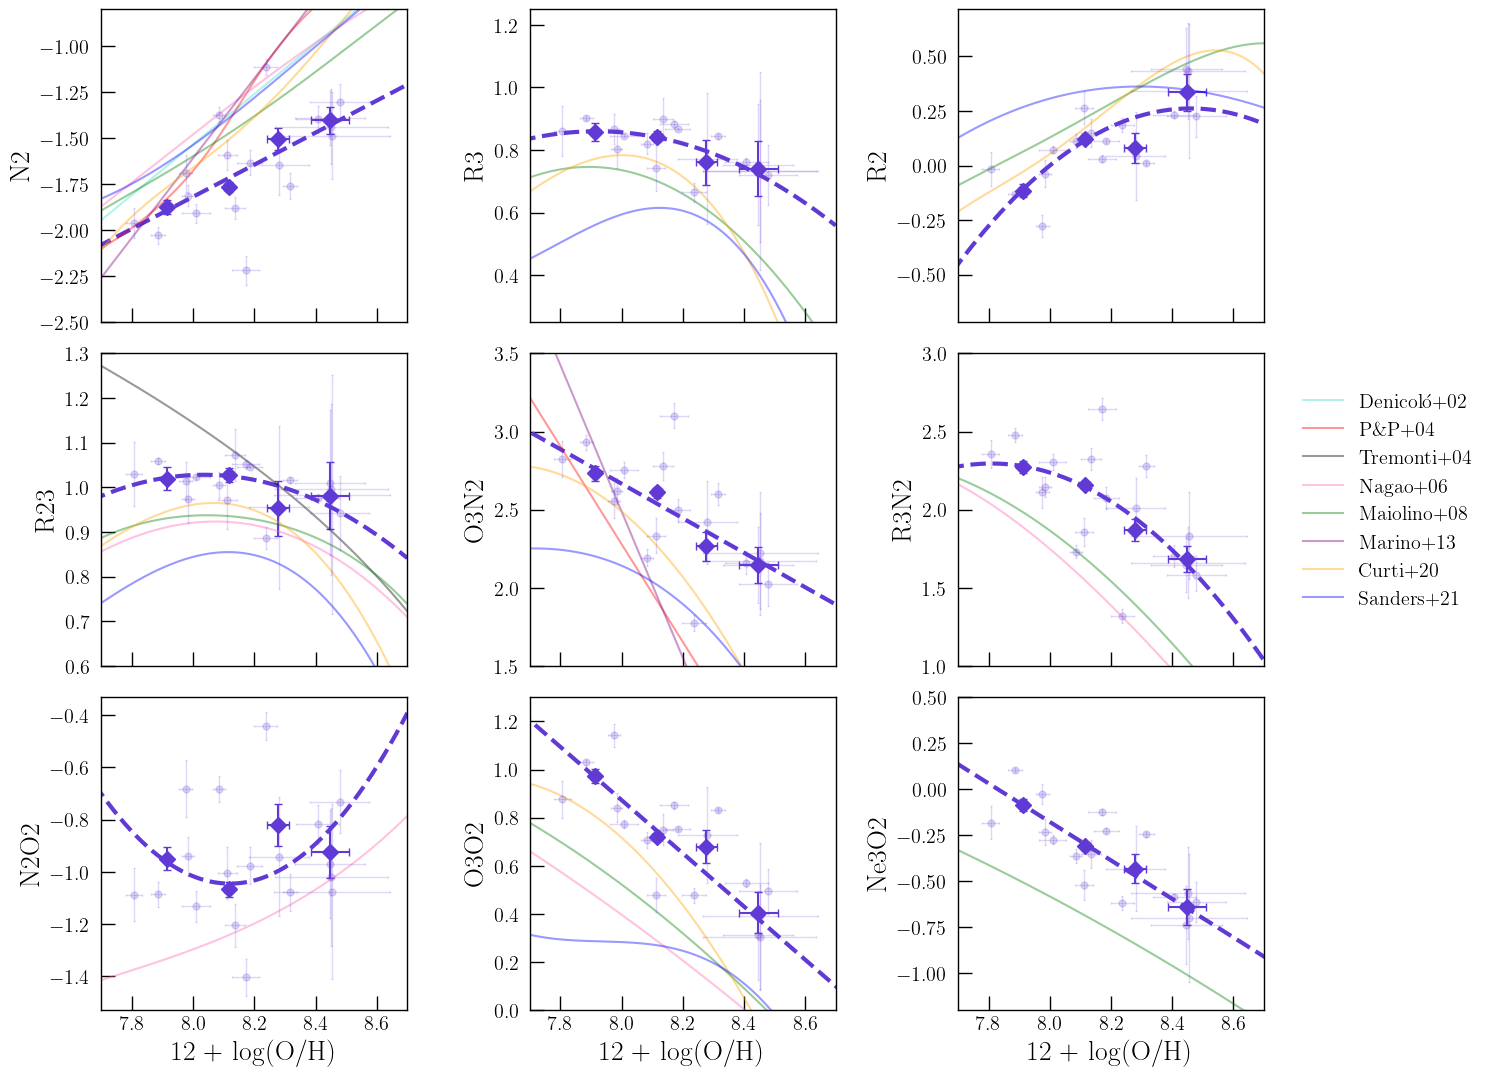

In [14]:
texPlot('on')
fig, axs = plt.subplots(3, 3, sharex=True)
fig.set_size_inches((15, 13))
fig.subplots_adjust(wspace=0.4, hspace=0.1)

# ===========================================================================================================
# N2 Ratio
# ===========================================================================================================

axs[0, 0].errorbar(metals['log_OH'], upy.nominal_values(N2), xerr=metals['log_OH_err'], yerr=upy.std_devs(N2), 
                  marker='o', markersize=5, ls='', color=c[2], elinewidth=1, capsize=1, zorder=100, alpha=0.2)
axs[0, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 0].plot((N2_tp * out_N2_med.params['a1'].value) + out_N2_med.params['a0'].value, N2_tp,
               color=c[2], ls='--', lw=3)

# Relations
axs[0, 0].plot(log_OH_tp, denicolo2002_N2(log_OH_tp), label='Denicoló+02', color='turquoise', alpha=0.4)
axs[0, 0].plot(pettini_pagel2004_N2(N2_tp), N2_tp,
               label=r'P\&P+04', color='red', alpha=0.4)
axs[0, 0].plot(log_OH_tp, nagao2006(log_OH_tp, 'N2'), color='hotpink', alpha=0.4)
axs[0, 0].plot(log_OH_tp, maiolino2008(log_OH_tp, 'N2'), color='green', alpha=0.4)
axs[0, 0].plot(log_OH_tp, marino2013_N2(log_OH_tp), color='purple', alpha=0.4)
axs[0, 0].plot(log_OH_tp, curti2020(log_OH_tp, 'N2'), color='orange', alpha=0.4)
axs[0, 0].plot(log_OH_tp, sanders2021(log_OH_tp, 'N2'), color='blue', alpha=0.4)
axs[0, 0].set_ylabel('N2')


# ===========================================================================================================
# R3 Ratio
# ===========================================================================================================

axs[0, 1].errorbar(metals['log_OH'], upy.nominal_values(R3), xerr=metals['log_OH_err'], yerr=upy.std_devs(R3), 
                  marker='o', markersize=5, ls='', color=c[2], elinewidth=1, capsize=1, zorder=100, alpha=0.2)
axs[0, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R3),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_R3),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 1].plot(log_OH_tp, poly2(log_OH_tp, *out_R3_med), color=c[2], ls='--', lw=3)

axs[0, 1].plot(log_OH_tp, maiolino2008(log_OH_tp, 'R3'), label='Maiolino+08', color='green', alpha=0.4)
axs[0, 1].plot(log_OH_tp, curti2020(log_OH_tp, 'R3'), label='Curti+20', color='orange', alpha=0.4)
axs[0, 1].plot(log_OH_tp, sanders2021(log_OH_tp, 'R3'), label='Sanders+21', color='blue', alpha=0.4)
axs[0, 1].set_ylabel('R3')

# ===========================================================================================================
# R2 Ratio
# ===========================================================================================================

axs[0, 2].errorbar(metals['log_OH'], upy.nominal_values(R2), xerr=metals['log_OH_err'], yerr=upy.std_devs(R2), 
                  marker='o', markersize=5, ls='', color=c[2], elinewidth=1, capsize=1, zorder=100, alpha=0.2)
axs[0, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_R2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 2].plot(log_OH_tp, poly2(log_OH_tp, *out_R2_med), color=c[2], ls='--', lw=3)

axs[0, 2].plot(log_OH_tp, maiolino2008(log_OH_tp, 'R2'), label='Maiolino+2008', color='green', alpha=0.4)
axs[0, 2].plot(log_OH_tp, curti2020(log_OH_tp, 'R2'), label='Curti+2020', color='orange', alpha=0.4)
axs[0, 2].plot(log_OH_tp, sanders2021(log_OH_tp, 'R2'), label='Sanders+2021', color='blue', alpha=0.4)
axs[0, 2].set_ylabel('R2')

# ===========================================================================================================
# R23 Ratio
# ===========================================================================================================

axs[1, 0].errorbar(metals['log_OH'], upy.nominal_values(R23), xerr=metals['log_OH_err'], yerr=upy.std_devs(R23), 
                  marker='o', markersize=5, ls='', color=c[2], elinewidth=1, capsize=1, zorder=100, alpha=0.2)
axs[1, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R23),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_R23),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 0].plot(log_OH_tp, poly2(log_OH_tp, *out_R23_med), color=c[2], ls='--', lw=3)

axs[1, 0].plot(tremonti2004_R23(R23_tp), R23_tp, label='Tremonti+04', color='black', alpha=0.4)
axs[1, 0].plot(log_OH_tp, nagao2006(log_OH_tp, 'R23'), color='hotpink', alpha=0.4)
axs[1, 0].plot(log_OH_tp, maiolino2008(log_OH_tp, 'R23'), color='green', alpha=0.4)
axs[1, 0].plot(log_OH_tp, curti2020(log_OH_tp, 'R23'), color='orange', alpha=0.4)
axs[1, 0].plot(log_OH_tp, sanders2021(log_OH_tp, 'R23'), color='blue', alpha=0.4)
axs[1, 0].set_ylabel('R23')

# ===========================================================================================================
# O3N2 Ratio
# ===========================================================================================================

axs[1, 1].errorbar(metals['log_OH'], upy.nominal_values(O3N2), xerr=metals['log_OH_err'], yerr=upy.std_devs(O3N2), 
                  marker='o', markersize=5, ls='', color=c[2], elinewidth=1, capsize=1, zorder=100, alpha=0.2)
axs[1, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3N2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_O3N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 1].plot((O3N2_tp * out_O3N2_med.params['a1'].value) + out_O3N2_med.params['a0'].value, O3N2_tp,
               color=c[2], ls='--', lw=3)

axs[1, 1].plot(log_OH_tp, pettini_pagel2004_O3N2(log_OH_tp), color='red', alpha=0.4)
axs[1, 1].plot(log_OH_tp, marino2013_O3N2(log_OH_tp), label='Marino+13', color='purple', alpha=0.4)
axs[1, 1].plot(log_OH_tp, curti2020(log_OH_tp, 'O3N2'), label='Curti+20', color='orange', alpha=0.4)
axs[1, 1].plot(log_OH_tp, sanders2021(log_OH_tp, 'O3N2'), label='Sanders+21', color='blue', alpha=0.4)
axs[1, 1].set_ylabel('O3N2')

# ===========================================================================================================
# R3N2 Ratio
# ===========================================================================================================

axs[1, 2].errorbar(metals['log_OH'], upy.nominal_values(R3N2), xerr=metals['log_OH_err'], yerr=upy.std_devs(R3N2), 
                  marker='o', markersize=5, ls='', color=c[2], elinewidth=1, capsize=1, zorder=100, alpha=0.2)
axs[1, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R3N2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_R3N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 2].plot(log_OH_tp, poly2(log_OH_tp, *out_R3N2_med), color=c[2], ls='--', lw=3)

axs[1, 2].plot(log_OH_tp, nagao2006(log_OH_tp, 'R3N2'), label='Nagao+06', color='hotpink', alpha=0.4)
axs[1, 2].plot(log_OH_tp, maiolino2008(log_OH_tp, 'R3N2'), label='Maiolino+08', color='green', alpha=0.4)
axs[1, 2].set_ylabel('R3N2')

# ===========================================================================================================
# N2O2 Ratio
# ===========================================================================================================

axs[2, 0].errorbar(metals['log_OH'], upy.nominal_values(N2O2), xerr=metals['log_OH_err'], yerr=upy.std_devs(N2O2), 
                  marker='o', markersize=5, ls='', color=c[2], elinewidth=1, capsize=1, zorder=100, alpha=0.2)
axs[2, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2O2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_N2O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 0].plot(log_OH_tp, poly2(log_OH_tp, *out_N2O2_med), color=c[2], ls='--', lw=3)

axs[2, 0].plot(log_OH_tp, nagao2006(log_OH_tp, 'N2O2'), label='Nagao+2006', color='hotpink', alpha=0.4)
axs[2, 0].set_ylabel('N2O2')

# ===========================================================================================================
# O3O2 Ratio
# ===========================================================================================================

axs[2, 1].errorbar(metals['log_OH'], upy.nominal_values(O3O2), xerr=metals['log_OH_err'], yerr=upy.std_devs(O3O2), 
                  marker='o', markersize=5, ls='', color=c[2], elinewidth=1, capsize=1, zorder=100, alpha=0.2)
axs[2, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3O2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_O3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 1].plot((O3O2_tp * out_O3O2_med.params['a1'].value) + out_O3O2_med.params['a0'].value, O3O2_tp,
               color=c[2], ls='--', lw=3)

axs[2, 1].plot(log_OH_tp, nagao2006(log_OH_tp, 'O3O2'), label='Nagao+2006', color='hotpink', alpha=0.4)
axs[2, 1].plot(log_OH_tp, maiolino2008(log_OH_tp, 'O3O2'), label='Maiolino+2008', color='green', alpha=0.4)
axs[2, 1].plot(log_OH_tp, curti2020(log_OH_tp, 'O3O2'), label='Curti+2020', color='orange', alpha=0.4)
axs[2, 1].plot(log_OH_tp, sanders2021(log_OH_tp, 'O3O2'), label='Sanders+2021', color='blue', alpha=0.4)
axs[2, 1].set_ylabel('O3O2')

# ===========================================================================================================
# Ne3O2 Ratio
# ===========================================================================================================

axs[2, 2].errorbar(metals['log_OH'], upy.nominal_values(Ne3O2), xerr=metals['log_OH_err'], yerr=upy.std_devs(Ne3O2), 
                  marker='o', markersize=5, ls='', color=c[2], elinewidth=1, capsize=1, zorder=100, alpha=0.2)
axs[2, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_Ne3O2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_Ne3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 2].plot((Ne3O2_tp * out_Ne3O2_med.params['a1'].value) + out_Ne3O2_med.params['a0'].value, Ne3O2_tp,
               color=c[2], ls='--', lw=3)

axs[2, 2].plot(log_OH_tp, maiolino2008(log_OH_tp, 'Ne3O2'), label='Maiolino+2008', color='green', alpha=0.4)
axs[2, 2].set_ylabel('Ne3O2')


# ===========================================================================================================
# General settings
# ===========================================================================================================
axs[2, 0].set_xlabel(r'12 + log(O/H)')
axs[2, 1].set_xlabel(r'12 + log(O/H)')
axs[2, 2].set_xlabel(r'12 + log(O/H)')



# limits

# x
axs[0, 0].set_xlim(7.7, 8.7) 

# y
axs[0, 0].set_ylim(-2.5, -0.8) # N2
axs[0, 1].set_ylim(0.25, 1.25) # R2

axs[1, 0].set_ylim(0.6, 1.3) # R23
axs[1, 1].set_ylim(1.5, 3.5) # O3N2
axs[1, 2].set_ylim(1, 3) # R3N2

axs[2, 1].set_ylim(0, 1.3) # O3O2
axs[2, 2].set_ylim(-1.2, 0.5) # Ne3O2

# legend
axs[0, 0].legend(frameon=False, loc=(3.9, -0.4))
axs[1, 0].legend(frameon=False, loc=(3.9, 0.61))
axs[1, 1].legend(frameon=False, loc=(2.5, 0.16))
axs[1, 2].legend(frameon=False, loc=(1.1, 0.43))

# Setting tick params
index_local = [0, 1, 2]
for index in index_local:
    for sec_index in index_local:
        axs[index, sec_index].tick_params(axis="y", direction="in", length=10)
        axs[index, sec_index].tick_params(axis="x", direction="in", length=10)

#fig.savefig(magePath+'analysis/chapter4/calibration_vs_local.pdf', bbox_inches='tight')

## Analogs

In [15]:
def jones2015(log_OH_12, ratio='asd'):
    if ratio == 'Ne3O2':
        c0 = 16.8974
        c1 = -2.1588
        c2 = 0.0
    if ratio == 'O3O2':
        c0 = 17.9828
        c1 = -2.1552
        c2 = 0.0
    if ratio == 'R3':
        c0 = -88.4378
        c1 = 22.7529
        c2 = -1.4501
    if ratio == 'R2':
        c0 = -154.9571
        c1 = 36.9128
        c2 = -2.1921
    if ratio == 'R23':
        c0 = -54.1003
        c1 = 13.9083
        c2 = -0.8782
    return c0 + (c1 * log_OH_12) + (c2 * (log_OH_12**2))

def bian2018(log_OH_12, ratio='asd'):
    if ratio == 'N2':
        return (log_OH_12 - 8.82) / 0.49
    if ratio == 'O3N2':
        return - (log_OH_12 - 8.97) / 0.39
    if ratio == 'R23':
        c0 = 138.0430
        c1 = -54.8284
        c2 = 7.2954
        c3 = -0.32293
        return c0 + (c1 * log_OH_12) + (c2 * (log_OH_12**2)) + (c3 * (log_OH_12**3))
    if ratio == 'O3O2':
        return - (log_OH_12 - 8.54) / 0.59
    if ratio == 'R3':
        c0 = 43.9836
        c1 = -21.6211
        c2 = 3.4277
        c3 = -0.1747
        return c0 + (c1 * log_OH_12) + (c2 * (log_OH_12**2)) + (c3 * (log_OH_12**3))
    if ratio == 'Ne3O2':
        return - (log_OH_12 - 7.8) / 0.63
    
def perez_montero2021(log_OH_12, ratio='asd'):
    if ratio == 'O3O2':
        return - (log_OH_12 - 8.308) / 0.352
    if ratio == 'Ne3O2':
        return - (log_OH_12 - 7.823) / 0.455
    if ratio == 'N2':
        return (log_OH_12 - 8.625) / 0.361
    if ratio == 'O3N2':
        return - (log_OH_12 - 8.677) / 0.270

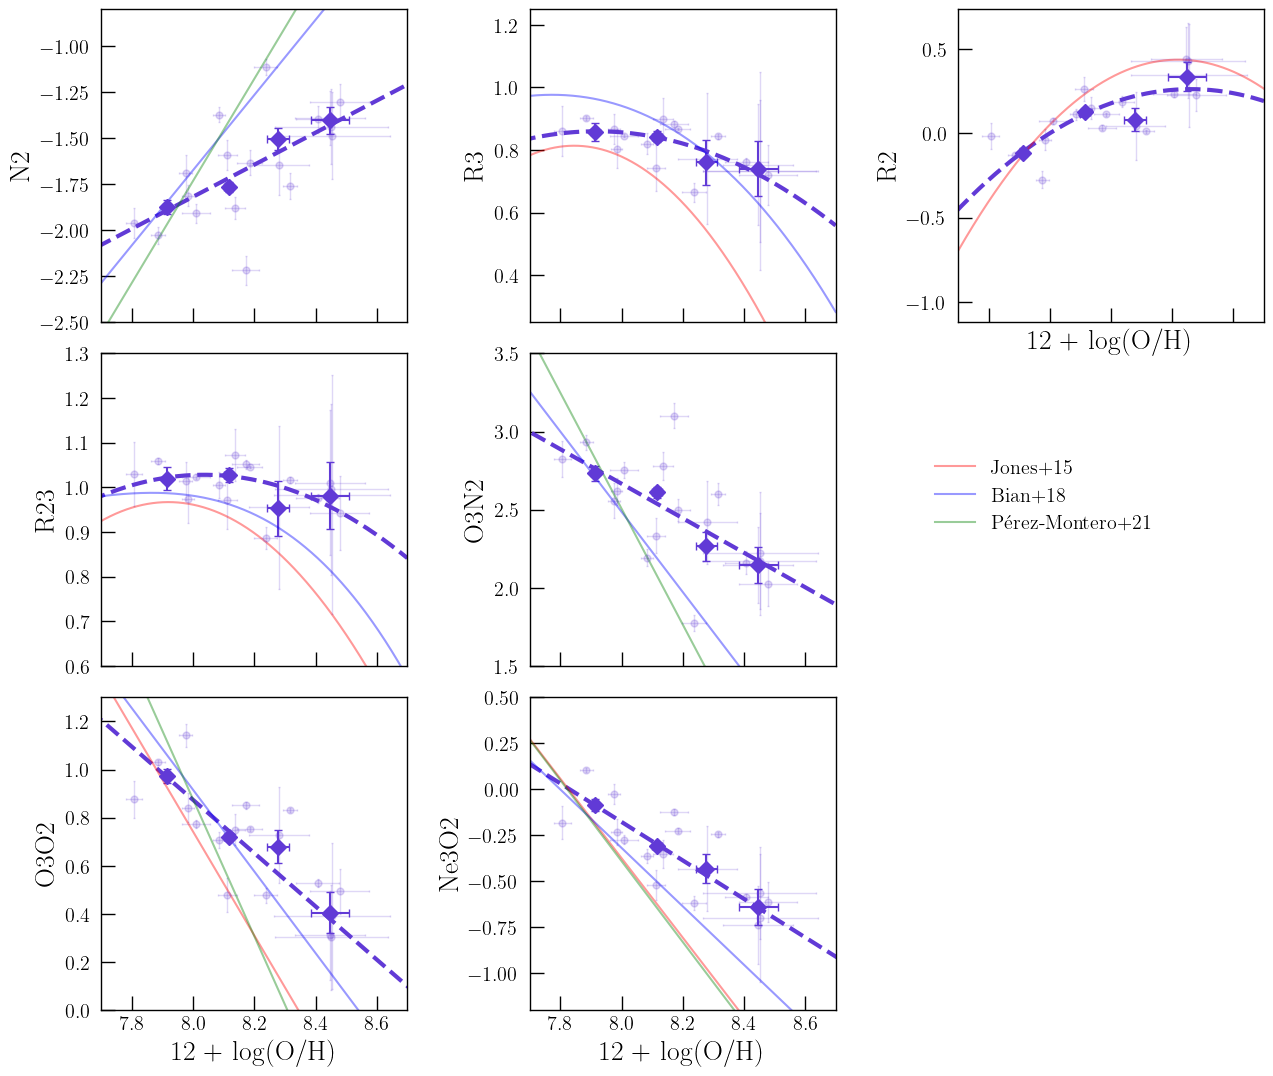

In [16]:
texPlot('on')
fig, axs = plt.subplots(3, 3, sharex=True)
fig.set_size_inches((15, 13))
fig.subplots_adjust(wspace=0.4, hspace=0.1)

# ===========================================================================================================
# N2
# ===========================================================================================================

axs[0, 0].errorbar(metals['log_OH'], upy.nominal_values(N2), xerr=metals['log_OH_err'], yerr=upy.std_devs(N2), 
                  marker='o', capsize=1, elinewidth=1, markersize=5, ls='', color=c[2], alpha=0.2)
axs[0, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 0].plot((N2_tp * out_N2_med.params['a1'].value) + out_N2_med.params['a0'].value, N2_tp,
               color=c[2], ls='--', lw=3)

axs[0, 0].plot(log_OH_tp, bian2018(log_OH_tp, 'N2'), label='Bian+2018', color='blue', alpha=0.4)
axs[0, 0].plot(log_OH_tp, perez_montero2021(log_OH_tp, 'N2'), label='Pérez-Montero+2021', color='green', alpha=0.4)
axs[0, 0].set_ylabel('N2')

# ===========================================================================================================
# R3
# ===========================================================================================================

axs[0, 1].errorbar(metals['log_OH'], upy.nominal_values(R3), xerr=metals['log_OH_err'], yerr=upy.std_devs(R3), 
                  marker='o', capsize=1, elinewidth=1, markersize=5, ls='', color=c[2], alpha=0.2)
axs[0, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R3),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_R3),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 1].plot(log_OH_tp, poly2(log_OH_tp, *out_R3_med), color=c[2], ls='--', lw=3)

axs[0, 1].plot(log_OH_tp, jones2015(log_OH_tp, 'R3'), label='Jones+2015', color='red', alpha=0.4)
axs[0, 1].plot(log_OH_tp, bian2018(log_OH_tp, 'R3'), label='Bian+2018', color='blue', alpha=0.4)
axs[0, 1].set_ylabel('R3')

# ===========================================================================================================
# R2
# ===========================================================================================================

axs[0, 2].errorbar(metals['log_OH'], upy.nominal_values(R2), xerr=metals['log_OH_err'], yerr=upy.std_devs(R2), 
                  marker='o', capsize=1, elinewidth=1, markersize=5, ls='', color=c[2], alpha=0.2)
axs[0, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_R2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 2].plot(log_OH_tp, poly2(log_OH_tp, *out_R2_med), color=c[2], ls='--', lw=3)

axs[0, 2].plot(log_OH_tp, jones2015(log_OH_tp, 'R2'), label='Jones+2015', color='red', alpha=0.4)
axs[0, 2].set_ylabel('R2')


# ===========================================================================================================
# R23
# ===========================================================================================================

axs[1, 0].errorbar(metals['log_OH'], upy.nominal_values(R23), xerr=metals['log_OH_err'], yerr=upy.std_devs(R23), 
                  marker='o', capsize=1, elinewidth=1, markersize=5, ls='', color=c[2], alpha=0.2)
axs[1, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R23),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_R23),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 0].plot(log_OH_tp, poly2(log_OH_tp, *out_R23_med), color=c[2], ls='--', lw=3)

axs[1, 0].plot(log_OH_tp, jones2015(log_OH_tp, 'R23'), label='Jones+2015', color='red', alpha=0.4)
axs[1, 0].plot(log_OH_tp, bian2018(log_OH_tp, 'R23'), label='Bian+2018', color='blue', alpha=0.4)
axs[1, 0].set_ylabel('R23')

# ===========================================================================================================
# O3N2
# ===========================================================================================================

axs[1, 1].errorbar(metals['log_OH'], upy.nominal_values(O3N2), xerr=metals['log_OH_err'], yerr=upy.std_devs(O3N2), 
                  marker='o', capsize=1, elinewidth=1, markersize=5, ls='', color=c[2], alpha=0.2)
axs[1, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3N2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_O3N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 1].plot((O3N2_tp * out_O3N2_med.params['a1'].value) + out_O3N2_med.params['a0'].value, O3N2_tp,
               color=c[2], ls='--', lw=3)

axs[1, 1].plot(log_OH_tp, bian2018(log_OH_tp, 'O3N2'), label='Bian+2018', color='blue', alpha=0.4)
axs[1, 1].plot(log_OH_tp, perez_montero2021(log_OH_tp, 'O3N2'), label='Pérez-Montero+2021', color='green', alpha=0.4)
axs[1, 1].set_ylabel('O3N2')


# ===========================================================================================================
# O3O2
# ===========================================================================================================

axs[2, 0].errorbar(metals['log_OH'], upy.nominal_values(O3O2), xerr=metals['log_OH_err'], yerr=upy.std_devs(O3O2), 
                  marker='o', capsize=1, elinewidth=1, markersize=5, ls='', color=c[2], alpha=0.2)
axs[2, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3O2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_O3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 0].plot((O3O2_tp * out_O3O2_med.params['a1'].value) + out_O3O2_med.params['a0'].value, O3O2_tp,
               color=c[2], ls='--', lw=3)

axs[2, 0].plot(log_OH_tp, jones2015(log_OH_tp, 'O3O2'), label='Jones+2015', color='red', alpha=0.4)
axs[2, 0].plot(log_OH_tp, bian2018(log_OH_tp, 'O3O2'), label='Bian+2018', color='blue', alpha=0.4)
axs[2, 0].plot(log_OH_tp, perez_montero2021(log_OH_tp, 'O3O2'), label='Pérez-Montero+2021', color='green', alpha=0.4)
axs[2, 0].set_ylabel('O3O2')

# ===========================================================================================================
# Ne3O2
# ===========================================================================================================

axs[2, 1].errorbar(metals['log_OH'], upy.nominal_values(Ne3O2), xerr=metals['log_OH_err'], yerr=upy.std_devs(Ne3O2), 
                  marker='o', capsize=1, elinewidth=1, markersize=5, ls='', color=c[2], alpha=0.2)
axs[2, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_Ne3O2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_Ne3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 1].plot((Ne3O2_tp * out_Ne3O2_med.params['a1'].value) + out_Ne3O2_med.params['a0'].value, Ne3O2_tp,
               color=c[2], ls='--', lw=3)

axs[2, 1].plot(log_OH_tp, jones2015(log_OH_tp, 'Ne3O2'), label='Jones+15', color='red', alpha=0.4)
axs[2, 1].plot(log_OH_tp, bian2018(log_OH_tp, 'Ne3O2'), label='Bian+18', color='blue', alpha=0.4)
axs[2, 1].plot(log_OH_tp, perez_montero2021(log_OH_tp, 'Ne3O2'), label='Pérez-Montero+21', color='green', alpha=0.4)
axs[2, 1].legend(frameon=False, loc=(1.3, 1.5))
axs[2, 1].set_ylabel('Ne3O2')


# ===========================================================================================================
# General settings
# ===========================================================================================================

axs[2, 0].set_xlabel(r'12 + log(O/H)')
axs[2, 1].set_xlabel(r'12 + log(O/H)')
axs[0, 2].set_xlabel(r'12 + log(O/H)')

# limits

# x
axs[0, 0].set_xlim(7.7, 8.7) # N2 (Shared)

# y
axs[0, 0].set_ylim(-2.5, -0.8) # N2
axs[0, 1].set_ylim(0.25, 1.25) # R3

axs[1, 0].set_ylim(0.6, 1.3) # R23
axs[1, 1].set_ylim(1.5, 3.5) # O3N2

axs[2, 0].set_ylim(0, 1.3) # O3O2
axs[2, 1].set_ylim(-1.2, 0.5) # Ne3O2

axs[1, 2].axis('off')
axs[2, 2].axis('off')

# Setting tick params

axs[0, 0].tick_params(axis="y", direction="in", length=10)
axs[0, 0].tick_params(axis="x", direction="in", length=10)

axs[0, 1].tick_params(axis="y", direction="in", length=10)
axs[0, 1].tick_params(axis="x", direction="in", length=10)

axs[0, 2].tick_params(axis="y", direction="in", length=10)
axs[0, 2].tick_params(axis="x", direction="in", length=10)

axs[1, 0].tick_params(axis="y", direction="in", length=10)
axs[1, 0].tick_params(axis="x", direction="in", length=10)

axs[1, 1].tick_params(axis="y", direction="in", length=10)
axs[1, 1].tick_params(axis="x", direction="in", length=10)


axs[2, 0].tick_params(axis="y", direction="in", length=10)
axs[2, 0].tick_params(axis="x", direction="in", length=10)

axs[2, 1].tick_params(axis="y", direction="in", length=10)
axs[2, 1].tick_params(axis="x", direction="in", length=10)
#fig.savefig(magePath+'analysis/chapter4/calbration_vs_analogs.pdf', bbox_inches='tight')

## Photoionization models

In [17]:
def dopita2016_N2S2(log_OH_12):
    N2S2 = (log_OH_12 - 8.77)
    return N2S2


def strom2018(log_OH_12, ratio='asd'):
    if ratio == 'R23':
        return - (((log_OH_12 - 8.24)**2) - 0.85) / 0.87
    if ratio == 'N2':
        return (log_OH_12 - 8.77) / 0.34
    if ratio == 'O3N2':
        return  - (log_OH_12 - 8.75) /0.21


def papovich2022_R23(log_OH_12):
    log_Z0 = 8.228
    log_R0 = 1.041
    A = -1.07
    return A * ((log_OH_12 - log_Z0)**2) + log_R0


def garg2023_z_0(SEL, ratio='asd'):
    if ratio == 'N2':
        a0 = -13.9
        a1 = 1.918
        a2 = -0.046
    if ratio == 'R3':
        a0 = -57.889
        a1 = 14.552
        a2 = -0.905
    if ratio == 'R2':
        a0 = -43.87
        a1 = 10.558
        a2 = -0.632
    if ratio == 'R23':
        a0 = -47.251
        a1 = 11.872
        a2 = -0.732
    if ratio == 'O3N2':
        a0 = -45.251
        a1 = 12.947
        a2 = -0.878
    if ratio == 'R3N2':
        a0 = -49.279
        a1 = 13.895
        a2 = -0.941
    if ratio == 'N2O2':
        a0 = 34.201
        a1 = -9.642
        a2 = 0.652
    if ratio == 'O3O2':
        a0 = -15.091
        a1 = 4.258
        a2 = -0.289
    if ratio == 'Ne3O2':
        a0 = 3.986
        a1 = -0.877
        a2 = 0.035
    if ratio == 'S2':
        a0 = -28.699
        a1 = 6.227
        a2 = -0.347
    if ratio == 'O3S2':
        a0 = -29.935
        a1 = 8.511
        a2 = -0.57
    if ratio == 'N2S2':
        a0 = 11.406
        a1 = -3.871
        a2 = 0.292
    return a0 + (a1 * SEL) + (a2 * (SEL**2))

def garg2023_z_2(SEL, ratio='asd'):
    if ratio == 'N2':
        a0 = 16.247
        a1 = -5.606
        a2 = 0.42
    if ratio == 'R3':
        a0 = -41.669
        a1 = 10.511
        a2 = -0.653
    if ratio == 'R2':
        a0 = -21.727
        a1 = 4.973
        a2 = -0.281
    if ratio == 'R23':
        a0 = -34.364
        a1 = 8.641
        a2 = -0.53
    if ratio == 'O3N2':
        a0 = -57.392
        a1 = 15.982
        a2 = -1.064
    if ratio == 'R3N2':
        a0 = -64.199
        a1 = 17.678
        a2 = -1.177
    if ratio == 'N2O2':
        a0 = 44.395
        a1 = -12.176
        a2 = 0.808
    if ratio == 'O3O2':
        a0 = -19.924
        a1 = 5.534
        a2 = -0.371
    if ratio == 'Ne3O2':
        a0 = -14.735
        a1 = 3.814
        a2 = -0.258
    if ratio == 'S2':
        a0 = -1.276
        a1 = -0.78
        a2 = 0.098
    if ratio == 'O3S2':
        a0 = -39.426
        a1 = 11.041
        a2 = -0.735
    if ratio == 'N2S2':
        a0 = 21.596
        a1 = -6.25
        a2 = 0.429
    return a0 + (a1 * SEL) + (a2 * (SEL**2))

def garg2023_z_5(SEL, ratio='asd'):
    if ratio == 'N2':
        a0 = 6.902
        a1 = -3.176
        a2 = 0.261
    if ratio == 'R3':
        a0 = -24.688
        a1 = 6.118
        a2 = -0.369
    if ratio == 'R2':
        a0 = -19.95
        a1 = 4.556
        a2 = -0.258
    if ratio == 'R23':
        a0 = -23.269
        a1 = 5.776
        a2 = -0.346
    if ratio == 'O3N2':
        a0 = -31.59
        a1 = 9.294
        a2 = -0.63
    if ratio == 'R3N2':
        a0 = -35.253
        a1 = 10.157
        a2 = -0.688
    if ratio == 'N2O2':
        a0 = 30.515
        a1 = -8.595
        a2 = 0.577
    if ratio == 'O3O2':
        a0 = -4.737
        a1 = 1.562
        a2 = -0.111
    if ratio == 'Ne3O2':
        a0 = -6.314
        a1 = 1.597
        a2 = -0.112
    if ratio == 'S2':
        a0 = -10.901
        a1 = 1.8
        a2 = -0.076
    if ratio == 'O3S2':
        a0 = -13.787
        a1 = 4.318
        a2 = -0.293
    if ratio == 'N2S2':
        a0 = 19.625
        a1 = -5.814
        a2 = 0.406
    return a0 + (a1 * SEL) + (a2 * (SEL**2))

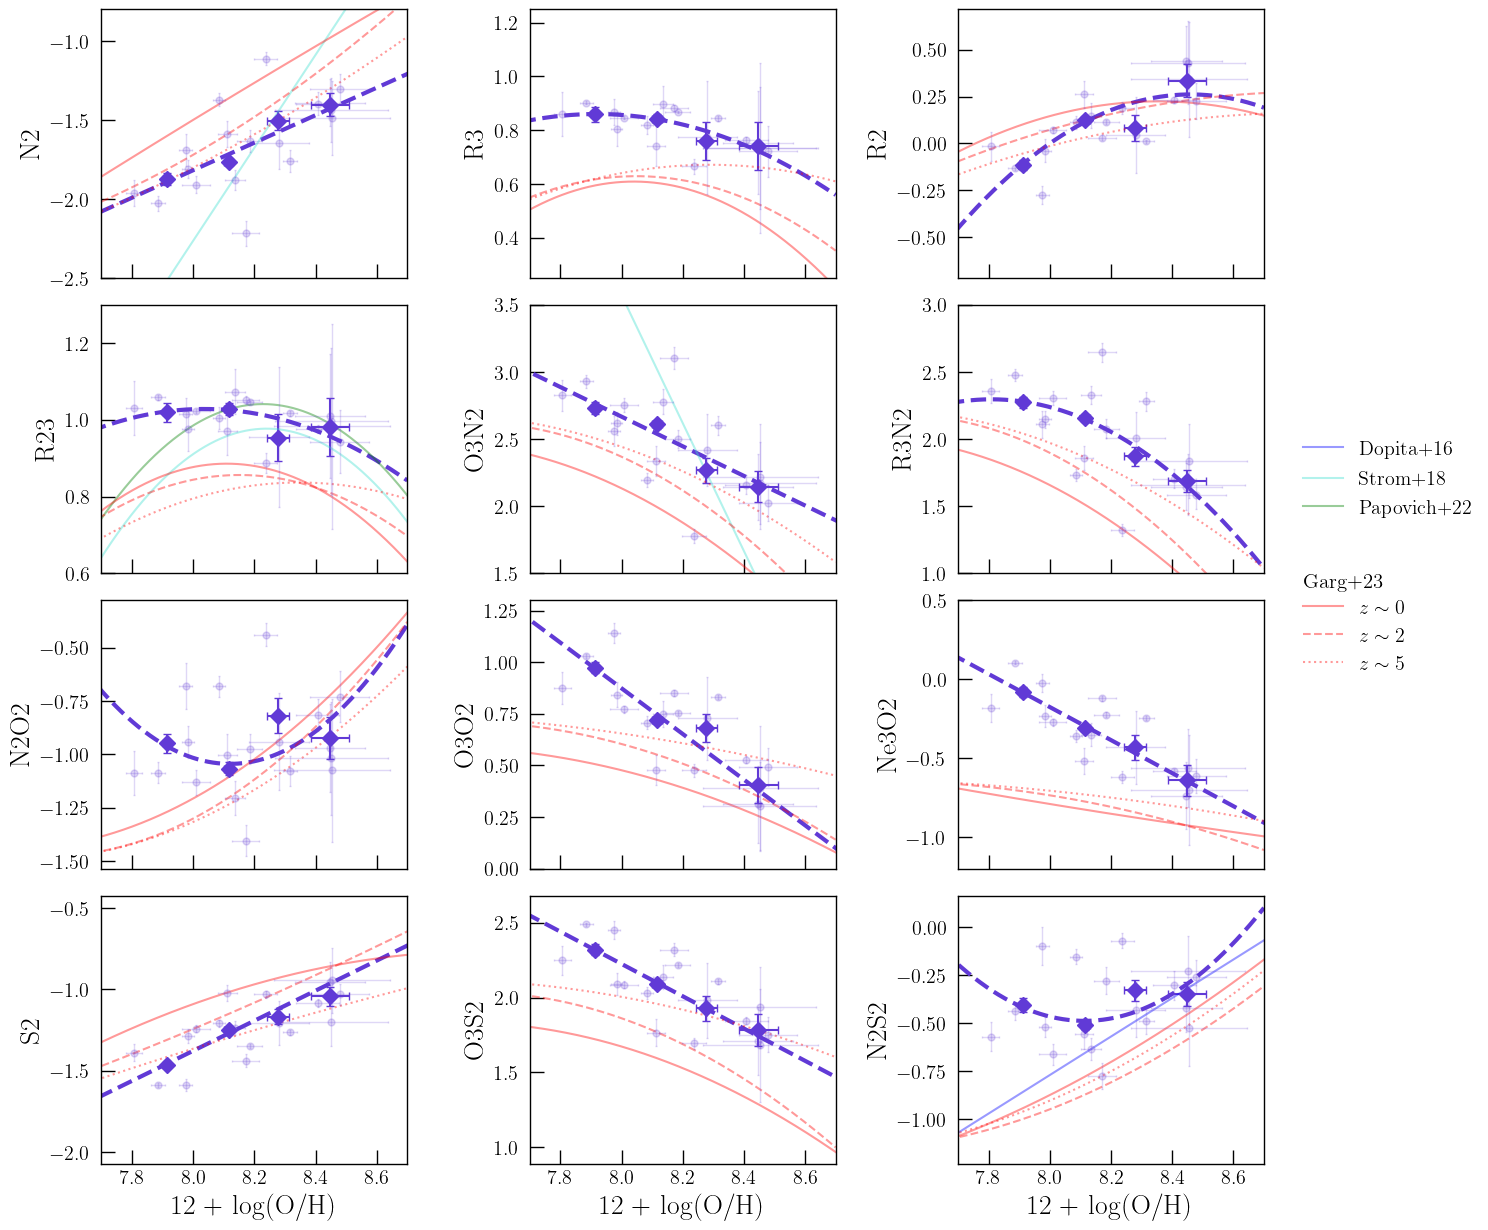

In [18]:
texPlot('on')
fig, axs = plt.subplots(4, 3, sharex=True)
fig.set_size_inches((15, 15))
fig.subplots_adjust(wspace=0.4, hspace=0.1)

# ===========================================================================================================
# N2
# ===========================================================================================================

axs[0, 0].errorbar(metals['log_OH'], upy.nominal_values(N2), xerr=metals['log_OH_err'], yerr=upy.std_devs(N2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 0].plot((N2_tp * out_N2_med.params['a1'].value) + out_N2_med.params['a0'].value, N2_tp,
               color=c[2], ls='--', lw=3)

axs[0, 0].plot(log_OH_tp, strom2018(log_OH_tp, 'N2'), color='turquoise', alpha=0.4)
axs[0, 0].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'N2'), label=r'$z \sim 0$', color='red', alpha=0.4)
axs[0, 0].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'N2'), label=r'$z \sim 2$', color='red', alpha=0.4, ls='--')
axs[0, 0].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'N2'), label=r'$z \sim 5$', color='red', alpha=0.4, ls=':')
axs[0, 0].set_ylabel('N2')

# ===========================================================================================================
# R3
# ===========================================================================================================

axs[0, 1].errorbar(metals['log_OH'], upy.nominal_values(R3), xerr=metals['log_OH_err'], yerr=upy.std_devs(R3), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R3),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_R3),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 1].plot(log_OH_tp, poly2(log_OH_tp, *out_R3_med), color=c[2], ls='--', lw=3)

axs[0, 1].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'R3'), color='red', alpha=0.4)
axs[0, 1].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'R3'), color='red', alpha=0.4, ls='--')
axs[0, 1].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'R3'), color='red', alpha=0.4, ls=':')
axs[0, 1].set_ylabel('R3')

# ===========================================================================================================
# R2
# ===========================================================================================================

axs[0, 2].errorbar(metals['log_OH'], upy.nominal_values(R2), xerr=metals['log_OH_err'], yerr=upy.std_devs(R2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[0, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_R2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[0, 2].plot(log_OH_tp, poly2(log_OH_tp, *out_R2_med), color=c[2], ls='--', lw=3)

axs[0, 2].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'R2'), color='red', alpha=0.4)
axs[0, 2].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'R2'), color='red', alpha=0.4, ls='--')
axs[0, 2].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'R2'), color='red', alpha=0.4, ls=':')
axs[0, 2].set_ylabel('R2')


# ===========================================================================================================
# R23
# ===========================================================================================================

axs[1, 0].errorbar(metals['log_OH'], upy.nominal_values(R23), xerr=metals['log_OH_err'], yerr=upy.std_devs(R23), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[1, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R23),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_R23),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 0].plot(log_OH_tp, poly2(log_OH_tp, *out_R23_med), color=c[2], ls='--', lw=3)

axs[1, 0].plot(log_OH_tp, strom2018(log_OH_tp, 'R23'), label='Strom+18', color='turquoise', alpha=0.4)
axs[1, 0].plot(log_OH_tp, papovich2022_R23(log_OH_tp), label='Papovich+22', color='green', alpha=0.4)
axs[1, 0].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'R23'), color='red', alpha=0.4)
axs[1, 0].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'R23'), color='red', alpha=0.4, ls='--')
axs[1, 0].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'R23'), color='red', alpha=0.4, ls=':')
axs[1, 0].set_ylabel('R23')

# ===========================================================================================================
# O3N2
# ===========================================================================================================

axs[1, 1].errorbar(metals['log_OH'], upy.nominal_values(O3N2), xerr=metals['log_OH_err'], yerr=upy.std_devs(O3N2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[1, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3N2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_O3N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 1].plot((O3N2_tp * out_O3N2_med.params['a1'].value) + out_O3N2_med.params['a0'].value, O3N2_tp,
               color=c[2], ls='--', lw=3)

axs[1, 1].plot(log_OH_tp, strom2018(log_OH_tp, 'O3N2'), label='Strom+2018', color='turquoise', alpha=0.4)
axs[1, 1].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'O3N2'), color='red', alpha=0.4)
axs[1, 1].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'O3N2'), color='red', alpha=0.4, ls='--')
axs[1, 1].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'O3N2'), color='red', alpha=0.4, ls=':')
axs[1, 1].set_ylabel('O3N2')

# ===========================================================================================================
# R3N2
# ===========================================================================================================

axs[1, 2].errorbar(metals['log_OH'], upy.nominal_values(R3N2), xerr=metals['log_OH_err'], yerr=upy.std_devs(R3N2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[1, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_R3N2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_R3N2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[1, 2].plot(log_OH_tp, poly2(log_OH_tp, *out_R3N2_med), color=c[2], ls='--', lw=3)

axs[1, 2].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'R3N2'), color='red', alpha=0.4)
axs[1, 2].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'R3N2'), color='red', alpha=0.4, ls='--')
axs[1, 2].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'R3N2'), color='red', alpha=0.4, ls=':')
axs[1, 2].set_ylabel('R3N2')


# ===========================================================================================================
# N2O2
# ===========================================================================================================

axs[2, 0].errorbar(metals['log_OH'], upy.nominal_values(N2O2), xerr=metals['log_OH_err'], yerr=upy.std_devs(N2O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[2, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2O2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_N2O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 0].plot(log_OH_tp, poly2(log_OH_tp, *out_N2O2_med), color=c[2], ls='--', lw=3)

axs[2, 0].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'N2O2'), color='red', alpha=0.4)
axs[2, 0].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'N2O2'), color='red', alpha=0.4, ls='--')
axs[2, 0].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'N2O2'), color='red', alpha=0.4, ls=':')
axs[2, 0].set_ylabel('N2O2')

# ===========================================================================================================
# O3O2
# ===========================================================================================================

axs[2, 1].errorbar(metals['log_OH'], upy.nominal_values(O3O2), xerr=metals['log_OH_err'], yerr=upy.std_devs(O3O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[2, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3O2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_O3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 1].plot((O3O2_tp * out_O3O2_med.params['a1'].value) + out_O3O2_med.params['a0'].value, O3O2_tp,
               color=c[2], ls='--', lw=3)

axs[2, 1].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'O3O2'), color='red', alpha=0.4)
axs[2, 1].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'O3O2'), color='red', alpha=0.4, ls='--')
axs[2, 1].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'O3O2'), color='red', alpha=0.4, ls=':')
axs[2, 1].set_ylabel('O3O2')

# ===========================================================================================================
# Ne3O2
# ===========================================================================================================

axs[2, 2].errorbar(metals['log_OH'], upy.nominal_values(Ne3O2), xerr=metals['log_OH_err'], yerr=upy.std_devs(Ne3O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[2, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_Ne3O2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_Ne3O2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[2, 2].plot((Ne3O2_tp * out_Ne3O2_med.params['a1'].value) + out_Ne3O2_med.params['a0'].value, Ne3O2_tp,
               color=c[2], ls='--', lw=3)

axs[2, 2].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'Ne3O2'), color='red', alpha=0.4)
axs[2, 2].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'Ne3O2'), color='red', alpha=0.4, ls='--')
axs[2, 2].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'Ne3O2'), color='red', alpha=0.4, ls=':')
axs[2, 2].set_ylabel('Ne3O2')

# ===========================================================================================================
# S2
# ===========================================================================================================

axs[3, 0].errorbar(metals['log_OH'], upy.nominal_values(S2), xerr=metals['log_OH_err'], yerr=upy.std_devs(S2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[3, 0].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_S2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_S2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[3, 0].plot((S2_tp * out_S2_med.params['a1'].value) + out_S2_med.params['a0'].value, S2_tp,
               color=c[2], ls='--', lw=3)

axs[3, 0].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'S2'), color='red', alpha=0.4)
axs[3, 0].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'S2'), color='red', alpha=0.4, ls='--')
axs[3, 0].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'S2'), color='red', alpha=0.4, ls=':')
axs[3, 0].set_ylabel('S2')

# ===========================================================================================================
# O3S2
# ===========================================================================================================

axs[3, 1].errorbar(metals['log_OH'], upy.nominal_values(O3S2), xerr=metals['log_OH_err'], yerr=upy.std_devs(O3S2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[3, 1].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_O3S2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_O3S2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[3, 1].plot((O3S2_tp * out_O3S2_med.params['a1'].value) + out_O3S2_med.params['a0'].value, O3S2_tp,
               color=c[2], ls='--', lw=3)

axs[3, 1].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'O3S2'), color='red', alpha=0.4)
axs[3, 1].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'O3S2'), color='red', alpha=0.4, ls='--')
axs[3, 1].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'O3S2'), color='red', alpha=0.4, ls=':')
axs[3, 1].set_ylabel('O3S2')

# ===========================================================================================================
# N2S2
# ===========================================================================================================

axs[3, 2].errorbar(metals['log_OH'], upy.nominal_values(N2S2), xerr=metals['log_OH_err'], yerr=upy.std_devs(N2S2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, alpha=0.2)
axs[3, 2].errorbar(upy.nominal_values(bin_OH), upy.nominal_values(bin_N2S2),
                   xerr=upy.std_devs(bin_OH), yerr=upy.std_devs(bin_N2S2),
                   ls='', color=c[2], capsize=3, marker='D', markersize=8)
axs[3, 2].plot(log_OH_tp, poly2(log_OH_tp, *out_N2S2_med), color=c[2], ls='--', lw=3)

axs[3, 2].plot(log_OH_tp, dopita2016_N2S2(log_OH_tp), label='Dopita+16', color='blue', alpha=0.4)
axs[3, 2].plot(log_OH_tp, garg2023_z_0(log_OH_tp, 'N2S2'), color='red', alpha=0.4)
axs[3, 2].plot(log_OH_tp, garg2023_z_2(log_OH_tp, 'N2S2'), color='red', alpha=0.4, ls='--')
axs[3, 2].plot(log_OH_tp, garg2023_z_5(log_OH_tp, 'N2S2'), color='red', alpha=0.4, ls=':')
axs[3, 2].set_ylabel('N2S2')

# ===========================================================================================================
# General settings
# ===========================================================================================================

axs[3, 0].set_xlabel(r'12 + log(O/H)')
axs[3, 1].set_xlabel(r'12 + log(O/H)')
axs[3, 2].set_xlabel(r'12 + log(O/H)')

# limits
# x
axs[0, 0].set_xlim(7.7, 8.7) 

# y
axs[0, 0].set_ylim(-2.5, -0.8) # N2
axs[0, 1].set_ylim(0.25, 1.25) # R3

axs[1, 0].set_ylim(0.6, 1.3) # R23
axs[1, 1].set_ylim(1.5, 3.5) # O3N2
axs[1, 2].set_ylim(1, 3) # R3N2

axs[2, 1].set_ylim(0, 1.3) # O3O2
axs[2, 2].set_ylim(-1.2, 0.5) # Ne3O2

# Legends
axs[0, 0].legend(frameon=False, loc=(3.9, -1.5))
axs[1, 0].legend(frameon=False, loc=(3.9, 0.18))
axs[1, 2].text(8.83, 0.9, 'Garg+23', fontsize=15)
axs[3, 2].legend(frameon=False, loc=(1.1, 2.6))

index_model = [0, 1, 2, 3]
index_sec = [0, 1, 2]
for i in index_model:
    for j in index_sec:
        axs[i, j].tick_params(axis="y", direction="in", length=10)
        axs[i, j].tick_params(axis="x", direction="in", length=10)
        
#fig.savefig(magePath+'analysis/chapter4/calbration_vs_models.pdf', bbox_inches='tight')

## Scatter and table of params

In [19]:
metal_array = upy.uarray(metals['log_OH'], metals['log_OH_err'])

# Linear predicts

N2_predict = out_N2_med.params['a0'].value + (bin_N2 * out_N2_med.params['a1'].value)
O3N2_predict = out_O3N2_med.params['a0'].value + (bin_O3N2 * out_O3N2_med.params['a1'].value)
O3O2_predict = out_O3O2_med.params['a0'].value + (bin_O3O2 * out_O3O2_med.params['a1'].value)
Ne3O2_predict = out_Ne3O2_med.params['a0'].value + (bin_Ne3O2 * out_Ne3O2_med.params['a1'].value)
S2_predict = out_S2_med.params['a0'].value + (bin_S2 * out_S2_med.params['a1'].value)
O3S2_predict = out_O3S2_med.params['a0'].value + (bin_O3S2 * out_O3S2_med.params['a1'].value)

# Non-linear predicts

R2_predict = poly2(bin_OH, *out_R2_med)
R3_predict = poly2(bin_OH, *out_R3_med)
R23_predict = poly2(bin_OH, *out_R23_med)
R3N2_predict = poly2(bin_OH, *out_R3N2_med)
N2O2_predict = poly2(bin_OH, *out_N2O2_med)
N2S2_predict = poly2(bin_OH, *out_N2S2_med)

In [20]:
# Scatters

sigma_N2 = np.std(upy.nominal_values((N2_predict - bin_OH)))
sigma_O3N2 = np.std(upy.nominal_values((O3N2_predict - bin_OH)))
sigma_O3O2 = np.std(upy.nominal_values((O3O2_predict - bin_OH)))
sigma_Ne3O2 = np.std(upy.nominal_values((Ne3O2_predict - bin_OH)))
sigma_S2 = np.std(upy.nominal_values((S2_predict - bin_OH)))
sigma_O3S2 = np.std(upy.nominal_values((O3S2_predict - bin_OH)))

sigma_R2 = np.std(upy.nominal_values(R2_predict - bin_R2))
sigma_R3 = np.std(upy.nominal_values(R3_predict - bin_R3))
sigma_R23 = np.std(upy.nominal_values(R23_predict - bin_R23))
sigma_R3N2 = np.std(upy.nominal_values(R3N2_predict - bin_R3N2))
sigma_N2O2 = np.std(upy.nominal_values(N2O2_predict - bin_N2O2))
sigma_N2S2 = np.std(upy.nominal_values(N2S2_predict - bin_N2S2))

In [21]:
calib_dict = {'Ratio': ['N2', 'R2', 'R3', 'R23', 'O3N2', 'R3N2', 'N2O2', 'O3O2', 'Ne3O2', 'S2', 'O3S2', 'N2S2'],
             'a0': [out_N2_med.params['a0'].value, out_R2_med[0], out_R3_med[0], out_R23_med[0],
                    out_O3N2_med.params['a0'].value, out_R3N2_med[0], out_N2O2_med[0],
                    out_O3O2_med.params['a0'].value, out_Ne3O2_med.params['a0'].value, out_S2_med.params['a0'].value,
                    out_O3S2_med.params['a0'].value, out_N2S2_med[0]],
             'a1': [out_N2_med.params['a1'].value, out_R2_med[1], out_R3_med[1], out_R23_med[1],
                    out_O3N2_med.params['a1'].value, out_R3N2_med[1], out_N2O2_med[1],
                    out_O3O2_med.params['a1'].value, out_Ne3O2_med.params['a1'].value, out_S2_med.params['a1'].value,
                    out_O3S2_med.params['a1'].value, out_N2S2_med[1]],
             'a2': [None, out_R2_med[2], out_R3_med[2], out_R23_med[2],
                    None, out_R3N2_med[2], out_N2O2_med[2],
                    None, None, None,
                    None, out_N2S2_med[2]],
              'sigma': [sigma_N2, sigma_R2, sigma_R3, sigma_R23, sigma_O3N2, sigma_R3N2,
                        sigma_N2O2, sigma_O3O2, sigma_Ne3O2, sigma_S2, sigma_O3S2, sigma_N2S2]
}

calib_dict_pd = pd.DataFrame(data=calib_dict, index=None)
calib_dict_pd.to_latex(index=None, float_format='%.3f')

'\\begin{tabular}{llrrrr}\n\\toprule\n & Ratio & a0 & a1 & a2 & sigma \\\\\n\\midrule\n0 & N2 & 10.090 & 1.149 & NaN & 0.050 \\\\\n1 & R2 & -88.104 & 20.889 & -1.235 & 0.078 \\\\\n2 & R3 & -30.024 & 7.801 & -0.493 & 0.020 \\\\\n3 & R23 & -26.215 & 6.781 & -0.422 & 0.027 \\\\\n4 & O3N2 & 10.418 & -0.907 & NaN & 0.054 \\\\\n5 & R3N2 & -94.409 & 24.767 & -1.586 & 0.042 \\\\\n6 & N2O2 & 127.138 & -31.572 & 1.944 & 0.097 \\\\\n7 & O3O2 & 8.790 & -0.905 & NaN & 0.047 \\\\\n8 & Ne3O2 & 7.831 & -0.957 & NaN & 0.016 \\\\\n9 & S2 & 9.492 & 1.083 & NaN & 0.042 \\\\\n10 & O3S2 & 10.061 & -0.926 & NaN & 0.018 \\\\\n11 & N2S2 & 112.162 & -27.766 & 1.711 & 0.061 \\\\\n\\bottomrule\n\\end{tabular}\n'

### Local relations predictions

In [22]:
# ===========================================================================================================
# N2
# ===========================================================================================================

OH_from_N2_denicolo = (upy.nominal_values(bin_N2) * 0.73) + 9.12
OH_from_N2_marino = (upy.nominal_values(bin_N2) * 0.462) + 8.743
OH_from_N2_PP = pettini_pagel2004_N2(upy.nominal_values(bin_N2))
N2_from_OH_nagao = nagao2006(upy.nominal_values(bin_OH), ratio='N2')
N2_from_OH_maiolino = maiolino2008(upy.nominal_values(bin_OH), ratio='N2')
N2_from_OH_curti = curti2020(upy.nominal_values(bin_OH), ratio='N2')
N2_from_OH_sanders = sanders2021(upy.nominal_values(bin_OH), ratio='N2')

N2_labels = np.array(['Denicolo', 'Marino', 'Pettini', 'Nagao', 'Maiolino', 'Curti', 'Sanders'])
N2_scatters = np.array([np.mean(OH_from_N2_denicolo - upy.nominal_values(bin_OH)),
                        np.mean(OH_from_N2_marino - upy.nominal_values(bin_OH)),
                        np.mean(OH_from_N2_PP - upy.nominal_values(bin_OH)),
                        np.mean(N2_from_OH_nagao - upy.nominal_values(bin_N2)),
                        np.mean(N2_from_OH_maiolino - upy.nominal_values(bin_N2)),
                        np.mean(N2_from_OH_curti - upy.nominal_values(bin_N2)),
                        np.mean(N2_from_OH_sanders - upy.nominal_values(bin_N2)),
])

# ===========================================================================================================
# R2
# ===========================================================================================================

R2_from_OH_maiolino = maiolino2008(upy.nominal_values(bin_OH), ratio='R2')
R2_from_OH_curti = curti2020(upy.nominal_values(bin_OH), ratio='R2')
R2_from_OH_sanders = sanders2021(upy.nominal_values(bin_OH), ratio='R2')

R2_labels = np.array(['Maiolino', 'Curti', 'Sanders'])
R2_scatters = np.array([np.mean(R2_from_OH_maiolino - upy.nominal_values(bin_R2)),
                        np.mean(R2_from_OH_curti - upy.nominal_values(bin_R2)),
                        np.mean(R2_from_OH_sanders - upy.nominal_values(bin_R2))
])

# ===========================================================================================================
# R3
# ===========================================================================================================

R3_from_OH_maiolino = maiolino2008(upy.nominal_values(bin_OH), ratio='R3')
R3_from_OH_curti = curti2020(upy.nominal_values(bin_OH), ratio='R3')
R3_from_OH_sanders = sanders2021(upy.nominal_values(bin_OH), ratio='R3')

R3_labels = np.array(['Maiolino', 'Curti', 'Sanders'])
R3_scatters = np.array([np.mean(R3_from_OH_maiolino - upy.nominal_values(bin_R3)),
                        np.mean(R3_from_OH_curti - upy.nominal_values(bin_R3)),
                        np.mean(R3_from_OH_sanders - upy.nominal_values(bin_R3))
])

# ===========================================================================================================
# R23
# ===========================================================================================================

OH_from_R23_tremonti = tremonti2004_R23(upy.nominal_values(bin_R23))
R23_from_OH_nagao = nagao2006(upy.nominal_values(bin_OH), ratio='R23')
R23_from_OH_maiolino = maiolino2008(upy.nominal_values(bin_OH), ratio='R23')
R23_from_OH_curti = curti2020(upy.nominal_values(bin_OH), ratio='R23')
R23_from_OH_sanders = sanders2021(upy.nominal_values(bin_OH), ratio='R23')

R23_labels = np.array(['Tremonti', 'Nagao', 'Maiolino', 'Curti', 'Sanders'])
R23_scatters = np.array([np.mean(OH_from_R23_tremonti - upy.nominal_values(bin_OH)),
                         np.mean(R23_from_OH_nagao - upy.nominal_values(bin_R23)),
                         np.mean(R23_from_OH_maiolino - upy.nominal_values(bin_R23)),
                         np.mean(R23_from_OH_curti - upy.nominal_values(bin_R23)),
                         np.mean(R23_from_OH_sanders - upy.nominal_values(bin_R23)),
])

# ===========================================================================================================
# R3N2
# ===========================================================================================================

R3N2_from_OH_nagao = nagao2006(upy.nominal_values(bin_OH), ratio='R3N2')
R3N2_from_OH_maiolino = maiolino2008(upy.nominal_values(bin_OH), ratio='R3N2')

R3N2_labels = np.array(['Nagao', 'Maiolino'])
R3N2_scatters = np.array([np.mean(R3N2_from_OH_nagao - upy.nominal_values(bin_R3N2)),
                          np.mean(R3N2_from_OH_maiolino - upy.nominal_values(bin_R3N2))
])

# ===========================================================================================================
# O3N2
# ===========================================================================================================

OH_from_O3N2_PP = (upy.nominal_values(bin_O3N2) * -0.32) + 8.73
OH_from_O3N2_marino = (upy.nominal_values(bin_O3N2) * -0.214) + 8.533
O3N2_from_OH_curti = curti2020(upy.nominal_values(bin_OH), ratio='O3N2')
O3N2_from_OH_sanders = sanders2021(upy.nominal_values(bin_OH), ratio='O3N2')

O3N2_labels = np.array(['Pettini', 'Marino', 'Curti', 'Sanders'])
O3N2_scatters = np.array([np.mean(OH_from_O3N2_PP - upy.nominal_values(bin_OH)),
                          np.mean(OH_from_O3N2_marino - upy.nominal_values(bin_OH)),
                          np.mean(O3N2_from_OH_curti - upy.nominal_values(bin_O3N2)),
                          np.mean(O3N2_from_OH_sanders - upy.nominal_values(bin_O3N2))
])

# ===========================================================================================================
# N2O2
# ===========================================================================================================

N2O2_from_OH_nagao = nagao2006(upy.nominal_values(bin_OH), ratio='N2O2')

N2O2_scatters = np.mean(N2O2_from_OH_nagao - upy.nominal_values(bin_N2O2))

# ===========================================================================================================
# O3O2
# ===========================================================================================================

O3O2_from_OH_nagao = nagao2006(upy.nominal_values(bin_OH), ratio='O3O2')
O3O2_from_OH_maiolino = maiolino2008(upy.nominal_values(bin_OH), ratio='O3O2')
O3O2_from_OH_curti = curti2020(upy.nominal_values(bin_OH), ratio='O3O2')
O3O2_from_OH_sanders = sanders2021(upy.nominal_values(bin_OH), ratio='O3O2')

O3O2_labels = np.array(['Nagao', 'Maiolino', 'Curti', 'Sanders'])
O3O2_scatters = np.array([np.mean(O3O2_from_OH_nagao - upy.nominal_values(bin_O3O2)),
                        np.mean(O3O2_from_OH_maiolino - upy.nominal_values(bin_O3O2)),
                        np.mean(O3O2_from_OH_curti - upy.nominal_values(bin_O3O2)),
                        np.mean(O3O2_from_OH_sanders - upy.nominal_values(bin_O3O2)),
])

# ===========================================================================================================
# Ne3O2
# ===========================================================================================================

Ne3O2_from_OH_maiolino = maiolino2008(upy.nominal_values(bin_OH), ratio='Ne3O2')

Ne3O2_scatters = np.mean(Ne3O2_from_OH_maiolino - upy.nominal_values(bin_Ne3O2))

In [23]:
print('Best local N2 relation: ', N2_labels[np.argmin(N2_scatters)], 'with sigma =',
      round(np.abs(N2_scatters[np.argmin(N2_scatters)]), 3))
print('Best local R2 relation: ', R2_labels[np.argmin(R2_scatters)], 'with sigma =',
      round(np.abs(R2_scatters[np.argmin(R2_scatters)]), 3))
print('Best local R3 relation: ', R3_labels[np.argmin(R3_scatters)], 'with sigma =',
      round(np.abs(R3_scatters[np.argmin(R3_scatters)]), 3))
print('Best local R23 relation: ', R23_labels[np.argmin(R23_scatters)], 'with sigma =',
      round(np.abs(R23_scatters[np.argmin(R23_scatters)]), 3))
print('Best local O3N2 relation: ', O3N2_labels[np.argmin(O3N2_scatters)], 'with sigma =',
      round(np.abs(O3N2_scatters[np.argmin(O3N2_scatters)]), 3))
print('Best local R3N2 relation: ', R3N2_labels[np.argmin(R3N2_scatters)], 'with sigma =',
      round(np.abs(R3N2_scatters[np.argmin(R3N2_scatters)]), 3))
print('Only local N2O2 relation: ', 'Nagao', 'with sigma =', 
     round(np.abs(N2O2_scatters), 3))
print('Best local O3O2 relation: ', O3O2_labels[np.argmin(O3O2_scatters)], 'with sigma =',
      round(np.abs(O3O2_scatters[np.argmin(O3O2_scatters)]), 3))
print('Only local Ne3O2 relation: ', 'Maiolino', 'with sigma =', 
     round(np.abs(Ne3O2_scatters), 3))

Best local N2 relation:  Denicolo with sigma = 0.264
Best local R2 relation:  Curti with sigma = 0.143
Best local R3 relation:  Sanders with sigma = 0.262
Best local R23 relation:  Sanders with sigma = 0.184
Best local O3N2 relation:  Sanders with sigma = 0.609
Best local R3N2 relation:  Nagao with sigma = 0.611
Only local N2O2 relation:  Nagao with sigma = 0.25
Best local O3O2 relation:  Sanders with sigma = 0.488
Only local Ne3O2 relation:  Maiolino with sigma = 0.394


### Other analogs predictions

In [24]:
# ===========================================================================================================
# N2
# ===========================================================================================================

OH_from_N2_pm = (upy.nominal_values(bin_N2) * 0.361) + 8.625
OH_from_N2_bian = (upy.nominal_values(bin_N2) * 0.49) + 8.82

N2_an_labels = np.array(['Perez-Montero', 'Bian'])
N2_an_scatters = np.array([np.mean(OH_from_N2_pm - upy.nominal_values(bin_OH)),
                        np.mean(OH_from_N2_bian - upy.nominal_values(bin_OH))
])

# ===========================================================================================================
# R2
# ===========================================================================================================

R2_from_OH_jones = jones2015(upy.nominal_values(bin_OH), ratio='R2')

R2_an_labels = np.array(['Jones'])
R2_an_scatters = np.array([np.mean(R2_from_OH_jones - upy.nominal_values(bin_R2))
])

# ===========================================================================================================
# R3
# ===========================================================================================================

R3_from_OH_bian = bian2018(upy.nominal_values(bin_OH), ratio='R3')
R3_from_OH_jones = jones2015(upy.nominal_values(bin_OH), ratio='R3')

R3_an_labels = np.array(['Bian', 'Jones'])
R3_an_scatters = np.array([np.mean(R3_from_OH_bian - upy.nominal_values(bin_R3)),
                        np.mean(R3_from_OH_jones - upy.nominal_values(bin_R3))
])

# ===========================================================================================================
# R23
# ===========================================================================================================

R23_from_OH_bian = bian2018(upy.nominal_values(bin_OH), ratio='R23')
R23_from_OH_jones = jones2015(upy.nominal_values(bin_OH), ratio='R23')

R23_an_labels = np.array(['Bian', 'Jones'])
R23_an_scatters = np.array([np.mean(R23_from_OH_bian - upy.nominal_values(bin_R23)),
                        np.mean(R23_from_OH_jones - upy.nominal_values(bin_R23))
])

# ===========================================================================================================
# O3N2
# ===========================================================================================================

OH_from_O3N2_pm = (upy.nominal_values(bin_O3N2) * -0.27) + 8.677
OH_from_O3N2_bian = (upy.nominal_values(bin_O3N2) * -0.39) + 8.97

O3N2_an_labels = np.array(['Perez-Montero', 'Bian'])
O3N2_an_scatters = np.array([np.mean(OH_from_O3N2_pm - upy.nominal_values(bin_OH)),
                        np.mean(OH_from_O3N2_bian - upy.nominal_values(bin_OH))
])

# ===========================================================================================================
# O3O2
# ===========================================================================================================

OH_from_O3O2_pm = (upy.nominal_values(bin_O3O2) * -0.352) + 8.308
OH_from_O3O2_bian = (upy.nominal_values(bin_O3O2) * -0.59) + 8.54
OH_from_O3O2_jones = (upy.nominal_values(bin_O3O2) - 17.9828) / -2.1552

O3O2_an_labels = np.array(['Perez-Montero', 'Bian', 'Jones'])
O3O2_an_scatters = np.array([np.mean(OH_from_O3O2_pm - upy.nominal_values(bin_OH)),
                          np.mean(OH_from_O3O2_bian - upy.nominal_values(bin_OH)),
                          np.mean(OH_from_O3O2_jones - upy.nominal_values(bin_OH))
])

# ===========================================================================================================
# Ne3O2
# ===========================================================================================================

OH_from_Ne3O2_pm = (upy.nominal_values(bin_Ne3O2) * -0.455) + 7.823
OH_from_Ne3O2_bian = (upy.nominal_values(bin_Ne3O2) * -0.63) + 7.8
OH_from_Ne3O2_jones = (upy.nominal_values(bin_O3O2) - 16.8974) / -2.1588

Ne3O2_an_labels = np.array(['Perez-Montero', 'Bian', 'Jones'])
Ne3O2_an_scatters = np.array([np.mean(OH_from_Ne3O2_pm - upy.nominal_values(bin_OH)),
                          np.mean(OH_from_Ne3O2_bian - upy.nominal_values(bin_OH)),
                          np.mean(OH_from_Ne3O2_jones - upy.nominal_values(bin_OH))
])

In [25]:
print('Best analogs N2 relation: ', N2_an_labels[np.argmin(N2_an_scatters)], 'with sigma =',
      round(np.abs(N2_an_scatters[np.argmin(N2_an_scatters)]), 3))
print('Best analogs R2 relation: ', R2_an_labels[np.argmin(R2_an_scatters)], 'with sigma =',
      round(np.abs(R2_an_scatters[np.argmin(R2_an_scatters)]), 3))
print('Only analogs R3 relation: ', R3_an_labels[np.argmin(R3_an_scatters)], 'with sigma =',
      round(np.abs(R3_an_scatters[np.argmin(R3_an_scatters)]), 3))
print('Best analogs R23 relation: ', R23_an_labels[np.argmin(R23_an_scatters)], 'with sigma =',
      round(np.abs(R23_an_scatters[np.argmin(R23_an_scatters)]), 3))
print('Best analogs O3N2 relation: ', O3N2_an_labels[np.argmin(O3N2_an_scatters)], 'with sigma =',
      round(np.abs(O3N2_an_scatters[np.argmin(O3N2_an_scatters)]), 3))
print('Best analogs O3O2 relation: ', O3O2_an_labels[np.argmin(O3O2_an_scatters)], 'with sigma =',
      round(np.abs(O3O2_an_scatters[np.argmin(O3O2_an_scatters)]), 3))
print('Best analogs Ne3O2 relation: ', Ne3O2_an_labels[np.argmin(Ne3O2_an_scatters)], 'with sigma =',
      round(np.abs(Ne3O2_an_scatters[np.argmin(Ne3O2_an_scatters)]), 3))

Best analogs N2 relation:  Bian with sigma = 0.171
Best analogs R2 relation:  Jones with sigma = 0.128
Only analogs R3 relation:  Jones with sigma = 0.214
Best analogs R23 relation:  Jones with sigma = 0.127
Best analogs O3N2 relation:  Perez-Montero with sigma = 0.17
Best analogs O3O2 relation:  Jones with sigma = 0.167
Best analogs Ne3O2 relation:  Jones with sigma = 0.683


### Models predictions

In [26]:
# ===========================================================================================================
# N2
# ===========================================================================================================

OH_from_N2_strom = (upy.nominal_values(bin_N2) * 0.34) + 8.77
N2_from_OH_garg0 = garg2023_z_0(upy.nominal_values(bin_OH), ratio='N2')
N2_from_OH_garg2 = garg2023_z_2(upy.nominal_values(bin_OH), ratio='N2')
N2_from_OH_garg5 = garg2023_z_5(upy.nominal_values(bin_OH), ratio='N2')

N2_mod_labels = np.array(['Strom', 'Garg z=0', 'Garg z=2', 'Garg z=5'])
N2_mod_scatters = np.array([np.mean(OH_from_N2_strom - upy.nominal_values(bin_OH)),
                            np.mean(N2_from_OH_garg0 - upy.nominal_values(bin_N2)),
                            np.mean(N2_from_OH_garg2 - upy.nominal_values(bin_N2)),
                            np.mean(N2_from_OH_garg5 - upy.nominal_values(bin_N2))
])

# ===========================================================================================================
# R2
# ===========================================================================================================

R2_from_OH_garg0 = garg2023_z_0(upy.nominal_values(bin_OH), ratio='R2')
R2_from_OH_garg2 = garg2023_z_2(upy.nominal_values(bin_OH), ratio='R2')
R2_from_OH_garg5 = garg2023_z_5(upy.nominal_values(bin_OH), ratio='R2')

R2_mod_labels = np.array(['Garg z=0', 'Garg z=2', 'Garg z=5'])
R2_mod_scatters = np.array([np.mean(R2_from_OH_garg0 - upy.nominal_values(bin_R2)),
                            np.mean(R2_from_OH_garg2 - upy.nominal_values(bin_R2)),
                            np.mean(R2_from_OH_garg5 - upy.nominal_values(bin_R2))
])

# ===========================================================================================================
# R3
# ===========================================================================================================


R3_from_OH_garg0 = garg2023_z_0(upy.nominal_values(bin_OH), ratio='R3')
R3_from_OH_garg2 = garg2023_z_2(upy.nominal_values(bin_OH), ratio='R3')
R3_from_OH_garg5 = garg2023_z_5(upy.nominal_values(bin_OH), ratio='R3')

R3_mod_labels = np.array(['Garg z=0', 'Garg z=2', 'Garg z=5'])
R3_mod_scatters = np.array([np.mean(R3_from_OH_garg0 - upy.nominal_values(bin_R3)),
                            np.mean(R3_from_OH_garg2 - upy.nominal_values(bin_R3)),
                            np.mean(R3_from_OH_garg5 - upy.nominal_values(bin_R3))
])

# ===========================================================================================================
# R23
# ===========================================================================================================

R23_from_OH_strom = strom2018(upy.nominal_values(bin_OH), ratio='R23')
OH_from_R23_papovich = np.sqrt((upy.nominal_values(bin_R23) - 1.041) / -1.07) + 8.228
R23_from_OH_garg0 = garg2023_z_0(upy.nominal_values(bin_OH), ratio='R23')
R23_from_OH_garg2 = garg2023_z_2(upy.nominal_values(bin_OH), ratio='R23')
R23_from_OH_garg5 = garg2023_z_5(upy.nominal_values(bin_OH), ratio='R23')

R23_mod_labels = np.array(['Strom', 'Papovich', 'Garg z=0', 'Garg z=2', 'Garg z=5'])
R23_mod_scatters = np.array([np.mean(R23_from_OH_strom - upy.nominal_values(bin_R23)),
                             np.mean(OH_from_R23_papovich - upy.nominal_values(bin_OH)),
                             np.mean(R23_from_OH_garg0 - upy.nominal_values(bin_R23)),
                             np.mean(R23_from_OH_garg2 - upy.nominal_values(bin_R23)),
                             np.mean(R23_from_OH_garg5 - upy.nominal_values(bin_R23))
])

# ===========================================================================================================
# O3N2
# ===========================================================================================================

OH_from_O3N2_strom = (upy.nominal_values(bin_O3N2) * -0.21) + 8.75
O3N2_from_OH_garg0 = garg2023_z_0(upy.nominal_values(bin_OH), ratio='O3N2')
O3N2_from_OH_garg2 = garg2023_z_2(upy.nominal_values(bin_OH), ratio='O3N2')
O3N2_from_OH_garg5 = garg2023_z_5(upy.nominal_values(bin_OH), ratio='O3N2')

O3N2_mod_labels = np.array(['Strom', 'Garg z=0', 'Garg z=2', 'Garg z=5'])
O3N2_mod_scatters = np.array([np.mean(OH_from_O3N2_strom - upy.nominal_values(bin_OH)),
                              np.mean(O3N2_from_OH_garg0 - upy.nominal_values(bin_O3N2)),
                              np.mean(O3N2_from_OH_garg2 - upy.nominal_values(bin_O3N2)),
                              np.mean(O3N2_from_OH_garg5 - upy.nominal_values(bin_O3N2))
])

# ===========================================================================================================
# R3N2
# ===========================================================================================================

R3N2_from_OH_garg0 = garg2023_z_0(upy.nominal_values(bin_OH), ratio='R3N2')
R3N2_from_OH_garg2 = garg2023_z_2(upy.nominal_values(bin_OH), ratio='R3N2')
R3N2_from_OH_garg5 = garg2023_z_5(upy.nominal_values(bin_OH), ratio='R3N2')

R3N2_mod_labels = np.array(['Garg z=0', 'Garg z=2', 'Garg z=5'])
R3N2_mod_scatters = np.array([np.mean(R3N2_from_OH_garg0 - upy.nominal_values(bin_R3N2)),
                              np.mean(R3N2_from_OH_garg2 - upy.nominal_values(bin_R3N2)),
                              np.mean(R3N2_from_OH_garg5 - upy.nominal_values(bin_R3N2))
])

# ===========================================================================================================
# N2O2
# ===========================================================================================================

N2O2_from_OH_garg0 = garg2023_z_0(upy.nominal_values(bin_OH), ratio='N2O2')
N2O2_from_OH_garg2 = garg2023_z_2(upy.nominal_values(bin_OH), ratio='N2O2')
N2O2_from_OH_garg5 = garg2023_z_5(upy.nominal_values(bin_OH), ratio='N2O2')

N2O2_mod_labels = np.array(['Garg z=0', 'Garg z=2', 'Garg z=5'])
N2O2_mod_scatters = np.array([np.mean(N2O2_from_OH_garg0 - upy.nominal_values(bin_N2O2)),
                              np.mean(N2O2_from_OH_garg2 - upy.nominal_values(bin_N2O2)),
                              np.mean(N2O2_from_OH_garg5 - upy.nominal_values(bin_N2O2))
])

# ===========================================================================================================
# O3O2
# ===========================================================================================================

O3O2_from_OH_garg0 = garg2023_z_0(upy.nominal_values(bin_OH), ratio='O3O2')
O3O2_from_OH_garg2 = garg2023_z_2(upy.nominal_values(bin_OH), ratio='O3O2')
O3O2_from_OH_garg5 = garg2023_z_5(upy.nominal_values(bin_OH), ratio='O3O2')

O3O2_mod_labels = np.array(['Garg z=0', 'Garg z=2', 'Garg z=5'])
O3O2_mod_scatters = np.array([np.mean(O3O2_from_OH_garg0 - upy.nominal_values(bin_O3O2)),
                              np.mean(O3O2_from_OH_garg2 - upy.nominal_values(bin_O3O2)),
                              np.mean(O3O2_from_OH_garg5 - upy.nominal_values(bin_O3O2))
])

# ===========================================================================================================
# Ne3O2
# ===========================================================================================================

Ne3O2_from_OH_garg0 = garg2023_z_0(upy.nominal_values(bin_OH), ratio='Ne3O2')
Ne3O2_from_OH_garg2 = garg2023_z_2(upy.nominal_values(bin_OH), ratio='Ne3O2')
Ne3O2_from_OH_garg5 = garg2023_z_5(upy.nominal_values(bin_OH), ratio='Ne3O2')

Ne3O2_mod_labels = np.array(['Garg z=0', 'Garg z=2', 'Garg z=5'])
Ne3O2_mod_scatters = np.array([np.mean(Ne3O2_from_OH_garg0 - upy.nominal_values(bin_Ne3O2)),
                               np.mean(Ne3O2_from_OH_garg2 - upy.nominal_values(bin_Ne3O2)),
                               np.mean(Ne3O2_from_OH_garg5 - upy.nominal_values(bin_Ne3O2))
])

# ===========================================================================================================
# S2
# ===========================================================================================================

S2_from_OH_garg0 = garg2023_z_0(upy.nominal_values(bin_OH), ratio='S2')
S2_from_OH_garg2 = garg2023_z_2(upy.nominal_values(bin_OH), ratio='S2')
S2_from_OH_garg5 = garg2023_z_5(upy.nominal_values(bin_OH), ratio='S2')

S2_mod_labels = np.array(['Garg z=0', 'Garg z=2', 'Garg z=5'])
S2_mod_scatters = np.array([np.mean(S2_from_OH_garg0 - upy.nominal_values(bin_S2)),
                            np.mean(S2_from_OH_garg2 - upy.nominal_values(bin_S2)),
                            np.mean(S2_from_OH_garg5 - upy.nominal_values(bin_S2))
])

# ===========================================================================================================
# O3S2
# ===========================================================================================================

O3S2_from_OH_garg0 = garg2023_z_0(upy.nominal_values(bin_OH), ratio='O3S2')
O3S2_from_OH_garg2 = garg2023_z_2(upy.nominal_values(bin_OH), ratio='O3S2')
O3S2_from_OH_garg5 = garg2023_z_5(upy.nominal_values(bin_OH), ratio='O3S2')

O3S2_mod_labels = np.array(['Garg z=0', 'Garg z=2', 'Garg z=5'])
O3S2_mod_scatters = np.array([np.mean(O3S2_from_OH_garg0 - upy.nominal_values(bin_O3S2)),
                              np.mean(O3S2_from_OH_garg2 - upy.nominal_values(bin_O3S2)),
                              np.mean(O3S2_from_OH_garg5 - upy.nominal_values(bin_O3S2))
])

# ===========================================================================================================
# N2S2
# ===========================================================================================================

OH_from_N2S2_dopita = upy.nominal_values(bin_N2) + 8.77
N2S2_from_OH_garg0 = garg2023_z_0(upy.nominal_values(bin_OH), ratio='N2S2')
N2S2_from_OH_garg2 = garg2023_z_2(upy.nominal_values(bin_OH), ratio='N2S2')
N2S2_from_OH_garg5 = garg2023_z_5(upy.nominal_values(bin_OH), ratio='N2S2')

N2S2_mod_labels = np.array(['Dopita', 'Garg z=0', 'Garg z=2', 'Garg z=5'])
N2S2_mod_scatters = np.array([np.mean(N2S2_from_OH_garg0 - upy.nominal_values(bin_N2S2)),
                              np.mean(N2S2_from_OH_garg2 - upy.nominal_values(bin_N2S2)),
                              np.mean(N2S2_from_OH_garg5 - upy.nominal_values(bin_N2S2))
])

In [27]:
print('Best models N2 relation: ', N2_mod_labels[np.argmin(N2_mod_scatters)], 'with sigma =',
      round(np.abs(N2_mod_scatters[np.argmin(N2_mod_scatters)]), 3))
print('Best models R2 relation: ', R2_mod_labels[np.argmin(R2_mod_scatters)], 'with sigma =',
      round(np.abs(R2_mod_scatters[np.argmin(R2_mod_scatters)]), 3))
print('Best models R3 relation: ', R3_mod_labels[np.argmin(R3_mod_scatters)], 'with sigma =',
      round(np.abs(R3_mod_scatters[np.argmin(R3_mod_scatters)]), 3))
print('Best models R23 relation: ', R23_mod_labels[np.argmin(R23_mod_scatters)], 'with sigma =',
      round(np.abs(R23_mod_scatters[np.argmin(R23_mod_scatters)]), 3))
print('Best models O3N2 relation: ', O3N2_mod_labels[np.argmin(O3N2_mod_scatters)], 'with sigma =',
      round(np.abs(O3N2_mod_scatters[np.argmin(O3N2_mod_scatters)]), 3))
print('Best models R3N2 relation: ', R3N2_mod_labels[np.argmin(R3N2_mod_scatters)], 'with sigma =',
      round(np.abs(R3N2_mod_scatters[np.argmin(R3N2_mod_scatters)]), 3))
print('Best models N2O2 relation: ', N2O2_mod_labels[np.argmin(N2O2_mod_scatters)], 'with sigma =',
      round(np.abs(N2O2_mod_scatters[np.argmin(N2O2_mod_scatters)]), 3))
print('Best models O3O2 relation: ', O3O2_mod_labels[np.argmin(O3O2_mod_scatters)], 'with sigma =',
      round(np.abs(O3O2_mod_scatters[np.argmin(O3O2_mod_scatters)]), 3))
print('Best models Ne3O2 relation: ', Ne3O2_mod_labels[np.argmin(Ne3O2_mod_scatters)], 'with sigma =',
      round(np.abs(Ne3O2_mod_scatters[np.argmin(Ne3O2_mod_scatters)]), 3))
print('Best models S2 relation: ', S2_mod_labels[np.argmin(S2_mod_scatters)], 'with sigma =',
      round(np.abs(S2_mod_scatters[np.argmin(S2_mod_scatters)]), 3))
print('Best models O3S2 relation: ', O3S2_mod_labels[np.argmin(O3S2_mod_scatters)], 'with sigma =',
      round(np.abs(O3S2_mod_scatters[np.argmin(O3S2_mod_scatters)]), 3))
print('Best models N2S2 relation: ', N2S2_mod_labels[np.argmin(N2S2_mod_scatters)], 'with sigma =',
      round(np.abs(N2S2_mod_scatters[np.argmin(N2S2_mod_scatters)]), 3))

Best models N2 relation:  Strom with sigma = 0.025
Best models R2 relation:  Garg z=5 with sigma = 0.059
Best models R3 relation:  Garg z=0 with sigma = 0.248
Best models R23 relation:  Garg z=5 with sigma = 0.181
Best models O3N2 relation:  Garg z=0 with sigma = 0.578
Best models R3N2 relation:  Garg z=0 with sigma = 0.629
Best models N2O2 relation:  Garg z=5 with sigma = 0.214
Best models O3O2 relation:  Garg z=0 with sigma = 0.308
Best models Ne3O2 relation:  Garg z=0 with sigma = 0.482
Best models S2 relation:  Garg z=5 with sigma = 0.029
Best models O3S2 relation:  Garg z=0 with sigma = 0.516
Best models N2S2 relation:  Garg z=0 with sigma = 0.401


## Comparison with high z measurements

In [28]:
r23 = upy.uarray([0.15, 0.90, 0.26], [0.07, 0.10, 0.08]) + upy.uarray([3.08, 8.29, 7.11], [0.13, 0.21, 0.24])
ne3o2 = upy.uarray([0.17, 0.45, 0.50], [0.03, 0.03, 0.04]) / upy.uarray([0.15, 0.90, 0.26], [0.07, 0.10, 0.08])
o3o2 = upy.uarray([3.08, 8.29, 7.11], [0.13, 0.21, 0.24]) / upy.uarray([0.15, 0.90, 0.26], [0.07, 0.10, 0.08])

Curti_dict = {
    'R2': upy.log10(upy.uarray([0.15, 0.90, 0.26], [0.07, 0.10, 0.08])),
    'R3': upy.log10(upy.uarray([3.08, 8.29, 7.11], [0.13, 0.21, 0.24])),
    'R23': upy.log10(r23),
    'O3O2': upy.log10(o3o2),
    'Ne3O2': upy.log10(ne3o2),
    '12_log_OH': upy.uarray([7.25, 7.53, 7.50], [0.21, 0.08, 0.12])
}

def sanders2023(log_OH_12, ratio='asd'):
    x = (log_OH_12 - 8.0)
    if ratio == 'R2':
        c0 = 0.067
        c1 = 1.069
        c2 = 0.0
    if ratio == 'R3':
        c0 = 0.834
        c1 = -0.072
        c2 = -0.453
    if ratio == 'R23':
        c0 = 1.017
        c1 = 0.026
        c2 = -0.331
    if ratio == 'O3O2':
        c0 = 0.723
        c1 = -1.153
        c2 = 0.0
    if ratio == 'Ne3O2':
        c0 = -0.386
        c1 = -0.998
        c2 = 0.0
    return c0 + (c1 * x) + (c2 * (x**2))

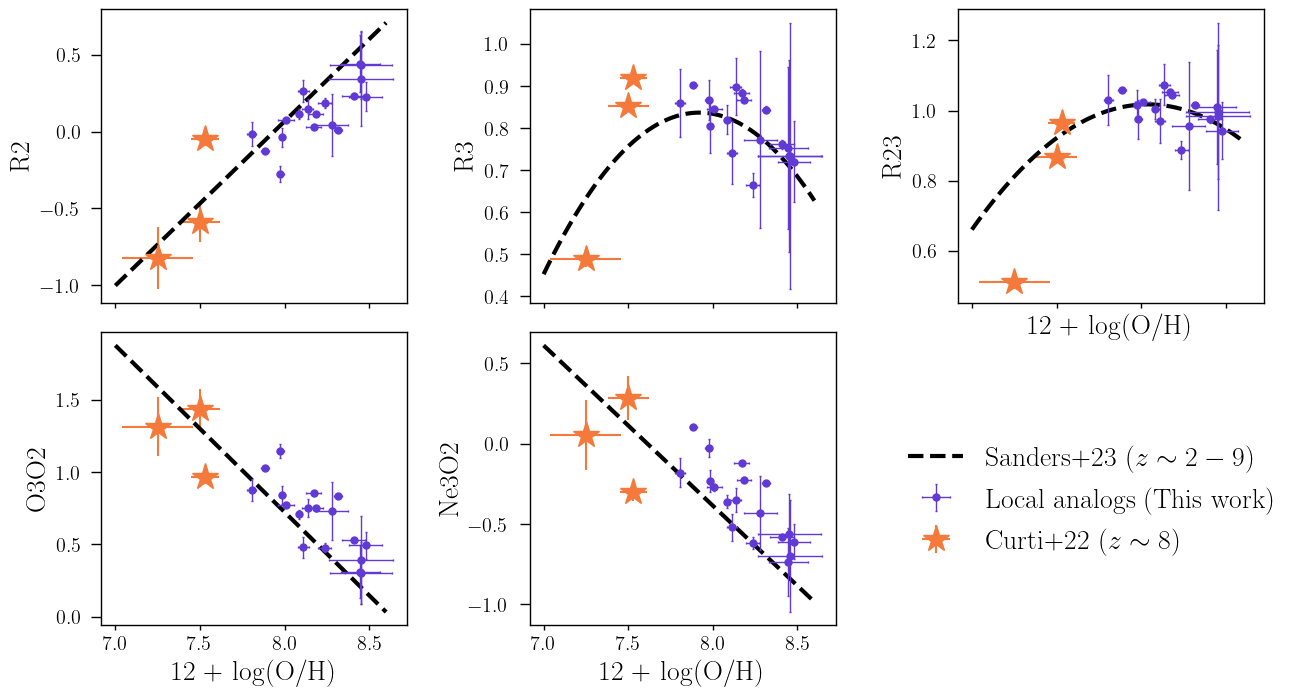

In [29]:
texPlot('on')
fig, axs = plt.subplots(2, 3, sharex=True)
fig.set_size_inches((15, 8))
fig.subplots_adjust(wspace=0.4, hspace=0.1)

# Utils

log_OH_ext = np.linspace(7.0, 8.6, 100)

# ===========================================================================================================
# R2
# ===========================================================================================================

axs[0, 0].errorbar(metals['log_OH'], upy.nominal_values(R2), xerr=metals['log_OH_err'], yerr=upy.std_devs(R2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100)
#axs[0, 0].errorbar(log_OH_med, R2_med, xerr=log_OH_med_err, yerr=R2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[0, 0].errorbar(upy.nominal_values(Curti_dict['12_log_OH']), upy.nominal_values(Curti_dict['R2']),
                  xerr=upy.std_devs(Curti_dict['12_log_OH']), yerr=upy.std_devs(Curti_dict['R2']),
                  ls='', markersize=20, marker='*', color=cz[0])


axs[0, 0].plot(log_OH_ext, sanders2023(log_OH_ext, 'R2'), color='black', ls='--', lw=3)
axs[0, 0].set_ylabel('R2')

# ===========================================================================================================
# R3
# ===========================================================================================================

axs[0, 1].errorbar(metals['log_OH'], upy.nominal_values(R3), xerr=metals['log_OH_err'], yerr=upy.std_devs(R3), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100)
#axs[0, 1].errorbar(log_OH_med, R3_med, xerr=log_OH_med_err, yerr=R3_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[0, 1].errorbar(upy.nominal_values(Curti_dict['12_log_OH']), upy.nominal_values(Curti_dict['R3']),
                  xerr=upy.std_devs(Curti_dict['12_log_OH']), yerr=upy.std_devs(Curti_dict['R3']),
                  ls='', markersize=20, marker='*', color=cz[0])

axs[0, 1].plot(log_OH_ext, sanders2023(log_OH_ext, 'R3'), color='black', ls='--', lw=3)
axs[0, 1].set_ylabel('R3')

# ===========================================================================================================
# R23
# ===========================================================================================================

axs[0, 2].errorbar(metals['log_OH'], upy.nominal_values(R23), xerr=metals['log_OH_err'], yerr=upy.std_devs(R23), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100, label='Local analogs (This work)')
#axs[0, 2].errorbar(log_OH_med, R23_med, xerr=log_OH_med_err, yerr=R23_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8, label='Local analogs (This work)')

axs[0, 2].errorbar(upy.nominal_values(Curti_dict['12_log_OH']), upy.nominal_values(Curti_dict['R23']),
                  xerr=upy.std_devs(Curti_dict['12_log_OH']), yerr=upy.std_devs(Curti_dict['R23']),
                  ls='', markersize=20, marker='*', color=cz[0], label=r'Curti+22 ($z \sim 8$)')

axs[0, 2].plot(log_OH_ext, sanders2023(log_OH_ext, 'R23'), label='Sanders+23 ($z \sim 2 - 9$)',
               color='black', ls='--', lw=3)

axs[0, 2].set_ylabel('R23')

axs[1, 2].axis('off')


# ===========================================================================================================
# O3O2
# ===========================================================================================================

axs[1, 0].errorbar(metals['log_OH'], upy.nominal_values(O3O2), xerr=metals['log_OH_err'], yerr=upy.std_devs(O3O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100)
#axs[1, 0].errorbar(log_OH_med, O3O2_med, xerr=log_OH_med_err, yerr=O3O2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[1, 0].errorbar(upy.nominal_values(Curti_dict['12_log_OH']), upy.nominal_values(Curti_dict['O3O2']),
                  xerr=upy.std_devs(Curti_dict['12_log_OH']), yerr=upy.std_devs(Curti_dict['O3O2']),
                  ls='', markersize=20, marker='*', color=cz[0])

axs[1, 0].plot(log_OH_ext, sanders2023(log_OH_ext, 'O3O2'), color='black', ls='--', lw=3)

axs[1, 0].set_ylabel('O3O2')

# ===========================================================================================================
# Ne3O2
# ===========================================================================================================

axs[1, 1].errorbar(metals['log_OH'], upy.nominal_values(Ne3O2), xerr=metals['log_OH_err'], yerr=upy.std_devs(Ne3O2), 
                  marker='o', capsize=1, markersize=5, ls='', elinewidth=1, color=c[2], zorder=100)
#axs[1, 1].errorbar(log_OH_med, Ne3O2_med, xerr=log_OH_med_err, yerr=Ne3O2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[1, 1].plot(log_OH_ext, sanders2023(log_OH_ext, 'Ne3O2'), color='black', ls='--', lw=3)

axs[1, 1].errorbar(upy.nominal_values(Curti_dict['12_log_OH']), upy.nominal_values(Curti_dict['Ne3O2']),
                  xerr=upy.std_devs(Curti_dict['12_log_OH']), yerr=upy.std_devs(Curti_dict['Ne3O2']),
                  ls='', markersize=20, marker='*', color=cz[0])

axs[1, 1].set_ylabel('Ne3O2')

# ===========================================================================================================
# General settings
# ===========================================================================================================

axs[1, 0].set_xlabel(r'12 + log(O/H)')
axs[1, 1].set_xlabel(r'12 + log(O/H)')
axs[0, 2].set_xlabel(r'12 + log(O/H)')

axs[0, 2].legend(frameon=False, loc=(-0.2, -0.9), fontsize=20)

# -----------------------

# Mass-Metallicity and Main Sequence

(6.5, 10.0)

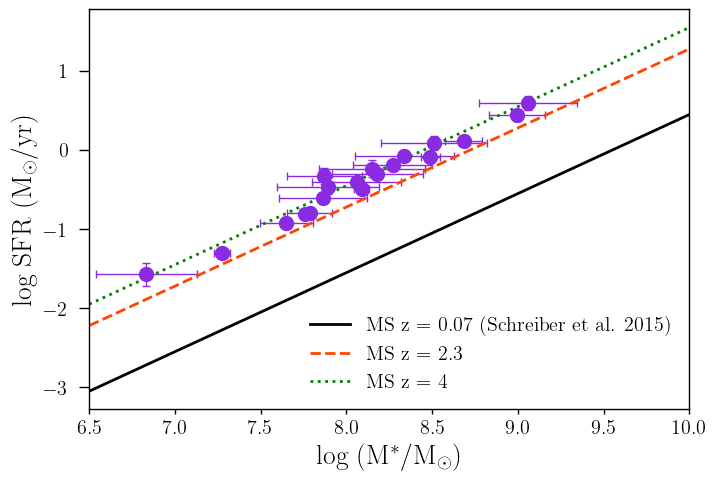

In [10]:
texPlot('on')
fig = plt.figure(figsize=(6, 4))
ax = fig.add_axes([0., 0., 1, 1])

def sfr_ms(z, mass):
    m = np.log10(mass/1e9)
    m0, m1, a0, a1, a2 = 0.5, 0.36, 1.5, 0.3, 2.5
    r = np.log10(1 + z)
    term1 = m - m0 + (a0*r)
    element = m - m1 - (a2*r)
    check = [0]
    for num in element:
        check.append(num)
    term2 = -a1 * ((np.max(check))**2)
    log_sfr_ms = term1 + term2
    return log_sfr_ms

# To plot
mass = np.array([10**6.5, 1e7, 1e8, 1e9, 1e10])

# Main sequence
ax.errorbar(m_star, sfr, xerr=m_star_err, yerr=sfr_err,
            marker='o', capsize=3, markersize=10, ls='', elinewidth=1, color='blueviolet')
ax.plot(np.log10(mass), sfr_ms(0.07, mass), color='black', lw=2, label='MS z = 0.07 (Schreiber et al. 2015)')
ax.plot(np.log10(mass), sfr_ms(2.3, mass), color='orangered', lw=2, ls='--', label='MS z = 2.3')
ax.plot(np.log10(mass), sfr_ms(4, mass), color='green', lw=2, ls=':', label='MS z = 4')

ax.legend(frameon=False)
ax.set_ylabel(r'log SFR (M$_{\odot}$/yr)')
ax.set_xlabel(r'log (M$^{*}$/M$_{\odot}$)')

ax.set_xlim(6.5, 10.0)

#fig.savefig('/home/benjamin/Documents/analogs/main_sequence.jpg',
#           bbox_inches='tight', facecolor='white')

Text(0.5, 0, 'log (M$^{*}$/M$_{\\odot}$)')

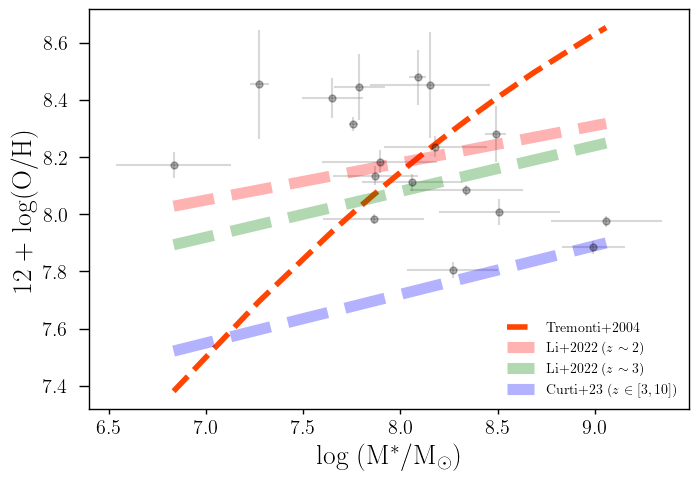

In [13]:
texPlot('on')
fig = plt.figure(figsize=(6, 4))
ax = fig.add_axes([0., 0., 1, 1])

def MZR_tremonti(M_star):
    # M_star = np.log10(M*)
    return -1.492 + (1.847 * M_star) - (0.08026 * (M_star**2))

def MZR_Li22(M_star, b, z0):
    return (b * (M_star - 8)) + z0

ax.errorbar(np.delete(m_star, -3), metals['log_OH'],
            xerr=np.delete(m_star_err, -3), yerr=metals['log_OH_err'],
            marker='o', capsize=0, markersize=5, ls='', ecolor='gray', color='black', alpha=0.3)

#ax.errorbar(upy.nominal_values(binned_m_star)[0:2], upy.nominal_values(binned_oh)[0:2],
#            xerr=upy.std_devs(binned_m_star)[0:2], yerr=upy.std_devs(binned_oh)[0:2],
#            marker='d', capsize=5, markersize=20, ls='', ecolor='black', color='black')
#
#ax.errorbar(upy.nominal_values(binned_m_star)[-1], upy.nominal_values(binned_oh)[-1],
#            xerr=upy.std_devs(binned_m_star)[-1], yerr=upy.std_devs(binned_oh)[-1],
#            marker='d', capsize=5, markersize=20, ls='', ecolor='blue', color='blue')

ax.plot(np.sort(m_star), MZR_tremonti(np.sort(m_star)), color='orangered',
        ls='--', lw=4, label='Tremonti+2004')

ax.plot(np.sort(m_star), MZR_Li22(np.sort(m_star), 0.13, 8.18),
         color='red', ls='--', lw=8, alpha=0.3, label=r'Li+2022 ($z \sim 2$)')
ax.plot(np.sort(m_star), MZR_Li22(np.sort(m_star), 0.16, 8.08),
         color='green', ls='--', lw=8, alpha=0.3, label=r'Li+2022 ($z \sim 3$)')
ax.plot(np.sort(m_star), MZR_Li22(np.sort(m_star), 0.17, 7.72),
         color='blue', ls='--', lw=8, alpha=0.3, label=r'Curti+23 ($z \in [3, 10]$)')


ax.legend(frameon=False, fontsize=10)
ax.set_ylabel('12 + log(O/H)')
ax.set_xlabel(r'log (M$^{*}$/M$_{\odot}$)')
#fig.savefig('/home/benjamin/Documents/analogs/mzr.jpg', bbox_inches='tight', facecolor='white')

In [31]:
# Read results

metals = pd.read_csv(magePath+'results/metals/metals_new.csv') # Metallicities and ratios
sed_results = fits.open('/home/benjamin/Documents/sed_fitting/old_pop_late_burst/results.fits') # SED fitting results

# log(M*)
unc_m_star = upy.uarray(sed_results[1].data['bayes.stellar.m_star'],
                        sed_results[1].data['bayes.stellar.m_star_err'])
m_star = upy.nominal_values(upy.log10(unc_m_star))
m_star_err = upy.std_devs(upy.log10(unc_m_star))

# log(SFR)
unc_sfr = upy.uarray(sed_results[1].data['bayes.sfh.sfr100Myrs'],
                     sed_results[1].data['bayes.sfh.sfr100Myrs_err'])
sfr = upy.nominal_values(upy.log10(unc_sfr))
sfr_err = upy.std_devs(upy.log10(unc_sfr))

metals.keys()

Index(['Source', 'ne', 'ne_err', 'ne_it', 'ne_it_err', 't(OIII)',
       't(OIII)_err', 't(OII)', 't(OII)_err', 't(OII)_it', 't(OII)_it_err',
       '12_log_OH', '12_log_OH_err', 'log_NO', 'log_NO_err', 'N2', 'N2_err',
       'R3', 'R3_err', 'R2', 'R2_err', 'R23', 'R23_err', 'O3N2', 'O3N2_err',
       'R3N2', 'R3N2_err', 'N2O2', 'N2O2_err', 'O3O2', 'O3O2_err', 'Ne3O2',
       'Ne3O2_err', 'S2', 'S2_err', 'O3S2', 'O3S2_err', 'N2S2', 'N2S2_err'],
      dtype='object')

Text(0.5, 0, 't([OIII])')

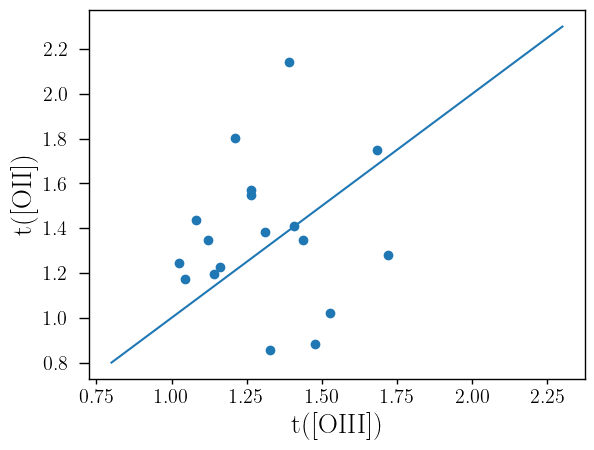

In [32]:
texPlot('on')
fig, ax= plt.subplots(1, 1)
ax.scatter(metals['t(OIII)'], metals['t(OII)'])
ax.plot(np.arange(0.8, 2.4, 0.1), np.arange(0.8, 2.4, 0.1))
ax.set_ylabel('t([OII])')
ax.set_xlabel('t([OIII])')

Text(0.5, 0, '12 + log(O/H)')

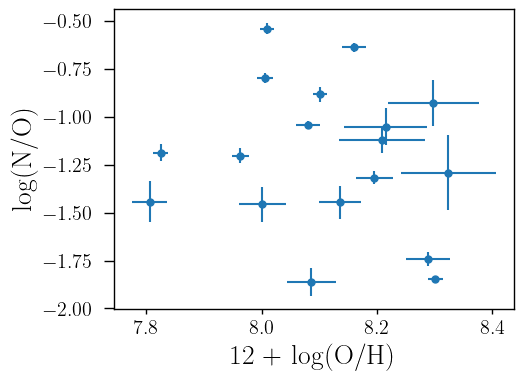

In [33]:
fig = plt.figure(figsize=(4, 3))
ax = fig.add_axes([0, 0, 1, 1])
ax.errorbar(metals['12_log_OH'], metals['log_NO'], xerr=metals['12_log_OH_err'], yerr=metals['log_NO_err'],
           ls='', marker='.', markersize=10)
ax.set_ylabel(r'log(N/O)')
ax.set_xlabel(r'12 + log(O/H)')

In [34]:
ne_dm = []
ne_dm_err = []
ne_sed = []
ne_sed_err = []

for idg in sed_results[1].data['id']:
    if idg[-1] == 'p':
        continue
    else:
        mask = (sed_results[1].data['id'] == idg)
        ne_sed.append(sed_results[1].data['bayes.nebular.ne'][mask][0])
        ne_sed_err.append(sed_results[1].data['bayes.nebular.ne_err'][mask][0])
        short_id = idg[:5]
        index = np.argmax(metals['Source'] == short_id)
        ne_dm.append(metals['ne'][index])
        ne_dm_err.append(metals['ne_err'][index])

In [35]:
def sfr_ms(z, mass):
    m = np.log10(mass/1e9)
    m0, m1, a0, a1, a2 = 0.5, 0.36, 1.5, 0.3, 2.5
    r = np.log10(1 + z)
    term1 = m - m0 + (a0*r)
    element = m - m1 - (a2*r)
    check = [0]
    for num in element:
        check.append(num)
    term2 = -a1 * ((np.max(check))**2)
    log_sfr_ms = term1 + term2
    return log_sfr_ms

In [36]:
mass = np.array([10**6.5, 1e7, 1e8, 1e9, 1e10])

def MZR_tremonti(M_star):
    # M_star = np.log10(M*)
    return -1.492 + (1.847 * M_star) - (0.08026 * (M_star**2))

def MZR_Li22(M_star, b, z0):
    return (b * (M_star - 8)) + z0

In [37]:
mask1 = (np.delete(m_star, -3) < 7.5) & (np.delete(m_star, -3) > 6.5)
mask2 = (np.delete(m_star, -3) < 8.5) & (np.delete(m_star, -3) > 7.5)
mask3 = (np.delete(m_star, -3) > 8.5)

med_m_star_1 = np.median(upy.uarray(np.delete(m_star, -3)[mask1], np.delete(m_star_err, -3)[mask1]))
med_m_star_2 = np.median(upy.uarray(np.delete(m_star, -3)[mask2], np.delete(m_star_err, -3)[mask2]))
med_m_star_3 = np.median(upy.uarray(np.delete(m_star, -3)[mask3], np.delete(m_star_err, -3)[mask3]))

med_oh_1 = np.median(upy.uarray(metals['12_log_OH'][mask1], metals['12_log_OH_err'][mask1]))
med_oh_2 = np.median(upy.uarray(metals['12_log_OH'][mask2], metals['12_log_OH_err'][mask2]))
med_oh_3 = np.median(upy.uarray(metals['12_log_OH'][mask3], metals['12_log_OH_err'][mask3]))

binned_m_star = upy.uarray([med_m_star_1.nominal_value, med_m_star_2.nominal_value, med_m_star_3.nominal_value],
                           [med_m_star_1.std_dev, med_m_star_2.std_dev, med_m_star_3.std_dev])

binned_oh = upy.uarray([med_oh_1.nominal_value, med_oh_2.nominal_value, med_oh_3.nominal_value],
                       [med_oh_1.std_dev, med_oh_2.std_dev, med_oh_3.std_dev])

Text(0, 0.5, '$n_{e}$ (cm$^{-3}$) from t([OII])')

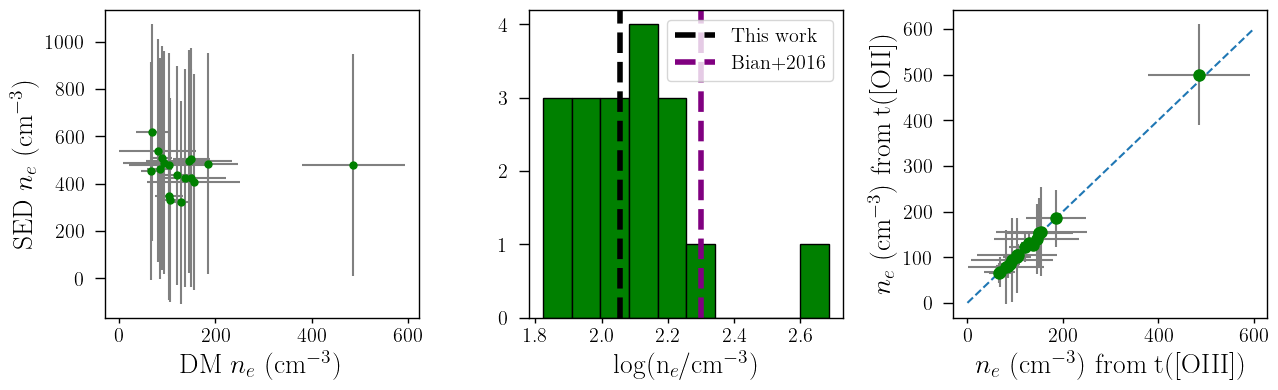

In [52]:
fig, (ax, ax1, ax2) = plt.subplots(1, 3)
fig.set_size_inches(15, 4)
fig.subplots_adjust(wspace=0.35)

# Electron density comparison with SED fitting
ax.errorbar(ne_dm, ne_sed, xerr=ne_dm_err, yerr=ne_sed_err,
            marker='o', capsize=0, markersize=5, ls='', ecolor='gray', color='green')
ax.set_ylabel(r'SED $n_{e}$ (cm$^{-3}$)')
ax.set_xlabel(r'DM $n_{e}$ (cm$^{-3}$)')

# Values histogram compared to median from Bian et al. 2016 analogs
ax1.hist(np.log10(ne_dm), facecolor='green', edgecolor='black')
ax1.axvline(np.log10(np.median(ne_dm)), ls='--', lw=4, label='This work')
ax1.axvline(np.log10(200), ls='--', color='purple', lw=4, label='Bian+2016')
ax1.legend(frameon=True)
ax1.set_xlabel(r'log(n$_{e}$/cm$^{-3}$)');

# Comparison of electron density determinated from T(OIII) and from 
# the solutions from T(OII)
ax2.errorbar(metals['ne'], metals['ne_it'], xerr=metals['ne_err'], yerr=metals['ne_it_err'],
            fmt='o', markersize=8, ls='', ecolor='gray', color='green')
ax2.plot(np.arange(0, 600, 1), np.arange(0, 600, 1), ls='--')
ax2.set_xlabel('$n_{e}$ (cm$^{-3}$) from t([OIII])')
ax2.set_ylabel('$n_{e}$ (cm$^{-3}$) from t([OII])')

Text(0, 0.5, 't([OII]) / 10$^{4}$ from n$_{e}$')

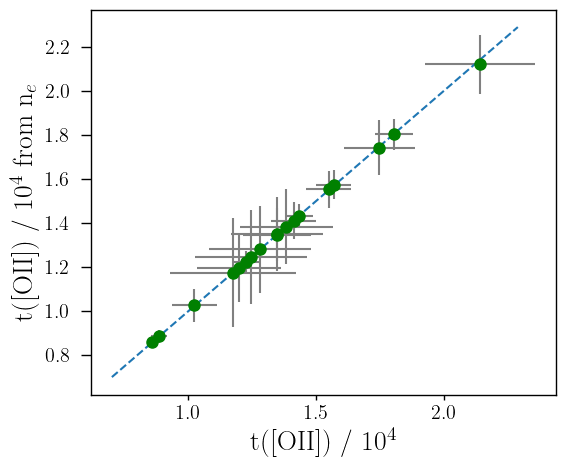

In [67]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(6, 5)

# Comparison of low ionization temperature determinated from T(OIII) and from 
# the solutions from T(OII)
ax.errorbar(metals['t(OII)'], metals['t(OII)_it'], xerr=metals['t(OII)_err'], yerr=metals['t(OII)_it_err'],
            fmt='o', markersize=8, ls='', ecolor='gray', color='green')
ax.plot(np.arange(0.7, 2.3, 0.01), np.arange(0.7, 2.3, 0.01), ls='--')
ax.set_xlabel('t([OII]) / 10$^{4}$')
ax.set_ylabel('t([OII]) / 10$^{4}$ from n$_{e}$')

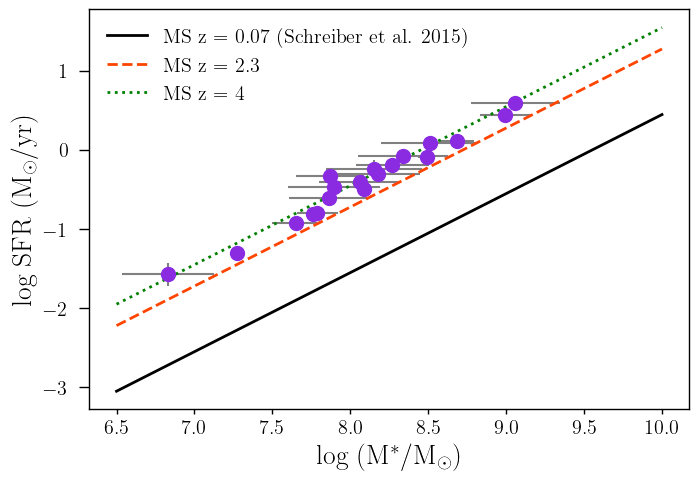

In [11]:
texPlot('on')
fig = plt.figure(figsize=(6, 4))
ax = fig.add_axes([0., 0., 1, 1])

# Main sequence
ax.errorbar(m_star, sfr, xerr=m_star_err, yerr=sfr_err,
            marker='o', capsize=0, markersize=10, ls='', ecolor='gray', color='blueviolet')
ax.plot(np.log10(mass), sfr_ms(0.07, mass), color='black', lw=2, label='MS z = 0.07 (Schreiber et al. 2015)')
ax.plot(np.log10(mass), sfr_ms(2.3, mass), color='orangered', lw=2, ls='--', label='MS z = 2.3')
ax.plot(np.log10(mass), sfr_ms(4, mass), color='green', lw=2, ls=':', label='MS z = 4')

ax.legend(frameon=False)
ax.set_ylabel(r'log SFR (M$_{\odot}$/yr)')
ax.set_xlabel(r'log (M$^{*}$/M$_{\odot}$)')

fig.savefig('/home/benjamin/Documents/analogs/main_sequence.jpg',
           bbox_inches='tight', facecolor='white')

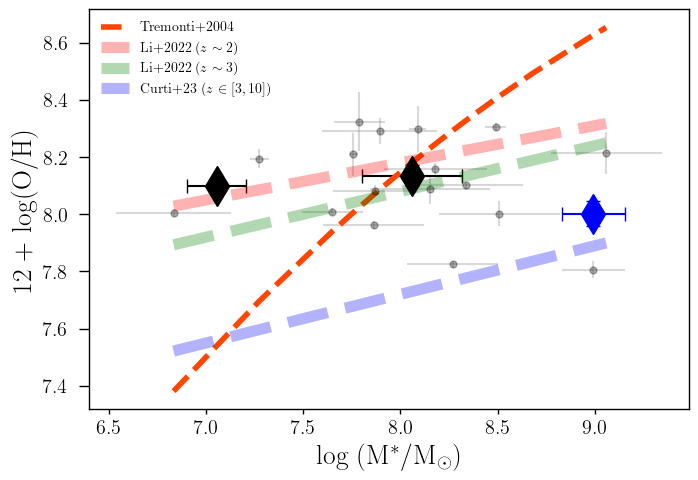

In [12]:
texPlot('on')
fig = plt.figure(figsize=(6, 4))
ax = fig.add_axes([0., 0., 1, 1])

ax.errorbar(np.delete(m_star, -3), metals['12_log_OH'],
            xerr=np.delete(m_star_err, -3), yerr=metals['12_log_OH_err'],
            marker='o', capsize=0, markersize=5, ls='', ecolor='gray', color='black', alpha=0.3)

ax.errorbar(upy.nominal_values(binned_m_star)[0:2], upy.nominal_values(binned_oh)[0:2],
            xerr=upy.std_devs(binned_m_star)[0:2], yerr=upy.std_devs(binned_oh)[0:2],
            marker='d', capsize=5, markersize=20, ls='', ecolor='black', color='black')

ax.errorbar(upy.nominal_values(binned_m_star)[-1], upy.nominal_values(binned_oh)[-1],
            xerr=upy.std_devs(binned_m_star)[-1], yerr=upy.std_devs(binned_oh)[-1],
            marker='d', capsize=5, markersize=20, ls='', ecolor='blue', color='blue')

ax.plot(np.sort(m_star), MZR_tremonti(np.sort(m_star)), color='orangered',
        ls='--', lw=4, label='Tremonti+2004')

ax.plot(np.sort(m_star), MZR_Li22(np.sort(m_star), 0.13, 8.18),
         color='red', ls='--', lw=8, alpha=0.3, label=r'Li+2022 ($z \sim 2$)')
ax.plot(np.sort(m_star), MZR_Li22(np.sort(m_star), 0.16, 8.08),
         color='green', ls='--', lw=8, alpha=0.3, label=r'Li+2022 ($z \sim 3$)')
ax.plot(np.sort(m_star), MZR_Li22(np.sort(m_star), 0.17, 7.72),
         color='blue', ls='--', lw=8, alpha=0.3, label=r'Curti+23 ($z \in [3, 10]$)')


ax.legend(frameon=False, fontsize=10)
ax.set_ylabel('12 + log(O/H)')
ax.set_xlabel(r'log (M$^{*}$/M$_{\odot}$)')
fig.savefig('/home/benjamin/Documents/analogs/mzr.jpg', bbox_inches='tight', facecolor='white')

# Abundances and literature relations

In [13]:
def binning(arr, lims=[8.0, 8.2, 8.4]):
    
    mask_0 = (metals['12_log_OH'] < lims[0])
    mask_1 = (lims[0] <= metals['12_log_OH']) & (metals['12_log_OH'] < lims[1])
    mask_2 = (lims[1] <= metals['12_log_OH']) & (metals['12_log_OH'] < lims[2])
    
    binned = np.array([np.median(arr[mask_0]),
                       np.median(arr[mask_1]),
                       np.median(arr[mask_2])
    ])
    return binned

In [14]:
metals.keys()

Index(['Source', 'ne', 'ne_err', 't(OIII)', 't(OIII)_err', 't(OII)',
       't(OII)_err', '12_log_OH', '12_log_OH_err', 'log_NO', 'log_NO_err',
       'N2', 'N2_err', 'R3', 'R3_err', 'R2', 'R2_err', 'R23', 'R23_err',
       'O3N2', 'O3N2_err', 'R3N2', 'R3N2_err', 'N2O2', 'N2O2_err', 'O3O2',
       'O3O2_err', 'Ne3O2', 'Ne3O2_err', 'S2', 'S2_err', 'O3S2', 'O3S2_err',
       'N2S2', 'N2S2_err'],
      dtype='object')

In [15]:
mock_OH = np.arange(min(metals['12_log_OH']), max(metals['12_log_OH']), 0.005)

log_OH_med = upy.nominal_values(binning(upy.uarray(metals['12_log_OH'], metals['12_log_OH_err'])))
log_OH_med_err = upy.std_devs(binning(upy.uarray(metals['12_log_OH'], metals['12_log_OH_err'])))

N2_med = upy.nominal_values(binning(upy.uarray(metals['N2'], metals['N2_err'])))
N2_med_err = upy.std_devs(binning(upy.uarray(metals['N2'], metals['N2_err'])))

R2_med = upy.nominal_values(binning(upy.uarray(metals['R2'], metals['R2_err'])))
R2_med_err = upy.std_devs(binning(upy.uarray(metals['R2'], metals['R2_err'])))

R3_med = upy.nominal_values(binning(upy.uarray(metals['R3'], metals['R3_err'])))
R3_med_err = upy.std_devs(binning(upy.uarray(metals['R3'], metals['R3_err'])))

R23_med = upy.nominal_values(binning(upy.uarray(metals['R23'], metals['R23_err'])))
R23_med_err = upy.std_devs(binning(upy.uarray(metals['R23'], metals['R23_err'])))

O3N2_med = upy.nominal_values(binning(upy.uarray(metals['O3N2'], metals['O3N2_err'])))
O3N2_med_err = upy.std_devs(binning(upy.uarray(metals['O3N2'], metals['O3N2_err'])))

R3N2_med = upy.nominal_values(binning(upy.uarray(metals['R3N2'], metals['R3N2_err'])))
R3N2_med_err = upy.std_devs(binning(upy.uarray(metals['R3N2'], metals['R3N2_err'])))

N2O2_med = upy.nominal_values(binning(upy.uarray(metals['N2O2'], metals['N2O2_err'])))
N2O2_med_err = upy.std_devs(binning(upy.uarray(metals['N2O2'], metals['N2O2_err'])))

O3O2_med = upy.nominal_values(binning(upy.uarray(metals['O3O2'], metals['O3O2_err'])))
O3O2_med_err = upy.std_devs(binning(upy.uarray(metals['O3O2'], metals['O3O2_err'])))

Ne3O2_med = upy.nominal_values(binning(upy.uarray(metals['Ne3O2'], metals['Ne3O2_err'])))
Ne3O2_med_err = upy.std_devs(binning(upy.uarray(metals['Ne3O2'], metals['Ne3O2_err'])))

S2_med = upy.nominal_values(binning(upy.uarray(metals['S2'], metals['S2_err'])))
S2_med_err = upy.std_devs(binning(upy.uarray(metals['S2'], metals['S2_err'])))

O3S2_med = upy.nominal_values(binning(upy.uarray(metals['O3S2'], metals['O3S2_err'])))
O3S2_med_err = upy.std_devs(binning(upy.uarray(metals['O3S2'], metals['O3S2_err'])))

N2S2_med = upy.nominal_values(binning(upy.uarray(metals['N2S2'], metals['N2S2_err'])))
N2S2_med_err = upy.std_devs(binning(upy.uarray(metals['N2S2'], metals['N2S2_err'])))

In [16]:
colplot = 'mediumorchid'

# Local $z \sim 0$

In [17]:
def denicolo2002_N2(log_OH_12):
    N2 = (log_OH_12 - 9.12) / 0.73
    return N2


def tremonti2004_R23(R23):
    log_OH_12 = 9.185 - (0.313 * R23) - (0.264 * (R23**2)) - (0.321 * (R23**3)) 
    return log_OH_12


def pettini_pagel2004_O3N2(log_OH_12):
    O3N2 = - (log_OH_12 - 8.73) / 0.32
    return O3N2


def pettini_pagel2004_N2(N2):
    log_OH_12 = 9.37 + (2.03 * N2) + (1.26 * (N2**2)) + (0.32 * (N2**3))
    return log_OH_12


def nagao2006(log_OH_12, ratio='asd'):
    if ratio == 'R23':
        b0 = 1.2299
        b1 = -4.1926
        b2 = 1.0246
        b3 = -0.063169
    if ratio == 'N2':
        b0 = 96.641
        b1 = -39.941
        b2 = 5.2227
        b3 = -0.22040
    if ratio == 'R3N2':
        b0 = -232.18
        b1 = 84.423
        b2 = -9.9330
        b3 = 0.37941
    if ratio == 'N2O2':
        b0 = -128.94
        b1 = 48.818
        b2 = -6.2759
        b3 = 0.27101
    if ratio == 'O3O2':
        b0 = -1.4089
        b1 = 1.3745
        b2 = -0.14359
        b3 = 0
    return b0 + (b1 * log_OH_12) + (b2 * (log_OH_12**2)) + (b3 * (log_OH_12**3))

def maiolino2008(log_OH_12, ratio='asd'):
    x = (log_OH_12 - 8.69)
    if ratio == 'R23':
        c0 = 0.7462
        c1 = -0.7149
        c2 = -0.9401
        c3 = -0.6154
        c4 = -0.2524
    if ratio == 'N2':
        c0 = -0.7732
        c1 = 1.2357
        c2 = -0.2811
        c3 = -0.7201
        c4 = -0.3330
    if ratio == 'R3':
        c0 = 0.1549
        c1 = -1.5031
        c2 = -0.9790
        c3 = -0.0297
        c4 = 0.0
    if ratio == 'O3O2':
        c0 = -0.2839
        c1 = -1.3881
        c2 = -0.3172
        c3 = 0.0
        c4 = 0.0
    if ratio == 'R2':
        c0 = 0.5603
        c1 = 0.0450
        c2 = -1.8017
        c3 = -1.8434
        c4 = -0.6549
    if ratio == 'R3N2':
        c0 = 0.4520
        c1 = -2.6096
        c2 = -0.7170
        c3 = 0.1347
        c4 = 0.0
    if ratio == 'Ne3O2':
        c0 = -1.2608
        c1 = -1.0861
        c2 = -0.1470
        c3 = 0.0
        c4 = 0.0
    return c0 + (c1 * x) + (c2 * (x**2)) + (c3 * (x**3)) + (c4 * (x**4))


def marino2013_N2(log_OH_12):
    N2 = (log_OH_12 - 8.743) / 0.462
    return N2


def marino2013_O3N2(log_OH_12):
    O3N2 = - (log_OH_12 - 8.533) / 0.214
    return O3N2


def curti2020(log_OH_12, ratio='asd'):
    x = (log_OH_12 - 8.69)
    if ratio == 'R2':
        c0 = 0.435
        c1 = -1.362
        c2 = -5.655
        c3 = -4.851
        c4 = -0.478
        c5 = 0.736
    if ratio == 'R3':
        c0 = -0.277
        c1 = -3.549
        c2 = -3.593
        c3 = -0.981
        c4 = 0.0
        c5 = 0.0
    if ratio == 'O3O2':
        c0 = -0.691
        c1 = -2.944
        c2 = -1.308
        c3 = 0.0
        c4 = 0.0
        c5 = 0.0
    if ratio == 'R23':
        c0 = 0.527
        c1 = -1.569
        c2 = -1.652
        c3 = -0.421
        c4 = 0.0
        c5 = 0.0
    if ratio == 'N2':
        c0 = -0.489
        c1 = 1.513
        c2 = -2.554
        c3 = -5.293
        c4 = -2.867
        c5 = 0.0
    if ratio == 'O3N2':
        c0 = 0.281
        c1 = -4.765
        c2 = -2.268
        c3 = 0.0
        c4 = 0.0
        c5 = 0.0
    if ratio == 'S2':
        c0 = -0.442
        c1 = -0.360
        c2 = -6.271
        c3 = -8.339
        c4 = -3.559
        c5 = 0.0
    if ratio == 'O3S2':
        c0 = 0.191
        c1 = -4.292
        c2 = -2.538
        c3 = 0.053
        c4 = 0.332
        c5 = 0.0
    return c0 + (c1 * x) + (c2 * (x**2)) + (c3 * (x**3)) + (c4 * (x**4)) + (c5 * (x**5))

def sanders2021(log_OH_12, ratio='asd'):
    x = (log_OH_12 - 8.69)
    if ratio == 'R3':
        c0 = -0.143
        c1 = -3.16
        c2 = -4.06
        c3 = -1.49
    if ratio == 'R2':
        c0 = 0.27
        c1 = -0.452
        c2 = -0.52
        c3 = 0.0831
    if ratio == 'O3O2':
        c0 = -0.413
        c1 = -2.7
        c2 = -3.52
        c3 = -1.55
    if ratio == 'R23':
        c0 = 0.469
        c1 = -1.51
        c2 = -1.75
        c3 = -0.508
    if ratio == 'N2':
        c0 = -0.606
        c1 = 1.28
        c2 = -0.435
        c3 = -0.485
    if ratio == 'O3N2':
        c0 = 0.461
        c1 = -4.40
        c2 = -3.37
        c3 = -0.761
    return c0 + (c1 * x) + (c2 * (x**2)) + (c3 * (x**3))

Text(0.5, 0, '12 + log(O/H)')

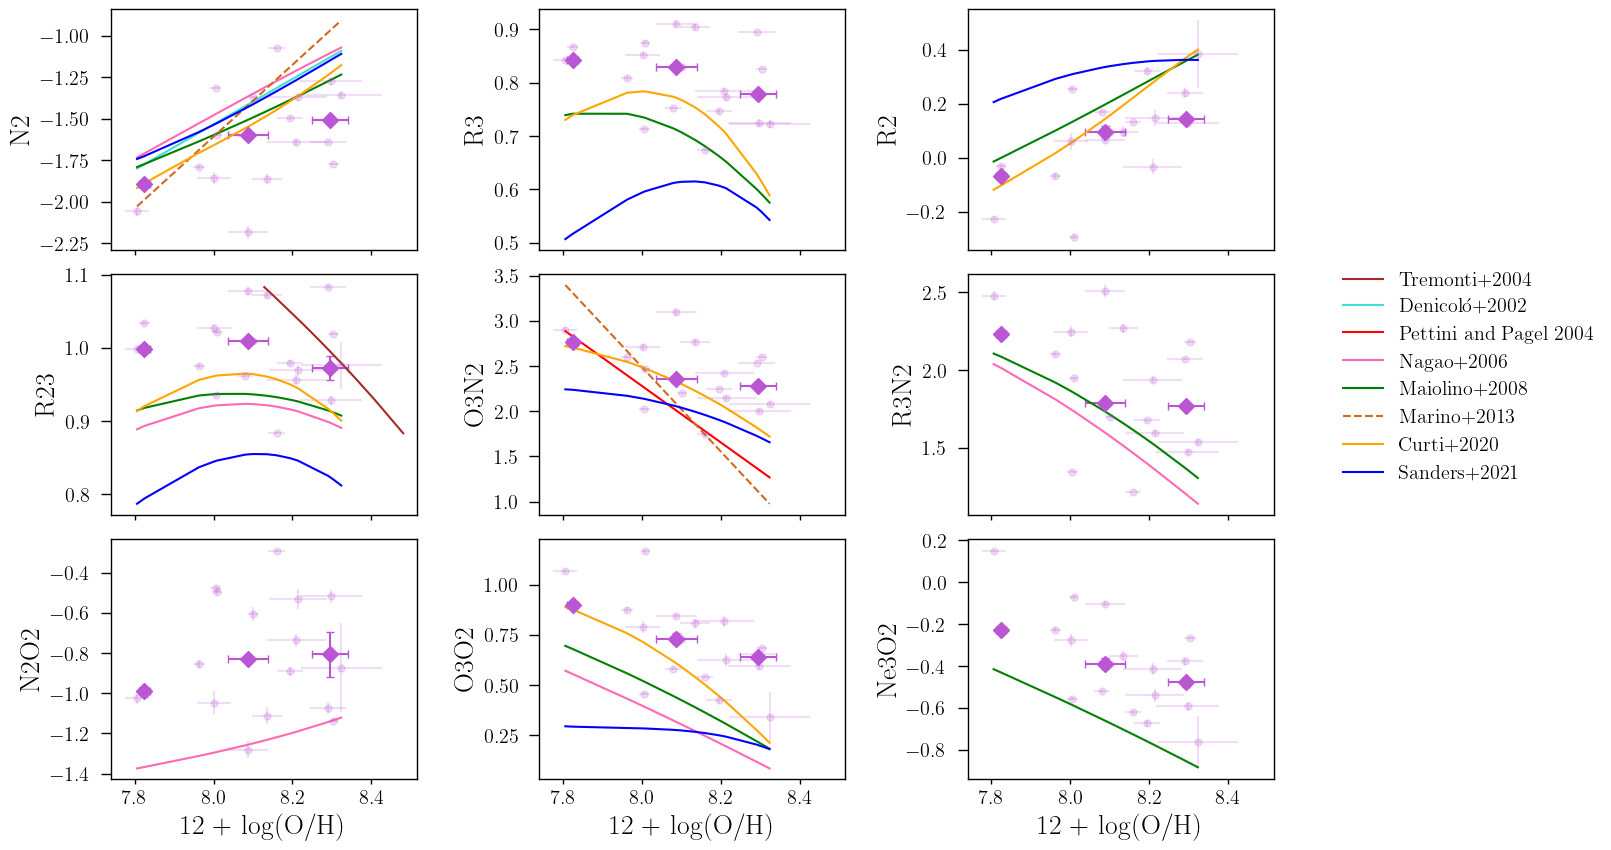

In [18]:
texPlot('on')
fig, axs = plt.subplots(3, 3, sharex=True)
fig.set_size_inches((15, 10))
fig.subplots_adjust(wspace=0.4, hspace=0.1)

# ===========================================================================================================
# 1st row
# ===========================================================================================================

# N2

axs[0, 0].errorbar(metals['12_log_OH'], metals['N2'], xerr=metals['12_log_OH_err'], yerr=metals['N2_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[0, 0].errorbar(log_OH_med, N2_med, xerr=log_OH_med_err, yerr=N2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

log_OH_12_PP04 = pettini_pagel2004_N2(np.sort(metals['N2']))
mask_PP04 = (log_OH_12_PP04 >= min(metals['12_log_OH'])) & (log_OH_12_PP04 <= min(metals['12_log_OH']))
axs[0, 0].plot(np.sort(metals['12_log_OH']), denicolo2002_N2(np.sort(metals['12_log_OH'])), label='Denicoló+2002', color='turquoise')
axs[0, 0].plot(log_OH_12_PP04[mask_PP04], np.sort(metals['N2'])[mask_PP04],
               
               label='Pettini and Pagel 2004', color='red')

axs[0, 0].plot(np.sort(metals['12_log_OH']), nagao2006(np.sort(metals['12_log_OH']), 'N2'), label='Nagao+2006', color='hotpink')
axs[0, 0].plot(np.sort(metals['12_log_OH']), maiolino2008(np.sort(metals['12_log_OH']), 'N2'), label='Maiolino+2008', color='green')
axs[0, 0].plot(np.sort(metals['12_log_OH']), marino2013_N2(np.sort(metals['12_log_OH'])), label='Marino+2013', color='chocolate', ls='--')
axs[0, 0].plot(np.sort(metals['12_log_OH']), curti2020(np.sort(metals['12_log_OH']), 'N2'), label='Curti+2020', color='orange')
axs[0, 0].plot(np.sort(metals['12_log_OH']), sanders2021(np.sort(metals['12_log_OH']), 'N2'), label='Sanders+2021', color='blue')

axs[0, 0].legend(frameon=False, loc=(4.0, -1.0))
axs[0, 0].set_ylabel('N2')

# R3

axs[0, 1].errorbar(metals['12_log_OH'], metals['R3'], xerr=metals['12_log_OH_err'], yerr=metals['R3_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[0, 1].errorbar(log_OH_med, R3_med, xerr=log_OH_med_err, yerr=R3_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[0, 1].plot(np.sort(metals['12_log_OH']), maiolino2008(np.sort(metals['12_log_OH']), 'R3'), label='Maiolino+2008', color='green')
axs[0, 1].plot(np.sort(metals['12_log_OH']), curti2020(np.sort(metals['12_log_OH']), 'R3'), label='Curti+2020', color='orange')
axs[0, 1].plot(np.sort(metals['12_log_OH']), sanders2021(np.sort(metals['12_log_OH']), 'R3'), label='Sanders+2021', color='blue')

#axs[0, 1].legend(frameon=True, fontsize='small')
axs[0, 1].set_ylabel('R3')

# R2

axs[0, 2].errorbar(metals['12_log_OH'], metals['R2'], xerr=metals['12_log_OH_err'], yerr=metals['R2_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[0, 2].errorbar(log_OH_med, R2_med, xerr=log_OH_med_err, yerr=R2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[0, 2].plot(np.sort(metals['12_log_OH']), maiolino2008(np.sort(metals['12_log_OH']), 'R2'), label='Maiolino+2008', color='green')
axs[0, 2].plot(np.sort(metals['12_log_OH']), curti2020(np.sort(metals['12_log_OH']), 'R2'), label='Curti+2020', color='orange')
axs[0, 2].plot(np.sort(metals['12_log_OH']), sanders2021(np.sort(metals['12_log_OH']), 'R2'), label='Sanders+2021', color='blue')

#axs[0, 2].legend(frameon=True, fontsize='small')
axs[0, 2].set_ylabel('R2')


# ===========================================================================================================
# 2nd row
# ===========================================================================================================

# R23

axs[1, 0].errorbar(metals['12_log_OH'], metals['R23'], xerr=metals['12_log_OH_err'], yerr=metals['R23_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[1, 0].errorbar(log_OH_med, R23_med, xerr=log_OH_med_err, yerr=R23_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[1, 0].plot(tremonti2004_R23(np.sort(metals['R23'])), np.sort(metals['R23']), label='Tremonti+2004', color='brown')
axs[1, 0].plot(np.sort(metals['12_log_OH']), nagao2006(np.sort(metals['12_log_OH']), 'R23'), color='hotpink')
axs[1, 0].plot(np.sort(metals['12_log_OH']), maiolino2008(np.sort(metals['12_log_OH']), 'R23'), color='green')
axs[1, 0].plot(np.sort(metals['12_log_OH']), curti2020(np.sort(metals['12_log_OH']), 'R23'), color='orange')
axs[1, 0].plot(np.sort(metals['12_log_OH']), sanders2021(np.sort(metals['12_log_OH']), 'R23'), color='blue')

axs[1, 0].legend(frameon=False, loc=(4.0, 0.9))
axs[1, 0].set_ylabel('R23')

# O3N2

axs[1, 1].errorbar(metals['12_log_OH'], metals['O3N2'], xerr=metals['12_log_OH_err'], yerr=metals['O3N2_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[1, 1].errorbar(log_OH_med, O3N2_med, xerr=log_OH_med_err, yerr=O3N2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[1, 1].plot(np.sort(metals['12_log_OH']), pettini_pagel2004_O3N2(np.sort(metals['12_log_OH'])), label='Pettini and Pagel 2004', color='red')
axs[1, 1].plot(np.sort(metals['12_log_OH']), marino2013_O3N2(np.sort(metals['12_log_OH'])), label='Marino+2013', color='chocolate', ls='--')
axs[1, 1].plot(np.sort(metals['12_log_OH']), curti2020(np.sort(metals['12_log_OH']), 'O3N2'), label='Curti+2020', color='orange')
axs[1, 1].plot(np.sort(metals['12_log_OH']), sanders2021(np.sort(metals['12_log_OH']), 'O3N2'), label='Sanders+2021', color='blue')

#axs[1, 1].legend(frameon=True, fontsize='small')
axs[1, 1].set_ylabel('O3N2')

# R3N2

axs[1, 2].errorbar(metals['12_log_OH'], metals['R3N2'], xerr=metals['12_log_OH_err'], yerr=metals['R3N2_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[1, 2].errorbar(log_OH_med, R3N2_med, xerr=log_OH_med_err, yerr=R3N2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[1, 2].plot(np.sort(metals['12_log_OH']), nagao2006(np.sort(metals['12_log_OH']), 'R3N2'), label='Nagao+2006', color='hotpink')
axs[1, 2].plot(np.sort(metals['12_log_OH']), maiolino2008(np.sort(metals['12_log_OH']), 'R3N2'), label='Maiolino+2008', color='green')
#axs[1, 2].legend(frameon=True, fontsize='small')
axs[1, 2].set_ylabel('R3N2')


# ===========================================================================================================
# 3rd row
# ===========================================================================================================

# N2O2

axs[2, 0].errorbar(metals['12_log_OH'], metals['N2O2'], xerr=metals['12_log_OH_err'], yerr=metals['N2O2_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[2, 0].errorbar(log_OH_med, N2O2_med, xerr=log_OH_med_err, yerr=N2O2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[2, 0].plot(np.sort(metals['12_log_OH']), nagao2006(np.sort(metals['12_log_OH']), 'N2O2'), label='Nagao+2006', color='hotpink')
#axs[2, 0].legend(frameon=True, fontsize='small')
axs[2, 0].set_ylabel('N2O2')

# O3O2

axs[2, 1].errorbar(metals['12_log_OH'], metals['O3O2'], xerr=metals['12_log_OH_err'], yerr=metals['O3O2_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[2, 1].errorbar(log_OH_med, O3O2_med, xerr=log_OH_med_err, yerr=O3O2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[2, 1].plot(np.sort(metals['12_log_OH']), nagao2006(np.sort(metals['12_log_OH']), 'O3O2'), label='Nagao+2006', color='hotpink')
axs[2, 1].plot(np.sort(metals['12_log_OH']), maiolino2008(np.sort(metals['12_log_OH']), 'O3O2'), label='Maiolino+2008', color='green')
axs[2, 1].plot(np.sort(metals['12_log_OH']), curti2020(np.sort(metals['12_log_OH']), 'O3O2'), label='Curti+2020', color='orange')
axs[2, 1].plot(np.sort(metals['12_log_OH']), sanders2021(np.sort(metals['12_log_OH']), 'O3O2'), label='Sanders+2021', color='blue')

#axs[2, 1].legend(frameon=True, fontsize='small')
axs[2, 1].set_ylabel('O3O2')

# Ne3O2

axs[2, 2].errorbar(metals['12_log_OH'], metals['Ne3O2'], xerr=metals['12_log_OH_err'], yerr=metals['Ne3O2_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[2, 2].errorbar(log_OH_med, Ne3O2_med, xerr=log_OH_med_err, yerr=Ne3O2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[2, 2].plot(np.sort(metals['12_log_OH']), maiolino2008(np.sort(metals['12_log_OH']), 'Ne3O2'), label='Maiolino+2008', color='green')
#axs[2, 2].legend(frameon=True, fontsize='small')
axs[2, 2].set_ylabel('Ne3O2')


# ===========================================================================================================
# 4th row
# ===========================================================================================================

# S2

#axs[3, 0].errorbar(metals['12_log_OH'], metals['S2'], xerr=metals['12_log_OH_err'], yerr=metals['S2_err'], 
#                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
#axs[3, 0].errorbar(log_OH_med, S2_med, xerr=log_OH_med_err, yerr=S2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

#axs[3, 0].plot(np.sort(metals['12_log_OH']), curti2020(np.sort(metals['12_log_OH']), 'S2'), label='Curti+2020', color='orange')
#axs[3, 0].legend(frameon=True, fontsize='small')
#axs[3, 0].set_ylabel('S2')


# O3S2

#axs[3, 1].errorbar(metals['12_log_OH'], metals['O3S2'], xerr=metals['12_log_OH_err'], yerr=metals['O3S2_err'], 
#                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
#axs[3, 1].errorbar(log_OH_med, O3S2_med, xerr=log_OH_med_err, yerr=O3S2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

#axs[3, 1].plot(np.sort(metals['12_log_OH']), curti2020(np.sort(metals['12_log_OH']), 'O3S2'), label='Curti+2020', color='orange')
#axs[3, 1].legend(frameon=True, fontsize='small')
#axs[3, 1].set_ylabel('O3S2')

# N2S2

#axs[3, 2].errorbar(metals['12_log_OH'], metals['N2S2'], xerr=metals['12_log_OH_err'], yerr=metals['N2S2_err'], 
#                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
#axs[3, 2].errorbar(log_OH_med, N2S2_med, xerr=log_OH_med_err, yerr=N2S2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)
#axs[3, 2].set_ylabel('N2S2')


# labels
axs[2, 0].set_xlabel(r'12 + log(O/H)')
axs[2, 1].set_xlabel(r'12 + log(O/H)')
axs[2, 2].set_xlabel(r'12 + log(O/H)')

# title
#axs[0, 1].set_title(r'$z \sim 0$ calibrations', fontsize=50)
#plt.savefig('z_0_calibs.jpg', bbox_inches='tight', facecolor='white')

# High-z analogs & more

In [19]:
def jones2015(log_OH_12, ratio='asd'):
    if ratio == 'Ne3O2':
        c0 = 16.8974
        c1 = -2.1588
        c2 = 0.0
    if ratio == 'O3O2':
        c0 = 17.9828
        c1 = -2.1552
        c2 = 0.0
    if ratio == 'R3':
        c0 = -88.4378
        c1 = 22.7529
        c2 = -1.4501
    if ratio == 'R2':
        c0 = -154.9571
        c1 = 36.9128
        c2 = -2.1921
    if ratio == 'R23':
        c0 = -54.1003
        c1 = 13.9083
        c2 = -0.8782
    return c0 + (c1 * log_OH_12) + (c2 * (log_OH_12**2))

def bian2018(log_OH_12, ratio='asd'):
    if ratio == 'N2':
        return (log_OH_12 - 8.82) / 0.49
    if ratio == 'O3N2':
        return - (log_OH_12 - 8.97) / 0.39
    if ratio == 'R23':
        c0 = 138.0430
        c1 = -54.8284
        c2 = 7.2954
        c3 = -0.32293
        return c0 + (c1 * log_OH_12) + (c2 * (log_OH_12**2)) + (c3 * (log_OH_12**3))
    if ratio == 'O3O2':
        return - (log_OH_12 - 8.54) / 0.59
    if ratio == 'R3':
        c0 = 43.9836
        c1 = -21.6211
        c2 = 3.4277
        c3 = -0.1747
        return c0 + (c1 * log_OH_12) + (c2 * (log_OH_12**2)) + (c3 * (log_OH_12**3))
    if ratio == 'Ne3O2':
        return - (log_OH_12 - 7.8) / 0.63
    
def perez_montero2021(log_OH_12, ratio='asd'):
    if ratio == 'O3O2':
        return - (log_OH_12 - 8.308) / 0.352
    if ratio == 'Ne3O2':
        return - (log_OH_12 - 7.823) / 0.455
    if ratio == 'N2':
        return (log_OH_12 - 8.625) / 0.361
    if ratio == 'O3N2':
        return - (log_OH_12 - 8.677) / 0.270

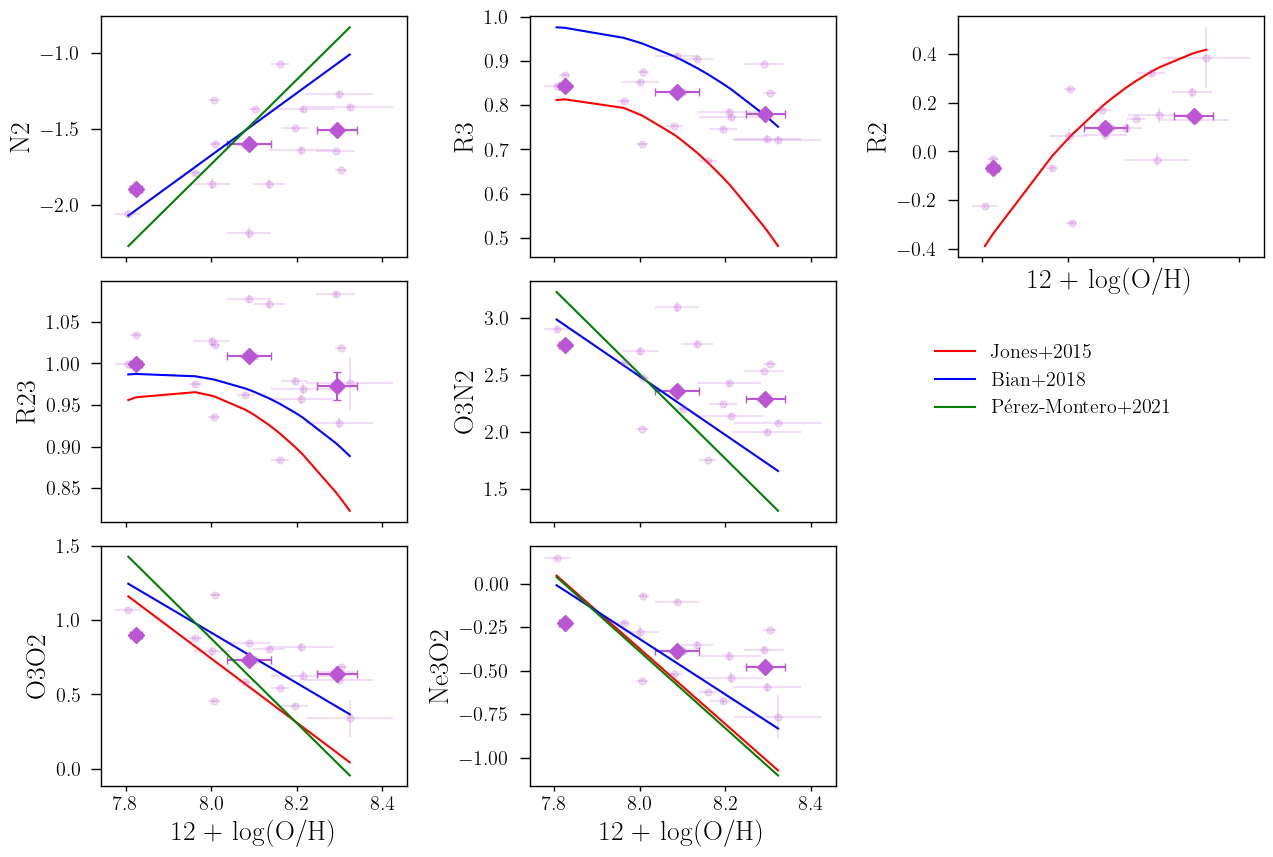

In [37]:
texPlot('on')
fig, axs = plt.subplots(3, 3, sharex=True)
fig.set_size_inches((15, 10))
fig.subplots_adjust(wspace=0.4, hspace=0.1)

# ===========================================================================================================
# 1st row
# ===========================================================================================================

# N2

axs[0, 0].errorbar(metals['12_log_OH'], metals['N2'], xerr=metals['12_log_OH_err'], yerr=metals['N2_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[0, 0].errorbar(log_OH_med, N2_med, xerr=log_OH_med_err, yerr=N2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[0, 0].plot(np.sort(metals['12_log_OH']), bian2018(np.sort(metals['12_log_OH']), 'N2'), label='Bian+2018', color='blue')
axs[0, 0].plot(np.sort(metals['12_log_OH']), perez_montero2021(np.sort(metals['12_log_OH']), 'N2'), label='Pérez-Montero+2021', color='green')
#axs[0, 0].legend(frameon=True, fontsize='small')
axs[0, 0].set_ylabel('N2')

# R3

axs[0, 1].errorbar(metals['12_log_OH'], metals['R3'], xerr=metals['12_log_OH_err'], yerr=metals['R3_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[0, 1].errorbar(log_OH_med, R3_med, xerr=log_OH_med_err, yerr=R3_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[0, 1].plot(np.sort(metals['12_log_OH']), jones2015(np.sort(metals['12_log_OH']), 'R3'), label='Jones+2015', color='red')
axs[0, 1].plot(np.sort(metals['12_log_OH']), bian2018(np.sort(metals['12_log_OH']), 'R3'), label='Bian+2018', color='blue')
#axs[0, 1].legend(frameon=True, fontsize='small')
axs[0, 1].set_ylabel('R3')

# R2

axs[0, 2].errorbar(metals['12_log_OH'], metals['R2'], xerr=metals['12_log_OH_err'], yerr=metals['R2_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[0, 2].errorbar(log_OH_med, R2_med, xerr=log_OH_med_err, yerr=R2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[0, 2].plot(np.sort(metals['12_log_OH']), jones2015(np.sort(metals['12_log_OH']), 'R2'), label='Jones+2015', color='red')
#axs[0, 2].legend(frameon=True, fontsize='small')
axs[0, 2].set_ylabel('R2')


# ===========================================================================================================
# 2nd row
# ===========================================================================================================

# R23

axs[1, 0].errorbar(metals['12_log_OH'], metals['R23'], xerr=metals['12_log_OH_err'], yerr=metals['R23_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[1, 0].errorbar(log_OH_med, R23_med, xerr=log_OH_med_err, yerr=R23_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[1, 0].plot(np.sort(metals['12_log_OH']), jones2015(np.sort(metals['12_log_OH']), 'R23'), label='Jones+2015', color='red')
axs[1, 0].plot(np.sort(metals['12_log_OH']), bian2018(np.sort(metals['12_log_OH']), 'R23'), label='Bian+2018', color='blue')
#axs[1, 0].legend(frameon=True, fontsize='small')
axs[1, 0].set_ylabel('R23')

# O3N2

axs[1, 1].errorbar(metals['12_log_OH'], metals['O3N2'], xerr=metals['12_log_OH_err'], yerr=metals['O3N2_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[1, 1].errorbar(log_OH_med, O3N2_med, xerr=log_OH_med_err, yerr=O3N2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[1, 1].plot(np.sort(metals['12_log_OH']), bian2018(np.sort(metals['12_log_OH']), 'O3N2'), label='Bian+2018', color='blue')
axs[1, 1].plot(np.sort(metals['12_log_OH']), perez_montero2021(np.sort(metals['12_log_OH']), 'O3N2'), label='Pérez-Montero+2021', color='green')
#axs[1, 1].legend(frameon=True, fontsize='small')
axs[1, 1].set_ylabel('O3N2')

# R3N2

#axs[1, 2].errorbar(metals['12_log_OH'], metals['R3N2'], xerr=metals['12_log_OH_err'], yerr=metals['R3N2_err'], 
#                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
#axs[1, 2].errorbar(log_OH_med, R3N2_med, xerr=log_OH_med_err, yerr=R3N2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)
#axs[1, 2].set_ylabel('R3N2')


# ===========================================================================================================
# 3rd row
# ===========================================================================================================

# N2O2

#axs[2, 0].errorbar(metals['12_log_OH'], metals['N2O2'], xerr=metals['12_log_OH_err'], yerr=metals['N2O2_err'], 
#                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
#axs[2, 0].errorbar(log_OH_med, N2O2_med, xerr=log_OH_med_err, yerr=N2O2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)
#axs[2, 0].set_ylabel('N2O2')


# O3O2

axs[2, 0].errorbar(metals['12_log_OH'], metals['O3O2'], xerr=metals['12_log_OH_err'], yerr=metals['O3O2_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[2, 0].errorbar(log_OH_med, O3O2_med, xerr=log_OH_med_err, yerr=O3O2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[2, 0].plot(np.sort(metals['12_log_OH']), jones2015(np.sort(metals['12_log_OH']), 'O3O2'), label='Jones+2015', color='red')
axs[2, 0].plot(np.sort(metals['12_log_OH']), bian2018(np.sort(metals['12_log_OH']), 'O3O2'), label='Bian+2018', color='blue')
axs[2, 0].plot(np.sort(metals['12_log_OH']), perez_montero2021(np.sort(metals['12_log_OH']), 'O3O2'), label='Pérez-Montero+2021', color='green')
#axs[2, 0].legend(frameon=True, fontsize='small')
axs[2, 0].set_ylabel('O3O2')

# Ne3O2

axs[2, 1].errorbar(metals['12_log_OH'], metals['Ne3O2'], xerr=metals['12_log_OH_err'], yerr=metals['Ne3O2_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[2, 1].errorbar(log_OH_med, Ne3O2_med, xerr=log_OH_med_err, yerr=Ne3O2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[2, 1].plot(np.sort(metals['12_log_OH']), jones2015(np.sort(metals['12_log_OH']), 'Ne3O2'), label='Jones+2015', color='red')
axs[2, 1].plot(np.sort(metals['12_log_OH']), bian2018(np.sort(metals['12_log_OH']), 'Ne3O2'), label='Bian+2018', color='blue')
axs[2, 1].plot(np.sort(metals['12_log_OH']), perez_montero2021(np.sort(metals['12_log_OH']), 'Ne3O2'), label='Pérez-Montero+2021', color='green')
axs[2, 1].legend(frameon=False, loc=(1.3, 1.5))
axs[2, 1].set_ylabel('Ne3O2')


# ===========================================================================================================
# 4th row
# ===========================================================================================================

# S2

#axs[3, 0].errorbar(metals['12_log_OH'], metals['S2'], xerr=metals['12_log_OH_err'], yerr=metals['S2_err'], 
#                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
#axs[3, 0].errorbar(log_OH_med, S2_med, xerr=log_OH_med_err, yerr=S2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)
#axs[3, 0].set_ylabel('S2')

# O3S2

#axs[3, 1].errorbar(metals['12_log_OH'], metals['O3S2'], xerr=metals['12_log_OH_err'], yerr=metals['O3S2_err'], 
#                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
#axs[3, 1].errorbar(log_OH_med, O3S2_med, xerr=log_OH_med_err, yerr=O3S2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)
#axs[3, 1].set_ylabel('O3S2')


# N2S2

#axs[3, 2].errorbar(metals['12_log_OH'], metals['N2S2'], xerr=metals['12_log_OH_err'], yerr=metals['N2S2_err'], 
#                 marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
#axs[3, 2].errorbar(log_OH_med, N2S2_med, xerr=log_OH_med_err, yerr=N2S2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)
#axs[3, 2].set_ylabel('N2S2')


# labels
axs[2, 0].set_xlabel(r'12 + log(O/H)')
axs[2, 1].set_xlabel(r'12 + log(O/H)')
axs[0, 2].set_xlabel(r'12 + log(O/H)')


axs[1, 2].axis('off')
axs[2, 2].axis('off')
#axs[2, 2].set_xlabel(r'12 + log(O/H)')

# title
#axs[0, 1].set_title(r'High-redshift calibrations', fontsize=50)
#plt.savefig('high_z_calibs.jpg', bbox_inches='tight', facecolor='white')

# Photoionization models + high-z direct measurements

In [21]:
def dopita2016_N2S2(log_OH_12):
    N2S2 = (log_OH_12 - 8.77)
    return N2S2


def strom2018(log_OH_12, ratio='asd'):
    if ratio == 'R23':
        return - (((log_OH_12 - 8.24)**2) - 0.85) / 0.87
    if ratio == 'N2':
        return (log_OH_12 - 8.77) / 0.34
    if ratio == 'O3N2':
        return  - (log_OH_12 - 8.75) /0.21


def papovich2022_R23(log_OH_12):
    log_Z0 = 8.228
    log_R0 = 1.041
    A = -1.07
    return A * ((log_OH_12 - log_Z0)**2) + log_R0


def garg2023_z_0(SEL, ratio='asd'):
    if ratio == 'N2':
        a0 = -13.9
        a1 = 1.918
        a2 = -0.046
    if ratio == 'R3':
        a0 = -57.889
        a1 = 14.552
        a2 = -0.905
    if ratio == 'R2':
        a0 = -43.87
        a1 = 10.558
        a2 = -0.632
    if ratio == 'R23':
        a0 = -47.251
        a1 = 11.872
        a2 = -0.732
    if ratio == 'O3N2':
        a0 = -45.251
        a1 = 12.947
        a2 = -0.878
    if ratio == 'R3N2':
        a0 = -49.279
        a1 = 13.895
        a2 = -0.941
    if ratio == 'N2O2':
        a0 = 34.201
        a1 = -9.642
        a2 = 0.652
    if ratio == 'O3O2':
        a0 = -15.091
        a1 = 4.258
        a2 = -0.289
    if ratio == 'Ne3O2':
        a0 = 3.986
        a1 = -0.877
        a2 = 0.035
    if ratio == 'S2':
        a0 = -28.699
        a1 = 6.227
        a2 = -0.347
    if ratio == 'O3S2':
        a0 = -29.935
        a1 = 8.511
        a2 = -0.57
    if ratio == 'N2S2':
        a0 = 11.406
        a1 = -3.871
        a2 = 0.292
    return a0 + (a1 * SEL) + (a2 * (SEL**2))

def garg2023_z_2(SEL, ratio='asd'):
    if ratio == 'N2':
        a0 = 16.247
        a1 = -5.606
        a2 = 0.42
    if ratio == 'R3':
        a0 = -41.669
        a1 = 10.511
        a2 = -0.653
    if ratio == 'R2':
        a0 = -21.727
        a1 = 4.973
        a2 = -0.281
    if ratio == 'R23':
        a0 = -34.364
        a1 = 8.641
        a2 = -0.53
    if ratio == 'O3N2':
        a0 = -57.392
        a1 = 15.982
        a2 = -1.064
    if ratio == 'R3N2':
        a0 = -64.199
        a1 = 17.678
        a2 = -1.177
    if ratio == 'N2O2':
        a0 = 44.395
        a1 = -12.176
        a2 = 0.808
    if ratio == 'O3O2':
        a0 = -19.924
        a1 = 5.534
        a2 = -0.371
    if ratio == 'Ne3O2':
        a0 = -14.735
        a1 = 3.814
        a2 = -0.258
    if ratio == 'S2':
        a0 = -1.276
        a1 = -0.78
        a2 = 0.098
    if ratio == 'O3S2':
        a0 = -39.426
        a1 = 11.041
        a2 = -0.735
    if ratio == 'N2S2':
        a0 = 21.596
        a1 = -6.25
        a2 = 0.429
    return a0 + (a1 * SEL) + (a2 * (SEL**2))

def garg2023_z_5(SEL, ratio='asd'):
    if ratio == 'N2':
        a0 = 6.902
        a1 = -3.176
        a2 = 0.261
    if ratio == 'R3':
        a0 = -24.688
        a1 = 6.118
        a2 = -0.369
    if ratio == 'R2':
        a0 = -19.95
        a1 = 4.556
        a2 = -0.258
    if ratio == 'R23':
        a0 = -23.269
        a1 = 5.776
        a2 = -0.346
    if ratio == 'O3N2':
        a0 = -31.59
        a1 = 9.294
        a2 = -0.63
    if ratio == 'R3N2':
        a0 = -35.253
        a1 = 10.157
        a2 = -0.688
    if ratio == 'N2O2':
        a0 = 30.515
        a1 = -8.595
        a2 = 0.577
    if ratio == 'O3O2':
        a0 = -4.737
        a1 = 1.562
        a2 = -0.111
    if ratio == 'Ne3O2':
        a0 = -6.314
        a1 = 1.597
        a2 = -0.112
    if ratio == 'S2':
        a0 = -10.901
        a1 = 1.8
        a2 = -0.076
    if ratio == 'O3S2':
        a0 = -13.787
        a1 = 4.318
        a2 = -0.293
    if ratio == 'N2S2':
        a0 = 19.625
        a1 = -5.814
        a2 = 0.406
    return a0 + (a1 * SEL) + (a2 * (SEL**2))

Text(0.5, 0, '12 + log(O/H)')

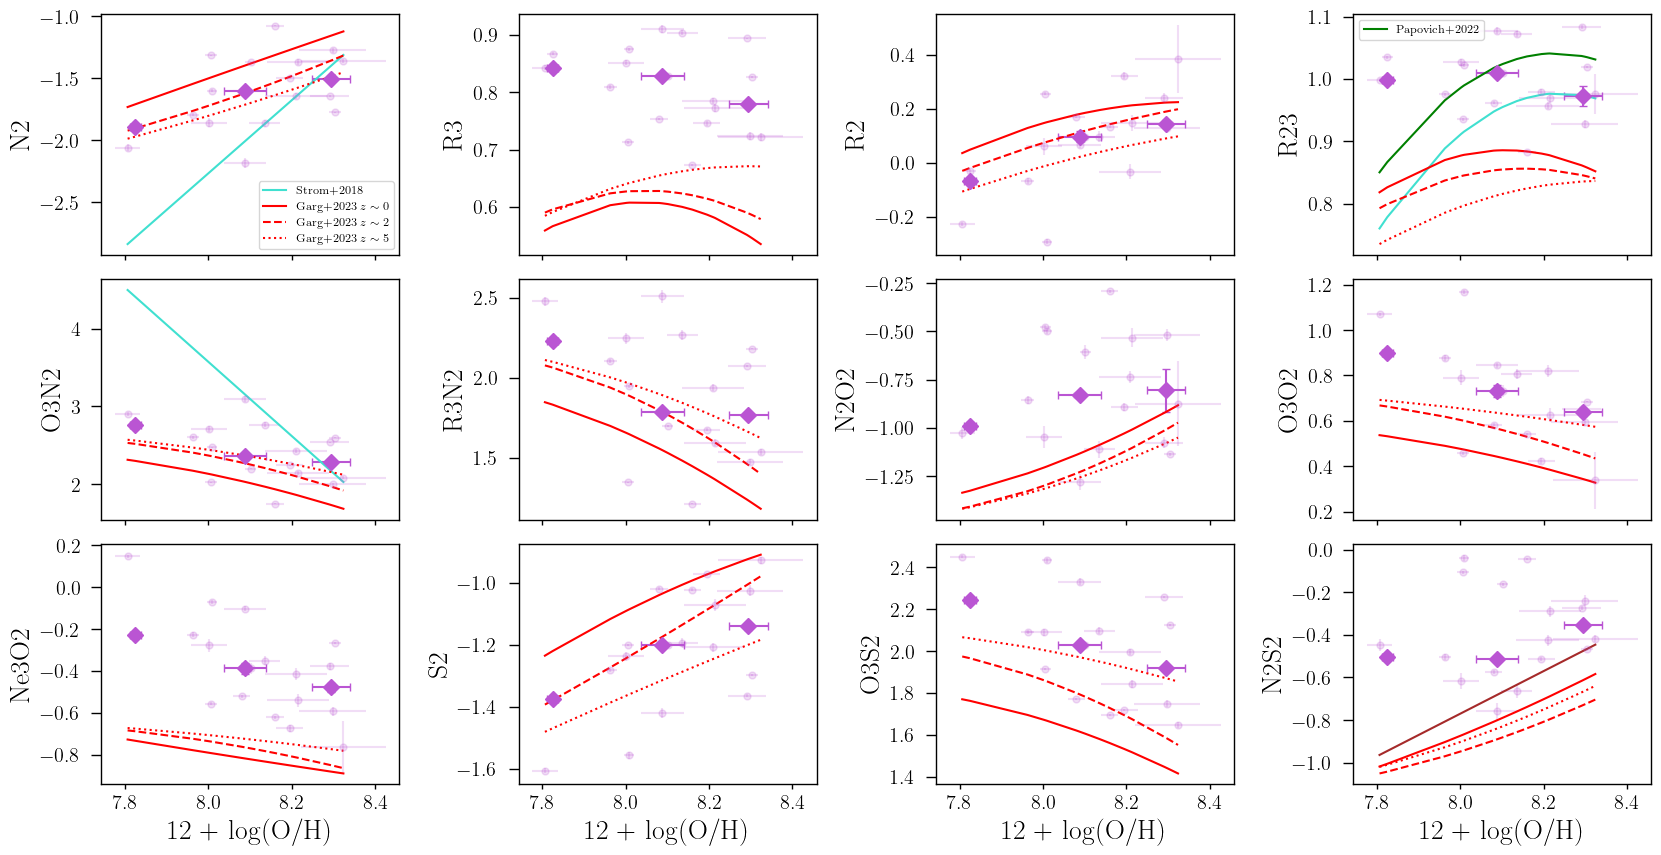

In [22]:
texPlot('on')
fig, axs = plt.subplots(3, 4, sharex=True)
fig.set_size_inches((20, 10))
fig.subplots_adjust(wspace=0.4, hspace=0.1)

# ===========================================================================================================
# 1st row
# ===========================================================================================================

# N2

axs[0, 0].errorbar(metals['12_log_OH'], metals['N2'], xerr=metals['12_log_OH_err'], yerr=metals['N2_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[0, 0].errorbar(log_OH_med, N2_med, xerr=log_OH_med_err, yerr=N2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[0, 0].plot(np.sort(metals['12_log_OH']), strom2018(np.sort(metals['12_log_OH']), 'N2'), label='Strom+2018', color='turquoise')
axs[0, 0].plot(np.sort(metals['12_log_OH']), garg2023_z_0(np.sort(metals['12_log_OH']), 'N2'), label=r'Garg+2023 $z \sim 0$', color='red')
axs[0, 0].plot(np.sort(metals['12_log_OH']), garg2023_z_2(np.sort(metals['12_log_OH']), 'N2'), label=r'Garg+2023 $z \sim 2$', color='red', ls='--')
axs[0, 0].plot(np.sort(metals['12_log_OH']), garg2023_z_5(np.sort(metals['12_log_OH']), 'N2'), label=r'Garg+2023 $z \sim 5$', color='red', ls=':')

axs[0, 0].legend(frameon=True, fontsize='small')
axs[0, 0].set_ylabel('N2')

# R3

axs[0, 1].errorbar(metals['12_log_OH'], metals['R3'], xerr=metals['12_log_OH_err'], yerr=metals['R3_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[0, 1].errorbar(log_OH_med, R3_med, xerr=log_OH_med_err, yerr=R3_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[0, 1].plot(np.sort(metals['12_log_OH']), garg2023_z_0(np.sort(metals['12_log_OH']), 'R3'), label=r'Garg+2023 $z \sim 0$', color='red')
axs[0, 1].plot(np.sort(metals['12_log_OH']), garg2023_z_2(np.sort(metals['12_log_OH']), 'R3'), label=r'Garg+2023 $z \sim 2$', color='red', ls='--')
axs[0, 1].plot(np.sort(metals['12_log_OH']), garg2023_z_5(np.sort(metals['12_log_OH']), 'R3'), label=r'Garg+2023 $z \sim 5$', color='red', ls=':')

#axs[0, 1].legend(frameon=True, fontsize='small')
axs[0, 1].set_ylabel('R3')

# R2

axs[0, 2].errorbar(metals['12_log_OH'], metals['R2'], xerr=metals['12_log_OH_err'], yerr=metals['R2_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[0, 2].errorbar(log_OH_med, R2_med, xerr=log_OH_med_err, yerr=R2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[0, 2].plot(np.sort(metals['12_log_OH']), garg2023_z_0(np.sort(metals['12_log_OH']), 'R2'), label=r'Garg+2023 $z \sim 0$', color='red')
axs[0, 2].plot(np.sort(metals['12_log_OH']), garg2023_z_2(np.sort(metals['12_log_OH']), 'R2'), label=r'Garg+2023 $z \sim 2$', color='red', ls='--')
axs[0, 2].plot(np.sort(metals['12_log_OH']), garg2023_z_5(np.sort(metals['12_log_OH']), 'R2'), label=r'Garg+2023 $z \sim 5$', color='red', ls=':')

#axs[0, 2].legend(frameon=True, fontsize='small')
axs[0, 2].set_ylabel('R2')


# ===========================================================================================================
# 2nd row
# ===========================================================================================================

# R23

axs[0, 3].errorbar(metals['12_log_OH'], metals['R23'], xerr=metals['12_log_OH_err'], yerr=metals['R23_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[0, 3].errorbar(log_OH_med, R23_med, xerr=log_OH_med_err, yerr=R23_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[0, 3].plot(np.sort(metals['12_log_OH']), strom2018(np.sort(metals['12_log_OH']), 'R23'), color='turquoise')
axs[0, 3].plot(np.sort(metals['12_log_OH']), papovich2022_R23(np.sort(metals['12_log_OH'])), label='Papovich+2022', color='green')
axs[0, 3].plot(np.sort(metals['12_log_OH']), garg2023_z_0(np.sort(metals['12_log_OH']), 'R23'), color='red')
axs[0, 3].plot(np.sort(metals['12_log_OH']), garg2023_z_2(np.sort(metals['12_log_OH']), 'R23'), color='red', ls='--')
axs[0, 3].plot(np.sort(metals['12_log_OH']), garg2023_z_5(np.sort(metals['12_log_OH']), 'R23'), color='red', ls=':')

axs[0, 3].legend(frameon=True, fontsize='small')
axs[0, 3].set_ylabel('R23')

# O3N2

axs[1, 0].errorbar(metals['12_log_OH'], metals['O3N2'], xerr=metals['12_log_OH_err'], yerr=metals['O3N2_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[1, 0].errorbar(log_OH_med, O3N2_med, xerr=log_OH_med_err, yerr=O3N2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[1, 0].plot(np.sort(metals['12_log_OH']), strom2018(np.sort(metals['12_log_OH']), 'O3N2'), label='Strom+2018', color='turquoise')
axs[1, 0].plot(np.sort(metals['12_log_OH']), garg2023_z_0(np.sort(metals['12_log_OH']), 'O3N2'), label=r'Garg+2023 $z \sim 0$', color='red')
axs[1, 0].plot(np.sort(metals['12_log_OH']), garg2023_z_2(np.sort(metals['12_log_OH']), 'O3N2'), label=r'Garg+2023 $z \sim 2$', color='red', ls='--')
axs[1, 0].plot(np.sort(metals['12_log_OH']), garg2023_z_5(np.sort(metals['12_log_OH']), 'O3N2'), label=r'Garg+2023 $z \sim 5$', color='red', ls=':')

#axs[1, 0].legend(frameon=True, fontsize='small')
axs[1, 0].set_ylabel('O3N2')

# R3N2

axs[1, 1].errorbar(metals['12_log_OH'], metals['R3N2'], xerr=metals['12_log_OH_err'], yerr=metals['R3N2_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[1, 1].errorbar(log_OH_med, R3N2_med, xerr=log_OH_med_err, yerr=R3N2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[1, 1].plot(np.sort(metals['12_log_OH']), garg2023_z_0(np.sort(metals['12_log_OH']), 'R3N2'), label=r'Garg+2023 $z \sim 0$', color='red')
axs[1, 1].plot(np.sort(metals['12_log_OH']), garg2023_z_2(np.sort(metals['12_log_OH']), 'R3N2'), label=r'Garg+2023 $z \sim 2$', color='red', ls='--')
axs[1, 1].plot(np.sort(metals['12_log_OH']), garg2023_z_5(np.sort(metals['12_log_OH']), 'R3N2'), label=r'Garg+2023 $z \sim 5$', color='red', ls=':')

#axs[1, 1].legend(frameon=True, fontsize='small')
axs[1, 1].set_ylabel('R3N2')


# ===========================================================================================================
# 3rd row
# ===========================================================================================================

# N2O2

axs[1, 2].errorbar(metals['12_log_OH'], metals['N2O2'], xerr=metals['12_log_OH_err'], yerr=metals['N2O2_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[1, 2].errorbar(log_OH_med, N2O2_med, xerr=log_OH_med_err, yerr=N2O2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[1, 2].plot(np.sort(metals['12_log_OH']), garg2023_z_0(np.sort(metals['12_log_OH']), 'N2O2'), label=r'Garg+2023 $z \sim 0$', color='red')
axs[1, 2].plot(np.sort(metals['12_log_OH']), garg2023_z_2(np.sort(metals['12_log_OH']), 'N2O2'), label=r'Garg+2023 $z \sim 2$', color='red', ls='--')
axs[1, 2].plot(np.sort(metals['12_log_OH']), garg2023_z_5(np.sort(metals['12_log_OH']), 'N2O2'), label=r'Garg+2023 $z \sim 5$', color='red', ls=':')

#axs[1, 2].legend(frameon=True, fontsize='small')
axs[1, 2].set_ylabel('N2O2')

# O3O2

axs[1, 3].errorbar(metals['12_log_OH'], metals['O3O2'], xerr=metals['12_log_OH_err'], yerr=metals['O3O2_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[1, 3].errorbar(log_OH_med, O3O2_med, xerr=log_OH_med_err, yerr=O3O2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[1, 3].plot(np.sort(metals['12_log_OH']), garg2023_z_0(np.sort(metals['12_log_OH']), 'O3O2'), label=r'Garg+2023 $z \sim 0$', color='red')
axs[1, 3].plot(np.sort(metals['12_log_OH']), garg2023_z_2(np.sort(metals['12_log_OH']), 'O3O2'), label=r'Garg+2023 $z \sim 2$', color='red', ls='--')
axs[1, 3].plot(np.sort(metals['12_log_OH']), garg2023_z_5(np.sort(metals['12_log_OH']), 'O3O2'), label=r'Garg+2023 $z \sim 5$', color='red', ls=':')

#axs[1, 3].legend(frameon=True, fontsize='small')
axs[1, 3].set_ylabel('O3O2')

# Ne3O2

axs[2, 0].errorbar(metals['12_log_OH'], metals['Ne3O2'], xerr=metals['12_log_OH_err'], yerr=metals['Ne3O2_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[2, 0].errorbar(log_OH_med, Ne3O2_med, xerr=log_OH_med_err, yerr=Ne3O2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[2, 0].plot(np.sort(metals['12_log_OH']), garg2023_z_0(np.sort(metals['12_log_OH']), 'Ne3O2'), label=r'Garg+2023 $z \sim 0$', color='red')
axs[2, 0].plot(np.sort(metals['12_log_OH']), garg2023_z_2(np.sort(metals['12_log_OH']), 'Ne3O2'), label=r'Garg+2023 $z \sim 2$', color='red', ls='--')
axs[2, 0].plot(np.sort(metals['12_log_OH']), garg2023_z_5(np.sort(metals['12_log_OH']), 'Ne3O2'), label=r'Garg+2023 $z \sim 5$', color='red', ls=':')

#axs[2, 0].legend(frameon=True, fontsize='small')
axs[2, 0].set_ylabel('Ne3O2')

# ===========================================================================================================
# 4th row
# ===========================================================================================================

# S2

axs[2, 1].errorbar(metals['12_log_OH'], metals['S2'], xerr=metals['12_log_OH_err'], yerr=metals['S2_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[2, 1].errorbar(log_OH_med, S2_med, xerr=log_OH_med_err, yerr=S2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[2, 1].plot(np.sort(metals['12_log_OH']), garg2023_z_0(np.sort(metals['12_log_OH']), 'S2'), label=r'Garg+2023 $z \sim 0$', color='red')
axs[2, 1].plot(np.sort(metals['12_log_OH']), garg2023_z_2(np.sort(metals['12_log_OH']), 'S2'), label=r'Garg+2023 $z \sim 2$', color='red', ls='--')
axs[2, 1].plot(np.sort(metals['12_log_OH']), garg2023_z_5(np.sort(metals['12_log_OH']), 'S2'), label=r'Garg+2023 $z \sim 5$', color='red', ls=':')

#axs[2, 1].legend(frameon=True, fontsize='small')
axs[2, 1].set_ylabel('S2')

# O3S2

axs[2, 2].errorbar(metals['12_log_OH'], metals['O3S2'], xerr=metals['12_log_OH_err'], yerr=metals['O3S2_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[2, 2].errorbar(log_OH_med, O3S2_med, xerr=log_OH_med_err, yerr=O3S2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[2, 2].plot(np.sort(metals['12_log_OH']), garg2023_z_0(np.sort(metals['12_log_OH']), 'O3S2'), label=r'Garg+2023 $z \sim 0$', color='red')
axs[2, 2].plot(np.sort(metals['12_log_OH']), garg2023_z_2(np.sort(metals['12_log_OH']), 'O3S2'), label=r'Garg+2023 $z \sim 2$', color='red', ls='--')
axs[2, 2].plot(np.sort(metals['12_log_OH']), garg2023_z_5(np.sort(metals['12_log_OH']), 'O3S2'), label=r'Garg+2023 $z \sim 5$', color='red', ls=':')

#axs[2, 2].legend(frameon=True, fontsize='small')
axs[2, 2].set_ylabel('O3S2')

# N2S2

axs[2, 3].errorbar(metals['12_log_OH'], metals['N2S2'], xerr=metals['12_log_OH_err'], yerr=metals['N2S2_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[2, 3].errorbar(log_OH_med, N2S2_med, xerr=log_OH_med_err, yerr=N2S2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[2, 3].plot(np.sort(metals['12_log_OH']), dopita2016_N2S2(np.sort(metals['12_log_OH'])), label='Dopita+2016', color='brown')
axs[2, 3].plot(np.sort(metals['12_log_OH']), garg2023_z_0(np.sort(metals['12_log_OH']), 'N2S2'), label=r'Garg+2023 $z \sim 0$', color='red')
axs[2, 3].plot(np.sort(metals['12_log_OH']), garg2023_z_2(np.sort(metals['12_log_OH']), 'N2S2'), label=r'Garg+2023 $z \sim 2$', color='red', ls='--')
axs[2, 3].plot(np.sort(metals['12_log_OH']), garg2023_z_5(np.sort(metals['12_log_OH']), 'N2S2'), label=r'Garg+2023 $z \sim 5$', color='red', ls=':')

#axs[2, 3].legend(frameon=True, fontsize='small')
axs[2, 3].set_ylabel('N2S2')


# labels
axs[2, 0].set_xlabel(r'12 + log(O/H)')
axs[2, 1].set_xlabel(r'12 + log(O/H)')
axs[2, 2].set_xlabel(r'12 + log(O/H)')
axs[2, 3].set_xlabel(r'12 + log(O/H)')

# title
#axs[0, 1].set_title(r'Photoionization models', fontsize=50)
#plt.savefig('models.jpg', bbox_inches='tight', facecolor='white')

# Comparison with high z measurements

In [68]:
r23 = upy.uarray([0.15, 0.90, 0.26], [0.07, 0.10, 0.08]) + upy.uarray([3.08, 8.29, 7.11], [0.13, 0.21, 0.24])
ne3o2 = upy.uarray([0.17, 0.45, 0.50], [0.03, 0.03, 0.04]) / upy.uarray([0.15, 0.90, 0.26], [0.07, 0.10, 0.08])
o3o2 = upy.uarray([3.08, 8.29, 7.11], [0.13, 0.21, 0.24]) / upy.uarray([0.15, 0.90, 0.26], [0.07, 0.10, 0.08])

Curti_dict = {
    'R2': upy.log10(upy.uarray([0.15, 0.90, 0.26], [0.07, 0.10, 0.08])),
    'R3': upy.log10(upy.uarray([3.08, 8.29, 7.11], [0.13, 0.21, 0.24])),
    'R23': upy.log10(r23),
    'O3O2': upy.log10(o3o2),
    'Ne3O2': upy.log10(ne3o2),
    '12_log_OH': upy.uarray([7.25, 7.53, 7.50], [0.21, 0.08, 0.12])
}

def sanders2023(log_OH_12, ratio='asd'):
    x = (log_OH_12 - 8.0)
    if ratio == 'R2':
        c0 = 0.067
        c1 = 1.069
        c2 = 0.0
    if ratio == 'R3':
        c0 = 0.834
        c1 = -0.072
        c2 = -0.453
    if ratio == 'R23':
        c0 = 1.017
        c1 = 0.026
        c2 = -0.331
    if ratio == 'O3O2':
        c0 = 0.723
        c1 = -1.153
        c2 = 0.0
    if ratio == 'Ne3O2':
        c0 = -0.386
        c1 = -0.998
        c2 = 0.0
    return c0 + (c1 * x) + (c2 * (x**2))

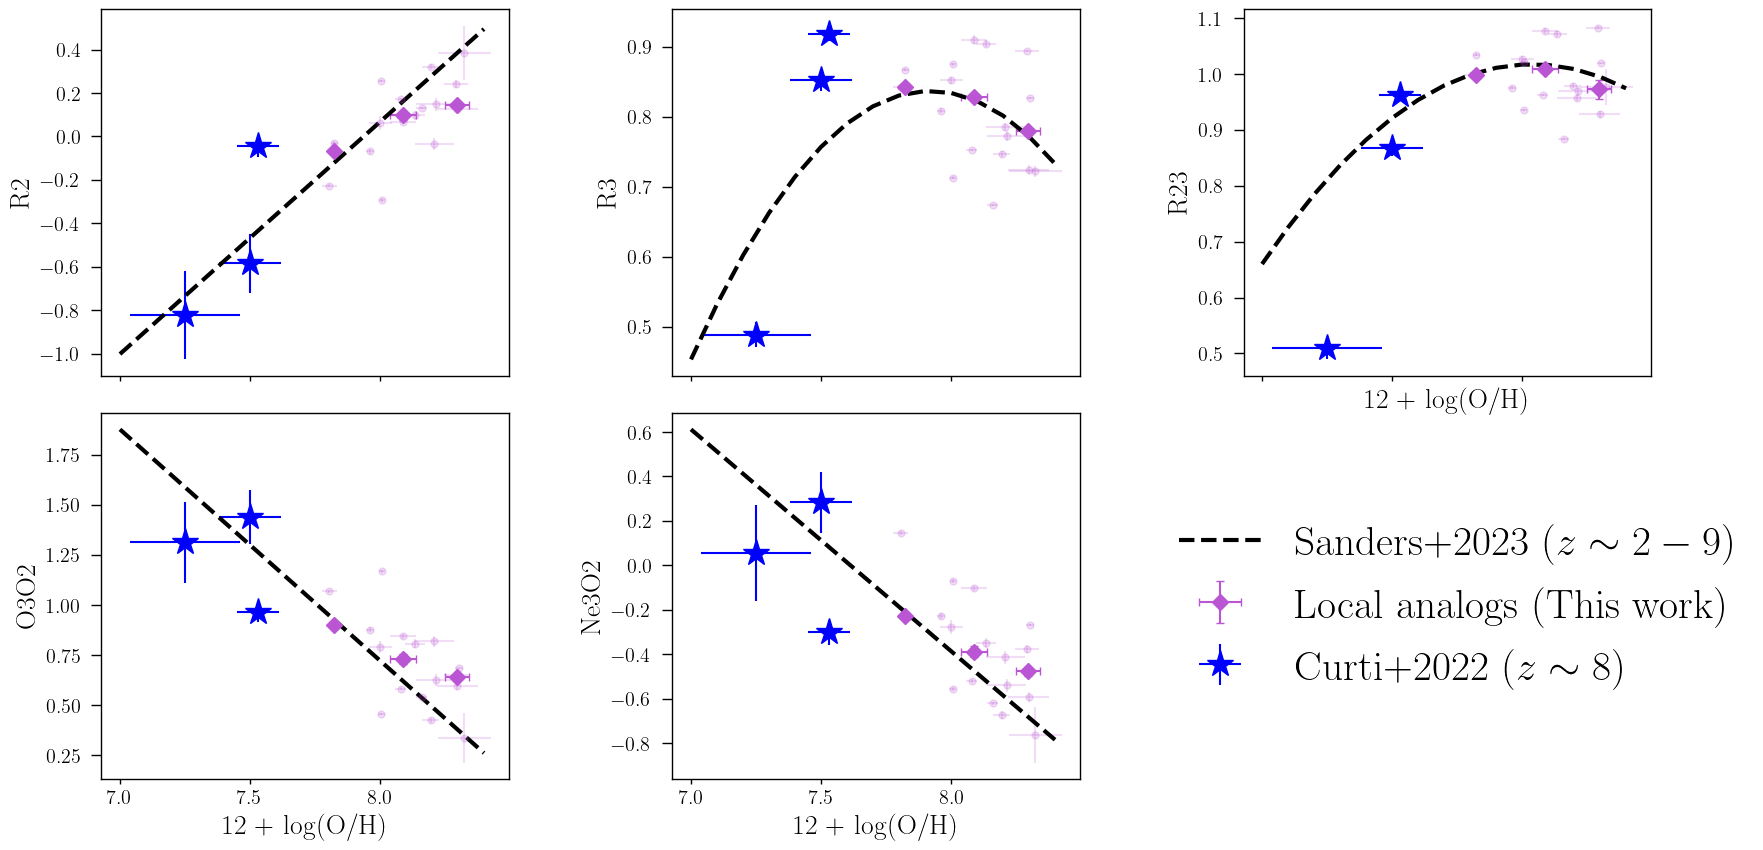

In [78]:
texPlot('on')
fig, axs = plt.subplots(2, 3, sharex=True)
fig.set_size_inches((20, 10))
fig.subplots_adjust(wspace=0.4, hspace=0.1)

dou = np.arange(7.0, 8.5, 0.1)
# R2

axs[0, 0].errorbar(metals['12_log_OH'], metals['R2'], xerr=metals['12_log_OH_err'], yerr=metals['R2_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[0, 0].errorbar(log_OH_med, R2_med, xerr=log_OH_med_err, yerr=R2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[0, 0].errorbar(upy.nominal_values(Curti_dict['12_log_OH']), upy.nominal_values(Curti_dict['R2']),
                  xerr=upy.std_devs(Curti_dict['12_log_OH']), yerr=upy.std_devs(Curti_dict['R2']),
                  ls='', markersize=20, marker='*', color='Blue')


axs[0, 0].plot(dou, sanders2023(dou, 'R2'), color='black', ls='--', lw=3)
#axs[0, 2].legend(frameon=True, fontsize='small')
axs[0, 0].set_ylabel('R2')

# R3

axs[0, 1].errorbar(metals['12_log_OH'], metals['R3'], xerr=metals['12_log_OH_err'], yerr=metals['R3_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[0, 1].errorbar(log_OH_med, R3_med, xerr=log_OH_med_err, yerr=R3_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[0, 1].errorbar(upy.nominal_values(Curti_dict['12_log_OH']), upy.nominal_values(Curti_dict['R3']),
                  xerr=upy.std_devs(Curti_dict['12_log_OH']), yerr=upy.std_devs(Curti_dict['R3']),
                  ls='', markersize=20, marker='*', color='Blue')


axs[0, 1].plot(dou, sanders2023(dou, 'R3'), color='black', ls='--', lw=3)

#axs[0, 1].legend(frameon=True, fontsize='small')
axs[0, 1].set_ylabel('R3')

# R23

axs[0, 2].errorbar(metals['12_log_OH'], metals['R23'], xerr=metals['12_log_OH_err'], yerr=metals['R23_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[0, 2].errorbar(log_OH_med, R23_med, xerr=log_OH_med_err, yerr=R23_med_err,
                   ls='', color=colplot, capsize=3, marker='D', markersize=8, label='Local analogs (This work)')

axs[0, 2].errorbar(upy.nominal_values(Curti_dict['12_log_OH']), upy.nominal_values(Curti_dict['R23']),
                  xerr=upy.std_devs(Curti_dict['12_log_OH']), yerr=upy.std_devs(Curti_dict['R23']),
                  ls='', markersize=20, marker='*', color='Blue', label=r'Curti+2022 ($z \sim 8$)')

axs[0, 2].plot(dou, sanders2023(dou, 'R23'), label='Sanders+2023 ($z \sim 2 - 9$)',
               color='black', ls='--', lw=3)

axs[0, 2].legend(frameon=False, loc=(-0.2, -0.9), fontsize=30)
axs[0, 2].set_ylabel('R23')

axs[1, 2].axis('off')


# O3O2

axs[1, 0].errorbar(metals['12_log_OH'], metals['O3O2'], xerr=metals['12_log_OH_err'], yerr=metals['O3O2_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[1, 0].errorbar(log_OH_med, O3O2_med, xerr=log_OH_med_err, yerr=O3O2_med_err, ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[1, 0].errorbar(upy.nominal_values(Curti_dict['12_log_OH']), upy.nominal_values(Curti_dict['O3O2']),
                  xerr=upy.std_devs(Curti_dict['12_log_OH']), yerr=upy.std_devs(Curti_dict['O3O2']),
                  ls='', markersize=20, marker='*', color='Blue')

axs[1, 0].plot(dou, sanders2023(dou, 'O3O2'), color='black', ls='--', lw=3)
#axs[1, 3].legend(frameon=True, fontsize='small')
axs[1, 0].set_ylabel('O3O2')

# Ne3O2

axs[1, 1].errorbar(metals['12_log_OH'], metals['Ne3O2'], xerr=metals['12_log_OH_err'], yerr=metals['Ne3O2_err'], 
                  marker='o', capsize=0, markersize=5, ls='', ecolor=colplot, color=colplot, alpha=0.2)
axs[1, 1].errorbar(log_OH_med, Ne3O2_med, xerr=log_OH_med_err, yerr=Ne3O2_med_err,
                   ls='', color=colplot, capsize=3, marker='D', markersize=8)

axs[1, 1].plot(dou, sanders2023(dou, 'Ne3O2'), color='black', ls='--', lw=3)

axs[1, 1].errorbar(upy.nominal_values(Curti_dict['12_log_OH']), upy.nominal_values(Curti_dict['Ne3O2']),
                  xerr=upy.std_devs(Curti_dict['12_log_OH']), yerr=upy.std_devs(Curti_dict['Ne3O2']),
                  ls='', markersize=20, marker='*', color='Blue')

#axs[2, 0].legend(frameon=True, fontsize='small')
axs[1, 1].set_ylabel('Ne3O2')


# labels
axs[1, 0].set_xlabel(r'12 + log(O/H)')
axs[1, 1].set_xlabel(r'12 + log(O/H)')
axs[0, 2].set_xlabel(r'12 + log(O/H)')

fig.savefig('/home/benjamin/Documents/analogs/high_z_comparison.jpg',
           bbox_inches='tight', facecolor='white')